# How the ICITR paper's results were obtained

**Beyond Persistence? PAGE: Persistence-Anchored Gated Forecasting with
Spatio-Temporal Graph Networks for Dengue**

This is one local notebook for the latest paper, `full_paper/icitr/main.pdf`.
It connects **data sources → weekly data → time splits → models → predictions →
error scores → paper tables**. Each section explains what its code does before
showing the calculation. Lower RMSE means fewer large forecast errors.

## Start here

1. Keep this notebook inside this project and open it in Jupyter or VS Code.
2. Select a Python environment containing `numpy`, `pandas`, `matplotlib`,
   `torch` and `IPython`. Optional full training also needs `scikit-learn` and
   `pymupdf`. No package installation or download happens automatically.
3. Choose **Run All**. The default checks existing evidence and prints the tables;
   it does **not** train hundreds of networks.
4. To repeat training, read sections 13–14 and change `FULL_RETRAIN` below.
   Fresh files go under `runs/icitr_notebook/`; paper files are never overwritten.

**What a successful default run proves:** the calculations agree with the saved
artifacts, and the available case data independently reproduce the naive baselines.
**What it does not prove:** that every historical model was actually trained correctly,
that local artifacts are independently authenticated, or that every cited paper is
accurate. Logs, hashes and varying run times are evidence, not proof of execution.
The original per-prediction archive for EXP-050 is absent from this checkout.

## Contents

1. Settings and evidence inventory
2. Where the data came from
3. Weekly data and missing weeks
4. Why there are different RMSE numbers: time splits and persistence
5. What PAGE changes
6. Table I: encoder and baseline comparison
7. Table II: ablation and paired comparisons
8. Other levers: loss, climate, graph and augmentation
9. Diagnostics: what can be recalculated and what is retained evidence
10. Table III: the amended 2024–2026 evaluation and its statistics
11. Tuning and Table IV: parameter counts and computational cost
12. Paper-number checks, coverage and limits
13. Optional: rerun the prospective training locally
14. Optional: rebuild inputs and rerun the 810-run development study

The notebook intentionally reports the current paper, including known limitations.
**EXP-062 is still marked pending in the paper:** date-joined seasonal and climate
results need a recheck. This notebook does not silently replace those historical scores.

In [1]:
from pathlib import Path
import ast
import csv
import hashlib
import itertools
import json
import platform
import re
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

FULL_RETRAIN = False
WORKERS = 1  # Reliable on Windows; the original EXP-050 notebook uses fork on Linux.
REPO_OVERRIDE = None  # Optional: r"C:\Users\ASUS\Desktop\dengue-forecasting"


def find_repo():
    if REPO_OVERRIDE:
        return Path(REPO_OVERRIDE).expanduser().resolve()
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "full_paper/icitr/main.tex").exists():
            return candidate
    raise FileNotFoundError(
        "Open this notebook inside the dengue-forecasting project, or set REPO_OVERRIDE."
    )


REPO = find_repo()
RUN_DIR = REPO / "runs/icitr_notebook"
RUN_DIR.mkdir(parents=True, exist_ok=True)
KAGGLE = REPO / "full_paper/outputs/kaggle_run"
PROSPECTIVE = REPO / "seirgnn2/results"
ENCODERS = ["AAGCN", "ASTGCN", "LSTM", "STGAT", "A3TGCN", "DCRNN"]
CHECKS = []
pd.set_option("display.max_columns", 14)
pd.set_option("display.max_rows", 40)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def check_close(label, actual, expected, source, atol=1e-7):
    same_shape = np.asarray(actual).shape == np.asarray(expected).shape
    ok = same_shape and bool(np.allclose(actual, expected, atol=atol, rtol=0, equal_nan=True))
    CHECKS.append(
        {
            "check": label,
            "status": "PASS" if ok else "MISMATCH",
            "actual": str(actual),
            "reference": str(expected),
            "source": source,
        }
    )
    return ok


print("Project:", REPO)
print("Fresh outputs:", RUN_DIR)
print("Python:", platform.python_version(), "| platform:", platform.platform())
print(
    "Mode:",
    "historical audit + optional fresh training"
    if FULL_RETRAIN
    else "saved-result audit (no training)",
)

Project: C:\Users\ASUS\Desktop\dengue-forecasting
Fresh outputs: C:\Users\ASUS\Desktop\dengue-forecasting\runs\icitr_notebook
Python: 3.12.6 | platform: Windows-11-10.0.26200-SP0
Mode: saved-result audit (no training)


In [2]:
# Embedded source snapshots. These are implementation code, not experimental results.
# Collapsed to keep the walkthrough readable; expand to inspect any definition.
MODULE_SOURCES = {'analysis/_build/population_vintages.py': '"""District population, with every figure usable only from the date its document was published.\n\nRule (fixed in advance, ``docs/WEEK_INDEX_FIX.md``): for a forecast week starting on ``d``, take the\nestimate with the latest reference date that is not after ``d`` among the documents whose\n``available_from`` is not after ``d``. If no document is available yet (weeks before the first\nverified publication date), use the earliest one and record the week as ``pre_availability``.\n\nDocuments and their publication dates. The date is the file\'s HTTP ``Last-Modified`` header, or its\nPDF creation date where the header is absent. It is an upper bound for the true release date, so\nit never lets a figure in early.\n\n  census_2012        DCS "Census of Population and Housing 2012", district reports\n                     (statistics.gov.lk .../cph2011/Pages/Activities/Reports/District/<name>.pdf,\n                     Last-Modified 2015-03-10); reference date 2012-03-20 (census day)\n  midyear_2014_2024  DCS "Mid-year population by district and sex, 2024" (estimates 2014 to 2024)\n                     https://www.statistics.gov.lk/Resource/en/Population/Vital_Statistics/\n                     Mid-year_population_by_district_and_sex_2024.pdf\n                     PDF created / Last-Modified 2024-09-19; reference dates 1 July of each year\n  midyear_2025       DCS "Mid-year population estimates by district and sex, 2025*" (provisional)\n                     .../Mid-year_population_by_district_and_sex_2025.pdf, Last-Modified 2025-11-03;\n                     reference date 2025-07-01\n\nEarlier editions of the mid-year table are no longer on the DCS site, so estimates for 2014 to 2023\ncan only be dated to the 2024 file. This is stricter than the earlier rule (the previous year\'s\nestimate from the 2024 file for every week of a year), which let figures in up to ten years early.\n\n    python analysis/_build/population_vintages.py          # write data/external/population_vintages.csv\n"""\nfrom __future__ import annotations\n\nimport hashlib\nimport json\nimport re\nimport sys\nimport urllib.request\nfrom pathlib import Path\n\nimport numpy as np\nimport pandas as pd\n\nREPO = Path(__file__).resolve().parent.parent.parent\nEXT = REPO / "data" / "external"\nOUT = EXT / "population_vintages.csv"\nURL25 = "https://www.statistics.gov.lk/Resource/en/Population/Vital_Statistics/Mid-year_population_by_district_and_sex_2025.pdf"\nDCS_TO_GRAPH = {"Nuwara-eliya": "NuwaraEliya", "Monaragala": "Moneragala", "Baticaloa": "Batticaloa"}\nUA = {"User-Agent": "Mozilla/5.0 Chrome/124"}\n\n\ndef district_names() -> list[str]:\n    return sorted(json.loads((REPO / "notebooks" / "baseline" / "sri_lanka_adj_list.json").read_text("utf-8")))\n\n\ndef parse_2025() -> pd.Series:\n    import pymupdf\n\n    raw = urllib.request.urlopen(urllib.request.Request(URL25, headers=UA), timeout=90).read()\n    text = "\\n".join(p.get_text() for p in pymupdf.open(stream=raw, filetype="pdf"))\n    tokens = [t.strip() for t in text.split("\\n") if t.strip()]\n    names, out = district_names(), {}\n    for i, tok in enumerate(tokens):\n        name = DCS_TO_GRAPH.get(tok, tok.replace("-", "").replace(" ", ""))\n        if name in names and name not in out:\n            out[name] = int(next(t for t in tokens[i + 1:] if re.fullmatch(r"[\\d,]+", t)).replace(",", "")) * 1000\n    assert sorted(out) == names, sorted(set(names) - set(out))\n    total = int(next(t for t in tokens[tokens.index("Sri Lanka") + 1:] if re.fullmatch(r"[\\d,]+", t)).replace(",", ""))\n    assert abs(sum(out.values()) / 1000 - total) <= 25, (sum(out.values()) / 1000, total)   # thousands, rounding\n    print("2025 file sha256", hashlib.sha256(raw).hexdigest()[:16])\n    return pd.Series(out)\n\n\ndef build() -> pd.DataFrame:\n    names = district_names()\n    census = pd.read_csv(EXT / "census_2012_dcs_district_totals.csv").set_index("district")["population_2012"]\n    mid = pd.read_csv(EXT / "district_population.csv")\n    mid = mid[mid.district != "Sri Lanka"].pivot(index="year", columns="district", values="population_thousands") * 1000\n    rows = []\n    for d in names:\n        rows.append(("census_2012", "2015-03-10", "2012-03-20", d, float(census[d])))\n        for y in mid.index:\n            rows.append(("midyear_2014_2024", "2024-09-19", f"{int(y)}-07-01", d, float(mid.loc[y, d])))\n    p25 = parse_2025()\n    for d in names:\n        rows.append(("midyear_2025", "2025-11-03", "2025-07-01", d, float(p25[d])))\n    return pd.DataFrame(rows, columns=["document", "available_from", "reference_date", "district", "population"])\n\n\ndef population_for_dates(week_starts: pd.Series) -> tuple[np.ndarray, pd.DataFrame]:\n    """``(T, 25)`` persons and a per-week audit table (document, reference date, pre_availability)."""\n    v = pd.read_csv(OUT, parse_dates=["available_from", "reference_date"])\n    names = district_names()\n    first = v["available_from"].min()\n    pops, audit = [], []\n    for d in pd.to_datetime(week_starts):\n        avail = v[v["available_from"] <= d]\n        pre = avail.empty\n        if pre:\n            avail = v[v["available_from"] == first]\n        ref = avail[avail["reference_date"] <= d]["reference_date"].max() if (avail["reference_date"] <= d).any() \\\n            else avail["reference_date"].min()\n        sel = avail[avail["reference_date"] == ref].drop_duplicates("district").set_index("district")\n        pops.append(sel.loc[names, "population"].to_numpy(dtype=np.float64))\n        audit.append({"week_start": d.date().isoformat(), "document": sel["document"].iloc[0],\n                      "reference_date": ref.date().isoformat(), "pre_availability": bool(pre)})\n    return np.stack(pops), pd.DataFrame(audit)\n\n\ndef main() -> int:\n    df = build()\n    df.to_csv(OUT, index=False)\n    print(f"wrote {len(df)} rows -> {OUT.name}")\n    return 0\n\n\nif __name__ == "__main__":\n    sys.stdout.reconfigure(encoding="utf-8", errors="replace")\n    raise SystemExit(main())\n', 'analysis/lib/adaptive.py': '"""A spatio-temporal GNN in which the adjacency is the only variable.\n\nThe point of this module is a controlled comparison. Four graph modes share one\nencoder, one training loop, one normalisation and one protocol, so a difference\nbetween them is attributable to the graph and nothing else:\n\n``none``\n    Identity adjacency -- 25 independent time series, no message passing. The\n    control that says whether a graph earns its keep at all.\n``fixed``\n    The authors\' hand-built district adjacency, symmetrically normalised. What\n    every model in Weng et al. uses.\n``adaptive``\n    ``softmax(ReLU(E1 @ E2.T))`` with ``E1``, ``E2`` learned node embeddings --\n    the Graph WaveNet construction ``docs/ROADMAP.md`` cites for Contribution (c).\n``hybrid``\n    ``0.5 * fixed + 0.5 * adaptive``, which is how Graph WaveNet actually uses it:\n    the learned graph augments the prior rather than replacing it.\n\nThe self-path, and why it was added\n-----------------------------------\nThe first run of this comparison put ``none`` (42.82) ahead of ``fixed`` (43.36),\n``hybrid`` (43.55) and ``adaptive`` (43.81) -- identity beating a real district\nadjacency, which is not a result about geography so much as a symptom.\n\nThe cause is that propagation was ``relu(A @ W h)`` with no separate route for a\nnode\'s own state. ``none`` and ``fixed`` both carry a diagonal (``fixed`` is built\nwith self-loops), so they keep it; ``adaptive`` is ``softmax(ReLU(E1 E2.T))``,\nwhich at small initialisation is close to *uniform* over 25 districts -- an\naveraging matrix that erases the node\'s own signal at exactly the point where\nlag-1 autocorrelation (r = 0.92) carries almost all the information.\n\nGraph WaveNet does not have this problem because its diffusion convolution\nincludes a ``k=0`` identity term. :class:`STGNN` now does the same, via an\nexplicit ``self_path`` transform present in **every** mode, so the graph is a\ncorrection to a node\'s own state rather than the only route information can take.\nPass ``self_path=False`` to reproduce the earlier numbers.\n\nModelling choices other than the graph follow ``docs/decisions/0001``: predict\nthe residual over persistence, in log1p space, with normalisation from training\nweeks only. Those are the choices that made this project\'s own baseline\ncompetitive, and holding them fixed keeps the comparison about the graph.\n"""\n\nfrom __future__ import annotations\n\nimport json\nfrom dataclasses import dataclass, field\nfrom pathlib import Path\n\nimport numpy as np\nimport torch\nfrom torch import nn\n\n__all__ = [\n    "GRAPH_MODES",\n    "STGNN",\n    "Fold",\n    "build_folds",\n    "evaluate",\n    "load_dataset",\n    "persistence_scores",\n    "pooled_scores",\n    "train_one",\n]\n\nGRAPH_MODES = ("none", "fixed", "adaptive", "hybrid")\n\n\n# --------------------------------------------------------------------------\n# data\n# --------------------------------------------------------------------------\n\n\ndef load_dataset(npy_path: str | Path, adj_path: str | Path, cases_idx: int = 5):\n    """Return ``(cases, adjacency, district_names)``.\n\n    ``cases`` is ``(weeks, districts)`` raw counts; ``adjacency`` is the\n    symmetrically normalised binary graph with self-loops.\n    """\n    raw = np.nan_to_num(np.load(Path(npy_path), allow_pickle=True)).astype(np.float64)\n    cases = raw[..., cases_idx]\n\n    adj = json.loads(Path(adj_path).read_text(encoding="utf-8"))\n    names = sorted(adj)\n    index = {name: i for i, name in enumerate(names)}\n    n = len(names)\n\n    a = np.eye(n)\n    for district, neighbours in adj.items():\n        for neighbour in neighbours:\n            a[index[district], index[neighbour]] = 1.0\n    # Symmetrise: the released list has two one-way edges (EDA F7), and an\n    # adjacency relation that is not symmetric is a data defect, not a modelling\n    # choice. Both arms get the same corrected graph.\n    a = np.maximum(a, a.T)\n\n    deg = a.sum(1)\n    d_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(deg, 1e-12)))\n    return cases, d_inv_sqrt @ a @ d_inv_sqrt, names\n\n\n@dataclass\nclass Fold:\n    """One rolling-origin fold, with train-only normalisation baked in."""\n\n    origin: float\n    x_train: torch.Tensor\n    y_train: torch.Tensor\n    p_train: torch.Tensor\n    x_val: torch.Tensor\n    y_val: torch.Tensor\n    p_val: torch.Tensor\n    x_test: torch.Tensor\n    y_test: torch.Tensor\n    p_test: torch.Tensor\n    mean: float\n    std: float\n    test_index: np.ndarray = field(default_factory=lambda: np.array([]))\n    train_index: np.ndarray = field(default_factory=lambda: np.array([]))\n    val_index: np.ndarray = field(default_factory=lambda: np.array([]))\n\n    def inverse(self, values: np.ndarray) -> np.ndarray:\n        """Undo log1p + z-score, returning raw counts."""\n        return np.expm1(np.clip(values * self.std + self.mean, 0, 12))\n\n\ndef build_folds(\n    cases: np.ndarray,\n    window: int = 3,\n    horizon: int = 3,\n    origins: tuple[float, ...] = (0.55, 0.70, 0.85),\n    test_frac: float = 0.15,\n    val_weeks: int = 30,\n) -> list[Fold]:\n    """Rolling-origin folds, following ``docs/ROADMAP.md``\'s frozen protocol.\n\n    Targets are ``log1p`` z-scored with statistics from training weeks only, and\n    the persistence term ``p`` is carried alongside so the model can predict a\n    residual over it.\n    """\n    n_weeks = cases.shape[0]\n    ids = list(range(window, n_weeks - horizon))\n    folds: list[Fold] = []\n\n    for origin in origins:\n        cut = int(origin * len(ids))\n        end = int(min(origin + test_frac, 1.0) * len(ids))\n        if end <= cut:\n            continue\n        train_ids = ids[: cut - val_weeks]\n        val_ids = ids[cut - val_weeks : cut]\n        test_ids = ids[cut:end]\n\n        train_weeks = np.log1p(cases[: train_ids[-1] + 1])\n        mean, std = float(train_weeks.mean()), float(train_weeks.std() + 1e-8)\n        z = (np.log1p(cases) - mean) / std\n\n        def pack(chosen, scaled=z):\n            # `scaled` is bound at definition time on purpose: closing over the\n            # loop\'s `z` would silently use the last origin\'s scaling if this\n            # were ever called outside the iteration that created it.\n            x = np.stack([scaled[i - window : i].T for i in chosen])\n            y = np.stack([scaled[i : i + horizon].T for i in chosen])\n            p = np.stack([np.repeat(scaled[i - 1][:, None], horizon, axis=1) for i in chosen])\n            to = lambda a: torch.tensor(a, dtype=torch.float32)  # noqa: E731\n            return to(x), to(y), to(p)\n\n        xtr, ytr, ptr = pack(train_ids)\n        xva, yva, pva = pack(val_ids)\n        xte, yte, pte = pack(test_ids)\n        folds.append(\n            Fold(\n                origin, xtr, ytr, ptr, xva, yva, pva, xte, yte, pte, mean, std,\n                np.asarray(test_ids), np.asarray(train_ids), np.asarray(val_ids),\n            )\n        )\n    return folds\n\n\n# --------------------------------------------------------------------------\n# model\n# --------------------------------------------------------------------------\n\n\nclass STGNN(nn.Module):\n    """Two graph-convolution layers over a window, predicting a horizon.\n\n    Args:\n        n_nodes: Number of districts.\n        window: Input weeks.\n        horizon: Output weeks.\n        graph_mode: One of :data:`GRAPH_MODES`.\n        hidden: Width of the hidden representation.\n        emb_dim: Node-embedding width for the learned adjacency.\n        dropout: Dropout between the two graph layers.\n        alpha: Weight on the fixed graph in ``hybrid`` mode.\n        self_path: Give each layer a separate transform of the node\'s own state,\n            as Graph WaveNet\'s ``k=0`` diffusion term does. ``False`` reproduces\n            the first run of this experiment, in which the learned adjacency had\n            no diagonal to fall back on.\n    """\n\n    def __init__(\n        self,\n        n_nodes: int,\n        window: int = 3,\n        horizon: int = 3,\n        graph_mode: str = "fixed",\n        hidden: int = 64,\n        emb_dim: int = 16,\n        dropout: float = 0.1,\n        alpha: float = 0.5,\n        self_path: bool = True,\n    ) -> None:\n        super().__init__()\n        if graph_mode not in GRAPH_MODES:\n            raise ValueError(f"graph_mode must be one of {GRAPH_MODES}, got {graph_mode!r}")\n        self.graph_mode = graph_mode\n        self.alpha = alpha\n        self.n_nodes = n_nodes\n\n        self.lin_in = nn.Linear(window, hidden)\n        self.gc1 = nn.Linear(hidden, hidden)\n        self.gc2 = nn.Linear(hidden, hidden)\n        # Created unconditionally, like the embeddings below, so every arm draws\n        # the same number of initialisation samples from the RNG.\n        self.self1 = nn.Linear(hidden, hidden)\n        self.self2 = nn.Linear(hidden, hidden)\n        self.self_path = self_path\n        self.drop = nn.Dropout(dropout)\n        self.head = nn.Linear(hidden, horizon)\n\n        # Learned node embeddings. Only used by \'adaptive\' and \'hybrid\', but\n        # always created so parameter initialisation consumes the same RNG draws\n        # in every arm -- otherwise the arms differ by more than the graph.\n        self.emb_src = nn.Parameter(torch.randn(n_nodes, emb_dim) * 0.1)\n        self.emb_dst = nn.Parameter(torch.randn(n_nodes, emb_dim) * 0.1)\n\n    def adjacency(self, fixed: torch.Tensor) -> torch.Tensor:\n        """Return the adjacency this arm uses, shape ``(n_nodes, n_nodes)``."""\n        if self.graph_mode == "none":\n            return torch.eye(self.n_nodes, device=fixed.device)\n        if self.graph_mode == "fixed":\n            return fixed\n        learned = torch.softmax(torch.relu(self.emb_src @ self.emb_dst.T), dim=-1)\n        if self.graph_mode == "adaptive":\n            return learned\n        return self.alpha * fixed + (1.0 - self.alpha) * learned\n\n    def forward(self, x: torch.Tensor, fixed: torch.Tensor) -> torch.Tensor:\n        """``(batch, nodes, window)`` -> ``(batch, nodes, horizon)``."""\n        a = self.adjacency(fixed)\n        h = torch.relu(self.lin_in(x))\n        h = torch.relu(self._propagate(a, h, self.gc1, self.self1))\n        h = self.drop(h)\n        h = torch.relu(self._propagate(a, h, self.gc2, self.self2))\n        return self.head(h)\n\n    def _propagate(self, a, h, graph, own):\n        """One graph layer: neighbours through ``a``, plus the node\'s own state."""\n        message = a @ graph(h)\n        return message + own(h) if self.self_path else message\n\n\n# --------------------------------------------------------------------------\n# train / evaluate\n# --------------------------------------------------------------------------\n\n\ndef rmse(pred: np.ndarray, truth: np.ndarray) -> float:\n    """Pooled RMSE on raw counts -- not the per-window mean Weng et al. report."""\n    return float(np.sqrt(np.mean((pred - truth) ** 2)))\n\n\ndef mae(pred: np.ndarray, truth: np.ndarray) -> float:\n    """Pooled MAE on raw counts."""\n    return float(np.mean(np.abs(pred - truth)))\n\n\ndef pooled_scores(\n    pred: np.ndarray, truth: np.ndarray, artifact: np.ndarray | None = None\n) -> dict:\n    """Pooled RMSE/MAE, reported twice when an artifact mask is supplied.\n\n    Args:\n        pred: Predictions, ``(windows, nodes, horizon)`` raw counts.\n        truth: Ground truth, same shape.\n        artifact: Optional boolean mask over the window axis, ``True`` for\n            windows contaminated by the week-395 reporting spike\n            (:func:`improved.artifact_windows`).\n\n    Returns:\n        ``RMSE``/``MAE`` over all windows, plus ``RMSE_clean``/``MAE_clean`` over\n        the artifact-free windows and the counts, when a mask is given.\n\n    Both numbers are reported because neither alone is honest. Including week 395\n    measures a reporting backlog -- on the origin-0.85 fold, 6 of 68 windows carry\n    90% of the squared error. Excluding it silently would flatter every arm\n    equally and hide that the fold\'s difficulty is one week of bad data.\n    """\n    out = {"RMSE": rmse(pred, truth), "MAE": mae(pred, truth)}\n    if artifact is None:\n        return out\n    keep = ~np.asarray(artifact, dtype=bool)\n    out["n_windows"] = int(keep.size)\n    out["n_artifact"] = int(keep.size - keep.sum())\n    out["RMSE_clean"] = rmse(pred[keep], truth[keep]) if keep.any() else float("nan")\n    out["MAE_clean"] = mae(pred[keep], truth[keep]) if keep.any() else float("nan")\n    return out\n\n\n@torch.no_grad()\ndef evaluate(model: STGNN, fold: Fold, fixed: torch.Tensor, split: str = "test") -> dict:\n    """Score one split of a fold on the raw case scale."""\n    model.eval()\n    x = getattr(fold, f"x_{split}")\n    y = getattr(fold, f"y_{split}")\n    p = getattr(fold, f"p_{split}")\n    pred = model(x, fixed) + p  # residual over persistence\n    pred_raw = fold.inverse(pred.numpy())\n    truth_raw = fold.inverse(y.numpy())\n    return pooled_scores(pred_raw, truth_raw)\n\n\ndef train_one(\n    fold: Fold,\n    fixed: torch.Tensor,\n    graph_mode: str,\n    seed: int = 0,\n    epochs: int = 150,\n    lr: float = 1e-3,\n    weight_decay: float = 5e-4,\n    patience: int = 30,\n    batch_size: int = 32,\n    **model_kwargs,\n) -> tuple[STGNN, dict]:\n    """Train one arm on one fold, selecting on validation RMSE.\n\n    Returns the best model and its held-out test scores. Early stopping is on a\n    genuine validation split -- unlike Weng et al.\'s loop, which keeps the final\n    epoch\'s weights.\n    """\n    torch.manual_seed(seed)\n    # Legacy global seed on purpose: it mirrors how evaluation.py seeds, and any\n    # numpy randomness reached from here should follow the same seed.\n    np.random.seed(seed)  # noqa: NPY002\n\n    model = STGNN(fixed.shape[0], graph_mode=graph_mode, **model_kwargs)\n    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)\n    loss_fn = nn.MSELoss()\n\n    n = fold.x_train.shape[0]\n    best_state, best_val, waited = None, float("inf"), 0\n\n    for _ in range(epochs):\n        model.train()\n        order = torch.randperm(n)\n        for start in range(0, n, batch_size):\n            idx = order[start : start + batch_size]\n            opt.zero_grad()\n            pred = model(fold.x_train[idx], fixed)\n            target = fold.y_train[idx] - fold.p_train[idx]  # residual\n            loss = loss_fn(pred, target)\n            loss.backward()\n            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)\n            opt.step()\n\n        val = evaluate(model, fold, fixed, "val")["RMSE"]\n        if val < best_val - 1e-6:\n            best_val, waited = val, 0\n            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}\n        else:\n            waited += 1\n            if waited >= patience:\n                break\n\n    if best_state is not None:\n        model.load_state_dict(best_state)\n    return model, evaluate(model, fold, fixed, "test")\n\n\ndef persistence_scores(\n    fold: Fold, cases: np.ndarray, horizon: int = 3, artifact: np.ndarray | None = None\n) -> dict:\n    """Last-value-carried-forward on the same test windows -- the floor to beat.\n\n    Pass ``artifact`` to get the floor reported with and without the week-395\n    windows; the floor has to be split the same way the models are, or the\n    comparison is between two different test sets.\n    """\n    pred = np.stack([np.repeat(cases[i - 1][:, None], horizon, axis=1) for i in fold.test_index])\n    truth = np.stack([cases[i : i + horizon].T for i in fold.test_index])\n    return pooled_scores(pred, truth, artifact)\n', 'analysis/lib/corrected_data.py': '"""The corrected, dated dataset -- with the no-future-information rule enforced in code.\n\nEverything the SEIR-GNN experiments read comes through this module. It exists so\nthat "no future information" is a property the code guarantees, not a convention\nsomeone has to remember.\n\nThe rule\n--------\nA forecast is made at the start of week ``i`` and targets weeks ``i .. i+H-1``.\nIt may only use what was **published before week i began**. Each input gets a\nminimum lag -- the latest row it may read is ``i - lag``:\n\n============  ====  ===========================================================\ninput         lag   why\n============  ====  ===========================================================\ncases         1     the report for week i-1 is the latest published\nclimate       2     ERA5 is released ~5 days after the fact, so week i-1\'s\n                    weather is not complete at the start of week i\nndvi          0     rows are already as-of: each week holds the latest MODIS\n                    composite available *before* that week began\npopulation    0     rows are already lagged: each year uses the previous year\'s\n                    official figure\n============  ====  ===========================================================\n\n:func:`windows` applies these lags when it slices, and the leakage test perturbs\nevery value at or after the limit and checks the result does not move.\n\nWhat is NOT an input\n--------------------\n* The 2022-23 district seroprevalence survey: collected after almost the whole\n  series, so it is for **validation only** (does the model\'s implied immunity\n  match it?), never for initial conditions.\n* Serotype-switch dates (DENV-2 in 2016-17, DENV-3 in late 2019): known only in\n  hindsight. An immunity reset placed at those dates is an **oracle** arm and must\n  be labelled as such.\n\nNothing is filled\n-----------------\nWeeks with no source report are NaN. :func:`windows` drops any window whose case\ninput or target touches one; nothing is interpolated.\n"""\n\nfrom __future__ import annotations\n\nimport json\nfrom dataclasses import dataclass\nfrom pathlib import Path\n\nimport numpy as np\nimport pandas as pd\n\nREPO = Path(__file__).resolve().parent.parent.parent\nCORRECTED = REPO / "data" / "corrected"\nEXTERNAL = REPO / "data" / "external"\nADJ = REPO / "notebooks" / "baseline" / "sri_lanka_adj_list.json"\n\n#: Minimum lag, in weeks, between a forecast\'s first target week and the latest row\n#: each input may read. See the module docstring.\nLAGS = {"cases": 1, "climate": 2, "ndvi": 0, "population": 0}\n\n__all__ = ["LAGS", "CorrectedData", "load", "load_with_new_weeks", "windows"]\n\n\n@dataclass\nclass CorrectedData:\n    names: list[str]\n    week_start: pd.Series        # (T,) dates\n    cases: np.ndarray            # (T, N) float, NaN where no report exists\n    missing: np.ndarray          # (T,) bool\n    climate: np.ndarray          # (T, N, 6) ERA5, same calendar week as the row\n    climate_channels: list[str]\n    ndvi: np.ndarray             # (T, N) as-of MODIS NDVI\n    population: np.ndarray       # (T, N) previous-year official figure\n\n\ndef load() -> CorrectedData:\n    names = sorted(json.loads(ADJ.read_text(encoding="utf-8")))\n    index = pd.read_csv(CORRECTED / "rebuilt_index.csv", parse_dates=["week_start"])\n    cases = np.load(CORRECTED / "rebuilt_cases.npy")[..., 0].astype(np.float64)\n    missing = index["status"].eq("missing").to_numpy()\n    if not np.array_equal(np.isnan(cases).any(axis=1), missing):\n        raise ValueError("NaN case rows do not match the rows flagged missing")\n\n    climate = np.load(CORRECTED / "rebuilt_climate_era5.npy").astype(np.float64)\n    meta = json.loads((CORRECTED / "rebuilt_climate_era5.json").read_text(encoding="utf-8"))\n\n    nd = pd.read_csv(EXTERNAL / "modis_ndvi_weekly_by_district.csv",\n                     parse_dates=["week_start", "composite_available_from"])\n    if (nd["composite_available_from"] > nd["week_start"]).any():\n        raise ValueError("an NDVI row uses a composite that was not yet available")\n    ndvi = nd.pivot(index="row", columns="district", values="ndvi")[names].to_numpy(dtype=np.float64)\n\n    population = np.load(CORRECTED / "rebuilt_population.npy").astype(np.float64)\n    # Population rule (analysis/_build/population_vintages.py): a figure is used only\n    # from its document\'s publication date, and never one for a later reference date.\n    # Weeks before the first verified publication are flagged ``pre_availability``.\n    src = pd.read_csv(CORRECTED / "rebuilt_population_sources.csv",\n                      parse_dates=["week_start", "reference_date"])\n    pub = pd.read_csv(EXTERNAL / "population_vintages.csv", parse_dates=["available_from"])\n    pub = pub.groupby("document")["available_from"].min()\n    late = src["reference_date"] > src["week_start"]\n    unpublished = ~src["pre_availability"] & (src["document"].map(pub) > src["week_start"])\n    if late.any() or unpublished.any() or len(src) != len(index):\n        raise ValueError("a population row uses a figure not yet published or for a later date")\n\n    for arr, label in ((climate, "climate"), (ndvi, "ndvi"), (population, "population")):\n        if arr.shape[0] != len(index):\n            raise ValueError(f"{label} has {arr.shape[0]} rows, cases have {len(index)}")\n    return CorrectedData(names, index["week_start"], cases, missing, climate,\n                         list(meta["channels"]), ndvi, population)\n\n\nNEW_WEEKS = REPO / "data" / "new_weeks"\n#: Column order of the weekly reports\' Table 1 (and of ``data/new_weeks/cases.npy``):\n#: 25 districts, then Kalmunai and the national total, which are not districts.\n#: Copied from ``analysis/_build/build_corrected_cases.py::WER_COLUMNS``.\nWER_DISTRICTS = ["Colombo", "Gampaha", "Kalutara", "Kandy", "Matale", "NuwaraEliya", "Galle",\n                 "Hambantota", "Matara", "Jaffna", "Kilinochchi", "Mannar", "Vavuniya",\n                 "Mullaitivu", "Batticaloa", "Ampara", "Trincomalee", "Kurunegala", "Puttalam",\n                 "Anuradhapura", "Polonnaruwa", "Badulla", "Moneragala", "Ratnapura", "Kegalle"]\n\n\ndef load_with_new_weeks(new_dir: Path = NEW_WEEKS) -> tuple[CorrectedData, int]:\n    """The development series with the parsed 2024 W11+ weeks appended, and the\n    last development row (docs/PROSPECTIVE_PLAN.md).\n\n    ``new_dir`` holds ``parse_new_weeks.py``\'s ``cases.npy`` (report-column order)\n    and ``index.csv``. Columns are mapped by name to :func:`load`\'s district order.\n    A missing report has no printed date; its date is the previous row\'s plus 7\n    days -- dates only, used for the population lookup, never a count. Population\n    for the new rows is the latest official figure published before each week\n    (``population_vintages.population_for_dates``, the rule the development rows\n    follow). Climate and NDVI are NaN for the new rows: no prospective arm reads them.\n    """\n    import sys\n    sys.path.insert(0, str(REPO / "analysis" / "_build"))\n    import population_vintages\n\n    dev = load()\n    last_dev = dev.cases.shape[0] - 1\n    raw = np.load(new_dir / "cases.npy")[..., 0].astype(np.float64)\n    if raw.shape[1] != len(WER_DISTRICTS):\n        raise ValueError(f"new weeks have {raw.shape[1]} columns, expected {len(WER_DISTRICTS)}")\n    cases = raw[:, [WER_DISTRICTS.index(n) for n in dev.names]]\n    idx = pd.read_csv(new_dir / "index.csv", dtype={"week_start": str}, keep_default_na=False)\n    if len(idx) != len(cases):\n        raise ValueError(f"index has {len(idx)} rows, cases have {len(cases)}")\n    missing = idx["status"].eq("missing").to_numpy()\n    if not np.array_equal(np.isnan(cases).any(axis=1), missing):\n        raise ValueError("NaN case rows of the new weeks do not match the rows flagged missing")\n\n    dates, prev = [], dev.week_start.iloc[-1]\n    for d in idx["week_start"]:\n        prev = pd.Timestamp(d) if d else prev + pd.Timedelta(days=7)\n        dates.append(prev)\n    week_start = pd.Series(pd.to_datetime(dates))\n    population, _ = population_vintages.population_for_dates(week_start)\n\n    n_new, n = cases.shape\n    nan = lambda *shape: np.full(shape, np.nan)  # noqa: E731\n    out = CorrectedData(\n        dev.names,\n        pd.concat([dev.week_start, week_start], ignore_index=True),\n        np.concatenate([dev.cases, cases]),\n        np.concatenate([dev.missing, missing]),\n        np.concatenate([dev.climate, nan(n_new, n, dev.climate.shape[2])]),\n        dev.climate_channels,\n        np.concatenate([dev.ndvi, nan(n_new, n)]),\n        np.concatenate([dev.population, population]),\n    )\n    return out, last_dev\n\n\ndef _block(array: np.ndarray, i: int, window: int, lag: int) -> np.ndarray:\n    """``window`` rows ending at ``i - lag`` inclusive -- never later."""\n    end = i - lag\n    start = end - window + 1\n    if start < 0:\n        raise IndexError("not enough history")\n    out = array[start: end + 1]\n    assert out.shape[0] == window\n    return out\n\n\ndef windows(data: CorrectedData, window: int = 3, horizon: int = 3,\n            covariate_window: int = 4) -> dict[str, np.ndarray]:\n    """Forecast windows with every input sliced under :data:`LAGS`.\n\n    Returns a dict of stacked arrays over the kept windows:\n    ``origin`` (i), ``x_cases`` (K, N, window), ``y`` (K, N, horizon),\n    ``x_climate`` (K, N, covariate_window, C), ``x_ndvi`` (K, N, covariate_window),\n    ``population`` (K, N). A window is kept only if its case input\n    ``[i - window, i)`` and target ``[i, i + horizon)`` contain no missing week.\n    """\n    T = data.cases.shape[0]\n    first = max(window, LAGS["climate"] + covariate_window - 1, covariate_window - 1)\n    keep, parts = [], {k: [] for k in ("x_cases", "y", "x_climate", "x_ndvi", "population")}\n    for i in range(first, T - horizon + 1):\n        if data.missing[i - window: i + horizon].any():\n            continue\n        keep.append(i)\n        parts["x_cases"].append(_block(data.cases, i, window, LAGS["cases"]).T)\n        parts["y"].append(data.cases[i: i + horizon].T)\n        parts["x_climate"].append(np.moveaxis(\n            _block(data.climate, i, covariate_window, LAGS["climate"]), 0, 1))\n        parts["x_ndvi"].append(_block(data.ndvi, i, covariate_window, LAGS["ndvi"]).T)\n        parts["population"].append(data.population[i - LAGS["population"]])\n    out = {k: np.stack(v) for k, v in parts.items()}\n    out["origin"] = np.asarray(keep)\n    return out\n', 'analysis/lib/count_loss.py': '"""Negative-binomial output head: predict the count mean, not a log-space median.\n\nWhy a count likelihood at all\n-----------------------------\nThe rest of this project trains on ``log1p`` and scores on counts. That is not\nfree: for ``log(1 + y) = m + e``, ``expm1(m)`` is the conditional **median**,\nwhile RMSE is minimised by the conditional **mean**\n``E[y] = exp(m) E[exp(e)] - 1``. The pipeline therefore carries a downward bias\nby construction, growing with residual variance -- which is exactly what\n``error_diagnosis.json`` measures: A3TGCN is biased **-12.92 on outbreak windows\nand +0.38 on quiet ones**.\n\n``run_beat_baseline`` corrects that after the fact. This module removes the need\nfor a correction instead: the network emits the count mean directly, so there is\nno retransformation step to be biased by.\n\nWhy negative binomial rather than Poisson\n-----------------------------------------\nPoisson fixes ``Var = mu``. This target has a variance-to-mean ratio far above 1\n(median 13, max 2631, 9.7% zeros), so Poisson would be badly misspecified and\nwould drive the fit toward the many quiet weeks. NB2 adds a dispersion parameter,\n``Var = mu + alpha * mu^2``, which is the standard specification for\noverdispersed epidemiological counts and the one the BiLSTM-NB dengue literature\nuses.\n\nParameterisation follows NB2 with ``r = 1 / alpha`` and ``p = r / (r + mu)``.\nBoth ``mu`` and ``alpha`` are bounded: an unbounded dispersion lets the model buy\nlikelihood by declaring everything uncertain, the same failure mode\n``gaussian_nll`` clamps for.\n\nThe residual-over-persistence structure is preserved -- the network predicts a\ncorrection to ``log(1 + y_{t-1})`` rather than the level -- because that is what\nmoved baseline RMSE from 66 to 45 and is not up for renegotiation here.\n"""\n\nfrom __future__ import annotations\n\nimport torch\n\n__all__ = ["ALPHA_MAX", "ALPHA_MIN", "LOG_MU_MAX", "nb_mean", "nb_nll", "split_nb"]\n\n#: Bounds on the NB2 dispersion. ``alpha -> 0`` is the Poisson limit.\nALPHA_MIN: float = 1e-4\nALPHA_MAX: float = 2.0\n\n#: Cap on log-mean, matching the ``log1p`` clip used everywhere else in the\n#: pipeline so the two parameterisations describe the same reachable range.\nLOG_MU_MAX: float = 12.0\n\n\ndef split_nb(raw: torch.Tensor, persistence_log: torch.Tensor):\n    """Split a ``(..., 2)`` head output into ``(mu, alpha)`` on the count scale.\n\n    Args:\n        raw: Head output, ``(batch, nodes, horizon, 2)``. Channel 0 is a residual\n            in log space; channel 1 is an unconstrained dispersion logit.\n        persistence_log: ``log(1 + y_{t-1})``, broadcast over the horizon.\n\n    Returns:\n        ``(mu, alpha)``, both strictly positive and ``mu`` on raw counts.\n    """\n    log_mu = (raw[..., 0] + persistence_log).clamp(0.0, LOG_MU_MAX)\n    mu = torch.expm1(log_mu).clamp_min(1e-6)\n    alpha = ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) * torch.sigmoid(raw[..., 1])\n    return mu, alpha\n\n\ndef nb_nll(mu: torch.Tensor, alpha: torch.Tensor, target: torch.Tensor,\n           weight: torch.Tensor | None = None) -> torch.Tensor:\n    """Mean negative log-likelihood of ``target`` under NB2(``mu``, ``alpha``).\n\n    ``Var = mu + alpha * mu^2``. Constant terms in the target are kept because\n    ``lgamma(y + 1)`` is cheap and dropping it makes the reported loss\n    uninterpretable across runs with different targets.\n\n    ``weight``, if given, makes it a weighted mean over cells (used for\n    label-distribution-smoothed reweighting); the default is unchanged.\n    """\n    y = target.clamp_min(0.0)\n    r = 1.0 / alpha\n    log_r_mu = torch.log(r + mu)\n    nll = -(\n        torch.lgamma(y + r)\n        - torch.lgamma(r)\n        - torch.lgamma(y + 1.0)\n        + r * (torch.log(r) - log_r_mu)\n        + y * (torch.log(mu) - log_r_mu)\n    )\n    if weight is None:\n        return nll.mean()\n    return (nll * weight).sum() / weight.sum()\n\n\ndef nb_mean(mu: torch.Tensor) -> torch.Tensor:\n    """Point forecast under squared error: the NB2 mean is ``mu`` itself.\n\n    Trivial, and the whole point. Where the log1p pipeline needs a smearing or\n    ``exp(v/2)`` correction to turn a median into a mean, this head has already\n    emitted the mean, so the RMSE-optimal point forecast needs no adjustment.\n    """\n    return mu\n', 'analysis/lib/features.py': '"""Multivariate inputs: the ten covariate channels the pipeline currently discards.\n\nEvery model in this project so far is **univariate**. ``adaptive.load_dataset``\ntakes ``raw[..., 5]`` and throws away ten channels of temperature, humidity, soil\nmoisture, canopy interception, precipitation and NDVI -- the exact variables the\ndengue literature treats as the drivers of transmission. That is the largest\nuntested information lever left, so it gets a module rather than a flag.\n\nWhat the channels are\n---------------------\nFrom ``docs/DATA.md``, verified against the source CSV at 100% agreement:\n\n===== ============================= =====\nindex channel                       lag\n===== ============================= =====\n0     ``meanTair_F_Inst``           0\n1     ``minTair_F_Inst``            0\n2     ``maxTair_F_Inst``            0\n3     ``meanQair_F_Inst`` humidity  0\n4     ``meanSoilmoi0_10Cm_Inst``    0\n5     ``cases`` (target)            0\n6     ``meanCanopint_Inst``         12\n7     ``meanPrecipitationcal``      12\n8     ``minPrecipitationcal``       12\n9     ``maxPrecipitationcal``       12\n10    ``minNdvi``                   17\n===== ============================= =====\n\n**No leakage.** Channels 0-4 sit at lag 0, so week ``i`` holds week ``i``\'s\nweather. The model only ever sees the input window ``[t-W, t)``, which is past\nweather at forecast time. Channels 6-10 are already shifted by 12 or 17 weeks,\nso they carry longer-lead information and are safer still. Do not add a second\nlag on top -- the array is pre-shifted, and ``docs/DATA.md`` says so twice.\n\nThe zero trap\n-------------\nThe released array has no NaNs because the authors ran ``np.nan_to_num`` on load,\nturning missing GLDAS values into **zeros**. A 0 K air temperature is 290 K from\nevery real value, so feeding these raw would poison the fit far more effectively\nthan the covariates could help.\n\nMeasured here, the missingness is not what ``docs/DATA.md``\'s "~4%" suggests. It\nis almost entirely **one district**: ``Jaffna`` is zero across all five GLDAS\nchannels for all 459 weeks -- 1 in 25 districts, which is where the 4% comes\nfrom. The only genuinely scattered gaps are in ``meanCanopint``, 62 weeks spread\nover ten other districts.\n\n:func:`impute_missing` therefore does two different things: linear interpolation\nalong time for scattered gaps, and a fill from **graph neighbours** for a\ndistrict missing outright, which interpolation cannot reach. Either way it\nreturns a companion mask, and :func:`load_multivariate` appends it as an explicit\nindicator channel rather than letting the model infer which values are synthetic.\n\nPrecipitation and NDVI are excluded from the zero-means-missing rule: zero\nrainfall in a week is an ordinary observation, not a gap.\n"""\n\nfrom __future__ import annotations\n\nimport json\nfrom pathlib import Path\n\nimport numpy as np\n\n__all__ = [\n    "CASES_INDEX",\n    "FEATURE_NAMES",\n    "FEATURE_SETS",\n    "GLDAS_CHANNELS",\n    "impute_missing",\n    "load_multivariate",\n    "resolve_set",\n]\n\nCASES_INDEX = 5\n\nFEATURE_NAMES = (\n    "meanTair", "minTair", "maxTair", "meanQair", "meanSoilmoi",\n    "cases", "meanCanopint", "meanPrecip", "minPrecip", "maxPrecip", "minNdvi",\n)\n\n#: Channels where an exact zero means "missing", not "none". GLDAS only.\nGLDAS_CHANNELS = (0, 1, 2, 3, 4, 6)\n\n#: Named feature subsets, smallest first.\n#:\n#: ``cases``\n#:     The current pipeline, as a control. Any covariate arm must beat this one\n#:     or the covariates are not paying for the parameters they add.\n#: ``causal``\n#:     Humidity, soil moisture and temperature, which a causality-tested Vietnam\n#:     dengue study found to dominate its lagged-predictor set, plus mean\n#:     precipitation. Deliberately small: 12.6% of windows are outbreaks and the\n#:     training split is ~200 weeks, so a wide input is a variance problem.\n#: ``climate``\n#:     Everything. The upper bound on what these channels can contribute, and the\n#:     arm most exposed to overfitting.\nFEATURE_SETS = {\n    "cases": (5,),\n    "causal": (5, 3, 4, 0, 7),\n    "climate": tuple(range(11)),\n}\n\n\ndef resolve_set(name_or_indices) -> tuple[int, ...]:\n    """Accept a named set or an explicit index tuple; always keep cases first."""\n    if isinstance(name_or_indices, str):\n        if name_or_indices not in FEATURE_SETS:\n            raise ValueError(f"unknown feature set {name_or_indices!r}; "\n                             f"pick from {sorted(FEATURE_SETS)}")\n        idx = FEATURE_SETS[name_or_indices]\n    else:\n        idx = tuple(int(i) for i in name_or_indices)\n    if CASES_INDEX not in idx:\n        raise ValueError("the cases channel must be present -- it is the target")\n    # Cases first so downstream code can slice it without a lookup.\n    return (CASES_INDEX, *(i for i in idx if i != CASES_INDEX))\n\n\ndef impute_missing(\n    raw: np.ndarray, neighbours: dict[int, list[int]] | None = None\n) -> tuple[np.ndarray, np.ndarray]:\n    """Reconstruct GLDAS gaps that ``np.nan_to_num`` turned into zeros.\n\n    Two kinds of gap exist in this array, and they need different treatment.\n\n    **Scattered gaps** -- a handful of weeks in ``meanCanopint`` across eleven\n    districts -- are filled by linear interpolation along time, held flat beyond\n    the first and last observation.\n\n    **A whole district.** ``Jaffna`` is zero in *every* GLDAS channel for *all*\n    459 weeks. That is not 4% of values scattered at random, it is one district\n    in twenty-five entirely absent from the weather grid, which is where\n    ``docs/DATA.md``\'s "~4% missing" figure actually comes from. Interpolation\n    along time cannot touch it -- there is nothing to interpolate from -- and\n    leaving a 0 K temperature in place would hand the model an outlier 290 K from\n    every real value. Where a neighbour map is supplied, such a district is\n    filled from the mean of its graph neighbours at each week, falling back to\n    the all-district weekly mean if those are missing too.\n\n    Args:\n        raw: ``(weeks, districts, features)``.\n        neighbours: District index -> adjacent district indices. Without it,\n            fully-missing districts are left at zero and only the indicator\n            marks them.\n\n    Returns:\n        ``(filled, was_missing)``, both the same shape. ``was_missing`` is 1.0\n        where a value was reconstructed, so the model can be told *that* a value\n        is synthetic rather than being left to infer it.\n    """\n    filled = raw.astype(np.float64).copy()\n    was_missing = np.zeros_like(filled)\n    weeks = np.arange(filled.shape[0], dtype=np.float64)\n    n_districts = filled.shape[1]\n\n    for c in GLDAS_CHANNELS:\n        if c >= filled.shape[-1]:\n            continue\n        fully_missing = []\n        for d in range(n_districts):\n            series = filled[:, d, c]\n            gap = series == 0.0\n            if not gap.any():\n                continue\n            was_missing[gap, d, c] = 1.0\n            if gap.all():\n                fully_missing.append(d)\n                continue\n            good = ~gap\n            series[gap] = np.interp(weeks[gap], weeks[good], series[good])\n\n        # Spatial fallback, after the time pass so donors are already filled.\n        for d in fully_missing:\n            donors = [n for n in (neighbours or {}).get(d, []) if n not in fully_missing]\n            if donors:\n                filled[:, d, c] = filled[:, donors, c].mean(axis=1)\n            else:\n                others = [j for j in range(n_districts) if j not in fully_missing]\n                if others:\n                    filled[:, d, c] = filled[:, others, c].mean(axis=1)\n    return filled, was_missing\n\n\nclass MisalignedCovariatesError(ValueError):\n    """Raised when the processed array\'s climate channels are requested."""\n\n\ndef load_multivariate(npy_path: str | Path, adj_path: str | Path, features="cases",\n                      with_missing_indicator: bool = True, allow_misaligned: bool = False):\n    """Load the array as ``(weeks, districts, k)`` plus the graph.\n\n    .. warning::\n       **Do not use the climate channels of the processed array for modelling.**\n       ``docs/ARRAY_AUDIT.md`` shows they sit on a different timeline from the\n       case column (findings 2 and 6), and that channels 6-10 -- documented as\n       lagged -- hold values from 12-17 weeks in the **future** (finding 7). Any\n       feature set beyond ``cases`` therefore raises, unless\n       ``allow_misaligned=True`` is passed to reproduce an old result on purpose.\n       Use the dated covariates in ``data/corrected/`` through\n       ``corrected_data.py`` instead.\n\n    Args:\n        npy_path: The processed ``.npy``.\n        adj_path: District adjacency JSON.\n        features: A key of :data:`FEATURE_SETS` or an explicit index tuple.\n        with_missing_indicator: Append one indicator channel per imputed GLDAS\n            channel that actually had a gap.\n        allow_misaligned: Reproduction only. Permits the misaligned channels.\n\n    Returns:\n        ``(cases, stack, adjacency, names)`` where ``cases`` is\n        ``(weeks, districts)`` raw counts -- the target, untouched -- and\n        ``stack`` is ``(weeks, districts, k)`` of input channels with cases\n        first. Nothing here is normalised; the folds do that from training weeks\n        only.\n    """\n    if resolve_set(features) != (CASES_INDEX,) and not allow_misaligned:\n        raise MisalignedCovariatesError(\n            "the processed array\'s climate channels are misaligned with its cases and "\n            "channels 6-10 carry future values (docs/ARRAY_AUDIT.md, findings 2, 6, 7); "\n            "use data/corrected/ via corrected_data.py, or pass allow_misaligned=True "\n            "only to reproduce an old result")\n    raw = np.nan_to_num(np.load(Path(npy_path), allow_pickle=True)).astype(np.float64)\n\n    # The graph is built first because imputation needs it: one district is\n    # missing every GLDAS channel outright and can only be filled from its\n    # neighbours.\n    adj_raw = json.loads(Path(adj_path).read_text(encoding="utf-8"))\n    district_names = sorted(adj_raw)\n    index = {name: i for i, name in enumerate(district_names)}\n    neighbours = {\n        index[d]: [index[n] for n in ns if n in index] for d, ns in adj_raw.items()\n    }\n    filled, was_missing = impute_missing(raw, neighbours)\n\n    idx = resolve_set(features)\n    stack = filled[..., list(idx)]\n    names = [FEATURE_NAMES[i] for i in idx]\n\n    if with_missing_indicator:\n        for i in idx:\n            if i in GLDAS_CHANNELS and was_missing[..., i].any():\n                stack = np.concatenate([stack, was_missing[..., i : i + 1]], axis=-1)\n                names.append(f"{FEATURE_NAMES[i]}_missing")\n\n    n = len(district_names)\n    a = np.eye(n)\n    for district, ns in adj_raw.items():\n        for neighbour in ns:\n            if neighbour in index:\n                a[index[district], index[neighbour]] = 1.0\n    a = np.maximum(a, a.T)\n    deg = a.sum(1)\n    d_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(deg, 1e-12)))\n\n    return filled[..., CASES_INDEX], stack, d_inv_sqrt @ a @ d_inv_sqrt, names\n\n\ndef build_folds_mv(\n    cases: np.ndarray,\n    stack: np.ndarray,\n    window: int = 3,\n    horizon: int = 3,\n    origins: tuple[float, ...] = (0.55, 0.70, 0.85),\n    test_frac: float = 0.15,\n    val_weeks: int = 30,\n):\n    """Rolling-origin folds with multivariate inputs.\n\n    Deliberately mirrors ``adaptive.build_folds`` line for line in how it splits,\n    normalises and packs, so a covariate arm and the univariate control differ in\n    the input channels and in nothing else. The target, the persistence term and\n    the fold boundaries are identical.\n\n    The cases channel is normalised in ``log1p`` space, matching the target.\n    Every other channel is z-scored on its raw scale. Both use **training weeks\n    only**.\n\n    Inputs are packed feature-major -- ``x[..., f * window + w]`` -- so a model\n    that wants proper ``(nodes, features, window)`` semantics can reshape without\n    a transpose, while a model that treats the input as one flat vector still\n    sees each variable\'s window contiguously.\n\n    Returns:\n        A list of ``adaptive.Fold``, with ``x_*`` of shape\n        ``(n_windows, nodes, features * window)``.\n    """\n    import adaptive as base\n    import torch\n\n    n_weeks = cases.shape[0]\n    n_feat = stack.shape[-1]\n    ids = list(range(window, n_weeks - horizon))\n    folds = []\n\n    for origin in origins:\n        cut = int(origin * len(ids))\n        end = int(min(origin + test_frac, 1.0) * len(ids))\n        if end <= cut:\n            continue\n        train_ids = ids[: cut - val_weeks]\n        val_ids = ids[cut - val_weeks : cut]\n        test_ids = ids[cut:end]\n        last_train_week = train_ids[-1] + 1\n\n        # Target: log1p, z-scored on training weeks only -- unchanged.\n        train_weeks = np.log1p(cases[:last_train_week])\n        mean, std = float(train_weeks.mean()), float(train_weeks.std() + 1e-8)\n        z = (np.log1p(cases) - mean) / std\n\n        # Inputs: cases in log1p space to match the target, everything else raw.\n        chans = []\n        for c in range(n_feat):\n            series = np.log1p(stack[..., c]) if c == 0 else stack[..., c]\n            m = float(series[:last_train_week].mean())\n            s = float(series[:last_train_week].std() + 1e-8)\n            chans.append((series - m) / s)\n        norm = np.stack(chans, axis=-1)  # (weeks, districts, features)\n\n        def pack(chosen, scaled=z, feats=norm):\n            # Bound at definition time: closing over the loop variables would\n            # silently use the last origin\'s scaling if called outside the\n            # iteration that created it.\n            x = np.stack([\n                np.concatenate([feats[i - window : i, :, f].T for f in range(n_feat)], axis=1)\n                for i in chosen\n            ])\n            y = np.stack([scaled[i : i + horizon].T for i in chosen])\n            p = np.stack([np.repeat(scaled[i - 1][:, None], horizon, axis=1) for i in chosen])\n            to = lambda a: torch.tensor(a, dtype=torch.float32)  # noqa: E731\n            return to(x), to(y), to(p)\n\n        xtr, ytr, ptr = pack(train_ids)\n        xva, yva, pva = pack(val_ids)\n        xte, yte, pte = pack(test_ids)\n        folds.append(\n            base.Fold(\n                origin=origin,\n                x_train=xtr, y_train=ytr, p_train=ptr,\n                x_val=xva, y_val=yva, p_val=pva,\n                x_test=xte, y_test=yte, p_test=pte,\n                mean=mean, std=std,\n                train_index=np.array(train_ids),\n                val_index=np.array(val_ids),\n                test_index=np.array(test_ids),\n            )\n        )\n    return folds\n', 'analysis/lib/improved.py': '"""Architecture increments, each justified by a paper or an EDA finding.\n\nEvery option here has a citation. Nothing is included because it is fashionable\nor because it might help; if an increment cannot be traced to something we read\nor measured, it is not in this module.\n\nIncrements\n----------\n``per_horizon_heads``\n    One output layer per forecast step instead of one layer emitting all of\n    them. GulMohamed et al. Eq. (11): "separate output layers can produce\n    predictions for 1-week, 2-week and 4-week ahead intervals". Motivated here by\n    EDA F6 -- autocorrelation falls from r=0.92 at lag 1 to 0.82 at lag 3, so the\n    three horizons are not the same problem and a shared head averages over that.\n\n``temporal_attention``\n    Additive attention over the window before the head. GulMohamed et al.\n    Eq. (6)-(8). Their Table 6 ablation attributes +0.5 RMSE to removing it --\n    the smallest of their three, so this is the increment we expect least from.\n\n``probabilistic``\n    Gaussian head emitting mean and log-variance, with 95% intervals from\n    Eq. (14). GulMohamed et al. Eq. (12)-(13). ``docs/ROADMAP.md`` requires\n    CRPS/PICP/MPIW from Phase 3 onward, and a point forecast cannot supply them.\n\n``mask_artifact`` -- **removed, it was a no-op**\n    Intended to drop windows overlapping week 395 from *training*. Measured: the\n    artifact falls in the **test** set of the origin-0.85 fold and in **no**\n    training set under this protocol, so masking training changes nothing. The\n    increment is gone; :func:`artifact_windows` replaces it, on the evaluation\n    side where the artifact actually lives.\n\n``huber``\n    Huber loss in place of MSE. EDA: the target has skewness 8.6 and the top 1%\n    of district-weeks carry 18.3% of all cases, so squared error is dominated by\n    a handful of windows.\n\nReporting\n---------\n:func:`artifact_windows` flags evaluation windows overlapping week 395 so results\ncan be reported **with and without** them. This is not optional bookkeeping. On\nthe origin-0.85 fold, 6 of 68 test windows (9%) carry **90%** of the squared\nerror, and persistence RMSE there moves from 68.62 to 22.80 when they are\nexcluded. A pooled number that does not say which side of that split it is on is\nmostly a measurement of a reporting backlog.\n\nThey are flagged, never silently dropped: removing them from evaluation flatters\nevery model equally and measures nothing.\n\nDeliberately excluded\n---------------------\n``week_of_year``\n    EDA F9 claimed bimodal seasonality and recommended this. **F9 was retracted.**\n    The seasonal shape does not repeat once amplitude is normalised (r = -0.065,\n    at chance), no district shows a week-of-year effect at p<0.05, and it explains\n    R^2 = 0.03 against 0.86 from the previous week. EXP-012 reached the same\n    conclusion first. Not implemented, on purpose.\n\n``wider_window``\n    EXP-012 tested W in {3, 8, 16, 26, 39} at 8 folds x 3 seeds and found no\n    improvement, after retracting an interim claim that there was one. Not\n    re-tested.\n\n``learned_adjacency``\n    Tested in EXP-018 and in the head-to-head benchmark. The effect flips sign\n    between two implementations on identical folds and seeds (-0.47 in the repo\'s\n    model, +0.45 in ours), which is what a null effect looks like. Available in\n    ``adaptive.py``; not carried forward as an improvement.\n"""\n\nfrom __future__ import annotations\n\nimport numpy as np\nimport torch\nfrom torch import nn\n\n__all__ = [\n    "ARTIFACT_WEEK",\n    "Increments",\n    "TemporalAttention",\n    "artifact_windows",\n    "gaussian_nll",\n    "make_head",\n]\n\n#: EDA F4. The reporting artifact, as a week index into the 459-week series.\nARTIFACT_WEEK = 395\n\n\nclass Increments:\n    """Which increments are enabled. Defaults are the plain baseline."""\n\n    def __init__(\n        self,\n        per_horizon_heads: bool = False,\n        temporal_attention: bool = False,\n        probabilistic: bool = False,\n        huber: bool = False,\n    ) -> None:\n        self.per_horizon_heads = per_horizon_heads\n        self.temporal_attention = temporal_attention\n        self.probabilistic = probabilistic\n        self.huber = huber\n\n    def label(self) -> str:\n        """Short name for results tables; ``base`` when nothing is enabled."""\n        on = [n for n in ("per_horizon_heads", "temporal_attention", "probabilistic",\n                          "huber") if getattr(self, n)]\n        return "+".join(on) if on else "base"\n\n    def __repr__(self) -> str:\n        return f"Increments({self.label()})"\n\n\nclass TemporalAttention(nn.Module):\n    """Additive attention over the window, GulMohamed et al. Eq. (6)-(8).\n\n    Scores each of the ``window`` positions and returns their convex\n    combination, so the model can weight the most recent week differently from\n    three weeks back rather than treating the window as an unordered vector.\n    """\n\n    def __init__(self, window: int, hidden: int = 16) -> None:\n        super().__init__()\n        self.score = nn.Sequential(nn.Linear(1, hidden), nn.Tanh(), nn.Linear(hidden, 1))\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        """``(batch, nodes, window)`` -> ``(batch, nodes, window)``, reweighted."""\n        weights = torch.softmax(self.score(x.unsqueeze(-1)).squeeze(-1), dim=-1)\n        return x * weights * x.shape[-1]      # scale preserves magnitude\n\n\ndef make_head(in_features: int, horizon: int, inc: Increments, nodes: int = 0) -> nn.Module:\n    """Output head: shared, per-horizon, or Gaussian.\n\n    Args:\n        in_features: Width of the representation reaching the head.\n        horizon: Forecast steps to emit.\n        inc: Which increments are enabled.\n        nodes: ``0`` (default) when the head is applied node-wise, so the node\n            axis is already present in the input. A positive value makes the head\n            emit that many nodes from a graph-level vector, which is what STGAT\n            needs -- its LSTM collapses the node axis before the head.\n\n    Returns:\n        A module mapping ``(..., in_features)`` to ``(..., nodes, horizon)``, with\n        a trailing size-2 axis carrying ``(mu, log_var)`` when ``probabilistic``.\n\n    ``per_horizon_heads`` gives each step its own linear map (Eq. 11) at the same\n    depth as the shared head -- it splits one layer rather than adding one, so the\n    arms differ in structure and not in capacity-by-depth. ``probabilistic``\n    doubles the output width to carry ``(mu, log_var)`` (Eq. 12).\n    """\n    width = 2 if inc.probabilistic else 1\n    cls = _PerHorizonHead if inc.per_horizon_heads else _SharedHead\n    return cls(in_features, horizon, width, nodes)\n\n\nclass _HeadBase(nn.Module):\n    def __init__(self, horizon: int, width: int, nodes: int) -> None:\n        super().__init__()\n        self.horizon, self.width, self.nodes = horizon, width, nodes\n\n    def _shape(self, out: torch.Tensor, lead: tuple[int, ...]) -> torch.Tensor:\n        """Reshape a flat head output to ``(*lead, [nodes,] horizon[, 2])``."""\n        out = out.reshape(*lead, max(self.nodes, 1), self.horizon, self.width)\n        if self.width == 1:\n            out = out.squeeze(-1)\n        if self.nodes == 0:\n            out = out.squeeze(-2 if self.width == 1 else -3)\n        return out\n\n\nclass _SharedHead(_HeadBase):\n    """One layer emitting every forecast step -- the reference wiring."""\n\n    def __init__(self, in_features: int, horizon: int, width: int, nodes: int) -> None:\n        super().__init__(horizon, width, nodes)\n        self.linear = nn.Linear(in_features, max(nodes, 1) * horizon * width)\n\n    def forward(self, h: torch.Tensor) -> torch.Tensor:\n        return self._shape(self.linear(h), h.shape[:-1])\n\n\nclass _PerHorizonHead(_HeadBase):\n    """Eq. (11): one output layer per forecast step."""\n\n    def __init__(self, in_features: int, horizon: int, width: int, nodes: int) -> None:\n        super().__init__(horizon, width, nodes)\n        self.heads = nn.ModuleList(\n            nn.Linear(in_features, max(nodes, 1) * width) for _ in range(horizon)\n        )\n\n    def forward(self, h: torch.Tensor) -> torch.Tensor:\n        lead = h.shape[:-1]\n        stacked = torch.stack(\n            [head(h).reshape(*lead, max(self.nodes, 1), self.width) for head in self.heads],\n            dim=-2,\n        )\n        return self._shape(stacked, lead)\n\n\ndef gaussian_nll(mu: torch.Tensor, log_var: torch.Tensor, target: torch.Tensor) -> torch.Tensor:\n    """Negative log-likelihood behind Eq. (12), constant term dropped.\n\n    Optimising this is what makes the Eq. (14) intervals calibrated rather than\n    decorative. ``log_var`` is clamped because an unconstrained variance lets the\n    model buy loss by declaring everything uncertain.\n    """\n    log_var = log_var.clamp(-10.0, 10.0)\n    return torch.mean(0.5 * (log_var + (target - mu) ** 2 / torch.exp(log_var)))\n\n\ndef artifact_windows(window_index: np.ndarray, window: int, horizon: int,\n                     week: int = ARTIFACT_WEEK) -> np.ndarray:\n    """Flag windows whose input or target overlaps the reporting artifact.\n\n    Args:\n        window_index: Time index ``i`` of each window; its target spans\n            ``[i, i + horizon)`` and its input ``[i - window, i)``.\n        window: Input length.\n        horizon: Output length.\n        week: Row index of the artifact. Defaults to 395, its row in the original\n            array. The corrected datasets in ``data/corrected/`` place the same\n            report (2021, no. 2) at a different row, so they must pass it\n            explicitly -- see ``docs/ARRAY_AUDIT.md``.\n\n    Returns:\n        Boolean array, ``True`` where the window touches the artifact week.\n\n    Use it to report a fold twice -- all windows, and artifact-free -- rather than\n    to drop anything. Under this project\'s rolling-origin protocol these windows\n    appear only in the origin-0.85 **test** split of the original array, so they\n    cannot be trained on and cannot be masked away from training.\n    """\n    idx = np.asarray(window_index)\n    return (idx - window <= week) & (idx + horizon > week)\n', 'analysis/lib/physics.py': '"""Physics-informed arms over the five verified architectures.\n\nThree arms, one backbone\n------------------------\n``base``\n    Unchanged. Predicts a residual over persistence in normalised log1p space.\n``penalty``\n    ``base`` plus ``lambda * renewal_penalty``. The architecture is untouched; the\n    objective gains a term charging forecasts that no admissible ``R_t``\n    trajectory could produce. This is the ``+physics`` ablation row\n    ``docs/ROADMAP.md`` asks for.\n``decoder``\n    The backbone\'s output is reinterpreted as ``log R_t`` and cases are\n    *reconstructed* through the renewal equation. Structurally unable to produce\n    a flat forecast.\n\nEvery arm shares the backbone, the folds, the normalisation, the loss scale and\nthe protocol, so a difference between them is attributable to the physics.\n\nWhy the decoder is expected to do the work\n------------------------------------------\n``analysis/results/error_diagnosis.json`` measured the failure the baselines\nhave: predicted ``|weekly log growth|`` maxes out at 0.336 against an observed\n3.638, and outbreak windows are 12.6% of the data but 61.7% of the squared error,\nforecast with a -12.9 case bias. A penalty nudges a model that can already\nexpress the right answer; these models cannot. The decoder changes what is\nexpressible, which is why it is the arm aimed at the 30% of RMSE sitting in\noutbreak weeks.\n\nEverything is scored in raw counts by the same ``adaptive.pooled_scores`` as every\nother row, with and without the week-395 artifact windows.\n"""\n\nfrom __future__ import annotations\n\nimport numpy as np\nimport renewal\nimport torch\nfrom torch import nn\n\n__all__ = ["ARMS", "PhysicsNet", "window_history"]\n\n#: Arm name -> keyword arguments for :class:`PhysicsNet`.\nARMS: dict[str, dict] = {\n    "base": {"mode": "base"},\n    "penalty": {"mode": "penalty"},\n    "decoder": {"mode": "decoder"},\n}\n\n\ndef window_history(cases: np.ndarray, index: np.ndarray,\n                   weeks: int = renewal.HISTORY_WEEKS) -> torch.Tensor:\n    """Observed raw counts immediately before each forecast window.\n\n    Args:\n        cases: ``(weeks, districts)`` raw counts for the whole series.\n        index: Window start times ``i``; the forecast target is ``[i, i+horizon)``\n            so the history is ``[i-weeks, i)``.\n        weeks: How many weeks of history to take.\n\n    Returns:\n        ``(windows, districts, weeks)`` float32, most recent last.\n\n    Windows near the start of the record have less than ``weeks`` of history --\n    the protocol\'s first window begins at t=3 and ``HISTORY_WEEKS`` is 9, so six\n    windows in the whole dataset are short, all in the earliest training fold.\n    They are **edge-padded** with the first available week rather than zero-padded:\n    zeros would understate infectious pressure and make the physics term push the\n    forecast down exactly where the record is thinnest, whereas edge padding\n    assumes the series was flat before the record began. Dropping them instead\n    would give the physics arms a different training set from ``base`` and break\n    the controlled comparison.\n    """\n    idx = np.asarray(index)\n    rows = []\n    for i in idx:\n        past = cases[max(0, i - weeks) : i]\n        if len(past) < weeks:\n            past = np.concatenate([np.repeat(past[:1], weeks - len(past), axis=0), past])\n        rows.append(past.T)\n    return torch.tensor(np.stack(rows), dtype=torch.float32)\n\n\nclass PhysicsNet(nn.Module):\n    """One architecture under one physics arm.\n\n    Args:\n        backbone: Any module mapping ``(batch, nodes, window)`` and an edge index\n            to ``(batch, nodes, horizon)`` -- i.e. anything from\n            :mod:`reproduced`.\n        edge_index: Graph, passed through to the backbone on every call.\n        w: Generation-interval weights from :func:`renewal.generation_interval`.\n        mode: One of :data:`ARMS`.\n        mean: Training-fold mean of ``log1p(cases)``.\n        std: Training-fold standard deviation of ``log1p(cases)``.\n\n    The fold\'s normalisation constants are held here because the decoder produces\n    raw counts while the loss is taken in normalised log1p space, so something has\n    to convert between them -- and doing it inside the module keeps the training\n    loop identical across arms.\n    """\n\n    def __init__(self, backbone: nn.Module, edge_index: torch.Tensor, w: torch.Tensor,\n                 mode: str, mean: float, std: float) -> None:\n        super().__init__()\n        if mode not in ARMS:\n            raise ValueError(f"mode must be one of {tuple(ARMS)}, got {mode!r}")\n        self.backbone = backbone\n        self.mode = mode\n        self.mean, self.std = mean, std\n        self.register_buffer("edge_index", edge_index)\n        self.decoder = renewal.RenewalDecoder(w) if mode == "decoder" else None\n        if mode == "penalty":\n            self.register_buffer("w", w.to(torch.float32))\n\n    def to_counts(self, z: torch.Tensor) -> torch.Tensor:\n        """Normalised log1p space -> raw counts, differentiably.\n\n        The clamp mirrors ``adaptive.Fold.inverse``; without it ``expm1`` of a\n        large activation overflows to inf early in training and takes the whole\n        run with it.\n        """\n        return torch.expm1((z * self.std + self.mean).clamp(0.0, 12.0))\n\n    def to_z(self, counts: torch.Tensor) -> torch.Tensor:\n        """Raw counts -> normalised log1p space, the scale the loss lives on."""\n        return (torch.log1p(counts.clamp_min(0.0)) - self.mean) / self.std\n\n    def forward(self, x: torch.Tensor, persistence: torch.Tensor,\n                history: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:\n        """Return ``(z_prediction, counts_prediction)``.\n\n        Both are returned because the loss is taken in ``z`` and the physics term\n        and the metrics are taken in counts, and recomputing either from the other\n        would round-trip through a clamp twice.\n        """\n        raw = self.backbone(x, self.edge_index)\n        if self.mode == "decoder":\n            counts = self.decoder(raw, history[..., -renewal.KERNEL_WEEKS:])\n            return self.to_z(counts), counts\n        z = raw + persistence          # residual over persistence, as every other row\n        return z, self.to_counts(z)\n\n    def physics_loss(self, counts: torch.Tensor, history: torch.Tensor) -> torch.Tensor:\n        """The ``penalty`` arm\'s extra term; exactly zero for the other two."""\n        if self.mode != "penalty":\n            return counts.sum() * 0.0    # keeps the graph connected, contributes nothing\n        return renewal.renewal_penalty(counts, history, self.w)\n', 'analysis/lib/physics_loss.py': '"""Epidemiological physics loss functions derived from the SEIR-SEI compartmental model.\n\nFormulation:\n    L_total = L_data + lambda_env * L_envelope + lambda_smooth * L_smooth + lambda_cons * L_cons\n\nUnlike rigid equality penalties that force predictions to match an inaccurate\nbackward-looking extrapolation, these terms act as *inductive biological boundaries*\nand *spatial flux constraints*:\n1. Biological Envelope (L_envelope):\n   Penalizes predicted weekly growth exceeding the biological maximum reproduction rate\n   r_max = 2.3884 derived from Phaijoo & Gurung (2018), or decay faster than host clearance.\n   Within biological limits, the penalty is identically zero.\n2. Normalized Smoothness (L_smooth):\n   Penalizes spatial disparity in relative incidence (y_i / baseline_i) across connected\n   districts, preventing hallucinated spatial spikes while preserving natural urban/rural\n   scale differences.\n3. Conservation (L_cons):\n   Penalizes negative case counts.\n"""\n\nfrom __future__ import annotations\n\nimport torch\n\n__all__ = [\n    "asymmetric_outbreak_loss",\n    "biological_envelope_loss",\n    "log_smoothness_loss",\n    "nonnegativity_loss",\n    "normalized_smoothness_loss",\n]\n\n#: Maximum weekly log-growth rate from SEIR-SEI stage durations (Phaijoo & Gurung 2018).\nDEFAULT_R_MAX: float = 2.3884\n\n#: Maximum weekly disease clearance rate from human infectious period (mean ~3 days -> gamma_h ~ 0.33/day -> ~2.3/week).\nDEFAULT_GAMMA_WEEK: float = 2.3026\n\n\ndef biological_envelope_loss(\n    pred_counts: torch.Tensor,\n    history: torch.Tensor,\n    r_max: float = DEFAULT_R_MAX,\n    gamma_week: float = DEFAULT_GAMMA_WEEK,\n) -> torch.Tensor:\n    """Penalize predictions exceeding biological growth ceilings or clearance rates.\n\n    For horizon step 1: growth is relative to the last observed history week t-1.\n    For horizon steps > 1: growth is step-to-step along the predicted trajectory.\n\n    Args:\n        pred_counts: (batch, nodes, horizon) on raw count scale.\n        history: (batch, nodes, history_weeks) observed history, most recent last.\n        r_max: Upper bound on weekly log growth.\n        gamma_week: Maximum rate of weekly exponential drop.\n\n    Returns:\n        Scalar tensor penalty. Identically zero when predictions stay within bounds.\n    """\n    if pred_counts.dim() != 3:\n        raise ValueError(f"expected (batch, nodes, horizon), got {tuple(pred_counts.shape)}")\n\n    # Extract last observed week (t-1)\n    last_obs = history[..., -1:].clamp_min(0.0)  # (batch, nodes, 1)\n\n    # Chain history with predictions to get trajectory [y_{t-1}, y_t, y_{t+1}, ...]\n    # Evaluate in log1p space\n    log_traj = torch.log1p(torch.cat([last_obs, pred_counts.clamp_min(0.0)], dim=-1))\n\n    # Weekly log-growth rates: Δ log(1 + y)\n    growth_rates = log_traj[..., 1:] - log_traj[..., :-1]  # (batch, nodes, horizon)\n\n    # Upper violation: growth > r_max\n    upper_viol = torch.relu(growth_rates - r_max)\n\n    # Lower violation: growth < -gamma_week (i.e. -gamma_week - growth > 0)\n    lower_viol = torch.relu(-gamma_week - growth_rates)\n\n    return (upper_viol.pow(2) + lower_viol.pow(2)).mean()\n\n\ndef normalized_smoothness_loss(\n    pred_counts: torch.Tensor,\n    adj: torch.Tensor,\n    district_scales: torch.Tensor,\n) -> torch.Tensor:\n    """Penalize spatial disparity in relative incidence across connected districts.\n\n    Normalizing each district by its baseline scale (e.g. historical mean incidence)\n    prevents high-incidence districts (Colombo) from being artificially flattened\n    toward low-incidence rural districts.\n\n        L_smooth = Σ_ij A_ij (ŷ_i / s_i − ŷ_j / s_j)² / (B · H · ‖A‖₁)\n\n    Args:\n        pred_counts: (batch, nodes, horizon) on raw count scale.\n        adj: (nodes, nodes) adjacency matrix.\n        district_scales: (nodes,) positive scale factor per district.\n\n    Returns:\n        Scalar tensor penalty.\n    """\n    if pred_counts.dim() != 3:\n        raise ValueError(f"expected (batch, nodes, horizon), got {tuple(pred_counts.shape)}")\n    n = pred_counts.shape[1]\n    if adj.shape != (n, n):\n        raise ValueError(f"adj must be ({n}, {n}), got {tuple(adj.shape)}")\n\n    scales = district_scales.view(1, n, 1).clamp_min(1.0)\n    rel_pred = pred_counts / scales  # (batch, nodes, horizon)\n\n    # Pairwise differences: (B, N, 1, H) - (B, 1, N, H) -> (B, N, N, H)\n    diff = rel_pred.unsqueeze(2) - rel_pred.unsqueeze(1)\n    weighted = adj.unsqueeze(0).unsqueeze(-1) * diff.pow(2)\n\n    batch, _, _, horizon = weighted.shape\n    denom = batch * horizon * adj.abs().sum().clamp_min(1e-8)\n    return weighted.sum() / denom\n\n\ndef log_smoothness_loss(\n    pred_counts: torch.Tensor,\n    adj: torch.Tensor,\n    district_scales: torch.Tensor,\n) -> torch.Tensor:\n    """Spatial smoothness on *log* relative incidence rather than the ratio.\n\n        L = Σ_ij A_ij ( [log(1+ŷ_i) − log(1+s_i)] − [log(1+ŷ_j) − log(1+s_j)] )²\n            / (B · H · ‖A‖₁)\n\n    Same intent as :func:`normalized_smoothness_loss` -- penalise disagreement in\n    *relative* incidence between neighbours, not in raw counts -- but bounded.\n\n    Why this variant exists. The ratio form ``ŷ_i / s_i`` is scale-free in the\n    mean and not in the tail: during an outbreak a district reaches 10--20 times\n    its baseline while its neighbour sits at 1, so the squared difference grows\n    quadratically in outbreak magnitude. Measured on the observed record, the\n    ratio penalty is **85.6x larger on weeks containing an outbreak than on quiet\n    weeks**; the log form is 1.1x, i.e. essentially flat.\n\n    That matters because outbreak windows are 12.6% of this dataset and 61.7% of\n    its squared error (``analysis/results/error_diagnosis.json``). A penalty\n    concentrated there is asking the model to flatten outbreaks toward their\n    neighbours in exactly the windows where accuracy is decided, and it forces the\n    weight down to keep that pressure tolerable. Working in log space\n    de-concentrates the term, so the same weight regularises the whole range --\n    or a larger weight becomes usable.\n\n    Args:\n        pred_counts: ``(batch, nodes, horizon)`` on the raw count scale.\n        adj: ``(nodes, nodes)`` adjacency.\n        district_scales: ``(nodes,)`` positive baseline scale per district.\n\n    Returns:\n        Scalar tensor penalty.\n    """\n    if pred_counts.dim() != 3:\n        raise ValueError(f"expected (batch, nodes, horizon), got {tuple(pred_counts.shape)}")\n    n = pred_counts.shape[1]\n    if adj.shape != (n, n):\n        raise ValueError(f"adj must be ({n}, {n}), got {tuple(adj.shape)}")\n\n    offset = torch.log1p(district_scales.clamp_min(0.0)).view(1, n, 1)\n    rel = torch.log1p(pred_counts.clamp_min(0.0)) - offset\n\n    diff = rel.unsqueeze(2) - rel.unsqueeze(1)\n    weighted = adj.unsqueeze(0).unsqueeze(-1) * diff.pow(2)\n\n    batch, _, _, horizon = weighted.shape\n    denom = batch * horizon * adj.abs().sum().clamp_min(1e-8)\n    return weighted.sum() / denom\n\n\ndef nonnegativity_loss(pred_counts: torch.Tensor) -> torch.Tensor:\n    """Penalize negative predicted case counts.\n\n        L_cons = mean( ReLU(−ŷ)² )\n    """\n    return torch.relu(-pred_counts).pow(2).mean()\n\n\ndef asymmetric_outbreak_loss(\n    pred_counts: torch.Tensor,\n    target_counts: torch.Tensor,\n    alpha: float = 0.5,\n) -> torch.Tensor:\n    """Asymmetric loss placing extra weight on under-predictions (ŷ < y).\n\n    Addresses the -12.9 case under-prediction bias documented in error_diagnosis.json.\n\n        L = mean( (ŷ − y)² · (1 + α · 1_{ŷ < y}) )\n\n    Args:\n        pred_counts: Predicted counts.\n        target_counts: Ground truth counts.\n        alpha: Weight boost for under-prediction.\n    """\n    err = pred_counts - target_counts\n    weight = 1.0 + alpha * (err < 0.0).float()\n    return (weight * err.pow(2)).mean()\n', 'analysis/lib/physics_net.py': '"""Model wrapper incorporating relaxed biological envelope and spatial physics constraints.\n\nSupported arms:\n- base: unconstrained residual GNN baseline.\n- envelope: biological growth ceiling (r_max = 2.3884) and host clearance rate bounds.\n- spatial: district-normalized spatial smoothness across adjacent districts.\n- spatial_log: the same term in log space, which does not concentrate its\n  pressure on outbreak windows (85.6x vs 1.1x; see physics_loss).\n- composite: envelope + spatial + conservation (non-negativity).\n- composite_log: envelope + spatial_log + conservation.\n- outbreak_aware: composite + asymmetric weighting on under-predictions.\n"""\n\nfrom __future__ import annotations\n\nimport physics_loss as ploss\nimport torch\nfrom torch import nn\n\n__all__ = ["PHYSICS_ARMS", "RelaxedPhysicsNet"]\n\nPHYSICS_ARMS = ("base", "envelope", "spatial", "spatial_log", "composite",\n                "composite_log", "outbreak_aware")\n\n\nclass RelaxedPhysicsNet(nn.Module):\n    """Wraps any spatio-temporal GNN backbone with relaxed epidemiological constraints.\n\n    Args:\n        backbone: Spatio-temporal GNN mapping (batch, nodes, window) -> (batch, nodes, horizon).\n        edge_index: Graph edge index tensor.\n        adj_dense: Dense (N, N) adjacency matrix for spatial smoothness.\n        district_scales: (N,) tensor of baseline district incidence (training mean).\n        mode: One of PHYSICS_ARMS.\n        mean: Training-fold mean of log1p(cases).\n        std: Training-fold standard deviation of log1p(cases).\n        lambda_env: Weight for biological envelope loss (default 0.1).\n        lambda_smooth: Weight for ratio-space spatial smoothness (default 0.001).\n        lambda_smooth_log: Weight for log-space spatial smoothness (default 0.05).\n        lambda_cons: Weight for non-negativity loss (default 0.1).\n    """\n\n    def __init__(\n        self,\n        backbone: nn.Module,\n        edge_index: torch.Tensor,\n        adj_dense: torch.Tensor,\n        district_scales: torch.Tensor,\n        mode: str = "composite",\n        mean: float = 0.0,\n        std: float = 1.0,\n        lambda_env: float = 0.05,\n        lambda_smooth: float = 0.001,\n        lambda_smooth_log: float = 0.05,\n        lambda_cons: float = 0.01,\n    ) -> None:\n        super().__init__()\n        if mode not in PHYSICS_ARMS:\n            raise ValueError(f"mode must be one of {PHYSICS_ARMS}, got {mode!r}")\n\n        self.backbone = backbone\n        self.mode = mode\n        self.mean = mean\n        self.std = std\n        self.lambda_env = lambda_env\n        self.lambda_smooth = lambda_smooth\n        # The log term is ~50x smaller in magnitude than the ratio term on this\n        # data, so it carries a proportionally larger weight to apply comparable\n        # pressure rather than a weaker constraint.\n        self.lambda_smooth_log = lambda_smooth_log\n        self.lambda_cons = lambda_cons\n\n        self.register_buffer("edge_index", edge_index)\n        self.register_buffer("adj_dense", adj_dense.to(torch.float32))\n        self.register_buffer("district_scales", district_scales.to(torch.float32))\n\n    def to_counts(self, z: torch.Tensor) -> torch.Tensor:\n        """Normalized log1p space -> raw counts, differentiably."""\n        return torch.expm1((z * self.std + self.mean).clamp(0.0, 12.0))\n\n    def forward(\n        self, x: torch.Tensor, persistence: torch.Tensor\n    ) -> tuple[torch.Tensor, torch.Tensor]:\n        """Return (z_prediction, counts_prediction)."""\n        raw = self.backbone(x, self.edge_index)\n        z = raw + persistence  # residual over persistence\n        return z, self.to_counts(z)\n\n    def compute_loss(\n        self,\n        z_pred: torch.Tensor,\n        counts_pred: torch.Tensor,\n        z_true: torch.Tensor,\n        counts_true: torch.Tensor,\n        history: torch.Tensor,\n    ) -> tuple[torch.Tensor, dict[str, float]]:\n        """Compute the total loss combining data objective and physics terms.\n\n        Returns:\n            (total_loss, metrics_dict)\n        """\n        # Base data loss: Huber loss on z-scale (robust to heavy-tailed extremes)\n        data_loss = nn.functional.smooth_l1_loss(z_pred, z_true)\n        total_loss = data_loss\n        metrics = {"data_loss": data_loss.item()}\n\n        if self.mode == "base":\n            return total_loss, metrics\n\n        # 1. Biological envelope\n        if self.mode in ("envelope", "composite", "composite_log", "outbreak_aware"):\n            l_env = ploss.biological_envelope_loss(counts_pred, history)\n            total_loss = total_loss + self.lambda_env * l_env\n            metrics["l_env"] = l_env.item()\n\n        # 2. Spatial smoothness, in ratio or log space\n        if self.mode in ("spatial", "composite", "outbreak_aware"):\n            l_smooth = ploss.normalized_smoothness_loss(\n                counts_pred, self.adj_dense, self.district_scales\n            )\n            total_loss = total_loss + self.lambda_smooth * l_smooth\n            metrics["l_smooth"] = l_smooth.item()\n        elif self.mode in ("spatial_log", "composite_log"):\n            l_smooth = ploss.log_smoothness_loss(\n                counts_pred, self.adj_dense, self.district_scales\n            )\n            total_loss = total_loss + self.lambda_smooth_log * l_smooth\n            metrics["l_smooth"] = l_smooth.item()\n\n        # 3. Non-negativity conservation\n        l_cons = ploss.nonnegativity_loss(counts_pred)\n        total_loss = total_loss + self.lambda_cons * l_cons\n        metrics["l_cons"] = l_cons.item()\n\n        # 4. Asymmetric outbreak weighting\n        if self.mode == "outbreak_aware":\n            l_asym = ploss.asymmetric_outbreak_loss(counts_pred, counts_true, alpha=0.3)\n            # Scale down to avoid dominating normalized data loss\n            total_loss = total_loss + 1e-3 * l_asym\n            metrics["l_asym"] = l_asym.item()\n\n        return total_loss, metrics\n', 'analysis/lib/renewal.py': '"""Renewal-equation physics, derived from the project\'s validated SEIR-SEI model.\n\nThe measurement this exists to fix\n----------------------------------\n``analysis/results/error_diagnosis.json``: the sweep baselines are almost flat.\nA3TGCN\'s predicted ``|d log(1+cases)/dweek|`` tops out at **0.336** against an\nobserved **3.638** -- a 7.7x under-reaction, 17.2x for STGAT -- and they carry a\n**-12.9** case bias on outbreak windows, which are 12.6% of the data and 61.7% of\nthe squared error. They are sophisticated persistence. Forecasting outbreak weeks\nas well as quiet ones would take RMSE from ~29 to ~20.\n\nWhy the renewal equation and not an ODE residual\n------------------------------------------------\nEXP-014 established that a hard SEIR-SEI residual is under-determined here: seven\ncompartments, exactly one observed (``I_h``, and only as under-ascertained\nreported cases). It also killed the growth *ceiling*, for a reason that still\nholds -- an upper bound is slack by 7x against a model that under-reacts, so it\ncontributes exactly zero gradient.\n\nThe renewal equation is the mechanistic identity that survives when the\ncompartments are unobservable, because it is a statement about the observable:\n\n    cases_t  =  R_t * sum_{s>=1} w_s * cases_{t-s}\n\n``w`` is the generation-interval distribution, and it follows from the SEIR-SEI\n*stage durations* -- host incubation, host infectious period, vector incubation,\nvector lifespan -- which :mod:`dengue_gnn.seir` implements and EXP-014 validated\nagainst all nine of Phaijoo & Gurung\'s Table 1 sensitivity indices.\n\nOnly the stage durations are used, never their ``R0``. At the paper\'s section-4\nvalues ``R0 = 0.783``, below the epidemic threshold, so their absolute calibration\nis not Sri Lanka\'s. The generation interval is a property of the disease\'s\nbiology rather than of local transmission intensity, so it transfers; ``R0`` does\nnot, and is estimated from data instead.\n\nMeasured on this dataset (``analysis/_build/renewal_feasibility.py``): mean\ngeneration interval **3.30 weeks**; back-solved ``R_t`` has median 0.911, p95\n2.871, 44% above 1.0 across 91% of the record -- the endemic-around-threshold\nshape the epidemiology predicts. A 3-week replay with oracle ``R_t`` scores RMSE\n13.44 where persistence scores 55.03 on the same windows.\n\nTwo ways to use it\n------------------\n:class:`RenewalDecoder`\n    The network predicts ``log R_t`` and cases are *reconstructed* through the\n    equation. Structurally incapable of a flat forecast: ``R_t > 1`` grows.\n:func:`renewal_penalty`\n    A soft term for the unchanged architectures, penalising forecasts that no\n    admissible ``R_t`` trajectory could produce.\n"""\n\nfrom __future__ import annotations\n\nimport numpy as np\nimport torch\nfrom torch import nn\n\n__all__ = [\n    "HISTORY_WEEKS",\n    "KERNEL_WEEKS",\n    "LOG_R_BOUNDS",\n    "RenewalDecoder",\n    "estimate_r",\n    "generation_interval",\n    "renewal_forecast",\n    "renewal_penalty",\n]\n\n#: Lags the renewal sum runs over. The SEIR-SEI generation interval is ~3.3 weeks\n#: with a thin tail; 6 covers it without inventing long-range memory.\nKERNEL_WEEKS = 6\n\n#: Weeks of observed history a window needs: ``KERNEL_WEEKS`` to seed the sum,\n#: plus 3 more so :func:`estimate_r` can back-solve R over a short recent stretch.\nHISTORY_WEEKS = KERNEL_WEEKS + 3\n\n#: ``log R_t`` is clamped to this, i.e. ``R_t`` in [0.05, 12.2]. The upper end sits\n#: above the observed p99 of 5.36 so the bound does not bind on real outbreaks --\n#: the mistake EXP-014 diagnosed in the old growth ceiling, in reverse. The lower\n#: end keeps the reconstruction away from an exact zero, which has no gradient.\nLOG_R_BOUNDS = (-3.0, 2.5)\n\n\ndef generation_interval(params, weeks: int = KERNEL_WEEKS, samples: int = 400_000,\n                        seed: int = 0) -> np.ndarray:\n    """Weekly generation-interval distribution implied by SEIR-SEI stage durations.\n\n    A host-to-host transmission chain passes through four exponential stages:\n    host incubation ``1/nu_h``, host infectious period ``1/gamma_h``, vector\n    incubation ``1/nu_v``, and the vector\'s remaining lifespan ``1/mu_v``. The\n    generation interval is their sum, so its density is a convolution of four\n    exponentials -- taken by Monte Carlo here, because the closed form is\n    numerically delicate when two rates nearly coincide, and this is computed once.\n\n    Args:\n        params: A :class:`dengue_gnn.seir.Params`, rates per day.\n        weeks: Number of weekly lags to keep; the tail beyond is folded into the\n            last bin.\n        samples: Monte Carlo draws.\n        seed: RNG seed, so the kernel is identical across runs and machines.\n\n    Returns:\n        Probabilities over lags ``1..weeks``, summing to 1. Lag 0 is excluded: a\n        case cannot infect anyone during the week it is reported.\n    """\n    rng = np.random.default_rng(seed)\n    days = (rng.exponential(1 / params.nu_h, samples)\n            + rng.exponential(1 / params.gamma_h, samples)\n            + rng.exponential(1 / params.nu_v, samples)\n            + rng.exponential(1 / params.mu_v, samples))\n    binned = np.clip(np.ceil(days / 7).astype(int), 1, weeks)\n    counts = np.bincount(binned, minlength=weeks + 1)[1:].astype(float)\n    return counts / counts.sum()\n\n\ndef _force(history: torch.Tensor, w: torch.Tensor) -> torch.Tensor:\n    """Total infectious pressure ``sum_s w_s * cases_{t-s}``.\n\n    Args:\n        history: ``(..., KERNEL_WEEKS)`` raw counts, **most recent last**, so\n            ``history[..., -1]`` is week ``t-1``.\n        w: ``(KERNEL_WEEKS,)`` with ``w[0]`` the lag-1 weight.\n\n    Returns:\n        ``(...)`` -- the history axis is contracted away.\n    """\n    return (history * torch.flip(w, dims=(0,))).sum(dim=-1)\n\n\ndef renewal_forecast(log_r: torch.Tensor, history: torch.Tensor,\n                     w: torch.Tensor) -> torch.Tensor:\n    """Roll the renewal equation forward, differentiably.\n\n    Each step consumes its own previous output, so the horizon compounds the way\n    an epidemic does: sustained ``R_t > 1`` produces exponential growth rather\n    than a constant offset. That compounding is the entire point -- it is what the\n    residual-over-persistence baselines structurally cannot do.\n\n    Args:\n        log_r: ``(batch, nodes, horizon)`` predicted log reproduction numbers.\n        history: ``(batch, nodes, KERNEL_WEEKS)`` observed raw counts, most recent\n            last.\n        w: ``(KERNEL_WEEKS,)`` generation-interval weights.\n\n    Returns:\n        ``(batch, nodes, horizon)`` forecast raw counts, non-negative by\n        construction.\n    """\n    r = torch.exp(log_r.clamp(*LOG_R_BOUNDS))\n    hist = history\n    steps = []\n    for step in range(log_r.shape[-1]):\n        nxt = r[..., step] * _force(hist, w)\n        steps.append(nxt)\n        hist = torch.cat([hist[..., 1:], nxt.unsqueeze(-1)], dim=-1)\n    return torch.stack(steps, dim=-1)\n\n\ndef estimate_r(history: torch.Tensor, w: torch.Tensor, weeks: int = 3,\n               floor: float = 1.0) -> torch.Tensor:\n    """Back-solve a recent ``R`` from observed counts alone.\n\n    Pooled over the last ``weeks`` rather than taken at a single week: a\n    week-by-week ratio of small counts is dominated by reporting noise, and this\n    is used as a *target* for the physics penalty, so its variance goes straight\n    into the gradient.\n\n    Args:\n        history: ``(batch, nodes, HISTORY_WEEKS)`` observed raw counts, most\n            recent last.\n        w: ``(KERNEL_WEEKS,)`` generation-interval weights.\n        weeks: How many recent weeks to pool over.\n        floor: Minimum pooled force. Below it the district has essentially no\n            recent transmission and the ratio is meaningless, so ``R`` falls back\n            to 1.0 -- a neutral "carry on as you are", not a fabricated 0.\n\n    Returns:\n        ``(batch, nodes)`` estimated ``R``.\n    """\n    kernel = w.shape[0]\n    numer = history.new_zeros(history.shape[:-1])\n    denom = history.new_zeros(history.shape[:-1])\n    for back in range(weeks):\n        end = history.shape[-1] - back\n        numer = numer + history[..., end - 1]\n        denom = denom + _force(history[..., end - 1 - kernel : end - 1], w)\n    return torch.where(denom >= floor, numer / denom.clamp_min(1e-6),\n                       torch.ones_like(denom))\n\n\nclass RenewalDecoder(nn.Module):\n    """Turn a backbone\'s per-node output into cases via the renewal equation.\n\n    The backbone is unchanged -- it still emits ``(batch, nodes, horizon)``. Only\n    the *interpretation* changes: those numbers are ``log R_t`` rather than a\n    residual in normalised log1p space, and cases come from the mechanism.\n\n    That substitution is the experiment. Backbone, protocol, folds, normalisation\n    and loss scale are all held fixed, so a difference against the same backbone\'s\n    ``base`` arm is attributable to the decoder.\n\n    Args:\n        w: ``(KERNEL_WEEKS,)`` generation-interval weights, registered as a buffer\n            so it moves with the module and is saved in the checkpoint.\n        bias_init: Initial additive offset on ``log R``. Defaults to 0, i.e.\n            ``R = 1``, so an untrained decoder reproduces the infectious pressure\n            of recent weeks rather than collapsing to zero.\n    """\n\n    def __init__(self, w: torch.Tensor, bias_init: float = 0.0) -> None:\n        super().__init__()\n        self.register_buffer("w", w.to(torch.float32))\n        self.bias = nn.Parameter(torch.tensor(float(bias_init)))\n\n    def forward(self, raw: torch.Tensor, history: torch.Tensor) -> torch.Tensor:\n        """``(batch, nodes, horizon)`` backbone output -> forecast raw counts."""\n        return renewal_forecast(raw + self.bias, history, self.w)\n\n\ndef renewal_penalty(pred_counts: torch.Tensor, history: torch.Tensor,\n                    w: torch.Tensor, weeks: int = 3) -> torch.Tensor:\n    """Penalise forecasts inconsistent with renewal dynamics at the recent ``R``.\n\n    For each horizon step, the mechanism says the next value should be\n    ``R * force``, where ``force`` accumulates the forecast\'s own recent past.\n    The penalty is the squared discrepancy in ``log1p`` space -- the scale the\n    rest of this project trains in, and the scale on which a factor-of-two error\n    at 10 cases counts the same as at 1000.\n\n    Unlike the growth ceiling EXP-014 retired, this is two-sided. It pushes a flat\n    forecast *upward* when recent transmission implies ``R > 1``, which is the\n    measured failure mode, and downward when ``R < 1``.\n\n    ``R`` is detached: it is an observed-data estimate acting as a target, and\n    letting gradients flow into it would let the model satisfy the constraint by\n    revising the epidemiology instead of the forecast.\n\n    Args:\n        pred_counts: ``(batch, nodes, horizon)`` forecast raw counts.\n        history: ``(batch, nodes, HISTORY_WEEKS)`` observed raw counts.\n        w: ``(KERNEL_WEEKS,)`` generation-interval weights.\n        weeks: Weeks pooled by :func:`estimate_r`.\n\n    Returns:\n        Scalar tensor.\n    """\n    kernel = w.shape[0]\n    r = estimate_r(history, w, weeks).detach().unsqueeze(-1)\n    hist = history[..., -kernel:]\n    target = []\n    for step in range(pred_counts.shape[-1]):\n        target.append(r[..., 0] * _force(hist, w))\n        hist = torch.cat([hist[..., 1:], pred_counts[..., step].unsqueeze(-1)], dim=-1)\n    expected = torch.stack(target, dim=-1)\n    return (torch.log1p(pred_counts.clamp_min(0.0)) - torch.log1p(expected.clamp_min(0.0))\n            ).pow(2).mean()\n', 'analysis/lib/reproduced.py': '"""The five reproduced architectures, under this project\'s frozen protocol.\n\nWhy this module exists\n----------------------\nThe Phase-1 and Phase-2 baselines were hand-rolled. The five architectures in\nWeng et al. are, by contrast, *verified*: ``reproduction/`` runs their released\ncode and recovers their published numbers to within 7.3% across twenty\ncomparisons, two of them to four decimal places. That makes them the credible\nstarting point for a baseline, and this module is that baseline.\n\nWhat is taken from them, and what is not\n----------------------------------------\n**Taken:** the architectures, from ``torch_geometric_temporal`` at the version\ntheir ``requirements.txt`` pins, wired exactly as ``Models/gnn_models.py`` wires\nthem.\n\n**Not taken:** their evaluation. ``reproduction/REPRODUCIBILITY_MATRIX.md``\nestablishes that their reported "Cross Validated" column is measured on the\n``full`` loader -- training data included -- and that RMSE is averaged per window\nrather than pooled, which reports a figure ~39% below the pooled value on this\ntarget. Their training loop also has no early stopping and no validation-based\nmodel selection: the final epoch\'s weights are scored.\n\nSo the architectures run here under ``docs/ROADMAP.md``\'s frozen protocol:\nrolling-origin over 3 origins x 3 seeds, window 3 -> horizon 3, normalisation\nfrom training weeks only, early stopping on a genuine validation split, and\n**pooled** RMSE on genuinely held-out windows. Numbers from this module are\ntherefore not comparable to Table I, and are comparable to every other row of\nthis project\'s ablation table.\n\nOne uniform head seam\n---------------------\nEvery architecture here ends at a node-wise feature tensor and hands it to\n:func:`improved.make_head`. That seam is what makes ``per_horizon_heads`` and\n``probabilistic`` testable at all: without it they could be wired into only some\nof the five, and an ablation row that silently covers three architectures out of\nfive is worse than no row.\n\nWith no increments enabled the head is a single ``nn.Linear``, which is the\nreference wiring for A3TGCN, DCRNN and AAGCN. Two need a note:\n\n* **STGAT** -- its LSTM collapses the node axis, so the head emits all 25 nodes\n  from one graph-level vector. Still a single layer, exactly as the reference\'s\n  ``nn.Linear(hidden, n_nodes * horizon)``.\n* **ASTGCN** -- the reference\'s final convolution *is* the prediction, leaving no\n  representation to attach a head to. It is given ``num_for_predict=feat`` and a\n  head on top: one extra projection relative to the reference, present in\n  **every** arm including ``base``. Comparisons between arms therefore stay\n  controlled; comparisons of ASTGCN against ``reproduction/`` do not.\n\nRequires ``torch_geometric_temporal``; see ``reproduction/README.md`` for the\npinned stack and the three forced deviations it needs.\n"""\n\nfrom __future__ import annotations\n\nimport improved as imp\nimport torch\nfrom torch import nn\n\n__all__ = ["ARCHITECTURES", "build", "input_adapter"]\n\n#: The five architectures with released code, in Table I order.\nARCHITECTURES = ("STGAT", "A3TGCN", "ASTGCN", "DCRNN", "AAGCN")\n\n\nclass _STGAT(nn.Module):\n    """GATConv over the district graph, then two LSTM layers.\n\n    Transcribed from ``Models/gnn_models.py``. Two deliberate departures, both\n    noted so a reader can tell reproduction from repair:\n\n    * The reference calls ``F.dropout(x, self.dropout)`` without ``training=``,\n      which defaults to ``True`` -- so dropout stays active at inference even\n      after ``model.eval()``. That is a bug; it is fixed here, because this is a\n      baseline rather than a reproduction.\n    * Batching offsets the edge index the way PyG\'s ``Batch`` collation does.\n      Passing a single-graph edge index for a batched input silently leaves every\n      graph after the first with no edges.\n    """\n\n    def __init__(self, n_nodes: int, window: int, horizon: int, inc: imp.Increments,\n                 heads: int = 8, hidden: int = 64, dropout: float = 0.1) -> None:\n        super().__init__()\n        from torch_geometric.nn import GATConv\n\n        self.n_nodes, self.horizon, self.dropout = n_nodes, horizon, dropout\n        self.gat = GATConv(window, window, heads=heads, dropout=dropout, concat=False)\n        self.lstm1 = nn.LSTM(n_nodes, hidden, num_layers=1)\n        self.lstm2 = nn.LSTM(hidden, hidden, num_layers=1)\n        # The LSTM has already collapsed the node axis, so the head emits every\n        # node from one graph-level vector -- one layer, as in the reference.\n        self.head = imp.make_head(hidden, horizon, inc, nodes=n_nodes)\n        for lstm in (self.lstm1, self.lstm2):\n            for name, param in lstm.named_parameters():\n                if "bias" in name:\n                    nn.init.constant_(param, 0.0)\n                elif "weight" in name:\n                    nn.init.xavier_uniform_(param)\n        for layer in self.head.modules():      # their init, whatever shape the head is\n            if isinstance(layer, nn.Linear):\n                nn.init.xavier_uniform_(layer.weight)\n\n    @staticmethod\n    def _batched_edges(edge_index: torch.Tensor, batch: int, nodes: int) -> torch.Tensor:\n        if batch == 1:\n            return edge_index\n        offsets = torch.arange(batch, device=edge_index.device) * nodes\n        return (edge_index.unsqueeze(0) + offsets.view(-1, 1, 1)).permute(1, 0, 2).reshape(2, -1)\n\n    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:\n        batch, nodes, window = x.shape\n        h = self.gat(x.reshape(batch * nodes, window),\n                     self._batched_edges(edge_index, batch, nodes))\n        h = torch.nn.functional.dropout(h, self.dropout, training=self.training)\n        h = h.reshape(batch, nodes, window).movedim(2, 0)\n        h, _ = self.lstm1(h)\n        h, _ = self.lstm2(h)\n        return self.head(h[-1])\n\n\nclass _A3TGCN(nn.Module):\n    """Attention temporal GCN, wired as ``TemporalGCN`` in their repo."""\n\n    def __init__(self, n_nodes: int, window: int, horizon: int, inc: imp.Increments,\n                 hidden: int = 32) -> None:\n        super().__init__()\n        from torch_geometric_temporal import A3TGCN\n\n        self.core = A3TGCN(in_channels=1, out_channels=hidden, periods=window)\n        self.head = imp.make_head(hidden, horizon, inc)\n\n    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:\n        # A3TGCN wants (nodes, in_channels, periods) and carries no batch\n        # dimension, so the batch is folded into the node dimension against a\n        # block-diagonal graph. The graphs are disjoint, so this is equivalent to\n        # looping -- and looping made this the second-slowest arm in the sweep\n        # (~90 s per fold against ~6 s for STGAT).\n        batch, nodes, window = x.shape\n        big_edges = _STGAT._batched_edges(edge_index, batch, nodes)\n        h = self.core(x.reshape(batch * nodes, 1, window), big_edges)\n        return self.head(torch.relu(h).reshape(batch, nodes, -1))\n\n\nclass _ASTGCN(nn.Module):\n    """Attention-based spatio-temporal GCN, 2 blocks / 64 filters as they set it."""\n\n    def __init__(self, n_nodes: int, window: int, horizon: int, inc: imp.Increments,\n                 feat: int = 16) -> None:\n        super().__init__()\n        from torch_geometric_temporal import ASTGCN\n\n        # The reference sets num_for_predict=horizon, making the final convolution\n        # the prediction itself and leaving nothing to attach a head to. Widening\n        # it to `feat` and projecting gives the same seam as the other four; the\n        # projection is present in every arm, `base` included.\n        self.core = ASTGCN(nb_block=2, in_channels=1, K=3,\n                           nb_chev_filter=64, nb_time_filter=64, time_strides=1,\n                           num_for_predict=feat, len_input=window,\n                           num_of_vertices=n_nodes)\n        self.head = imp.make_head(feat, horizon, inc)\n\n    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:\n        # (batch, nodes, window) -> (batch, nodes, in_channels=1, window)\n        return self.head(self.core(x.unsqueeze(2), edge_index))\n\n\nclass _DCRNN(nn.Module):\n    """Diffusion-convolution recurrent network, K=32 as they set it."""\n\n    def __init__(self, n_nodes: int, window: int, horizon: int, inc: imp.Increments,\n                 hidden: int = 64) -> None:\n        super().__init__()\n        from torch_geometric_temporal.nn.recurrent import DCRNN\n\n        self.core = DCRNN(window, hidden, K=32)\n        self.head = imp.make_head(hidden, horizon, inc)\n\n    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:\n        # DCRNN carries no batch dimension, so the batch is folded into the node\n        # dimension against a block-diagonal graph -- the graphs are disjoint, so\n        # this is equivalent to looping and ~400x faster. Looping made DCRNN the\n        # bottleneck of the whole sweep (6 s per batch of 32 against 0.01-0.37 s\n        # for the others).\n        batch, nodes, window = x.shape\n        big_edges = _STGAT._batched_edges(edge_index, batch, nodes)\n        h = torch.relu(self.core(x.reshape(batch * nodes, window), big_edges))\n        return self.head(h.reshape(batch, nodes, -1))\n\n\nclass _AAGCN(nn.Module):\n    """Two-stream adaptive GCN.\n\n    ``adaptive`` is exposed here, unlike in their repo where it is hard-wired\n    False. It cannot be enabled at their ``out_channels=1``: PGT computes\n    ``inter_c = out_channels // 4``, which is 0, and the adaptive branch builds a\n    zero-width convolution. Raising ``out_channels`` and projecting back is what\n    makes the switch reachable -- and the projection is present in **both** arms\n    so that enabling adaptivity is the only difference between them.\n    """\n\n    def __init__(self, n_nodes: int, window: int, horizon: int, inc: imp.Increments,\n                 edge_index: torch.Tensor, channels: int = 8,\n                 adaptive: bool = False, attention: bool = True) -> None:\n        super().__init__()\n        from torch_geometric_temporal import AAGCN\n\n        # AAGCN builds its adjacency inside __init__, so the graph has to arrive\n        # here rather than being attached afterwards.\n        self.core = AAGCN(in_channels=1, out_channels=channels, edge_index=edge_index,\n                          num_nodes=n_nodes, stride=1, residual=True,\n                          adaptive=adaptive, attention=attention)\n        self.head = imp.make_head(channels * window, horizon, inc)\n\n    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:\n        # (batch, nodes, window) -> (batch, in_channels=1, window, nodes)\n        out = self.core(x.permute(0, 2, 1).unsqueeze(1))\n        batch, channels, window, nodes = out.shape\n        return self.head(out.permute(0, 3, 1, 2).reshape(batch, nodes, channels * window))\n\n\ndef build(name: str, n_nodes: int, window: int, horizon: int,\n          edge_index: torch.Tensor | None = None,\n          inc: imp.Increments | None = None, **kwargs) -> nn.Module:\n    """Construct one architecture by name.\n\n    Args:\n        name: One of :data:`ARCHITECTURES`.\n        n_nodes: Districts.\n        window: Input weeks.\n        horizon: Output weeks.\n        edge_index: Required by AAGCN, which bakes the graph into its constructor.\n        inc: Which head increments to enable; ``None`` means the plain baseline.\n        **kwargs: Passed through (e.g. ``adaptive=True`` for AAGCN).\n\n    Returns:\n        A module mapping ``(batch, nodes, window)`` to ``(batch, nodes, horizon)``,\n        or to ``(batch, nodes, horizon, 2)`` when ``inc.probabilistic``.\n\n    Raises:\n        ValueError: On an unknown name.\n    """\n    inc = inc or imp.Increments()\n    if name == "STGAT":\n        return _STGAT(n_nodes, window, horizon, inc, **kwargs)\n    if name == "A3TGCN":\n        return _A3TGCN(n_nodes, window, horizon, inc, **kwargs)\n    if name == "ASTGCN":\n        return _ASTGCN(n_nodes, window, horizon, inc, **kwargs)\n    if name == "DCRNN":\n        return _DCRNN(n_nodes, window, horizon, inc, **kwargs)\n    if name == "AAGCN":\n        if edge_index is None:\n            raise ValueError("AAGCN needs edge_index at construction time")\n        return _AAGCN(n_nodes, window, horizon, inc, edge_index, **kwargs)\n    raise ValueError(f"unknown architecture {name!r}; expected one of {ARCHITECTURES}")\n\n\ndef input_adapter(x: torch.Tensor) -> torch.Tensor:\n    """Common input contract: ``(batch, nodes, window)`` float32."""\n    return x.to(torch.float32)\n', 'analysis/lib/seir_lstm.py': '"""SEIR-LSTM model (Liu et al. 2025, made causal).\n\nEncoder: LSTM over causal input window [cases, era5, ndvi].\nHead: predicts force of infection lambda_i(t) = lambda_max * sigmoid(Linear(h)).\nDynamics: seir_sim exponential-flow compartmental integration.\n\nSupports two formulations:\n- F-win: independent windows, state rebuilt per window from past cases.\n- F-seq: continuous rollout over the series.\n"""\n\nfrom __future__ import annotations\n\nimport torch\nimport torch.nn as nn\n\nimport seir_sim\n\n\nclass SEIRLSTMHead(nn.Module):\n    """LSTM encoder + sigmoid foi head."""\n\n    def __init__(\n        self,\n        in_dim: int,\n        hidden_dim: int = 64,\n        num_layers: int = 1,\n        lambda_max: float = 2.0 / 7.0,  # daily rate corresponding to lambda_max per week\n    ):\n        super().__init__()\n        self.lstm = nn.LSTM(in_dim, hidden_dim, num_layers=num_layers, batch_first=True)\n        self.head = nn.Sequential(\n            nn.Linear(hidden_dim, 32),\n            nn.ReLU(),\n            nn.Linear(32, 1),\n            nn.Sigmoid()\n        )\n        self.lambda_max = lambda_max\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        """\n        Args:\n            x: (B, N, T, C) input features per district per timestep\n        Returns:\n            lambda: (B, N, 1) or (B, N) force of infection per day\n        """\n        B, N, T, C = x.shape\n        x_flat = x.view(B * N, T, C)\n        out, (h_n, c_n) = self.lstm(x_flat)\n        h_last = h_n[-1]  # (B*N, hidden_dim)\n        sig = self.head(h_last).view(B, N)\n        return self.lambda_max * sig\n\n\ndef step_seir_window(\n    state0: torch.Tensor,\n    lam_daily: torch.Tensor,\n    horizon: int = 3,\n    omega: float = 0.7 / 7.0,\n    gamma: float = 1.0 / 7.0,\n    substeps: int = 7\n) -> tuple[torch.Tensor, torch.Tensor]:\n    """Simulate horizon weeks under lam_daily held or projected.\n\n    Returns (states, weekly_incidence)\n    """\n    # Expand lam_daily across horizon weeks\n    lam_seq = lam_daily.unsqueeze(-1).repeat(1, 1, horizon)  # (B, N, H)\n    return seir_sim.simulate_weeks(state0, lam_seq, omega, gamma, substeps=substeps)\n', 'analysis/lib/seir_sim.py': '"""Differentiable human SEIR simulator for the SEIR-GNN.\n\nThe SEIR-GNN (Liu et al. 2025, with the LSTM replaced by a graph network)\npredicts each district\'s force of infection ``lambda_i(t)`` and lets a\ncompartmental model turn it into new infections. This module is that\ncompartmental model. It is deliberately small, because everything the network\nlearns has to flow back through it.\n\n    dS/dt = -lambda S\n    dE/dt =  lambda S - omega E\n    dI/dt =  omega E  - gamma I\n    dR/dt =  gamma I\n\nWhy daily steps, and why not plain Euler\n----------------------------------------\nLiu et al. step the model once per week with forward Euler. With their\n``gamma = 1/week`` that makes ``gamma * dt = 1``, so the whole infectious class\nempties every step, and with Phaijoo & Gurung\'s daily rates ``gamma_h * 7 = 2.3``\nthe scheme is unstable. The model therefore takes ``substeps`` steps per week.\n\nEach step moves compartments with **exponential flows** --\n``S * (1 - exp(-lambda dt))`` leaves S in a step, and so on. For rates held\nconstant over the step this is the exact outflow of each compartment, and for\nany rate it keeps every compartment non-negative and the total population fixed.\nForward Euler has neither property, and a network that proposes a large\n``lambda`` would otherwise be able to drive S below zero.\n\nRates are **per day** throughout, matching ``dengue_gnn.seir``.\n\nWeekly incidence is the flow E -> I summed over the week\'s steps: the number of\npeople who became infectious that week, which is what surveillance can report.\n"""\n\nfrom __future__ import annotations\n\nimport torch\n\n__all__ = ["DAYS_PER_WEEK", "closed_loop_foi", "reset_immunity", "simulate_closed_loop",\n           "simulate_weeks"]\n\nDAYS_PER_WEEK = 7\n\n\ndef _step(state: torch.Tensor, lam: torch.Tensor, omega: float, gamma: float,\n          dt: float) -> tuple[torch.Tensor, torch.Tensor]:\n    """One exponential-flow step. Returns ``(new_state, flow_E_to_I)``."""\n    s, e, i, r = state.unbind(-1)\n    infect = s * (1.0 - torch.exp(-lam * dt))\n    onset = e * (1.0 - torch.exp(torch.as_tensor(-omega * dt, dtype=state.dtype)))\n    recover = i * (1.0 - torch.exp(torch.as_tensor(-gamma * dt, dtype=state.dtype)))\n    new = torch.stack([s - infect, e + infect - onset, i + onset - recover, r + recover], dim=-1)\n    return new, onset\n\n\ndef simulate_weeks(state0: torch.Tensor, foi: torch.Tensor, omega: float, gamma: float,\n                   substeps: int = DAYS_PER_WEEK) -> tuple[torch.Tensor, torch.Tensor]:\n    """Run the SEIR forward, one force of infection per district per week.\n\n    Args:\n        state0: ``(..., 4)`` compartments ``(S, E, I, R)`` at the start, as counts or\n            as population fractions -- the flows are linear in the state, so either\n            works. The SEIR-GNN passes fractions and multiplies by population after.\n        foi: ``(..., weeks)`` force of infection per day, held constant within a week.\n            Must be non-negative; every SEIR-GNN parameterisation is non-negative\n            by construction.\n        omega: E -> I rate per day (1 / intrinsic incubation period).\n        gamma: I -> R rate per day (1 / infectious period).\n        substeps: Steps per week. The default steps one day at a time.\n\n    Returns:\n        ``(states, incidence)``: ``states`` is ``(..., weeks + 1, 4)`` including\n        the start, and ``incidence`` is ``(..., weeks)`` new infectious people\n        per week.\n    """\n    if (foi < 0).any():\n        raise ValueError("force of infection must be non-negative")\n    dt = DAYS_PER_WEEK / substeps\n    if max(omega, gamma) * dt > 1.0:\n        raise ValueError(f"rates too fast for {substeps} substeps: omega*dt={omega * dt:.2f}, "\n                         f"gamma*dt={gamma * dt:.2f}")\n    states, weekly = [state0], []\n    state = state0\n    for w in range(foi.shape[-1]):\n        lam = foi[..., w]\n        total = torch.zeros_like(lam)\n        for _ in range(substeps):\n            state, onset = _step(state, lam, omega, gamma, dt)\n            total = total + onset\n        states.append(state)\n        weekly.append(total)\n    return torch.stack(states, dim=-2), torch.stack(weekly, dim=-1)\n\n\ndef closed_loop_foi(state: torch.Tensor, beta: float | torch.Tensor) -> torch.Tensor:\n    """Mass-action force of infection ``beta * I / N``, for simulations and tests.\n\n    The SEIR-GNN does not use this: its force of infection comes from the network.\n    The twin experiment does, to generate a synthetic epidemic with a known answer.\n    """\n    n = state.sum(-1).clamp_min(1.0)\n    return beta * state[..., 2] / n\n\n\ndef simulate_closed_loop(state0: torch.Tensor, beta: torch.Tensor, omega: float, gamma: float,\n                         substeps: int = DAYS_PER_WEEK,\n                         coupling: torch.Tensor | None = None,\n                         ) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:\n    """Mass-action epidemic with the force of infection recomputed every step.\n\n    Args:\n        state0: ``(districts, 4)`` compartments.\n        beta: ``(districts, weeks)`` transmission rate per day, held within a week.\n        omega, gamma: rates per day.\n        substeps: steps per week.\n        coupling: optional ``(districts, districts)`` row-stochastic mixing matrix.\n            District i\'s force of infection is then\n            ``beta_i * sum_j C_ij I_j / N_j`` -- the metapopulation form the\n            SEIR-GNN\'s graph layer is meant to learn.\n\n    Returns:\n        ``(states, incidence, foi)``: weekly states ``(districts, weeks + 1, 4)``,\n        weekly incidence ``(districts, weeks)``, and the **week-averaged** force of\n        infection ``(districts, weeks)``, the quantity a weekly model can recover.\n\n    Unlike :func:`simulate_weeks`, feedback here acts within the week. Holding the\n    force of infection fixed for a whole week while prevalence grows understates\n    early growth, by about 30% at dengue-like rates, so this is what synthetic\n    truth is generated with.\n    """\n    dt = DAYS_PER_WEEK / substeps\n    if max(omega, gamma) * dt > 1.0:\n        raise ValueError(f"rates too fast for {substeps} substeps")\n    state, states, weekly, foi_avg = state0, [state0], [], []\n    for w in range(beta.shape[-1]):\n        total = torch.zeros(state.shape[:-1], dtype=state.dtype)\n        lam_sum = torch.zeros_like(total)\n        for _ in range(substeps):\n            prevalence = state[..., 2] / state.sum(-1).clamp_min(1.0)\n            if coupling is not None:\n                # sum_j C_ij p_j. Written as p @ C^T so a leading batch axis works;\n                # identical to the earlier ``coupling @ prevalence`` for one sample.\n                prevalence = prevalence @ coupling.T\n            lam = beta[..., w] * prevalence\n            state, onset = _step(state, lam, omega, gamma, dt)\n            total = total + onset\n            lam_sum = lam_sum + lam\n        states.append(state)\n        weekly.append(total)\n        foi_avg.append(lam_sum / substeps)\n    return torch.stack(states, dim=-2), torch.stack(weekly, dim=-1), torch.stack(foi_avg, dim=-1)\n\n\ndef reset_immunity(state: torch.Tensor, fraction: float | torch.Tensor) -> torch.Tensor:\n    """Return a fraction of the recovered class to susceptible.\n\n    Models a serotype switch -- DENV-2 in 2016-17, DENV-3 in late 2019 -- to which\n    earlier recovery gives no lasting protection.\n    """\n    s, e, i, r = state.unbind(-1)\n    moved = r * fraction\n    return torch.stack([s + moved, e, i, r - moved], dim=-1)\n', 'full_paper/kaggle/src/00_setup.py': '# %% [markdown]\n# # Where does physics help a graph network? — the whole study, from the original sources\n#\n# District-level weekly dengue forecasting for Sri Lanka: 25 districts, a 3-week input\n# window, a 3-week horizon. This notebook is the complete, self-contained reproduction\n# of the study reported in the paper. It:\n#\n# 1. **verifies** every input file against the SHA-256 recorded when it was retrieved\n#    from its original source (section 1);\n# 2. **rebuilds** the weekly case series from the Epidemiology Unit\'s report table, the\n#    weekly climate from ERA5 daily data, and the population from the Department of\n#    Census and Statistics PDFs (section 2);\n# 3. **audits** the benchmark array prior work used, to show why it is not used (section 3);\n# 4. **defines** the five published spatio-temporal GNNs and the SEIR-LSTM\'s LSTM in plain\n#    PyTorch, the SEIR simulator, and every forecast head (sections 4-5);\n# 5. **trains** every configuration the paper reports under one leakage-controlled\n#    protocol (sections 6-7); and\n# 6. **analyses** only the rows it has just produced (section 8).\n#\n# Nothing is loaded from an earlier run: every number printed below is computed here.\n#\n# ## Running it on Kaggle\n#\n# 1. Upload `full_paper/kaggle/dataset/` as a Kaggle dataset (it is built by\n#    `full_paper/kaggle/fetch_sources.py` and contains only original source files).\n# 2. Create a notebook from this file, attach the dataset, choose a **CPU** accelerator\n#    (the models are small and the work is many short runs; 4 CPU workers beat a GPU\n#    here) and "Save Version → Save & Run All".\n# 3. Everything the notebook produces is written to `/kaggle/working/outputs/`.\n#\n# Internet access is not needed: the one extra package (PyMuPDF, to read the PDFs) is\n# installed from a wheel inside the dataset.\n\n# %%\n# ----------------------------------------------------------------- run settings --\n#: "full" runs every configuration the paper reports (several hours on 4 CPUs).\n#: "quick" is a smoke test -- one origin, one seed, 3 epochs -- whose numbers are\n#: deliberately degraded and must never be quoted.\nPROFILE = "full"\n#: Parallel worker processes. Kaggle\'s CPU sessions have 4 cores.\nWORKERS = 4\n\nimport os\nimport sys\nimport time\n\nimport matplotlib\n\nif not hasattr(sys, "ps1") and "ipykernel" not in sys.modules:\n    matplotlib.use("Agg")\nimport matplotlib.pyplot as plt\n\nimport torch\n\n# Parallel training forks worker processes; forking after PyTorch has started a\n# multi-threaded pool can deadlock, and every run is single-threaded anyway.\ntorch.set_num_threads(1)\n\nNOTEBOOK_START = time.time()\nQUICK = PROFILE == "quick"\nif QUICK:\n    print("PROFILE = \'quick\': a smoke test. These numbers are NOT results and must not be quoted.")\n\n# %% [markdown]\n# ## 1. The input files, verified\n#\n# The dataset holds only files exactly as retrieved: the parsed weekly report table,\n# one report PDF, the Open-Meteo ERA5 responses, the Census and population PDFs, and\n# the district graph, boundaries and benchmark array from the benchmark authors\'\n# repository. `SOURCES.csv` lists each file\'s origin URL and hash; the cell below\n# recomputes every hash and stops if any file differs.\n\n# %%\nimport csv\nimport hashlib\nimport subprocess\nfrom pathlib import Path\n\n\ndef _find_sources() -> Path:\n    """The attached dataset: wherever Kaggle mounts it under /kaggle/input, or a local copy."""\n    candidates = [Path("/kaggle/input"), Path.cwd() / "dataset", Path.cwd().parent / "dataset",\n                  Path.cwd() / "full_paper" / "kaggle" / "dataset"]\n    for base in candidates:\n        if base.exists():\n            hit = next(iter(sorted(base.rglob("SOURCES.csv"))), None)\n            if hit is not None:\n                return hit.parent\n    raise FileNotFoundError("attach the dataset built by full_paper/kaggle/fetch_sources.py")\n\n\nSRC = _find_sources()\nOUT = Path("/kaggle/working/outputs") if Path("/kaggle/working").exists() else Path.cwd() / "outputs"\nOUT.mkdir(parents=True, exist_ok=True)\n\nwith (SRC / "SOURCES.csv").open(encoding="utf-8") as f:\n    SOURCES = list(csv.DictReader(f))\nbad = [r["file"] for r in SOURCES\n       if hashlib.sha256((SRC / r["file"]).read_bytes()).hexdigest() != r["sha256"]]\nif bad:\n    raise SystemExit(f"these files do not match their recorded SHA-256: {bad}")\nprint(f"{len(SOURCES)} source files verified (SHA-256) in {SRC}")\nfor r in SOURCES:\n    if r["file"].startswith(("population/census2012/", "climate/")):\n        continue\n    print(f"  {r[\'file\']:58s} {int(r[\'bytes\']):>10,d} B  <- {r[\'source\'][:80]}")\nprint(f"  + {sum(r[\'file\'].startswith(\'population/census2012/\') for r in SOURCES)} Census 2012 district PDFs"\n      f" and {sum(r[\'file\'].startswith(\'climate/\') for r in SOURCES)} ERA5 district responses")\nprint(f"  files whose hash equals the one recorded at first retrieval: "\n      f"{sum(r[\'manifest_match\'] == \'yes\' for r in SOURCES)}")\n\ntry:\n    import pymupdf  # noqa: F401\nexcept ImportError:\n    wheel = next((SRC / "wheels").glob("*.whl"))\n    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-index", str(wheel)], check=True)\n    import pymupdf  # noqa: F401\nprint("PyMuPDF", pymupdf.__version__)\n', 'full_paper/kaggle/src/20_data.py': '# %% [markdown]\n# ## 2. The data, rebuilt from the sources\n#\n# ### 2.1 Weekly cases\n#\n# The Epidemiology Unit publishes a Weekly Epidemiological Report (WER); Table 1 gives\n# dengue cases per Regional Director of Health Services division. The source table is\n# the parsed Table 1 rows of every report (553 reports, verified against the official\n# PDFs district by district). The rebuild:\n#\n# * orders weeks by the report\'s own **volume and number** (volume N = year 1973 + N),\n#   not by the parsed date, which is wrong for a handful of reports;\n# * maps division labels to the 25 districts of the benchmark graph, excluding the\n#   national total and the Kalmunai division (inside Ampara; the benchmark\'s config\n#   excludes it, so the Ampara target is Ampara RDHS only);\n# * puts every report on a regular grid of report numbers and leaves weeks with **no\n#   report missing** — never filled, because a filled value is invented data and an\n#   interpolation borrows the following week;\n# * applies **one correction**, read from the published PDF itself (below).\n\n# %%\nimport json\nimport re\n\nimport numpy as np\nimport pandas as pd\n\nGRAPH = json.loads((SRC / "graph" / "sri_lanka_adj_list.json").read_text(encoding="utf-8"))\nNAMES = sorted(GRAPH)                       # district order used everywhere\nN = len(NAMES)\n\n#: The dump\'s truncated or misspelt labels that are not a prefix of their district key.\nLABEL_ALIASES = {"paha": "Gampaha", "monaragala": "Moneragala", "nuwara": "NuwaraEliya"}\n#: The national total row and the Kalmunai division, excluded as the benchmark excludes them.\nEXCLUDED_LABELS = ("srilanka", "94srilanka", "kalmune", "kalmunei", "kalmunai")\n\n\ndef canonical(label: str) -> str | None:\n    key = str(label).lower().replace("-", "").replace(" ", "")\n    if key in EXCLUDED_LABELS:\n        return None\n    if key in LABEL_ALIASES:\n        return LABEL_ALIASES[key]\n    for n in NAMES:\n        nk = n.lower().replace("-", "")\n        if nk.startswith(key[:6]) or key.startswith(nk[:6]):\n            return n\n    return None\n\n\nraw = pd.read_csv(SRC / "cases" / "output_Dengue Fever.csv", encoding="utf-8", encoding_errors="replace")\nvol = raw["Source File"].astype(str).str.extract(r"(?i)vol[_ ]?(\\d+)[_ ]?no[_ ]?(\\d+)")\nraw["year"] = vol[0].astype(int) + 1973\nraw["week_no"] = vol[1].astype(int)\nraw["parsed_date"] = pd.to_datetime(raw["TimeStampStart"], format="%d-%b-%Y %H:%M:%S",\n                                    errors="coerce").dt.normalize()\nraw["cases"] = pd.to_numeric(raw["Cases"], errors="coerce")\nlabel = raw["Location Name"].astype(str).str.lower().str.replace("-", "").str.replace(" ", "")\nnational = raw[label.isin(["srilanka", "94srilanka"])].groupby(["year", "week_no"])["cases"].max()\nkalmunai = raw[label.isin(["kalmune", "kalmunei", "kalmunai"])].groupby(["year", "week_no"])["cases"].max()\nraw["district"] = raw["Location Name"].map(canonical)\ndist = raw.dropna(subset=["district"])\nassert (dist.groupby(["year", "week_no", "district"])["cases"].nunique() <= 1).all(), \\\n    "a report-district cell disagrees across source files"\ntable = dist.groupby(["year", "week_no", "district"]).agg(\n    cases=("cases", "first"), parsed_date=("parsed_date", "min")).reset_index()\nprint(f"source table: {len(raw):,} rows -> {table[[\'year\', \'week_no\']].drop_duplicates().shape[0]} reports "\n      f"x {table.district.nunique()} districts")\n\n# %% [markdown]\n# **The week-395 "spike" is a spreadsheet error, corrected from the same report.** In\n# WER Vol 48 No 02 (26 Dec 2020 – 1 Jan 2021), Table 1\'s dengue row **A** (cases this\n# week) has most cells equal to the sum of the two before them — a formula dragged\n# across the row — and its districts sum to thousands against a printed national\n# total of 35. Row **B** (cumulative for the year) is internally consistent, and in the\n# first week of the year cumulative *is* weekly. The cell below reads both rows from\n# the PDF and replaces row A with row B for that one report.\n\n# %%\nimport pymupdf\n\nWER_COLUMNS = ["Colombo", "Gampaha", "Kalutara", "Kandy", "Matale", "NuwaraEliya", "Galle",\n               "Hambantota", "Matara", "Jaffna", "Kilinochchi", "Mannar", "Vavuniya",\n               "Mullaitivu", "Batticaloa", "Ampara", "Trincomalee", "Kurunegala", "Puttalam",\n               "Anuradhapura", "Polonnaruwa", "Badulla", "Moneragala", "Ratnapura", "Kegalle",\n               "Kalmunai", "SRILANKA"]\n\npage = pymupdf.open(SRC / "cases" / "vol_48_no_02-english_1.pdf")[2]\ngrid = page.find_tables().tables[0].extract()\nheader = next(r for r in grid if r and r[0] == "RDHS")\ni = next(k for k, r in enumerate(grid) if r and r[0] and str(r[0]).startswith("Dengue"))\nassert str(grid[i][1]) == "B" and str(grid[i + 1][1]) == "A", "unexpected row layout in the Dengue block"\nassert len(header[2:]) == len(WER_COLUMNS)\nrow_b = [int(x) for x in grid[i][2:]]\nrow_a = [int(x) for x in grid[i + 1][2:]]\nformula_cells = sum(1 for k in range(2, 26) if abs(row_a[k] - (row_a[k - 1] + row_a[k - 2])) <= 1)\nassert sum(row_b[:25]) + row_b[25] == row_b[26], "row B does not add up; refusing to use it"\nprint(f"row A (printed \'cases this week\'): districts sum {sum(row_a[:25]):,}, national cell {row_a[26]}, "\n      f"{formula_cells}/24 cells = sum of the two before")\nprint(f"row B (year to date = week 1):     districts + Kalmunai = {sum(row_b[:25]) + row_b[25]} "\n      f"= national {row_b[26]}")\nCORRECTION = {(2021, 2): dict(zip(WER_COLUMNS[:25], row_b[:25]))}\n\n# %%\ndef report_dates(tab: pd.DataFrame) -> pd.Series:\n    """One start date per report; a parsed date whose year disagrees with the volume is re-derived."""\n    per = tab.groupby(["year", "week_no"])["parsed_date"].min()\n    ok = (per.dt.year == per.index.get_level_values("year")) | (\n        (per.dt.month == 12) & (per.index.get_level_values("year") == per.dt.year + 1))\n    good, keys, fixed = per[ok], list(per.index), per.copy()\n    for i, k in enumerate(keys):\n        if ok.loc[k]:\n            continue\n        for step in range(1, len(keys)):\n            hit = next((j for j in (i - step, i + step) if 0 <= j < len(keys) and keys[j] in good.index), None)\n            if hit is not None:\n                fixed.loc[k] = good.loc[keys[hit]] + pd.Timedelta(weeks=i - hit)\n                break\n    return fixed\n\n\ntab = table.copy()\nfor (y, n), repl in CORRECTION.items():\n    mask = (tab.year == y) & (tab.week_no == n)\n    for d, v in repl.items():\n        tab.loc[mask & (tab.district == d), "cases"] = v\nlast_no = tab.groupby("year")["week_no"].max()\nfirst_year, last_year = int(tab.year.min()), int(tab.year.max())\nfirst_no = int(tab.loc[tab.year == first_year, "week_no"].min())\nweek_grid = []\nfor y in range(first_year, last_year + 1):\n    n_weeks = max(52, int(last_no.get(y, 52)))\n    start = first_no if y == first_year else 1\n    stop = int(last_no[y]) if y == last_year else n_weeks\n    week_grid.extend((y, n) for n in range(start, stop + 1))\nwide = (tab.pivot_table(index=["year", "week_no"], columns="district", values="cases", aggfunc="first")\n        .reindex(pd.MultiIndex.from_tuples(week_grid, names=["year", "week_no"])).reindex(columns=NAMES))\nobserved = wide.notna().all(axis=1).to_numpy()\ndates = report_dates(tab).reindex(wide.index)\nif dates.isna().any():\n    dates = dates.interpolate()          # dates only: the case values of a missing week stay missing\nif dates.isna().any():                   # a missing week at either end: step from the nearest known date\n    known = dates.dropna()\n    pos = {k: i for i, k in enumerate(wide.index)}\n    for k in dates[dates.isna()].index:\n        j = min(known.index, key=lambda kk: abs(pos[kk] - pos[k]))\n        dates.loc[k] = known.loc[j] + pd.Timedelta(weeks=pos[k] - pos[j])\nCASES = wide.to_numpy(dtype=np.float64)\nMISSING = ~observed\n# The rows are consecutive report weeks, so the dates are one weekly grid. report_dates only checks the\n# year, and eight parsed dates had the right year and the wrong month; those would read another week\'s\n# weather and season. Snap every date to the grid anchored where most rows already sit, and assert it.\n_steps = pd.to_timedelta(7 * np.arange(len(dates)), unit="D")\n_anchor = (pd.Series(pd.to_datetime(dates.to_numpy())) - _steps).mode().iloc[0]\nWEEK_START = pd.Series(_anchor + _steps)\nassert (WEEK_START.diff().dropna().dt.days == 7).all(), "week_start is not a weekly grid"\nprint(f"week index: {WEEK_START.iloc[0]:%Y-%m-%d} .. {WEEK_START.iloc[-1]:%Y-%m-%d}; "\n      f"{int((pd.Series(pd.to_datetime(dates.to_numpy())) != WEEK_START).sum())} parsed dates were off the weekly grid")\nYEARS = np.array([k[0] for k in wide.index])\nT = len(CASES)\n\ncheck = wide.sum(axis=1).to_frame("districts").join(\n    pd.DataFrame({"national": national, "kalmunai": kalmunai}))\ncheck = check[observed & check.national.notna().to_numpy()]\ngap = (check.districts + check.kalmunai.fillna(0) - check.national).abs()\nprint(f"rebuilt series: {T} weeks, {week_grid[0][0]}-W{week_grid[0][1]} .. {week_grid[-1][0]}-W{week_grid[-1][1]}, "\n      f"{MISSING.sum()} weeks with no report (left missing)")\nprint(f"integrity: districts + Kalmunai equal the Unit\'s own national total in "\n      f"{int((gap == 0).sum())} of {len(check)} reports")\n\n# %% [markdown]\n# ### 2.2 Weekly climate (ERA5)\n#\n# Six daily ERA5 variables per district, from the Open-Meteo archive at one interior\n# point per district (the centroid if it lies inside the district\'s GADM polygon,\n# otherwise a representative point). Each report week takes the mean of its 7 days,\n# precipitation the 7-day total. **No lag is baked in**: the model reads climate only\n# up to two weeks before the forecast week (ERA5 is published about 5 days late), and\n# that rule is applied when windows are cut, not here.\n\n# %%\nCLIMATE_VARS = ["temperature_2m_mean", "temperature_2m_min", "temperature_2m_max",\n                "precipitation_sum", "relative_humidity_2m_mean", "soil_moisture_0_to_7cm_mean"]\nCLIMATE = np.full((T, N, len(CLIMATE_VARS)), np.nan)\nfor j, name in enumerate(NAMES):\n    daily = pd.DataFrame(json.loads((SRC / "climate" / f"{name}.json").read_text(encoding="utf-8"))["daily"])\n    daily["time"] = pd.to_datetime(daily["time"])\n    daily = daily.set_index("time")\n    for t, ws in enumerate(WEEK_START):\n        span = daily.loc[ws: ws + pd.Timedelta(days=6)]\n        for c, v in enumerate(CLIMATE_VARS):\n            CLIMATE[t, j, c] = span[v].sum() if v == "precipitation_sum" else span[v].mean()\nassert not np.isnan(CLIMATE).any(), "ERA5 does not cover every week and district"\nprint(f"climate: {CLIMATE.shape} (weeks, districts, variables) from {N} daily ERA5 series")\n\n# %% [markdown]\n# ### 2.3 Population\n#\n# The SEIR model needs each district\'s population. A mid-year estimate for year Y is\n# published after year Y, so each week in year Y uses the **latest official figure for\n# an earlier year**: the 2012 Census count for 2013-2014, and the DCS mid-year estimate\n# for Y − 1 from 2015 on. Both are read from the official PDFs. Each Census total must\n# equal male + female on the same line and the 25 must sum to the national census total.\n\n# %%\nDCS_TO_GRAPH = {"Nuwara-eliya": "NuwaraEliya", "Monaragala": "Moneragala"}\nrows = []\nfor pg in pymupdf.open(SRC / "population" / "Mid-year_population_by_district_and_sex_2024.pdf"):\n    for tbl in pg.find_tables().tables:\n        g = tbl.extract()\n        years = [(k, str(c)) for k, c in enumerate(g[0]) if c and str(c)[:4].isdigit()]\n        for line in g[2:]:\n            nm = (line[0] or "").strip()\n            for col, lab in years:\n                if nm and line[col] not in (None, ""):\n                    rows.append({"district": DCS_TO_GRAPH.get(nm, nm), "year": int(lab[:4]),\n                                 "thousands": int(str(line[col]).replace(",", ""))})\nmidyear = pd.DataFrame(rows).drop_duplicates(["district", "year"])\nfor y, g in midyear.groupby("year"):\n    nat = int(g.loc[g.district == "Sri Lanka", "thousands"].iloc[0])\n    assert abs(nat - int(g.loc[g.district != "Sri Lanka", "thousands"].sum())) <= 13, y\nmidyear = midyear[midyear.district != "Sri Lanka"].pivot(index="year", columns="district",\n                                                         values="thousands")[NAMES] * 1000\n\nDCS_SPELLING = {"Batticaloa": "Baticaloa", "Moneragala": "Monaragala"}\nSEPARATE_A1 = {"Anuradhapura", "Moneragala", "Polonnaruwa"}\ncensus = {}\nfor name in NAMES:\n    sp = DCS_SPELLING.get(name, name)\n    pdf = SRC / "population" / "census2012" / (f"{sp}_A1.pdf" if name in SEPARATE_A1 else f"{sp}.pdf")\n    found = None\n    for pg in pymupdf.open(pdf):\n        text = pg.get_text().replace("\\xa0", " ")\n        for lab in ("District", re.escape(name), re.escape(sp)):\n            for m in re.finditer(lab, text):\n                nums = [int(x.replace(",", "")) for x in re.findall(r"\\d[\\d,]*", text[m.end(): m.end() + 400])]\n                if len(nums) >= 3 and nums[0] > 10_000 and nums[0] == nums[1] + nums[2]:\n                    found = nums[0]\n                    break\n            if found:\n                break\n        if found:\n            break\n    assert found, f"{name}: no total = male + female line in {pdf.name}"\n    census[name] = found\nNATIONAL_CENSUS_2012 = 20_359_439   # DCS, Census of Population and Housing 2012 - Key Findings, p. 19\nassert sum(census.values()) == NATIONAL_CENSUS_2012, "district census totals do not sum to the national total"\n\npop_rows = []\nfor y in YEARS:\n    earlier = [yy for yy in midyear.index if yy < y]\n    pop_rows.append(midyear.loc[max(earlier)].to_numpy(float) if earlier\n                    else np.array([census[n] for n in NAMES], float))\nPOPULATION = np.stack(pop_rows)\nprint(f"population: census 2012 sums to {sum(census.values()):,}; mid-year estimates "\n      f"{midyear.index.min()}-{midyear.index.max()}; each week uses an earlier year\'s figure")\n\n# %% [markdown]\n# ### 2.4 The no-future-information rule, and the evaluation protocol\n#\n# A forecast is made at the start of week *i* for weeks *i..i+2*. It may read cases up\n# to week *i−1* and climate up to week *i−2*; population is already an earlier year\'s\n# figure. **Folds** follow the frozen protocol: rolling origins at 0.55, 0.70 and 0.85 of\n# the window list (and nine disjoint origins 0.40 + k/15 for confirmation), the 30\n# windows before each origin for validation, the next 15% (or 1/15) for test, and\n# normalisation statistics from training weeks only. Windows touching a missing week\n# are dropped; fold boundaries are computed before dropping, so a gap never shifts them.\n\n# %%\nimport torch\n\nLAGS = {"cases": 1, "climate": 2}\nWINDOW, HORIZON = 3, 3\nORIGINS = (0.55, 0.70, 0.85)\nTEST_FRAC = 0.15\nORIGINS_9 = tuple(round(0.40 + k / 15.0, 4) for k in range(9))\nTEST_FRAC_9 = 1.0 / 15.0\n\nfrom dataclasses import dataclass, replace as dc_replace\n\n\n@dataclass\nclass Fold:\n    origin: float\n    idx: dict\n    mean: float\n    std: float\n    window: int = WINDOW\n\n\ndef build_folds(origins=ORIGINS, test_frac=TEST_FRAC, window=WINDOW) -> list[Fold]:\n    bad = set(np.where(MISSING)[0].tolist())\n    ids = list(range(window, T - HORIZON))\n    clean = lambda i: not any(t in bad for t in range(i - window, i + HORIZON))  # noqa: E731\n    folds = []\n    for o in origins:\n        cut, end = int(o * len(ids)), int(min(o + test_frac, 1.0) * len(ids))\n        tr = [i for i in ids[: cut - 30] if clean(i)]\n        va = [i for i in ids[cut - 30: cut] if clean(i)]\n        te = [i for i in ids[cut:end] if clean(i)]\n        hist = np.log1p(CASES[: ids[: cut - 30][-1] + 1])\n        folds.append(Fold(o, {"train": np.array(tr), "val": np.array(va), "test": np.array(te)},\n                          float(np.nanmean(hist)), float(np.nanstd(hist) + 1e-8), window))\n    return folds\n\n\ndef seasonal_features(idx: np.ndarray) -> np.ndarray:\n    """sin/cos of day-of-year at one and two cycles per year, (K, 4)."""\n    ang = 2 * np.pi * WEEK_START.dt.dayofyear.to_numpy()[idx] / 365.25\n    return np.stack([np.sin(ang), np.cos(ang), np.sin(2 * ang), np.cos(2 * ang)], -1)\n\n\ndef with_history(fold: Fold, weeks: int) -> Fold:\n    return dc_replace(fold, idx={k: v[v - weeks >= 0] for k, v in fold.idx.items()})\n\n\ndef climate_blocks(idx: np.ndarray, blocks, base: np.ndarray) -> np.ndarray:\n    """Means of the climate over lag blocks (inclusive week ranges before the origin)."""\n    if len(idx) and int(np.min(idx)) - max(b for _, b in blocks) < 0:\n        raise ValueError("a window has no climate that far back; drop it with with_history()")\n    out = []\n    for a, b in blocks:\n        assert a >= LAGS["climate"], "climate closer than the ERA5 release delay is not available"\n        out.append(np.stack([base[idx - lag] for lag in range(a, b + 1)], 0).mean(0))\n    return np.concatenate(out, -1)\n\n\ndef build_tensors(fold: Fold, split: str, use_climate=False, use_season=False, clim_blocks=()) -> dict:\n    idx = fold.idx[split]\n    x_raw = np.stack([CASES[i - fold.window: i].T for i in idx])\n    y_raw = np.stack([CASES[i: i + HORIZON].T for i in idx])\n    p_raw = np.repeat(CASES[idx - 1][:, :, None], HORIZON, axis=2)\n    z = lambda a: (np.log1p(a) - fold.mean) / fold.std  # noqa: E731\n    feats = [z(x_raw)]\n    if use_climate:\n        lo = LAGS["climate"]\n        cut = lambda ids: np.stack([np.moveaxis(CLIMATE[i - lo - 2: i - lo + 1], 0, 1) for i in ids])  # noqa: E731\n        cl, ref = cut(idx), cut(fold.idx["train"])\n        m, s = ref.mean((0, 1, 2)), ref.std((0, 1, 2)) + 1e-8\n        feats.append(((cl - m) / s).reshape(len(idx), N, -1))\n    if clim_blocks:\n        blk, ref = climate_blocks(idx, clim_blocks, CLIMATE), climate_blocks(fold.idx["train"], clim_blocks, CLIMATE)\n        feats.append((blk - ref.mean((0, 1))) / (ref.std((0, 1)) + 1e-8))\n    if use_season:\n        feats.append(np.repeat(seasonal_features(idx)[:, None, :], N, axis=1))\n    t = lambda a: torch.tensor(np.asarray(a), dtype=torch.float32)  # noqa: E731\n    return {"x": t(np.concatenate(feats, -1)), "y_raw": t(y_raw), "p_raw": t(p_raw), "y_z": t(z(y_raw)),\n            "p_z": t(z(p_raw)), "x_raw": t(x_raw), "pop": t(POPULATION[idx - 1]), "idx": idx}\n\n\ndef rmse(pred, truth) -> float:\n    return float(np.sqrt(np.mean((np.asarray(pred) - np.asarray(truth)) ** 2)))\n\n\ndef score(pred, truth) -> dict:\n    out = {"RMSE": rmse(pred, truth), "MAE": float(np.mean(np.abs(pred - truth)))}\n    for h in range(truth.shape[-1]):\n        out[f"RMSE_h{h + 1}"] = rmse(pred[..., h], truth[..., h])\n    return out\n\n\n# The district graph: the benchmark\'s adjacency list with self-loops. Edges are listed\n# row-major (this order matters to DCRNN, section 4).\n_a = np.eye(N, dtype=np.float32)\nfor d, nbrs in GRAPH.items():\n    for o in nbrs:\n        if o in NAMES:\n            _a[NAMES.index(d), NAMES.index(o)] = 1.0\n_src, _dst = np.nonzero(_a)\nEDGE_INDEX = torch.tensor(np.stack([_src, _dst]), dtype=torch.long)\nFIXED = torch.tensor(_a / _a.sum(1, keepdims=True), dtype=torch.float32)   # row-normalised\nprint(f"graph: {N} districts, {int(_a.sum()) - N} directed edges plus self-loops, "\n      f"{int((_a != _a.T).sum())} one-way entries")\n\nfor f in build_folds():\n    print(f"origin {f.origin}: train {len(f.idx[\'train\'])}, val {len(f.idx[\'val\'])}, test {len(f.idx[\'test\'])} "\n          f"windows; test weeks {WEEK_START[f.idx[\'test\'][0]]:%Y-%m-%d} .. {WEEK_START[f.idx[\'test\'][-1]]:%Y-%m-%d}")\n', 'full_paper/kaggle/src/30_audit.py': '# %% [markdown]\n# ## 3. Why not the benchmark array?\n#\n# Prior work, including the benchmark and our own first phase, used the processed array\n# `sri_lanka_2013-2022_shifted.npy` from the benchmark authors\' repository: 459 rows\n# (weeks) × 25 districts × 11 channels (5 weather channels at lag 0, the cases, and 5\n# channels documented as lagged 12 or 17 weeks). The array has no date axis. This\n# section dates it and measures what that shows.\n\n# %%\nARR = np.load(SRC / "benchmark" / "sri_lanka_2013-2022_shifted.npy", allow_pickle=True).astype(float)\narr_cases = np.nan_to_num(ARR[..., 5])\nprint(f"benchmark array: {ARR.shape} (rows, districts, channels)")\n\n# Date every array row by matching its 25 district counts exactly against the report\n# weeks. The array was built from the published row A, so the comparison uses the\n# report values before our one correction.\npublished = (table.pivot_table(index=["year", "week_no"], columns="district", values="cases", aggfunc="first")\n             .reindex(pd.MultiIndex.from_tuples(week_grid, names=["year", "week_no"])).reindex(columns=NAMES)\n             .to_numpy(float))\nlookup: dict[bytes, list[int]] = {}\nfor t in range(T):\n    if not np.isnan(published[t]).any():\n        lookup.setdefault(published[t].tobytes(), []).append(t)\nrow_week = np.array([lookup.get(arr_cases[k].tobytes(), [-1])[0] for k in range(len(ARR))])\nmatched = row_week >= 0\nrow_date = pd.Series([WEEK_START[t] if t >= 0 else pd.NaT for t in row_week])\nrow_year = row_date.dt.year\n\ndups = [k for k in range(len(ARR) - 1) if arr_cases[k].sum() > 0 and np.array_equal(arr_cases[k], arr_cases[k + 1])]\nprint(f"rows matched exactly to a published report: {matched.sum()} of {len(ARR)}; unmatched rows: "\n      f"{np.flatnonzero(~matched).tolist()}")\nprint(f"identical consecutive rows (one week stored twice): {dups}")\nprint(f"rows 0-47 are dated {row_date[:48].min():%Y-%m-%d} .. {row_date[:48].max():%Y-%m-%d}; "\n      f"rows 51 onward run {row_date[51:].min():%Y-%m-%d} .. {row_date[51:].max():%Y-%m-%d}")\nspan = (WEEK_START >= row_date[51:].min()) & (WEEK_START <= row_date[51:].max()) & pd.Series(~MISSING)\nused = set(row_week[matched].tolist())\nprint(f"reports inside the array\'s 2013-2022 span that never reached it: "\n      f"{sum(1 for t in np.flatnonzero(span.to_numpy()) if t not in used)}")\n\n# The benchmark protocol\'s folds on the array (rolling origins over its row order).\nids = list(range(3, len(ARR) - 3))\nfor o in ORIGINS:\n    cut, end = int(o * len(ids)), int(min(o + 0.15, 1.0) * len(ids))\n    tr, te = ids[: cut - 30], ids[cut:end]\n    print(f"  benchmark fold {o}: {sum(1 for r in tr if row_year[r] == 2023)} rows from 2023 in TRAINING; "\n          f"test rows dated {row_date[te].min():%Y-%m} .. {row_date[te].max():%Y-%m}")\n\n# %% [markdown]\n# **The climate columns are on a different timeline, and the "lagged" ones point into\n# the future.** The weather channels were not reordered with the cases, so they are\n# dated separately: the cell searches for the calendar offset at which the array\'s\n# temperature best matches ERA5 temperature. It then tests the precipitation channel\n# documented as "lag 12" — which should hold rain from 12 weeks *earlier* — at every\n# shift from −20 to +20 weeks.\n\n# %%\nera_daily = {}\nfor name in NAMES:\n    d = pd.DataFrame(json.loads((SRC / "climate" / f"{name}.json").read_text(encoding="utf-8"))["daily"])\n    era_daily[name] = d.assign(time=pd.to_datetime(d["time"])).set_index("time")\nno_jaffna = [j for j, n in enumerate(NAMES) if n != "Jaffna"]     # the array\'s Jaffna weather is all zero\n\n\ndef era_weekly(var: str, starts: pd.DatetimeIndex, total: bool = False) -> np.ndarray:\n    out = np.full((len(starts), N), np.nan)\n    for j, name in enumerate(NAMES):\n        s = era_daily[name][var]\n        roll = s.rolling(7).sum() if total else s.rolling(7).mean()     # value at day t covers t-6..t\n        out[:, j] = roll.reindex(starts + pd.Timedelta(days=6)).to_numpy()\n    return out\n\n\ndef corr(a: np.ndarray, b: np.ndarray) -> float:\n    m = np.isfinite(a) & np.isfinite(b)\n    return float(np.corrcoef(a[m], b[m])[0, 1])\n\n\narr_temp = ARR[:, no_jaffna, 0].mean(1)\nbest = None\nfor off in range(-120, 121):          # candidate first-row dates around the dating implied by the reports\n    d0 = pd.Timestamp("2013-05-17") + pd.Timedelta(days=off)\n    starts = pd.DatetimeIndex([d0 + pd.Timedelta(weeks=k) for k in range(len(ARR))])\n    r = corr(arr_temp, era_weekly("temperature_2m_mean", starts)[:, no_jaffna].mean(1))\n    if best is None or r > best[0]:\n        best = (r, d0)\nr_best, D0 = best\nclim_starts = pd.DatetimeIndex([D0 + pd.Timedelta(weeks=k) for k in range(len(ARR))])\ncase_starts = pd.DatetimeIndex([row_date[k] if matched[k] else pd.NaT for k in range(len(ARR))])\nr_case = corr(arr_temp[matched], era_weekly("temperature_2m_mean",\n                                           case_starts[matched])[:, no_jaffna].mean(1))\nprint(f"array temperature vs ERA5: best at climate row 0 = {D0:%Y-%m-%d} (r = {r_best:.3f}); "\n      f"on the dates the CASE rows carry, r = {r_case:.3f}")\n\nprec = ARR[:, no_jaffna, 7].ravel()\nshifts = list(range(-20, 21))\nr_shift = [corr(prec, era_weekly("precipitation_sum", clim_starts + pd.Timedelta(weeks=s), total=True)\n                [:, no_jaffna].ravel()) for s in shifts]\npeak = shifts[int(np.nanargmax(r_shift))]\nprint(f"\'lag 12\' precipitation channel vs ERA5 rain {\'later\' if peak > 0 else \'earlier\'} by k weeks: "\n      f"best at k = {peak:+d} (r = {max(r_shift):.3f}); at the documented k = -12, r = {r_shift[shifts.index(-12)]:.3f}")\n\nfig, axes = plt.subplots(1, 2, figsize=(12, 3.4))\naxes[0].plot(case_starts, arr_temp, ".", ms=3, label="array temperature, at the case rows\' dates")\naxes[0].plot(clim_starts, arr_temp, "-", lw=0.8, label="array temperature, re-dated")\naxes[0].legend(fontsize=7); axes[0].set_title("the climate columns were not reordered with the cases")\naxes[1].bar(shifts, r_shift, color=["#e76f51" if s > 0 else "#9aa5b1" for s in shifts])\naxes[1].axvline(-12, color="k", ls="--", lw=1)\naxes[1].set_xlabel("ERA5 rainfall shifted by k weeks (negative = earlier, as documented)")\naxes[1].set_ylabel("correlation"); axes[1].set_title("the \'lag 12\' rain channel holds FUTURE rain")\nfig.tight_layout(); fig.savefig(OUT / "audit.png", dpi=150); plt.show()\n\n# %% [markdown]\n# **The largest spike is the spreadsheet error.** Row 395 of the array carries the\n# printed row A of WER Vol 48 No 02, not the true count.\n\n# %%\nk395 = int(np.flatnonzero(row_week == int(np.flatnonzero(\n    (np.array([k[0] for k in wide.index]) == 2021) & (np.array([k[1] for k in wide.index]) == 2))[0]))[0])\nprint(f"array row {k395}: districts sum {arr_cases[k395].sum():,.0f} "\n      f"(printed row A {sum(row_a[:25]):,}); the corrected week sums to {sum(row_b[:25]):,}")\n\n# The persistence floor on the array, under the benchmark protocol, with and without\n# the windows that touch the spreadsheet error.\nfloors = []\nfor o in ORIGINS:\n    cut, end = int(o * len(ids)), int(min(o + 0.15, 1.0) * len(ids))\n    te = ids[cut:end]\n    err = np.stack([np.repeat(arr_cases[i - 1][:, None], 3, 1) - arr_cases[i:i + 3].T for i in te])\n    touch = np.array([k395 in range(i - 3, i + 3) for i in te])\n    floors.append((rmse(err, 0), rmse(err[~touch], 0)))\nARRAY_FLOOR = np.mean(floors, axis=0)\nprint(f"persistence on the array (mean over the 3 origins): {ARRAY_FLOOR[0]:.2f} over all test windows, "\n      f"{ARRAY_FLOOR[1]:.2f} without the windows touching row {k395}")\n', 'full_paper/kaggle/src/40_architectures.py': '# %% [markdown]\n# ## 4. The six encoders, written out\n#\n# The five published spatio-temporal GNNs (Weng et al. 2024) and the LSTM of the\n# SEIR-LSTM (Liu et al. 2025), in plain PyTorch. Nothing is imported from a graph\n# library: with 25 districts every graph operation is a small dense matrix\n# product, so each layer is written as the equation it implements.\n#\n# Each one is a **transcription** of the implementation the benchmark used\n# (`torch_geometric_temporal` 0.54 and PyTorch Geometric\'s `GATConv`), wired the\n# way the benchmark wires it. Parameter names match those implementations, so a\n# weight-for-weight comparison is possible; the repository test\n# `tests/test_kaggle_architectures.py` loads the reference weights into every\n# module below and checks the outputs agree to floating-point precision.\n#\n# Two properties of the reference implementations are kept on purpose, because\n# they are part of the published models\' behaviour:\n#\n# * **A3TGCN** restarts its GRU state at zero for every input week and\n#   attention-weights the per-week outputs; it is not a recurrence over the window.\n# * **DCRNN**\'s diffusion convolution pairs its reverse-direction weights with the\n#   edge list *by position*, and its Chebyshev-style recursion resets the older\n#   term to the input at every step. Both are reproduced exactly.\n#\n# Each encoder maps a window of fold-scaled log cases `(batch, 25, 3)` to a\n# representation `(batch, 25, 64)` that the forecast heads (section 5) read.\n\n# %%\nimport math\n\nimport torch\nimport torch.nn.functional as F\nfrom torch import nn\n\n\ndef glorot_(t: torch.Tensor) -> torch.Tensor:\n    """PyG\'s glorot: uniform in +/- sqrt(6 / (fan_in + fan_out)) on the last two dims."""\n    stdv = math.sqrt(6.0 / (t.size(-2) + t.size(-1)))\n    with torch.no_grad():\n        return t.uniform_(-stdv, stdv)\n\n\ndef dense_adjacency(edge_index: torch.Tensor, n: int) -> torch.Tensor:\n    """``A[src, dst] = 1`` for every edge; duplicates are not expected."""\n    a = torch.zeros(n, n)\n    a[edge_index[0], edge_index[1]] = 1.0\n    return a\n\n\nclass Head(nn.Module):\n    """The reference\'s single output layer (``improved.make_head`` with no increments).\n\n    ``nodes == 0``: applied to every node, ``(..., in) -> (..., out)``.\n    ``nodes > 0`` : emits every node from one graph-level vector (STGAT), ``(B, in) -> (B, nodes, out)``.\n    """\n\n    def __init__(self, in_features: int, out: int, nodes: int = 0):\n        super().__init__()\n        self.out, self.nodes = out, nodes\n        self.linear = nn.Linear(in_features, max(nodes, 1) * out)\n\n    def forward(self, h: torch.Tensor) -> torch.Tensor:\n        y = self.linear(h)\n        return y.reshape(*h.shape[:-1], self.nodes, self.out) if self.nodes else y\n\n\n# %% [markdown]\n# ### STGAT — graph attention over districts, then two LSTMs over time\n#\n# A graph-attention layer (8 heads, averaged) mixes each week\'s case values\n# across neighbouring districts:\n#\n# $\\alpha_{ij} = \\mathrm{softmax}_{j \\in \\mathcal{N}(i) \\cup \\{i\\}}\\big(\\mathrm{LeakyReLU}(a_s^\\top W x_j + a_d^\\top W x_i)\\big)$,\n# $\\;x_i\' = \\tfrac{1}{8}\\sum_{\\text{heads}} \\sum_j \\alpha_{ij} W x_j + b$.\n#\n# The attended window then enters two LSTMs **with the 25 districts as the feature\n# axis**, so the LSTM output is one graph-level vector per sample, and a linear layer\n# emits every district from it — the benchmark\'s wiring.\n\n# %%\nclass GATConv(nn.Module):\n    """PyG ``GATConv(in, out, heads, concat=False, dropout)`` on a dense 25-node graph."""\n\n    def __init__(self, in_channels: int, out_channels: int, heads: int = 8, dropout: float = 0.0,\n                 negative_slope: float = 0.2):\n        super().__init__()\n        self.heads, self.out_channels = heads, out_channels\n        self.dropout, self.negative_slope = dropout, negative_slope\n        self.lin = nn.Linear(in_channels, heads * out_channels, bias=False)\n        self.att_src = nn.Parameter(torch.empty(1, heads, out_channels))\n        self.att_dst = nn.Parameter(torch.empty(1, heads, out_channels))\n        self.bias = nn.Parameter(torch.empty(out_channels))\n        glorot_(self.lin.weight)\n        glorot_(self.att_src)\n        glorot_(self.att_dst)\n        nn.init.zeros_(self.bias)\n\n    def forward(self, x: torch.Tensor, incoming: torch.Tensor) -> torch.Tensor:\n        """``x`` (B, N, in); ``incoming[i, j] = 1`` if j sends to i (self-loops included)."""\n        b, n, _ = x.shape\n        xp = self.lin(x).view(b, n, self.heads, self.out_channels)            # (B,N,H,C)\n        a_src = (xp * self.att_src).sum(-1)                                   # (B,N,H)\n        a_dst = (xp * self.att_dst).sum(-1)\n        e = F.leaky_relu(a_dst[:, :, None, :] + a_src[:, None, :, :], self.negative_slope)  # (B,i,j,H)\n        e = e.masked_fill(incoming[None, :, :, None] == 0, float("-inf"))\n        alpha = F.dropout(torch.softmax(e, dim=2), p=self.dropout, training=self.training)\n        out = torch.einsum("bijh,bjhc->bihc", alpha, xp)\n        return out.mean(dim=2) + self.bias\n\n\nclass STGAT(nn.Module):\n    def __init__(self, n_nodes: int, window: int, out: int, edge_index: torch.Tensor,\n                 heads: int = 8, hidden: int = 64, dropout: float = 0.1):\n        super().__init__()\n        self.dropout = dropout\n        self.gat = GATConv(window, window, heads=heads, dropout=dropout)\n        self.lstm1 = nn.LSTM(n_nodes, hidden, num_layers=1)\n        self.lstm2 = nn.LSTM(hidden, hidden, num_layers=1)\n        self.head = Head(hidden, out, nodes=n_nodes)\n        for lstm in (self.lstm1, self.lstm2):\n            for name, p in lstm.named_parameters():\n                (nn.init.constant_(p, 0.0) if "bias" in name else nn.init.xavier_uniform_(p))\n        nn.init.xavier_uniform_(self.head.linear.weight)\n        a = dense_adjacency(edge_index, n_nodes)\n        incoming = a.T.clone()                     # incoming[i, j] = A[j, i]\n        incoming.fill_diagonal_(1.0)               # GATConv removes then re-adds self-loops\n        self.register_buffer("incoming", incoming)\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        b, n, w = x.shape\n        h = F.dropout(self.gat(x, self.incoming), self.dropout, training=self.training)\n        h = h.movedim(2, 0)                        # (window, B, N): districts are the LSTM features\n        h, _ = self.lstm1(h)\n        h, _ = self.lstm2(h)\n        return self.head(h[-1])\n\n\n# %% [markdown]\n# ### A3TGCN — a graph-convolutional GRU per week, attention over weeks\n#\n# The GCN is $\\tilde{A} X W + b$ with $\\tilde{A} = D^{-1/2} A^\\top D^{-1/2}$ over the\n# graph with self-loops and $D$ the in-degree. The TGCN cell is a GRU whose gates\n# are GCNs of the input concatenated with the state. A3TGCN runs that cell on each\n# of the 3 input weeks from a zero state and combines the results with\n# softmax-normalised learned weights over weeks.\n\n# %%\nclass GCNConv(nn.Module):\n    """PyG ``GCNConv`` (symmetric normalisation, self-loops) on a dense graph."""\n\n    def __init__(self, in_channels: int, out_channels: int):\n        super().__init__()\n        self.lin = nn.Linear(in_channels, out_channels, bias=False)\n        self.bias = nn.Parameter(torch.zeros(out_channels))\n        glorot_(self.lin.weight)\n\n    @staticmethod\n    def propagation(a: torch.Tensor) -> torch.Tensor:\n        a = a.clone()\n        idx = torch.arange(a.shape[0])\n        a[idx, idx] = torch.where(a[idx, idx] > 0, a[idx, idx], torch.ones_like(a[idx, idx]))  # remaining self-loops\n        d = a.sum(0).pow(-0.5)                                # in-degree (PyG normalises on the target)\n        return (d[:, None] * a * d[None, :]).T                # out[dst] = sum_src M[dst, src] x[src]\n\n    def forward(self, x: torch.Tensor, m: torch.Tensor) -> torch.Tensor:\n        return m @ self.lin(x) + self.bias\n\n\nclass TGCN(nn.Module):\n    def __init__(self, in_channels: int, out_channels: int):\n        super().__init__()\n        self.out_channels = out_channels\n        self.conv_z = GCNConv(in_channels, out_channels)\n        self.linear_z = nn.Linear(2 * out_channels, out_channels)\n        self.conv_r = GCNConv(in_channels, out_channels)\n        self.linear_r = nn.Linear(2 * out_channels, out_channels)\n        self.conv_h = GCNConv(in_channels, out_channels)\n        self.linear_h = nn.Linear(2 * out_channels, out_channels)\n\n    def forward(self, x: torch.Tensor, m: torch.Tensor, h: torch.Tensor | None = None) -> torch.Tensor:\n        if h is None:\n            h = torch.zeros(*x.shape[:-1], self.out_channels)\n        z = torch.sigmoid(self.linear_z(torch.cat([self.conv_z(x, m), h], -1)))\n        r = torch.sigmoid(self.linear_r(torch.cat([self.conv_r(x, m), h], -1)))\n        h_tilde = torch.tanh(self.linear_h(torch.cat([self.conv_h(x, m), h * r], -1)))\n        return z * h + (1 - z) * h_tilde\n\n\nclass A3TGCNCore(nn.Module):\n    def __init__(self, in_channels: int, out_channels: int, periods: int):\n        super().__init__()\n        self.periods = periods\n        self._base_tgcn = TGCN(in_channels, out_channels)\n        self._attention = nn.Parameter(torch.empty(periods))\n        nn.init.uniform_(self._attention)\n\n    def forward(self, x: torch.Tensor, m: torch.Tensor) -> torch.Tensor:\n        """``x`` (B, N, in_channels, periods)."""\n        probs = torch.softmax(self._attention, dim=0)\n        return sum(probs[p] * self._base_tgcn(x[..., p], m, None) for p in range(self.periods))\n\n\nclass A3TGCN(nn.Module):\n    def __init__(self, n_nodes: int, window: int, out: int, edge_index: torch.Tensor, hidden: int = 32):\n        super().__init__()\n        self.core = A3TGCNCore(1, hidden, window)\n        self.head = Head(hidden, out)\n        self.register_buffer("m", GCNConv.propagation(dense_adjacency(edge_index, n_nodes)))\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        return self.head(torch.relu(self.core(x.unsqueeze(2), self.m)))\n\n\n# %% [markdown]\n# ### ASTGCN — spatial and temporal attention around a Chebyshev graph convolution\n#\n# Two blocks. Each computes temporal attention $E$ (a softmax over week pairs) and\n# spatial attention $S$ (a softmax over district pairs), then a K = 3 Chebyshev\n# convolution on the scaled Laplacian $\\tilde{L} = 2L/\\lambda_{\\max} - I$ with\n# $L = D_{\\text{out}} - A$, where the first-order term is modulated elementwise by\n# $S$, followed by a (1×3) convolution over weeks, a residual connection and layer\n# norm. A final convolution over weeks produces the 16-channel representation.\n\n# %%\nclass ChebConvAttention(nn.Module):\n    """``torch_geometric_temporal`` ``ChebConvAttention`` with ``normalization=None``, dense."""\n\n    def __init__(self, in_channels: int, out_channels: int, K: int):\n        super().__init__()\n        self._weight = nn.Parameter(torch.empty(K, in_channels, out_channels))\n        self._bias = nn.Parameter(torch.empty(out_channels))\n        nn.init.xavier_uniform_(self._weight)\n        nn.init.uniform_(self._bias)\n\n    @staticmethod\n    def scaled_laplacian(a: torch.Tensor) -> torch.Tensor:\n        import numpy as np\n        a = a.clone()\n        a.fill_diagonal_(0.0)                                   # remove_self_loops\n        lap = torch.diag(a.sum(1)) - a                          # get_laplacian(None): D_out - A\n        ev = np.linalg.eigvals(lap.double().numpy())            # LaplacianLambdaMax: largest |eig|\n        lam = float(ev[np.argmax(np.abs(ev))].real)\n        return 2.0 * lap / lam - torch.eye(a.shape[0])\n\n    def forward(self, x: torch.Tensor, lt: torch.Tensor, s: torch.Tensor) -> torch.Tensor:\n        n = x.shape[1]\n        tx0 = torch.matmul((torch.eye(n) * s).permute(0, 2, 1), x)\n        out = torch.matmul(tx0, self._weight[0])\n        if self._weight.size(0) > 1:\n            tx1 = torch.matmul(lt * s, tx0)                     # attention on the first order only\n            out = out + torch.matmul(tx1, self._weight[1])\n        for k in range(2, self._weight.size(0)):\n            tx2 = 2.0 * torch.matmul(lt, tx1) - tx0\n            out = out + torch.matmul(tx2, self._weight[k])\n            tx0, tx1 = tx1, tx2\n        return out + self._bias\n\n\nclass SpatialAttention(nn.Module):\n    def __init__(self, in_channels: int, num_of_vertices: int, num_of_timesteps: int):\n        super().__init__()\n        self._W1 = nn.Parameter(torch.FloatTensor(num_of_timesteps))\n        self._W2 = nn.Parameter(torch.FloatTensor(in_channels, num_of_timesteps))\n        self._W3 = nn.Parameter(torch.FloatTensor(in_channels))\n        self._bs = nn.Parameter(torch.FloatTensor(1, num_of_vertices, num_of_vertices))\n        self._Vs = nn.Parameter(torch.FloatTensor(num_of_vertices, num_of_vertices))\n        for p in self.parameters():\n            nn.init.xavier_uniform_(p) if p.dim() > 1 else nn.init.uniform_(p)\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        lhs = torch.matmul(torch.matmul(x, self._W1), self._W2)\n        rhs = torch.matmul(self._W3, x).transpose(-1, -2)\n        s = torch.matmul(self._Vs, torch.sigmoid(torch.matmul(lhs, rhs) + self._bs))\n        return F.softmax(s, dim=1)\n\n\nclass TemporalAttention(nn.Module):\n    def __init__(self, in_channels: int, num_of_vertices: int, num_of_timesteps: int):\n        super().__init__()\n        self._U1 = nn.Parameter(torch.FloatTensor(num_of_vertices))\n        self._U2 = nn.Parameter(torch.FloatTensor(in_channels, num_of_vertices))\n        self._U3 = nn.Parameter(torch.FloatTensor(in_channels))\n        self._be = nn.Parameter(torch.FloatTensor(1, num_of_timesteps, num_of_timesteps))\n        self._Ve = nn.Parameter(torch.FloatTensor(num_of_timesteps, num_of_timesteps))\n        for p in self.parameters():\n            nn.init.xavier_uniform_(p) if p.dim() > 1 else nn.init.uniform_(p)\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        lhs = torch.matmul(torch.matmul(x.permute(0, 3, 2, 1), self._U1), self._U2)\n        rhs = torch.matmul(self._U3, x)\n        e = torch.matmul(self._Ve, torch.sigmoid(torch.matmul(lhs, rhs) + self._be))\n        return F.softmax(e, dim=1)\n\n\nclass ASTGCNBlock(nn.Module):\n    def __init__(self, in_channels: int, K: int, nb_chev_filter: int, nb_time_filter: int,\n                 time_strides: int, num_of_vertices: int, num_of_timesteps: int):\n        super().__init__()\n        self._temporal_attention = TemporalAttention(in_channels, num_of_vertices, num_of_timesteps)\n        self._spatial_attention = SpatialAttention(in_channels, num_of_vertices, num_of_timesteps)\n        self._chebconv_attention = ChebConvAttention(in_channels, nb_chev_filter, K)\n        self._time_convolution = nn.Conv2d(nb_chev_filter, nb_time_filter, kernel_size=(1, 3),\n                                           stride=(1, time_strides), padding=(0, 1))\n        self._residual_convolution = nn.Conv2d(in_channels, nb_time_filter, kernel_size=(1, 1),\n                                               stride=(1, time_strides))\n        self._layer_norm = nn.LayerNorm(nb_time_filter)\n        for p in self.parameters():\n            nn.init.xavier_uniform_(p) if p.dim() > 1 else nn.init.uniform_(p)\n\n    def forward(self, x: torch.Tensor, lt: torch.Tensor) -> torch.Tensor:\n        b, n, f, t = x.shape\n        x_tilde = torch.matmul(x.reshape(b, -1, t), self._temporal_attention(x)).reshape(b, n, f, t)\n        s = self._spatial_attention(x_tilde)\n        x_hat = F.relu(torch.cat([self._chebconv_attention(x[:, :, :, k], lt, s).unsqueeze(-1)\n                                  for k in range(t)], dim=-1))\n        x_hat = self._time_convolution(x_hat.permute(0, 2, 1, 3))\n        x = self._residual_convolution(x.permute(0, 2, 1, 3))\n        x = self._layer_norm(F.relu(x + x_hat).permute(0, 3, 2, 1))\n        return x.permute(0, 2, 3, 1)\n\n\nclass ASTGCNCore(nn.Module):\n    def __init__(self, nb_block: int, in_channels: int, K: int, nb_chev_filter: int, nb_time_filter: int,\n                 time_strides: int, num_for_predict: int, len_input: int, num_of_vertices: int):\n        super().__init__()\n        self._blocklist = nn.ModuleList(\n            [ASTGCNBlock(in_channels, K, nb_chev_filter, nb_time_filter, time_strides,\n                         num_of_vertices, len_input)]\n            + [ASTGCNBlock(nb_time_filter, K, nb_chev_filter, nb_time_filter, 1, num_of_vertices,\n                           len_input // time_strides) for _ in range(nb_block - 1)])\n        self._final_conv = nn.Conv2d(int(len_input / time_strides), num_for_predict,\n                                     kernel_size=(1, nb_time_filter))\n        for p in self.parameters():\n            nn.init.xavier_uniform_(p) if p.dim() > 1 else nn.init.uniform_(p)\n\n    def forward(self, x: torch.Tensor, lt: torch.Tensor) -> torch.Tensor:\n        for block in self._blocklist:\n            x = block(x, lt)\n        x = self._final_conv(x.permute(0, 3, 1, 2))[:, :, :, -1]\n        return x.permute(0, 2, 1)\n\n\nclass ASTGCN(nn.Module):\n    def __init__(self, n_nodes: int, window: int, out: int, edge_index: torch.Tensor, feat: int = 16):\n        super().__init__()\n        # The reference sets num_for_predict = horizon, making the last convolution the\n        # forecast; widening it to `feat` and projecting gives the same seam as the others.\n        self.core = ASTGCNCore(nb_block=2, in_channels=1, K=3, nb_chev_filter=64, nb_time_filter=64,\n                               time_strides=1, num_for_predict=feat, len_input=window,\n                               num_of_vertices=n_nodes)\n        self.head = Head(feat, out)\n        self.register_buffer("lt", ChebConvAttention.scaled_laplacian(dense_adjacency(edge_index, n_nodes)))\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        return self.head(self.core(x.unsqueeze(2), self.lt))\n\n\n# %% [markdown]\n# ### DCRNN — a diffusion-convolutional GRU\n#\n# The diffusion convolution sums $K = 32$ powers of the forward and reverse random-walk\n# transition matrices applied to the input, each with its own weights. The GRU gates\n# are diffusion convolutions of the input concatenated with the state. The benchmark\n# feeds the 3-week window as input channels and takes one GRU step from a zero state.\n\n# %%\nclass DConv(nn.Module):\n    def __init__(self, in_channels: int, out_channels: int, K: int):\n        super().__init__()\n        self.weight = nn.Parameter(torch.empty(2, K, in_channels, out_channels))\n        self.bias = nn.Parameter(torch.empty(out_channels))\n        nn.init.xavier_uniform_(self.weight)\n        nn.init.zeros_(self.bias)\n\n    @staticmethod\n    def transitions(edge_index: torch.Tensor, n: int) -> tuple[torch.Tensor, torch.Tensor]:\n        """Dense forms of the reference\'s two message-passing operators.\n\n        Forward: each edge (s, d) carries x[s] / deg_out[s] into d.\n        Reverse: the reference builds the reversed edge list from the transposed\n        dense adjacency (row-major order) but indexes its weights with the ORIGINAL\n        list\'s source nodes, position by position. That pairing is reproduced as is.\n        """\n        a = dense_adjacency(edge_index, n)\n        deg_out, deg_in = a.sum(1), a.sum(0)\n        src, dst = torch.nonzero(a, as_tuple=True)              # row-major, as the reference\'s list\n        p_out = torch.zeros(n, n)\n        p_out[dst, src] = 1.0 / deg_out[src]\n        rsrc, rdst = torch.nonzero(a.T, as_tuple=True)          # dense_to_sparse(A^T), row-major\n        w_in = 1.0 / deg_in[src]                                # norm_in = deg_in_inv[row], by position\n        p_in = torch.zeros(n, n)\n        p_in.index_put_((rdst, rsrc), w_in, accumulate=True)\n        return p_out, p_in\n\n    def forward(self, x: torch.Tensor, p_out: torch.Tensor, p_in: torch.Tensor) -> torch.Tensor:\n        tx0 = tx1 = x\n        h = torch.matmul(tx0, self.weight[0][0]) + torch.matmul(tx0, self.weight[1][0])\n        if self.weight.size(1) > 1:\n            tx1_o, tx1_i = p_out @ x, p_in @ x\n            h = h + torch.matmul(tx1_o, self.weight[0][1]) + torch.matmul(tx1_i, self.weight[1][1])\n        for k in range(2, self.weight.size(1)):\n            tx2_o = 2.0 * (p_out @ tx1_o) - tx0\n            tx2_i = 2.0 * (p_in @ tx1_i) - tx0\n            h = h + torch.matmul(tx2_o, self.weight[0][k]) + torch.matmul(tx2_i, self.weight[1][k])\n            tx0, tx1_o, tx1_i = tx1, tx2_o, tx2_i                # tx1 is never updated: tx0 stays x\n        return h + self.bias\n\n\nclass DCRNNCell(nn.Module):\n    def __init__(self, in_channels: int, out_channels: int, K: int):\n        super().__init__()\n        self.out_channels = out_channels\n        self.conv_x_z = DConv(in_channels + out_channels, out_channels, K)\n        self.conv_x_r = DConv(in_channels + out_channels, out_channels, K)\n        self.conv_x_h = DConv(in_channels + out_channels, out_channels, K)\n\n    def forward(self, x, p_out, p_in, h=None):\n        if h is None:\n            h = torch.zeros(*x.shape[:-1], self.out_channels)\n        z = torch.sigmoid(self.conv_x_z(torch.cat([x, h], -1), p_out, p_in))\n        r = torch.sigmoid(self.conv_x_r(torch.cat([x, h], -1), p_out, p_in))\n        h_tilde = torch.tanh(self.conv_x_h(torch.cat([x, h * r], -1), p_out, p_in))\n        return z * h + (1 - z) * h_tilde\n\n\nclass DCRNN(nn.Module):\n    def __init__(self, n_nodes: int, window: int, out: int, edge_index: torch.Tensor,\n                 hidden: int = 64, K: int = 32):\n        super().__init__()\n        self.core = DCRNNCell(window, hidden, K)\n        self.head = Head(hidden, out)\n        p_out, p_in = DConv.transitions(edge_index, n_nodes)\n        self.register_buffer("p_out", p_out)\n        self.register_buffer("p_in", p_in)\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        return self.head(torch.relu(self.core(x, self.p_out, self.p_in)))\n\n\n# %% [markdown]\n# ### AAGCN — attention-augmented graph convolution with a temporal convolution\n#\n# Three graph partitions (self, inward, outward — column-normalised adjacency and its\n# transpose), a 1×1 convolution per partition, batch norm and a residual; then\n# spatial, temporal and channel attention; then a (9×1) temporal convolution. The\n# benchmark runs it non-adaptive (the learned-adjacency branch off) with 8 channels.\n\n# %%\nclass UnitTCN(nn.Module):\n    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 9, stride: int = 1):\n        super().__init__()\n        pad = int((kernel_size - 1) / 2)\n        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=(kernel_size, 1),\n                              padding=(pad, 0), stride=(stride, 1))\n        self.bn = nn.BatchNorm2d(out_channels)\n        nn.init.kaiming_normal_(self.conv.weight, mode="fan_out")\n        nn.init.constant_(self.conv.bias, 0)\n        nn.init.constant_(self.bn.weight, 1)\n        nn.init.constant_(self.bn.bias, 0)\n\n    def forward(self, x):\n        return self.bn(self.conv(x))\n\n\nclass UnitGCN(nn.Module):\n    def __init__(self, in_channels: int, out_channels: int, A: torch.Tensor, coff_embedding: int = 4,\n                 num_subset: int = 3):\n        super().__init__()\n        self.out_c, self.num_subset = out_channels, num_subset\n        self.register_buffer("A", A)\n        num_jpts = A.shape[-1]\n        self.conv_d = nn.ModuleList(nn.Conv2d(in_channels, out_channels, 1) for _ in range(num_subset))\n        self.conv_ta = nn.Conv1d(out_channels, 1, 9, padding=4)\n        ker_jpt = num_jpts - 1 if not num_jpts % 2 else num_jpts\n        self.conv_sa = nn.Conv1d(out_channels, 1, ker_jpt, padding=(ker_jpt - 1) // 2)\n        self.fc1c = nn.Linear(out_channels, out_channels // 2)\n        self.fc2c = nn.Linear(out_channels // 2, out_channels)\n        self.down = (nn.Sequential(nn.Conv2d(in_channels, out_channels, 1), nn.BatchNorm2d(out_channels))\n                     if in_channels != out_channels else nn.Identity())\n        self.bn = nn.BatchNorm2d(out_channels)\n        # Initialisation exactly as the reference, in its order.\n        nn.init.constant_(self.conv_ta.weight, 0)\n        nn.init.constant_(self.conv_ta.bias, 0)\n        nn.init.xavier_normal_(self.conv_sa.weight)\n        nn.init.constant_(self.conv_sa.bias, 0)\n        nn.init.kaiming_normal_(self.fc1c.weight)\n        nn.init.constant_(self.fc1c.bias, 0)\n        nn.init.constant_(self.fc2c.weight, 0)\n        nn.init.constant_(self.fc2c.bias, 0)\n        for m in self.modules():\n            if isinstance(m, nn.Conv2d):\n                nn.init.kaiming_normal_(m.weight, mode="fan_out")\n                nn.init.constant_(m.bias, 0)\n            elif isinstance(m, nn.BatchNorm2d):\n                nn.init.constant_(m.weight, 1)\n                nn.init.constant_(m.bias, 0)\n        nn.init.constant_(self.bn.weight, 1e-6)\n        nn.init.constant_(self.bn.bias, 0)\n        for conv in self.conv_d:\n            n, k1, k2 = conv.weight.size(0), conv.weight.size(1), conv.weight.size(2)\n            nn.init.normal_(conv.weight, 0, math.sqrt(2.0 / (n * k1 * k2 * num_subset)))\n            nn.init.constant_(conv.bias, 0)\n\n    def forward(self, x):\n        n, c, t, v = x.size()\n        y = None\n        for i in range(self.num_subset):\n            z = self.conv_d[i](torch.matmul(x.reshape(n, c * t, v), self.A[i]).view(n, c, t, v))\n            y = z if y is None else z + y\n        y = F.relu(self.bn(y) + self.down(x))\n        se = torch.sigmoid(self.conv_sa(y.mean(-2)))                           # spatial attention\n        y = y * se.unsqueeze(-2) + y\n        se = torch.sigmoid(self.conv_ta(y.mean(-1)))                           # temporal attention\n        y = y * se.unsqueeze(-1) + y\n        se = torch.sigmoid(self.fc2c(F.relu(self.fc1c(y.mean(-1).mean(-1)))))  # channel attention\n        return y * se.unsqueeze(-1).unsqueeze(-1) + y\n\n\nclass AAGCNCore(nn.Module):\n    def __init__(self, in_channels: int, out_channels: int, A: torch.Tensor):\n        super().__init__()\n        self.gcn1 = UnitGCN(in_channels, out_channels, A)\n        self.tcn1 = UnitTCN(out_channels, out_channels)\n        self.residual = UnitTCN(in_channels, out_channels, kernel_size=1)\n\n    def forward(self, x):\n        return F.relu(self.tcn1(self.gcn1(x)) + self.residual(x))\n\n\nclass AAGCN(nn.Module):\n    def __init__(self, n_nodes: int, window: int, out: int, edge_index: torch.Tensor, channels: int = 8):\n        super().__init__()\n        a = dense_adjacency(edge_index, n_nodes)\n        inward = F.normalize(a, dim=0, p=1)\n        outward = F.normalize(a.T, dim=0, p=1)\n        self.core = AAGCNCore(1, channels, torch.stack([torch.eye(n_nodes), inward, outward]))\n        self.head = Head(channels * window, out)\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        o = self.core(x.permute(0, 2, 1).unsqueeze(1))                         # (B, C, T, N)\n        b, c, t, n = o.shape\n        return self.head(o.permute(0, 3, 1, 2).reshape(b, n, c * t))\n\n\n# %% [markdown]\n# ### LSTM — the SEIR-LSTM\'s encoder, no graph at all\n#\n# Two LSTM layers over each district\'s own 3-week window. It is the control that says\n# what the graph adds.\n\n# %%\nclass LSTMEncoder(nn.Module):\n    def __init__(self, n_nodes: int, window: int, out: int, edge_index: torch.Tensor | None = None,\n                 layers: int = 2):\n        super().__init__()\n        self.lstm = nn.LSTM(1, out, num_layers=layers, batch_first=True)\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        b, n, w = x.shape\n        h, _ = self.lstm(x.reshape(b * n, w, 1))\n        return h[:, -1].reshape(b, n, -1)\n\n\nENCODERS = {"STGAT": STGAT, "A3TGCN": A3TGCN, "ASTGCN": ASTGCN, "DCRNN": DCRNN, "AAGCN": AAGCN,\n            "LSTM": LSTMEncoder}\n\n\nclass Encoder(nn.Module):\n    """One of the six as the representation for the heads.\n\n    The case window goes through the architecture at its reference contract; any\n    exogenous channels (seasonal features, climate) go around it and are joined at\n    the head, so the published architecture runs exactly as designed.\n    """\n\n    def __init__(self, name: str, n_nodes: int, window: int, extra: int, hidden: int,\n                 edge_index: torch.Tensor):\n        super().__init__()\n        self.window, self.extra = window, extra\n        self.core = ENCODERS[name](n_nodes, window, hidden, edge_index)\n        self.out_dim = hidden + extra\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        h = torch.relu(self.core(x[..., : self.window].contiguous()))\n        return torch.cat([h, x[..., self.window:]], dim=-1) if self.extra else h\n', 'full_paper/kaggle/src/50_models.py': '# %% [markdown]\n# ## 5. The SEIR model and the forecast heads\n#\n# ### 5.1 A differentiable SEIR simulator\n#\n# $\\dot S = -\\lambda S,\\ \\dot E = \\lambda S - \\omega E,\\ \\dot I = \\omega E - \\gamma I,\\ \\dot R = \\gamma I$,\n# stepped **daily** (7 sub-steps per week) with exponential flows — each step moves\n# $S(1-e^{-\\lambda\\,dt})$ out of S, and so on — which is the exact outflow for rates held\n# over a step and keeps every compartment non-negative. Rates per day: incubation\n# $\\omega = 0.1$, recovery $\\gamma = 1/7$. Weekly incidence is the flow E → I over the\n# week. The metapopulation variant recomputes the force of infection every day as\n# $\\beta_i \\sum_j C_{ij} I_j / N_j$.\n\n# %%\nDAYS_PER_WEEK = 7\nOMEGA, GAMMA, RHO = 0.7 / 7.0, 1.0 / 7.0, 1.0 / 11.0\n\n\ndef seir_step(state, lam, omega, gamma, dt):\n    s, e, i, r = state.unbind(-1)\n    infect = s * (1.0 - torch.exp(-lam * dt))\n    onset = e * (1.0 - torch.exp(torch.as_tensor(-omega * dt, dtype=state.dtype)))\n    recover = i * (1.0 - torch.exp(torch.as_tensor(-gamma * dt, dtype=state.dtype)))\n    return torch.stack([s - infect, e + infect - onset, i + onset - recover, r + recover], -1), onset\n\n\ndef simulate_weeks(state0, foi, omega=OMEGA, gamma=GAMMA, substeps=7):\n    """One force of infection per district per week; returns (states, weekly incidence)."""\n    dt = DAYS_PER_WEEK / substeps\n    states, weekly, state = [state0], [], state0\n    for w in range(foi.shape[-1]):\n        lam, total = foi[..., w], torch.zeros_like(foi[..., w])\n        for _ in range(substeps):\n            state, onset = seir_step(state, lam, omega, gamma, dt)\n            total = total + onset\n        states.append(state)\n        weekly.append(total)\n    return torch.stack(states, -2), torch.stack(weekly, -1)\n\n\ndef simulate_closed_loop(state0, beta, omega=OMEGA, gamma=GAMMA, substeps=7, coupling=None):\n    """Mass action, force of infection recomputed every day (optionally coupled across districts)."""\n    dt = DAYS_PER_WEEK / substeps\n    state, weekly = state0, []\n    for w in range(beta.shape[-1]):\n        total = torch.zeros(state.shape[:-1], dtype=state.dtype)\n        for _ in range(substeps):\n            prevalence = state[..., 2] / state.sum(-1).clamp_min(1.0)\n            if coupling is not None:\n                prevalence = prevalence @ coupling.T\n            state, onset = seir_step(state, beta[..., w] * prevalence, omega, gamma, dt)\n            total = total + onset\n        weekly.append(total)\n    return None, torch.stack(weekly, -1), None\n\n\ndef seir_state(cases_raw, pop, cum, rho=RHO, s0=1.0 - 0.682):\n    """Initial (S, E, I, R) fractions from observed counts: I0 from cases[t-1], E0 from cases[t-2].\n\n    Reporting covers a fraction rho of infections; S starts at 1 - 0.682 (a 2013-14 Colombo\n    serosurvey, before the study period) less cumulative infections implied by reported cases.\n    """\n    scale = rho * pop\n    i0 = (cases_raw[..., -1] / scale).clamp(1e-6, 0.5)\n    e0 = (cases_raw[..., -2] / scale).clamp(1e-6, 0.5)\n    s = (s0 - cum / scale).clamp(0.01, 1.0)\n    return torch.stack([s, e0, i0, (1.0 - s - e0 - i0).clamp(0.0, 1.0)], -1)\n\n\n# %% [markdown]\n# ### 5.2 The network: encoder → head\n#\n# Every model is an encoder (section 4, or the toy graph layers used by the first\n# screen) followed by one of six heads. All heads output fold-standardised\n# $\\log(1+y)$ for the three horizon weeks; $p$ is last week\'s value in the same space.\n#\n# | head | forecast | role |\n# |---|---|---|\n# | `direct` | $f(h)$ | the published GNNs |\n# | `residual` | $p + f(h)$ | persistence anchor |\n# | `gated` | $p + \\sigma(a)\\,(f(h) - p)$ | anchor + learned gate, **no physics** |\n# | `foi` | SEIR$(\\lambda = e^{f(h)+b})$ | the pure SEIR decoder |\n# | `foi_res` | $p + \\sigma(a)\\,(\\mathrm{SEIR}(\\lambda) - p)$ | gated SEIR: our SEIR-GNN, or SEIR-LSTM with the LSTM |\n# | `foi_meta` | as `foi_res`, metapopulation SEIR with learned coupling | physics inside the dynamics |\n#\n# Options (all off unless an experiment sets them): negative-binomial output\n# (`dist="nb"`), reversible instance normalisation (`norm`), a district identity\n# embedding (`node_emb`), a nonlinear head (`head_mlp`), district seasonal curves\n# (`dseason`), a national context vector (`global_ctx`) and an auxiliary SEIR loss\n# (`aux_phys`).\n\n# %%\nLAM_LOG0 = -9.36          # log of the median force of infection that reproduces observed counts\nLOG_LAMBDA_MAX = -1.95    # log(1/7), a hard clamp\nMETA_LOG_BETA0 = -0.69    # log(0.5/day): the metapopulation transmission rate at initialisation\nN_SEASON = 4\n\n\nclass GraphLayer(nn.Module):\n    """One message-passing step: `none` (identity), `gcn` (fixed graph), `adaptive` (learned), `hybrid`."""\n\n    def __init__(self, dim, n_nodes, mode, emb=16):\n        super().__init__()\n        self.mode = mode\n        self.lin = nn.Linear(dim, dim)\n        self.e1 = nn.Parameter(torch.randn(n_nodes, emb) * 0.05)\n        self.e2 = nn.Parameter(torch.randn(n_nodes, emb) * 0.05)\n\n    def forward(self, h, fixed):\n        if self.mode == "none":\n            a = torch.eye(fixed.shape[0])\n        elif self.mode == "gcn":\n            a = fixed\n        else:\n            learned = torch.softmax(torch.relu(self.e1 @ self.e2.T), -1)\n            a = learned if self.mode == "adaptive" else 0.5 * fixed + 0.5 * learned\n        return torch.relu(self.lin(a @ h))\n\n\nclass Net(nn.Module):\n    def __init__(self, in_dim, n_nodes, horizon=3, hidden=64, backbone="gcn", head="residual", layers=2,\n                 dropout=0.1, lam_param="sigmoid", state_fit=False, window=3, dist="point", norm="fold",\n                 node_emb=0, aux_phys=0.0, head_mlp=0, dseason=False, global_ctx=False):\n        super().__init__()\n        self.head, self.backbone, self.dist, self.norm, self.window = head, backbone, dist, norm, window\n        self.lam_param, self.state_fit, self.aux_phys, self.global_ctx = lam_param, state_fit, aux_phys, global_ctx\n        if backbone in ENCODERS:\n            self.real = Encoder(backbone, n_nodes, window, in_dim - window, hidden, EDGE_INDEX)\n            self.in_proj, self.graph = None, nn.ModuleList()\n            feat = self.real.out_dim\n        elif backbone == "linear":\n            self.real, self.in_proj, self.graph = None, None, nn.ModuleList()\n            feat = in_dim\n        else:\n            self.real = None\n            self.in_proj = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout))\n            self.graph = nn.ModuleList(GraphLayer(hidden, n_nodes, backbone) for _ in range(layers))\n            feat = hidden\n        if global_ctx:\n            feat *= 2\n        self.node_emb = nn.Parameter(torch.randn(n_nodes, node_emb) * 0.1) if node_emb else None\n        feat += node_emb\n        if norm == "revin":\n            self.rev_gamma = nn.Parameter(torch.ones(1))\n            self.rev_beta = nn.Parameter(torch.zeros(1))\n        self.drop = nn.Dropout(dropout)\n        self.out = (nn.Sequential(nn.Linear(feat, head_mlp), nn.ReLU(), nn.Dropout(dropout), nn.Linear(head_mlp, horizon))\n                    if head_mlp else nn.Linear(feat, horizon))\n        self.disp = nn.Linear(feat, horizon) if dist == "nb" else None\n        self.out_phys = nn.Linear(feat, horizon) if aux_phys else None\n        if head == "gated":\n            self.alpha = nn.Parameter(torch.tensor(-2.0))\n        if head in ("foi", "foi_res", "foi_meta") or aux_phys:\n            self.alpha = nn.Parameter(torch.tensor(-2.0))            # gate, through a sigmoid: starts at 0.12\n            self.beta = nn.Parameter(torch.tensor(0.0))              # log-scale spatial import weight\n            self.lam_bias = nn.Parameter(torch.tensor(LAM_LOG0))\n            self.e_scale = nn.Parameter(torch.tensor(0.0))           # learned scale on E0\n            self.rho_scale = nn.Parameter(torch.tensor(0.0))         # learned scale on reporting\n        self.dseason = nn.Parameter(torch.zeros(n_nodes, N_SEASON, horizon)) if dseason else None\n        if head == "foi_meta":\n            self.beta_bias = nn.Parameter(torch.tensor(float(META_LOG_BETA0)))\n            self.c_logit = nn.Parameter(torch.zeros(n_nodes, n_nodes))\n\n    def encode(self, x, fixed):\n        if self.real is not None:\n            h = self.drop(self.real(x))\n        elif self.backbone == "linear":\n            h = x\n        else:\n            h = self.in_proj(x)\n            for layer in self.graph:\n                h = h + self.drop(layer(h, fixed))\n        if self.global_ctx:\n            h = torch.cat([h, h.mean(1, keepdim=True).expand_as(h)], -1)\n        if self.node_emb is not None:\n            h = torch.cat([h, self.node_emb.expand(h.shape[0], -1, -1)], -1)\n        return h\n\n    def _fit_state(self, st0):\n        s, e, i, r = st0.unbind(-1)\n        scaled = e * torch.sigmoid(self.e_scale) * 2.0\n        return torch.stack([s, scaled, i, (r + e - scaled).clamp_min(0.0)], -1)\n\n    def _physics(self, raw, st0, pop, mean, std):\n        lam = (torch.exp((raw + self.lam_bias).clamp(-25.0, LOG_LAMBDA_MAX)) if self.lam_param == "log"\n               else (1.0 / 7.0) * torch.sigmoid(raw))\n        if self.state_fit:\n            st0 = self._fit_state(st0)\n        imp = st0[..., 2].clamp_min(1e-9).log().unsqueeze(-1)       # spatial import on the log infected fraction\n        lam = lam * torch.exp(self.beta * (imp - imp.mean()) * 0.1)\n        _, inc = simulate_weeks(st0, lam)\n        rho = RHO * torch.exp(self.rho_scale) if self.state_fit else RHO\n        return (torch.log1p((inc * rho * pop.unsqueeze(-1)).clamp_min(0.0)) - mean) / std\n\n    def _meta_physics(self, raw, st0, pop, mean, std, fixed):\n        beta = torch.exp((raw + self.beta_bias).clamp(-12.0, 2.0))\n        if self.state_fit:\n            st0 = self._fit_state(st0)\n        coupling = torch.softmax(torch.log(fixed.clamp_min(1e-9)) + self.c_logit, -1)\n        _, inc, _ = simulate_closed_loop(st0, beta, coupling=coupling)\n        rho = RHO * torch.exp(self.rho_scale) if self.state_fit else RHO\n        return (torch.log1p((inc * rho * pop.unsqueeze(-1)).clamp_min(0.0)) - mean) / std\n\n    def forward(self, x, fixed, p_z, st0=None, pop=None, mean=0.0, std=1.0):\n        season = x[..., -N_SEASON:] if self.dseason is not None else None\n        if self.norm != "fold":\n            cases = x[..., : self.window]\n            m = cases.mean(-1, keepdim=True)\n            s = torch.sqrt(cases.var(-1, unbiased=False, keepdim=True) + 0.01)\n            cases = cases - m\n            if self.norm == "revin":\n                cases = cases / s * self.rev_gamma + self.rev_beta\n            x = torch.cat([cases, x[..., self.window:]], -1)\n        h = self.encode(x, fixed)\n        raw = self.out(h)\n        if self.dseason is not None:\n            raw = raw + torch.einsum("bnk,nkh->bnh", season, self.dseason)\n        disp = self.disp(h) if self.disp is not None else None\n        aux = self._physics(self.out_phys(h), st0, pop, mean, std) if self.out_phys is not None else None\n        if self.head == "direct":\n            if self.norm == "revin_mean":\n                raw = raw + m\n            elif self.norm == "revin":\n                raw = (raw - self.rev_beta) / (self.rev_gamma.abs() + 1e-3) * s + m\n            return raw, disp, aux\n        if self.head == "residual":\n            return p_z + raw, disp, aux\n        if self.head == "gated":\n            return p_z + torch.sigmoid(self.alpha) * (raw - p_z), disp, aux\n        if self.head == "foi_meta":\n            phys = self._meta_physics(raw, st0, pop, mean, std, fixed)\n            return p_z + torch.sigmoid(self.alpha) * (phys - p_z), disp, aux\n        phys = self._physics(raw, st0, pop, mean, std)\n        if self.head == "foi":\n            return phys, disp, aux\n        return p_z + torch.sigmoid(self.alpha) * (phys - p_z), disp, aux\n\n\n# %% [markdown]\n# ### 5.3 Losses\n#\n# Squared error on the standardised $\\log(1+y)$ (`mse_z`), or the **negative-binomial**\n# likelihood (`nb`): with $\\mu = e^{\\hat z \\sigma + m} - 1$ and a learned dispersion\n# $\\alpha \\in [10^{-4}, 2]$, it minimises\n# $-\\log \\mathrm{NB2}(y; \\mu, \\alpha)$. Squared error on $\\log(1+y)$ makes\n# $e^{\\hat z}$ a conditional *median*, while RMSE on counts rewards the conditional\n# *mean*; the NB\'s $\\mu$ is the mean. The spatial physics penalty adds\n# $\\lambda_s \\sum_{(i,j)} A_{ij}(\\hat y_i/s_i - \\hat y_j/s_j)^2$ over bordering districts,\n# with $s_i$ a district\'s training-mean cases (or the same in $\\log(1+\\cdot)$).\n\n# %%\nALPHA_MIN, ALPHA_MAX, LOG_MU_MAX = 1e-4, 2.0, 12.0\n\n\ndef nb_nll(mu, alpha, target, weight=None):\n    y, r = target.clamp_min(0.0), 1.0 / alpha\n    log_r_mu = torch.log(r + mu)\n    nll = -(torch.lgamma(y + r) - torch.lgamma(r) - torch.lgamma(y + 1.0)\n            + r * (torch.log(r) - log_r_mu) + y * (torch.log(mu) - log_r_mu))\n    return nll.mean() if weight is None else (nll * weight).sum() / weight.sum()\n\n\ndef loss_fn(kind, pred_z, batch, mean, std, disp=None):\n    if kind == "nb":\n        mu = torch.expm1(torch.clamp(pred_z * std + mean, -1.0, LOG_MU_MAX)).clamp_min(1e-6)\n        alpha = ALPHA_MIN + (ALPHA_MAX - ALPHA_MIN) * torch.sigmoid(disp)\n        return nb_nll(mu, alpha, batch["y_raw"], batch.get("w"))\n    if kind == "mse_z":\n        return F.mse_loss(pred_z, batch["y_z"])\n    raise ValueError(kind)\n\n\ndef spatial_penalty(counts, adj, scales, kind):\n    n = counts.shape[1]\n    if kind == "ratio":\n        rel = counts / scales.view(1, n, 1).clamp_min(1.0)\n    else:\n        rel = torch.log1p(counts.clamp_min(0.0)) - torch.log1p(scales.clamp_min(0.0)).view(1, n, 1)\n    diff = rel.unsqueeze(2) - rel.unsqueeze(1)\n    weighted = adj.unsqueeze(0).unsqueeze(-1) * diff.pow(2)\n    return weighted.sum() / (weighted.shape[0] * weighted.shape[-1] * adj.abs().sum().clamp_min(1e-8))\n\n\ndef to_counts(pred_z, mean, std):\n    return torch.expm1(torch.clamp(pred_z * std + mean, -1.0, 12.0)).clamp_min(0.0).detach().numpy()\n', 'full_paper/kaggle/src/55_diagnosis.py': '# %% [markdown]\n# ### 5.4 Why a pure SEIR decoder cannot work here (measured before any training)\n#\n# For a given initial state, the simulator\'s weekly incidence rises monotonically with\n# the force of infection λ, so λ can be **inverted by bisection** for the value that\n# reproduces each observed count exactly. That answers two questions without training\n# anything:\n#\n# * **Reach.** With transmission switched off (λ = 0), the exposed people already seeded\n#   from recent cases still produce some cases. Any target below that floor is\n#   unreachable at any network output.\n# * **Learnability.** How much of the required λ (in logs) is predictable from last\n#   week\'s cases, compared with how predictable the target itself is.\n\n# %%\ndef incidence(state, lam):\n    _, inc = simulate_weeks(state, lam.unsqueeze(-1))\n    return inc[..., 0]\n\n\ndef advance(state, lam):\n    st, _ = simulate_weeks(state, lam.unsqueeze(-1))\n    return st[..., 1, :]\n\n\ndef invert(state, pop, target, iters=60):\n    lo, hi = torch.zeros_like(target), torch.full_like(target, 10.0 / 7.0)\n    for _ in range(iters):\n        mid = 0.5 * (lo + hi)\n        low = incidence(state, mid) * (RHO * pop) < target\n        lo, hi = torch.where(low, mid, lo), torch.where(low, hi, mid)\n    return 0.5 * (lo + hi)\n\n\ndef r2(x, y):\n    ok = np.isfinite(x) & np.isfinite(y)\n    a = np.stack([x[ok], np.ones(ok.sum())], 1)\n    res = y[ok] - a @ np.linalg.lstsq(a, y[ok], rcond=None)[0]\n    return float(1.0 - res.var() / y[ok].var())\n\n\ndef cumulative_before(idx):\n    c = np.nan_to_num(CASES)\n    return torch.tensor(np.stack([c[:i].sum(0) for i in idx]), dtype=torch.float32)\n\n\ndiag = []\nfor fold in build_folds():\n    pack = build_tensors(fold, "train")\n    st = seir_state(pack["x_raw"], pack["pop"], cumulative_before(pack["idx"]))\n    y, pop = pack["y_raw"], pack["pop"]\n    floor, s_lo, lam_star, s_hi = [], st, [], st\n    for h in range(HORIZON):\n        z = torch.zeros(st.shape[:-1])\n        floor.append(incidence(s_lo, z) * (RHO * pop))\n        s_lo = advance(s_lo, z)\n        lam = invert(s_hi, pop, y[..., h])\n        lam_star.append(lam)\n        s_hi = advance(s_hi, lam)\n    floor, lam_star = torch.stack(floor, -1), torch.stack(lam_star, -1)\n    last = pack["x_raw"][..., -1].numpy()\n    lg = np.log(np.clip(lam_star[..., 0].numpy(), 1e-8, None))\n    diag.append({"origin": fold.origin,\n                 "targets below the lambda=0 floor (%)": 100 * float((y < floor).float().mean()),\n                 "cells needing lambda = 0 (%)": 100 * float((lam_star <= 1e-6 / 7).float().mean()),\n                 "r2 of log lambda* on log cases[t-1]": r2(np.log1p(last).ravel(), lg.ravel()),\n                 "r2 of log cases[t] on log cases[t-1]": r2(np.log1p(last).ravel(),\n                                                             np.log1p(y[..., 0].numpy()).ravel()),\n                 "S at its 0.01 clamp (%)": 100 * float((st[..., 0] <= 0.0100001).float().mean())})\nDIAG = pd.DataFrame(diag).set_index("origin")\nprint(DIAG.round(3).to_string())\n', 'full_paper/kaggle/src/60_training.py': '# %% [markdown]\n# ## 6. Training\n#\n# One run = one configuration × one fold × one seed. Adam (learning rate 3e-3, weight\n# decay 1e-4, batch 32, cosine schedule), gradient clipping at 5, early stopping on\n# **validation RMSE on counts** with patience 40, and the best-validation weights\n# restored. Test is scored once, at the end, and never used to choose anything.\n# Every run is single-threaded, so a configuration is reproducible from its seed.\n\n# %%\ndef cumulative(idx):\n    return cumulative_before(idx)\n\n\ndef run_fold(fold, *, backbone, head, loss="mse_z", use_climate=False, use_season=False, seed=0,\n             hidden=64, layers=2, dropout=0.1, lr=3e-3, weight_decay=1e-4, epochs=300, batch_size=32,\n             patience=40, lam_param="sigmoid", state_fit=False, dist="point", norm="fold", node_emb=0,\n             aux_phys=0.0, train_frac=1.0, augment="none", clim_blocks=(), head_mlp=0, dseason=False,\n             global_ctx=False, spatial=0.0, spatial_kind="ratio", keep_train=False):\n    torch.manual_seed(seed)\n    np.random.seed(seed)\n    if train_frac < 1.0:\n        tr = fold.idx["train"]\n        sub = np.sort(np.random.default_rng(1000 + seed).choice(tr, max(1, int(round(train_frac * len(tr)))),\n                                                               replace=False))\n        fold = dc_replace(fold, idx={**fold.idx, "train": sub})\n    if clim_blocks:\n        fold = with_history(fold, max(b for _, b in clim_blocks))\n    packs = {s: build_tensors(fold, s, use_climate, use_season, clim_blocks) for s in ("train", "val", "test")}\n    needs_state = head in ("foi", "foi_res", "foi_meta") or aux_phys > 0\n    pretrain = None\n    n_real = len(packs["train"]["idx"])\n    tail = {}\n    if augment == "timegan":\n        syn = synth_timegan(fold, n_real, seed)\n        tail = {"synthetic_max": float(torch.cat([syn["x_raw"].flatten(), syn["y_raw"].flatten()]).max()),\n                "real_train_max": float(torch.cat([packs["train"]["x_raw"].flatten(),\n                                                   packs["train"]["y_raw"].flatten()]).max())}\n        packs["train"] = concat_packs(packs["train"], syn)\n    elif augment == "seir_pretrain_cal":\n        pretrain = synth_seir(fold, n_real, seed)\n    state = {s: seir_state(p["x_raw"], p["pop"], cumulative(p["idx"])) if needs_state else None\n             for s, p in packs.items()}\n    net = Net(packs["train"]["x"].shape[-1], N, horizon=HORIZON, hidden=hidden, backbone=backbone, head=head,\n              layers=layers, dropout=dropout, lam_param=lam_param, state_fit=state_fit, window=fold.window,\n              dist=dist, norm=norm, node_emb=node_emb, aux_phys=aux_phys, head_mlp=head_mlp, dseason=dseason,\n              global_ctx=global_ctx)\n    opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)\n    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)\n\n    def predict(split):\n        p = packs[split]\n        return net(p["x"], FIXED, p["p_z"], state[split], p["pop"], fold.mean, fold.std)[0]\n\n    if pretrain is not None:           # learn from simulated epidemics first; no early stopping here\n        m = len(pretrain["idx"])\n        for _ in range(50):\n            net.train()\n            for sl in torch.randperm(m).split(batch_size):\n                b = {k: v[sl] for k, v in pretrain.items() if k != "idx"}\n                opt.zero_grad()\n                pred, disp, _ = net(b["x"], FIXED, b["p_z"], None, b["pop"], fold.mean, fold.std)\n                loss_fn(loss, pred, b, fold.mean, fold.std, disp).backward()\n                torch.nn.utils.clip_grad_norm_(net.parameters(), 5.0)\n                opt.step()\n        opt = torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)\n        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)\n    if spatial:\n        adj_bin = ((FIXED > 0) & ~torch.eye(N, dtype=torch.bool)).float()\n        scales = torch.tensor(np.nanmean(CASES[: int(fold.idx["train"].max())], axis=0), dtype=torch.float32)\n\n    best, best_state, waited, ran = float("inf"), None, 0, 0\n    n = len(packs["train"]["idx"])\n    for ep in range(epochs):\n        ran = ep + 1\n        net.train()\n        for sl in torch.randperm(n).split(batch_size):\n            batch = {k: v[sl] for k, v in packs["train"].items() if k != "idx"}\n            st = state["train"][sl] if needs_state else None\n            opt.zero_grad()\n            pred, disp, aux = net(batch["x"], FIXED, batch["p_z"], st, batch["pop"], fold.mean, fold.std)\n            out = loss_fn(loss, pred, batch, fold.mean, fold.std, disp)\n            if spatial:\n                counts = torch.expm1(torch.clamp(pred * fold.std + fold.mean, -1.0, 12.0)).clamp_min(0.0)\n                out = out + spatial * spatial_penalty(counts, adj_bin, scales, spatial_kind)\n            if aux is not None:\n                out = out + aux_phys * F.mse_loss(aux, batch["y_z"])\n            out.backward()\n            torch.nn.utils.clip_grad_norm_(net.parameters(), 5.0)\n            opt.step()\n        sched.step()\n        net.eval()\n        with torch.no_grad():\n            v = rmse(to_counts(predict("val"), fold.mean, fold.std), packs["val"]["y_raw"].numpy())\n        if v < best - 1e-6:\n            best, waited = v, 0\n            best_state = {k: t.detach().clone() for k, t in net.state_dict().items()}\n        else:\n            waited += 1\n            if waited >= patience:\n                break\n    net.load_state_dict(best_state)\n    net.eval()\n    splits = ("train", "val", "test") if keep_train else ("val", "test")\n    with torch.no_grad():\n        preds = {s: to_counts(predict(s), fold.mean, fold.std) for s in splits}\n    truth = {s: packs[s]["y_raw"].numpy() for s in splits}\n    row = score(preds["test"], truth["test"])\n    row.update(val_RMSE=rmse(preds["val"], truth["val"]), best_epoch=ran - waited, epochs_ran=ran,\n               n_train=len(fold.idx["train"]), **tail)\n    return row, {"pred": preds, "truth": truth, "persist": {s: packs[s]["p_raw"].numpy() for s in splits},\n                 "idx": {s: np.asarray(packs[s]["idx"]) for s in splits}}\n\n\n# %% [markdown]\n# ### 6.1 Forecasters without a network\n#\n# * **k-nearest-neighbour analogues**: each (district, window) is matched to the k most\n#   similar training windows by the shape of its recent log-cases, optionally its level\n#   and season; the forecast applies the neighbours\' realised growth. k and the two\n#   feature weights are chosen on validation.\n# * **Gradient-boosted trees** on log-growth from last week, recent history, season,\n#   district identity and optionally climate lag blocks, one model per horizon week.\n\n# %%\nfrom itertools import product\n\nGRID_K, GRID_LEVEL, GRID_SEASON = (10, 20, 40, 80, 160, 320), (0.0, 0.5, 1.0), (0.0, 0.5)\n\n\ndef library_idx(fold):\n    """Training origins whose whole target span ends before the first validation origin."""\n    tr = fold.idx["train"]\n    return tr[tr + HORIZON - 1 < int(fold.idx["val"].min())]\n\n\ndef _knn_windows(idx, window, with_target):\n    c = np.nan_to_num(CASES)\n    hist = np.stack([np.log1p(c[i - window: i]).T for i in idx])\n    last = hist[..., -1]\n    season = np.repeat(seasonal_features(idx)[:, None, :], N, 1)\n    growth = (np.stack([np.log1p(c[i: i + HORIZON]).T for i in idx]) - last[..., None]) if with_target else None\n    return hist, last, season, growth\n\n\ndef _knn_predict(lib, query, k, wl, ws):\n    feats = lambda h, l, s: np.concatenate([h - l[..., None], wl * l[..., None], ws * s], -1)  # noqa: E731\n    lf = feats(*lib[:3]).reshape(-1, lib[0].shape[-1] + 5)\n    qf = feats(*query[:3]).reshape(-1, query[0].shape[-1] + 5)\n    lg, q_last = lib[3].reshape(-1, HORIZON), query[1].reshape(-1)\n    lsq, out = (lf ** 2).sum(1)[None, :], np.empty((len(qf), HORIZON))\n    for a in range(0, len(qf), 1024):\n        q = qf[a: a + 1024]\n        d2 = (q ** 2).sum(1)[:, None] - 2 * q @ lf.T + lsq\n        nn_idx = np.argpartition(d2, kth=min(k, d2.shape[1] - 1), axis=1)[:, :k]\n        out[a: a + 1024] = np.expm1(q_last[a: a + 1024, None, None] + lg[nn_idx]).mean(1)\n    return out.clip(min=0.0).reshape(*query[1].shape, -1)\n\n\ndef run_knn(fold, seed=0, **_):\n    lib = _knn_windows(library_idx(fold), fold.window, True)\n    q = {s: _knn_windows(fold.idx[s], fold.window, False) for s in ("val", "test")}\n    truth = {s: np.stack([CASES[i: i + HORIZON].T for i in fold.idx[s]]) for s in q}\n    best = min(((rmse(_knn_predict(lib, q["val"], k, wl, ws), truth["val"]), k, wl, ws)\n                for k, wl, ws in product(GRID_K, GRID_LEVEL, GRID_SEASON)))\n    preds = {s: _knn_predict(lib, q[s], *best[1:]) for s in q}\n    row = score(preds["test"], truth["test"])\n    row.update(val_RMSE=best[0])\n    persist = {s: np.repeat(CASES[fold.idx[s] - 1][:, :, None], HORIZON, 2) for s in q}\n    return row, {"pred": preds, "truth": truth, "persist": persist, "idx": {s: fold.idx[s] for s in q}}\n\n\ndef run_gbm(fold, seed=0, clim_blocks=(), **_):\n    from sklearn.ensemble import HistGradientBoostingRegressor\n\n    if clim_blocks:\n        fold = with_history(fold, max(b for _, b in clim_blocks))\n    lc = np.log1p(np.nan_to_num(CASES))\n\n    def design(idx):\n        last = lc[idx - 1]\n        parts = [last[..., None], np.stack([lc[idx - k] - last for k in (2, 3)], -1),\n                 np.repeat(seasonal_features(idx)[:, None, :], N, 1), np.repeat(np.eye(N)[None], len(idx), 0)]\n        if clim_blocks:\n            blk, ref = climate_blocks(idx, clim_blocks, CLIMATE), climate_blocks(fold.idx["train"], clim_blocks, CLIMATE)\n            parts.append((blk - ref.mean((0, 1))) / (ref.std((0, 1)) + 1e-8))\n        return np.concatenate(parts, -1)\n\n    x = {s: design(fold.idx[s]) for s in ("train", "val", "test")}\n    xt = x["train"].reshape(-1, x["train"].shape[-1])\n    preds = {s: np.zeros((len(fold.idx[s]), N, HORIZON)) for s in ("val", "test")}\n    for k in range(HORIZON):\n        yt = (lc[fold.idx["train"] + k] - lc[fold.idx["train"] - 1]).reshape(-1)\n        m = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,\n                                          min_samples_leaf=40, random_state=0).fit(xt, yt)\n        smear = float(np.mean(np.exp(yt - m.predict(xt))))\n        for s in preds:\n            g = m.predict(x[s].reshape(-1, x[s].shape[-1])).reshape(len(fold.idx[s]), N)\n            preds[s][..., k] = np.clip((np.nan_to_num(CASES)[fold.idx[s] - 1] + 1.0) * np.exp(g) * smear - 1.0, 0, None)\n    truth = {s: np.stack([CASES[i: i + HORIZON].T for i in fold.idx[s]]) for s in preds}\n    row = score(preds["test"], truth["test"])\n    row.update(val_RMSE=rmse(preds["val"], truth["val"]))\n    persist = {s: np.repeat(CASES[fold.idx[s] - 1][:, :, None], HORIZON, 2) for s in preds}\n    return row, {"pred": preds, "truth": truth, "persist": persist}\n\n\n# %% [markdown]\n# ### 6.2 Synthetic training data\n#\n# * **TimeGAN** (Yoon et al. 2019), fitted to the analogue-safe training windows of each\n#   fold: embedder/recovery, supervisor, then joint adversarial training with the\n#   paper\'s loss weights. Its samples join the training set only.\n# * **SEIR-simulated epidemics**: real starting states, a random-walk force of\n#   infection whose centre and step are calibrated to training-window growth, and\n#   negative-binomial reporting noise. The model pre-trains on them for 50 epochs.\n\n# %%\ndef to_pack(x_raw, y_raw, season, pop, src, fold):\n    z = lambda a: (np.log1p(a) - fold.mean) / fold.std  # noqa: E731\n    p_raw = np.repeat(x_raw[..., -1:], y_raw.shape[-1], -1)\n    feats = np.concatenate([z(x_raw), np.repeat(season[:, None, :], x_raw.shape[1], 1)], -1)\n    t = lambda a: torch.tensor(np.asarray(a), dtype=torch.float32)  # noqa: E731\n    return {"x": t(feats), "y_raw": t(y_raw), "p_raw": t(p_raw), "y_z": t(z(y_raw)), "p_z": t(z(p_raw)),\n            "x_raw": t(x_raw), "pop": t(pop), "idx": src}\n\n\ndef concat_packs(a, b):\n    out = {k: torch.cat([a[k], b[k]]) for k in a if k != "idx"}\n    out["idx"] = np.concatenate([a["idx"], b["idx"]])\n    return out\n\n\ndef _real_sequences(fold):\n    lib, w = library_idx(fold), fold.window\n    c = np.nan_to_num(CASES)\n    seq = np.stack([np.log1p(c[i - w: i + HORIZON]) for i in lib])\n    season = np.stack([seasonal_features(np.arange(i - w, i + HORIZON)) for i in lib])\n    return lib, seq, season\n\n\nclass _Rnn(nn.Module):\n    def __init__(self, d_in, d_hidden, d_out, layers, act=True):\n        super().__init__()\n        self.rnn, self.fc, self.act = nn.GRU(d_in, d_hidden, num_layers=layers, batch_first=True), \\\n            nn.Linear(d_hidden, d_out), act\n\n    def forward(self, x):\n        y = self.fc(self.rnn(x)[0])\n        return torch.sigmoid(y) if self.act else y\n\n\ndef timegan(seqs, n_samples, seed, hidden=32, layers=2, iters=1500, batch=64, gamma=1.0):\n    g = torch.Generator().manual_seed(seed)\n    torch.manual_seed(seed)\n    lo, hi = seqs.min((0, 1), keepdims=True), seqs.max((0, 1), keepdims=True)\n    x_all = torch.tensor((seqs - lo) / (hi - lo + 1e-7), dtype=torch.float32)\n    k, t, f = x_all.shape\n    emb, rec, gen = _Rnn(f, hidden, hidden, layers), _Rnn(hidden, hidden, f, layers), _Rnn(f, hidden, hidden, layers)\n    sup, dis = _Rnn(hidden, hidden, hidden, max(1, layers - 1)), _Rnn(hidden, hidden, 1, layers, act=False)\n    bce, mse = nn.BCEWithLogitsLoss(), nn.MSELoss()\n    batch_x = lambda: x_all[torch.randint(0, k, (min(batch, k),), generator=g)]  # noqa: E731\n    noise = lambda m: torch.rand(m, t, f, generator=g)  # noqa: E731\n    opt_er = torch.optim.Adam([*emb.parameters(), *rec.parameters()], lr=1e-3)\n    for _ in range(iters):\n        x = batch_x()\n        loss = 10 * torch.sqrt(mse(rec(emb(x)), x))\n        opt_er.zero_grad(); loss.backward(); opt_er.step()\n    opt_s = torch.optim.Adam(sup.parameters(), lr=1e-3)\n    for _ in range(iters):\n        h = emb(batch_x()).detach()\n        loss = mse(sup(h)[:, :-1], h[:, 1:])\n        opt_s.zero_grad(); loss.backward(); opt_s.step()\n    opt_g = torch.optim.Adam([*gen.parameters(), *sup.parameters()], lr=1e-3)\n    opt_e = torch.optim.Adam([*emb.parameters(), *rec.parameters()], lr=1e-3)\n    opt_d = torch.optim.Adam(dis.parameters(), lr=1e-3)\n    for _ in range(iters):\n        for _ in range(2):\n            x = batch_x(); zz = noise(len(x))\n            h, e_hat = emb(x), gen(zz)\n            h_hat = sup(e_hat); x_hat = rec(h_hat)\n            y_fake, y_fake_e = dis(h_hat), dis(e_hat)\n            g_u = bce(y_fake, torch.ones_like(y_fake)) + gamma * bce(y_fake_e, torch.ones_like(y_fake_e))\n            g_s = mse(sup(h)[:, :-1], h[:, 1:])\n            g_v = (x_hat.std(0) - x.std(0)).abs().mean() + (x_hat.mean(0) - x.mean(0)).abs().mean()\n            loss = g_u + 100 * torch.sqrt(g_s) + 100 * g_v\n            opt_g.zero_grad(); loss.backward(); opt_g.step()\n            x = batch_x(); h = emb(x)\n            e_loss = 10 * torch.sqrt(mse(rec(h), x)) + 0.1 * mse(sup(h)[:, :-1], h[:, 1:])\n            opt_e.zero_grad(); e_loss.backward(); opt_e.step()\n        x = batch_x(); zz = noise(len(x))\n        h, e_hat = emb(x).detach(), gen(zz).detach()\n        h_hat = sup(e_hat).detach()\n        y_real, y_fake, y_fake_e = dis(h), dis(h_hat), dis(e_hat)\n        d_loss = (bce(y_real, torch.ones_like(y_real)) + bce(y_fake, torch.zeros_like(y_fake))\n                  + gamma * bce(y_fake_e, torch.zeros_like(y_fake_e)))\n        if d_loss.item() > 0.15:\n            opt_d.zero_grad(); d_loss.backward(); opt_d.step()\n    with torch.no_grad():\n        out = rec(sup(gen(noise(n_samples)))).numpy()\n    return out * (hi - lo + 1e-7) + lo\n\n\ndef synth_timegan(fold, n, seed, iters=1500):\n    lib, seq, season = _real_sequences(fold)\n    w = fold.window\n    fake = timegan(np.concatenate([seq, season], -1), n, seed, iters=iters)\n    counts = np.expm1(np.clip(fake[..., :N], 0.0, None))\n    src = np.random.default_rng(seed).choice(lib, n)\n    return to_pack(counts[:, :w].transpose(0, 2, 1), counts[:, w:].transpose(0, 2, 1),\n                   np.clip(fake[:, w, N:], -1.0, 1.0), POPULATION[src - 1], src, fold)\n\n\ndef _lambda_stats(fold):\n    lib = library_idx(fold)\n    c = np.nan_to_num(CASES)\n    x_raw = torch.tensor(np.stack([c[i - fold.window: i].T for i in lib]), dtype=torch.float32)\n    y = torch.tensor(np.stack([c[i: i + HORIZON].T for i in lib]), dtype=torch.float32)\n    pop = torch.tensor(POPULATION[lib - 1], dtype=torch.float32)\n    st = seir_state(x_raw, pop, cumulative(lib))\n    lams = []\n    for h in range(HORIZON):\n        lam = invert(st, pop, y[..., h])\n        lams.append(lam)\n        st = advance(st, lam)\n    lam = torch.stack(lams, -1).numpy()\n    log_lam = np.log(np.where(lam > 1e-8, lam, np.nan))\n    return float(np.nanmedian(log_lam)), float(np.nanstd(np.diff(log_lam, axis=-1)))\n\n\ndef _simulate(fold, n, seed, alpha, med, step):\n    rng = np.random.default_rng(seed)\n    lib, w = library_idx(fold), fold.window\n    c = np.nan_to_num(CASES)\n    src = rng.choice(lib, n)\n    x0 = torch.tensor(np.stack([c[i - w: i].T for i in src]), dtype=torch.float32)\n    pop = POPULATION[src - 1]\n    state0 = seir_state(x0, torch.tensor(pop, dtype=torch.float32), cumulative(src))\n    walk = (np.cumsum(rng.normal(0, step, (n, 1, w + HORIZON)), -1)\n            + np.cumsum(rng.normal(0, step, (n, N, w + HORIZON)), -1))\n    lam = torch.tensor(np.exp(np.clip(med + walk, -25.0, LOG_LAMBDA_MAX)), dtype=torch.float32)\n    _, inc = simulate_weeks(state0, lam)\n    mu = (inc.numpy() * RHO * pop[..., None]).clip(1e-9, None)\n    counts = rng.poisson(rng.gamma(shape=1.0 / alpha, scale=mu * alpha)).astype(np.float64)\n    return counts[..., :w], counts[..., w:], seasonal_features(src + w), pop, src\n\n\ndef synth_seir(fold, n, seed, alpha=0.2):\n    """Calibrated: the log-lambda centre and step are chosen so simulated growth matches training growth."""\n    _, seq, _ = _real_sequences(fold)\n    g = np.diff(np.log1p(np.expm1(seq).transpose(0, 2, 1)), axis=-1)\n    target = (g.mean(), g.std())\n    med, sd = _lambda_stats(fold)\n    best = None\n    for off in np.arange(-4.0, 1.01, 0.25):\n        for mult in (0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0):\n            xs, ys, *_ = _simulate(fold, 400, 12345, 0.2, med + off, sd / np.sqrt(2.0) * mult)\n            gs = np.diff(np.log1p(np.concatenate([xs, ys], -1)), axis=-1)\n            err = (gs.mean() - target[0]) ** 2 + (gs.std() - target[1]) ** 2\n            if best is None or err < best[0]:\n                best = (err, off, mult)\n    x_raw, y_raw, season, pop, src = _simulate(fold, n, seed, alpha, med + best[1], sd / np.sqrt(2.0) * best[2])\n    return to_pack(x_raw, y_raw, season, pop, src, fold)\n', 'full_paper/kaggle/src/70_experiments.py': '# %% [markdown]\n# ## 7. Every configuration, trained here\n#\n# Each configuration the paper reports is defined once below and trained on every\n# (origin, seed). Because everything runs in one environment with one code path, any\n# two configurations evaluated on the same origins can be paired directly — a shared\n# control (the best model, **B**) is trained once and used by every comparison that\n# needs it.\n#\n# * **Three origins** (0.55, 0.70, 0.85) × seeds 0, 1, 2 — the screening protocol.\n# * **Nine disjoint origins** (0.40 + k/15) × seeds 0, 1, 2 — the confirmation, where\n#   the origin-level paired test can reach p = 0.004.\n\n# %%\nENC = ["AAGCN", "ASTGCN", "LSTM", "STGAT", "A3TGCN", "DCRNN"]\nPHYS = dict(lam_param="log", state_fit=True)\nNBS = dict(loss="nb", dist="nb", use_season=True, epochs=400)            # NB likelihood + seasonal features\nB = dict(backbone="AAGCN", head="direct", **NBS)                          # the best model on validation\nBLOCKS_3 = ((2, 5), (6, 9), (10, 13))\nBLOCKS_6 = ((2, 5), (6, 9), (10, 13), (14, 17), (18, 21), (22, 25))\n\nCONFIGS3: dict[str, dict] = {}\n# Six encoders x five heads, squared error, no seasonal features (paper Tables 2 and 5).\nfor e in ENC:\n    for h in ("direct", "residual", "gated", "foi", "foi_res"):\n        CONFIGS3[f"{e}+{h}"] = dict(backbone=e, head=h, loss="mse_z", epochs=300, **PHYS)\n# The first screen, on a toy graph layer: does the graph help, does the season help?\nfor g in ("gcn", "none", "adaptive"):\n    CONFIGS3[f"graph={g}"] = dict(backbone=g, head="residual", loss="mse_z", epochs=300)\nCONFIGS3["feat=season"] = dict(backbone="gcn", head="residual", loss="mse_z", use_season=True, epochs=300)\n# The best model and the likelihood comparison.\nCONFIGS3["B"] = B\nCONFIGS3["B, squared error"] = dict(B, loss="mse_z", dist="point")\nfor e in ("AAGCN", "ASTGCN", "LSTM"):\n    CONFIGS3[f"{e}+foi_res, NB+season"] = dict(backbone=e, head="foi_res", **NBS, **PHYS)\nfor e in ("ASTGCN", "LSTM", "STGAT", "A3TGCN"):\n    CONFIGS3[f"{e}+direct, NB+season"] = dict(backbone=e, head="direct", **NBS)\n# Architecture changes to B.\nCONFIGS3["A1 residual head"] = dict(B, head="residual")\nCONFIGS3["A2 district seasonal curves"] = dict(B, dseason=True)\nCONFIGS3["A3 MLP head"] = dict(B, head_mlp=64)\nCONFIGS3["A4 MLP head + climate 2-13"] = dict(B, head_mlp=64, clim_blocks=BLOCKS_3)\nCONFIGS3["A5 global context"] = dict(B, global_ctx=True)\nCONFIGS3["A6 combined"] = dict(B, head_mlp=64, dseason=True, global_ctx=True, node_emb=16, clim_blocks=BLOCKS_3)\n# Remedies from the forecasting literature.\nCONFIGS3["R1 RevIN"] = dict(B, norm="revin")\nCONFIGS3["R2 district embedding"] = dict(B, node_emb=16)\nCONFIGS3["R3 STID-style MLP"] = dict(B, backbone="none", node_emb=16)\nCONFIGS3["R4a NB-GLM"] = dict(B, backbone="linear", node_emb=8)\nCONFIGS3["R4b k-NN"] = dict(kind="knn")\nCONFIGS3["R6 SEIR auxiliary loss"] = dict(B, aux_phys=0.1, **PHYS)\n# Data.\nfor frac in (0.25, 0.5, 0.75):\n    CONFIGS3[f"B, {int(frac * 100)}% of training"] = dict(B, train_frac=frac)\nCONFIGS3["G2 TimeGAN"] = dict(B, augment="timegan")\nCONFIGS3["G3 SEIR pre-training"] = dict(B, augment="seir_pretrain_cal")\nCONFIGS3["K1 climate lags 2-4"] = dict(B, use_climate=True)\nCONFIGS3["K2 climate lags 2-13"] = dict(B, clim_blocks=BLOCKS_3)\nCONFIGS3["K3 climate lags 2-25"] = dict(B, clim_blocks=BLOCKS_6)\nCONFIGS3["K6 trees + climate"] = dict(kind="gbm", clim_blocks=BLOCKS_3)\nCONFIGS3["K7 trees"] = dict(kind="gbm")\n# Physics as structure.\nCONFIGS3["P1 spatial penalty"] = dict(B, spatial=0.001, spatial_kind="ratio")\nCONFIGS3["P2 spatial penalty (log)"] = dict(B, spatial=0.05, spatial_kind="log")\nCONFIGS3["P4 metapopulation SEIR"] = dict(backbone="AAGCN", head="foi_meta", **NBS, **PHYS)\nCONFIGS3["P5 metapopulation + penalty + season"] = dict(backbone="AAGCN", head="foi_meta", spatial=0.001,\n                                                        dseason=True, **NBS, **PHYS)\n\nCONFIGS9 = {\n    "B": B,\n    "LSTM+direct, NB+season": dict(backbone="LSTM", head="direct", **NBS),\n    "ASTGCN+direct, NB+season": dict(backbone="ASTGCN", head="direct", **NBS),\n    "AAGCN+foi_res, NB+season": dict(backbone="AAGCN", head="foi_res", **NBS, **PHYS),\n    "ASTGCN+foi_res, NB+season": dict(backbone="ASTGCN", head="foi_res", **NBS, **PHYS),\n    "LSTM+foi_res, NB+season": dict(backbone="LSTM", head="foi_res", **NBS, **PHYS),\n    "P4 metapopulation SEIR": dict(backbone="AAGCN", head="foi_meta", **NBS, **PHYS),\n}\n\nSEEDS = (0, 1, 2)\nORIGIN_SETS = {"three": (ORIGINS, TEST_FRAC), "nine": (ORIGINS_9, TEST_FRAC_9)}\nif QUICK:\n    SEEDS = (0,)\n    ORIGIN_SETS = {"three": ((0.70,), TEST_FRAC), "nine": ((0.40 + 4 / 15, 0.40 + 5 / 15), TEST_FRAC_9)}\nFOLDS = {k: {f.origin: f for f in build_folds(o, tf)} for k, (o, tf) in ORIGIN_SETS.items()}\n\nJOBS = [("three", name, o, s) for name in CONFIGS3 for o in FOLDS["three"] for s in SEEDS]\nJOBS += [("nine", name, o, s) for name in CONFIGS9 for o in FOLDS["nine"] for s in SEEDS]\nprint(f"{len(CONFIGS3)} configurations x {len(FOLDS[\'three\'])} origins x {len(SEEDS)} seeds "\n      f"+ {len(CONFIGS9)} x {len(FOLDS[\'nine\'])} x {len(SEEDS)}  =  {len(JOBS)} training runs")\n\n# %%\nimport pickle\nfrom concurrent.futures import ProcessPoolExecutor, as_completed\nimport multiprocessing as mp\n\n\n#: The configurations whose training-window predictions are kept for the ceiling analysis (8.6).\nCEILING = {"B", "ASTGCN+direct, NB+season", "LSTM+direct, NB+season", "STGAT+direct, NB+season",\n           "A3TGCN+direct, NB+season", "LSTM+foi_res, NB+season"}\n\n\ndef run_job(job):\n    oset, name, origin, seed = job\n    torch.set_num_threads(1)\n    cfg = dict((CONFIGS3 if oset == "three" else CONFIGS9)[name])\n    kind = cfg.pop("kind", "net")\n    if QUICK:\n        cfg["epochs"] = 3\n    fold = FOLDS[oset][origin]\n    t0 = time.time()\n    if kind == "knn":\n        row, extra = run_knn(fold, seed)\n    elif kind == "gbm":\n        row, extra = run_gbm(fold, seed, **cfg)\n    else:\n        row, extra = run_fold(fold, seed=seed, keep_train=oset == "three" and name in CEILING, **cfg)\n    row.update(origin_set=oset, name=name, origin=origin, seed=seed, elapsed=round(time.time() - t0, 1))\n    return job, row, extra\n\n\ndef expected_cost(job):\n    """Rough relative cost, so the longest runs start first and the pool stays busy."""\n    cfg = (CONFIGS3 if job[0] == "three" else CONFIGS9)[job[1]]\n    return ({"DCRNN": 8, "ASTGCN": 4, "A3TGCN": 3}.get(cfg.get("backbone"), 1)\n            * (6 if cfg.get("augment") in ("timegan", "seir_pretrain_cal") else 1))\n\n\nLOG = OUT / "runs.jsonl"\ndone = {}\nif LOG.exists():                         # resume an interrupted session\n    for line in LOG.read_text(encoding="utf-8").splitlines():\n        r = json.loads(line)\n        done[(r["origin_set"], r["name"], r["origin"], r["seed"])] = r\nPRED_FILE = OUT / "predictions.pkl"\nPREDS = pickle.loads(PRED_FILE.read_bytes()) if PRED_FILE.exists() else {}\ntodo = sorted((j for j in JOBS if j not in done), key=expected_cost, reverse=True)\nprint(f"{len(done)} runs already on disk, {len(todo)} to train with {WORKERS} worker(s)")\n\nt_start = time.time()\nif todo:\n    use_pool = WORKERS > 1 and "fork" in mp.get_all_start_methods()\n    pool = ProcessPoolExecutor(WORKERS, mp_context=mp.get_context("fork")) if use_pool else None\n    futures = [pool.submit(run_job, j) for j in todo] if pool else None\n    stream = (f.result() for f in as_completed(futures)) if pool else (run_job(j) for j in todo)\n    with LOG.open("a", encoding="utf-8") as log:\n        for k, (job, row, extra) in enumerate(stream, 1):\n            done[job] = row\n            PREDS[job] = extra\n            log.write(json.dumps(row) + "\\n")\n            log.flush()\n            if k % 25 == 0 or k == len(todo):\n                el = time.time() - t_start\n                print(f"  {k}/{len(todo)} runs  {el / 60:6.1f} min elapsed, ~{el / k * (len(todo) - k) / 60:6.1f} min left",\n                      flush=True)\n                PRED_FILE.write_bytes(pickle.dumps(PREDS))\n    if pool:\n        pool.shutdown()\nPRED_FILE.write_bytes(pickle.dumps(PREDS))\nprint(f"training finished: {len(done)} runs in {(time.time() - t_start) / 3600:.2f} h this session")\n', 'full_paper/kaggle/src/80_analysis.py': '# %% [markdown]\n# ## 8. Results — computed only from the runs above\n#\n# **How to read the numbers.** RMSE is in weekly cases; lower is better. Validation\n# decides and test is only reported: every run was early-stopped on validation, and no\n# choice below looks at test. Pairs are compared on matched (origin, seed) runs with an\n# exact two-sided sign-flip permutation test, Benjamini–Hochberg-corrected across each\n# table. With three origins the *origin*-level test cannot reach p < 0.25, so\n# three-origin p-values (9 (origin, seed) pairs) measure run-to-run stability; claims\n# about the series rest on the nine-origin runs.\n\n# %%\nimport itertools\n\nrows = pd.DataFrame(list(done.values()))\n\n\ndef persistence_rows(oset):\n    out = []\n    for o, fold in FOLDS[oset].items():\n        pk = {s: build_tensors(fold, s) for s in ("val", "test")}\n        r = score(pk["test"]["p_raw"].numpy(), pk["test"]["y_raw"].numpy())\n        r.update(origin_set=oset, name="persistence", origin=o, seed=-1,\n                 val_RMSE=rmse(pk["val"]["p_raw"].numpy(), pk["val"]["y_raw"].numpy()))\n        out.append(r)\n    return out\n\n\ndef ensemble_rows(members, name, oset="three"):\n    out = []\n    for o in FOLDS[oset]:\n        for s in SEEDS:\n            parts = [PREDS[(oset, m, o, s)] for m in members]\n            val = np.mean([p["pred"]["val"] for p in parts], 0)\n            test = np.mean([p["pred"]["test"] for p in parts], 0)\n            r = score(test, parts[0]["truth"]["test"])\n            r.update(origin_set=oset, name=name, origin=o, seed=s, val_RMSE=rmse(val, parts[0]["truth"]["val"]))\n            out.append(r)\n    return out\n\n\nrows = pd.concat([rows, pd.DataFrame(persistence_rows("three") + persistence_rows("nine")),\n                  pd.DataFrame(ensemble_rows(["B", "R4a NB-GLM", "R4b k-NN"], "R5 ensemble B + NB-GLM + k-NN"))],\n                 ignore_index=True)\nR3 = rows[rows.origin_set == "three"]\nR9 = rows[rows.origin_set == "nine"]\nrows.to_json(OUT / "runs.json", orient="records", indent=1)\n\n\ndef diffs(df, arm, ref, metric="val_RMSE", unit="origin_seed"):\n    a = df[df.name == arm].groupby(["origin", "seed"])[metric].mean()\n    r = df[df.name == ref].groupby(["origin", "seed"])[metric].mean()\n    if (r.index.get_level_values("seed") < 0).all():             # persistence: one row per origin\n        r = pd.Series({(o, s): r.xs(o, level="origin").iloc[0] for o, s in a.index})\n    d = (a - r).dropna()\n    return d.groupby(level="origin").mean().to_numpy() if unit == "origin" else d.to_numpy()\n\n\ndef sign_flip_p(d, n_perm=100_000, seed=42):\n    d = np.asarray(d, float)\n    flips = (np.array(list(itertools.product((-1, 1), repeat=len(d))), float) if len(d) <= 16\n             else np.random.default_rng(seed).choice((-1.0, 1.0), size=(n_perm, len(d))))\n    return float((np.abs(flips @ d / len(d)) >= abs(d.mean()) - 1e-12).mean())\n\n\ndef bh(p):\n    p = np.asarray(p, float); m = len(p); adj = np.empty(m); run = 1.0\n    for rank, i in reversed(list(enumerate(np.argsort(p), start=1))):\n        run = min(run, p[i] * m / rank); adj[i] = min(run, 1.0)\n    return adj\n\n\ndef compare(df, arm, ref, metric="val_RMSE", unit="origin_seed"):\n    d = diffs(df, arm, ref, metric, unit)\n    return {"delta": float(d.mean()), "wins": f"{int((d < 0).sum())}/{len(d)}", "p": sign_flip_p(d)}\n\n\ndef mean_of(df, name, metric="val_RMSE"):\n    return float(df.loc[df.name == name, metric].mean())\n\n\npd.set_option("display.width", 170)\npd.set_option("display.float_format", lambda v: f"{v:.3f}")\nRESULTS = {}           # every headline number, written to outputs/results.json at the end\n\n# %% [markdown]\n# ### 8.1 Persistence, the floor every model competes with\n#\n# The forecast "next three weeks = last observed week". Last week\'s cases explain almost\n# all of this week\'s; the best climate variable at a causal lag explains almost nothing.\n\n# %%\ndef r2_pooled(x, y):\n    m = ~(np.isnan(x) | np.isnan(y))\n    return float(np.corrcoef(x[m], y[m])[0, 1] ** 2)\n\n\nRESULTS["r2_lag1"] = r2_pooled(CASES[:-1].ravel(), CASES[1:].ravel())\nRESULTS["r2_best_climate"] = max(r2_pooled(CLIMATE[:-lag, :, c].ravel(), CASES[lag:].ravel())\n                                 for c in range(CLIMATE.shape[-1]) for lag in range(2, 9))\nRESULTS["persistence_3"] = {"val": mean_of(R3, "persistence"), "test": mean_of(R3, "persistence", "RMSE")}\nRESULTS["persistence_9"] = {"val": mean_of(R9, "persistence"), "test": mean_of(R9, "persistence", "RMSE")}\nRESULTS["array_floor"] = {"all_windows": float(ARRAY_FLOOR[0]), "without_row_395": float(ARRAY_FLOOR[1])}\nprint(f"cases(t-1) -> cases(t): r2 = {RESULTS[\'r2_lag1\']:.3f};  best climate variable (lags 2-8): "\n      f"r2 = {RESULTS[\'r2_best_climate\']:.3f}")\nprint(f"persistence, three origins: val {RESULTS[\'persistence_3\'][\'val\']:.2f}  test {RESULTS[\'persistence_3\'][\'test\']:.2f}")\nprint(f"persistence, nine origins:  val {RESULTS[\'persistence_9\'][\'val\']:.2f}  test {RESULTS[\'persistence_9\'][\'test\']:.2f}")\n\n# %% [markdown]\n# ### 8.2 Six encoders, one harness (paper Table 2)\n\n# %%\ntab = pd.DataFrame({h: [f"{mean_of(R3, f\'{e}+{h}\'):.2f} / {mean_of(R3, f\'{e}+{h}\', \'RMSE\'):.2f}" for e in ENC]\n                    for h in ("direct", "foi", "foi_res")}, index=ENC)\ntab.columns = ["direct", "SEIR decoder", "gated SEIR"]\nprint("mean validation / test RMSE; persistence "\n      f"{RESULTS[\'persistence_3\'][\'val\']:.2f} / {RESULTS[\'persistence_3\'][\'test\']:.2f}")\nprint(tab.to_string())\nenc_pairs = []\nfor e in ENC:\n    for h in ("foi", "foi_res"):\n        v, t = compare(R3, f"{e}+{h}", f"{e}+direct"), compare(R3, f"{e}+{h}", f"{e}+direct", "RMSE")\n        enc_pairs.append({"encoder": e, "head": h, "val delta": v["delta"], "val wins": v["wins"], "p": v["p"],\n                          "test delta": t["delta"], "test wins": t["wins"]})\nENC_PAIRS = pd.DataFrame(enc_pairs)\nprint("\\neach SEIR head against the same encoder\'s direct head:")\nprint(ENC_PAIRS.to_string(index=False))\n\nfig, axes = plt.subplots(1, 2, figsize=(12, 3.6))\nx = np.arange(len(ENC))\nfor ax, metric, title in ((axes[0], "val_RMSE", "validation"), (axes[1], "RMSE", "test")):\n    for k, (h, lab) in enumerate((("direct", "direct"), ("foi", "SEIR decoder"), ("foi_res", "gated SEIR"))):\n        ax.bar(x + (k - 1) * 0.27, [mean_of(R3, f"{e}+{h}", metric) for e in ENC], 0.27, label=lab)\n    ax.axhline(mean_of(R3, "persistence", metric), color="k", ls="--", lw=1, label="persistence")\n    ax.set_xticks(x, ENC); ax.set_title(title); ax.set_ylabel("RMSE")\naxes[0].legend(fontsize=8, ncol=2); fig.tight_layout(); fig.savefig(OUT / "fig_encoders.png", dpi=150); plt.show()\n\n# %% [markdown]\n# ### 8.3 Anchor, gate or physics? (paper Table 5)\n#\n# The gated SEIR head differs from the direct head in three ways: a persistence anchor, a\n# learned gate, and the SEIR simulator. The pre-registered rule credits a repair to the\n# physics only if gated SEIR beats its no-physics twin (`gated`) with ≥ 7/9 wins and\n# BH-adjusted p < 0.05 on each failing encoder.\n\n# %%\nH4 = ["direct", "residual", "gated", "foi_res"]\nprint(pd.DataFrame({h: [mean_of(R3, f"{e}+{h}") for e in ENC] for h in H4}, index=ENC).to_string())\nres = []\nfor e in ENC:\n    v, t = compare(R3, f"{e}+foi_res", f"{e}+gated"), compare(R3, f"{e}+foi_res", f"{e}+gated", "RMSE")\n    d, g, f = (mean_of(R3, f"{e}+{h}") for h in ("direct", "gated", "foi_res"))\n    res.append({"encoder": e, "SEIR - gated (val)": v["delta"], "wins": v["wins"], "p": v["p"],\n                "SEIR - gated (test)": t["delta"], "test wins": t["wins"],\n                "share of repair from anchor+gate": (d - g) / (d - f) if abs(d - f) > 1e-9 else np.nan})\nRESCUE = pd.DataFrame(res)\nfailing = RESCUE.encoder.isin(["STGAT", "A3TGCN", "DCRNN"])\nRESCUE.loc[failing, "p_adj"] = bh(RESCUE.loc[failing, "p"])\nprint("\\n" + RESCUE.to_string(index=False))\ncredited = [r["encoder"] for _, r in RESCUE[failing].iterrows()\n            if r["SEIR - gated (val)"] < 0 and int(r["wins"].split("/")[0]) >= 7 and r["p_adj"] < 0.05]\nprint(f"\\nencoders whose repair is credited to the SEIR simulator: {credited or \'none\'}")\n\n# %% [markdown]\n# ### 8.4 Every lever, paired against its control (paper Table 3)\n\n# %%\nLEVERS = [\n    ("worked", "NB likelihood (vs squared error)", "B", "B, squared error"),\n    ("worked", "seasonal features", "feat=season", "graph=gcn"),\n    ("worked", "best model B vs persistence", "B", "persistence"),\n    ("graph/architecture", "graph (GCN vs no message passing)", "graph=gcn", "graph=none"),\n    ("graph/architecture", "learned adjacency", "graph=adaptive", "graph=gcn"),\n    ("graph/architecture", "district seasonal curves", "A2 district seasonal curves", "B"),\n    ("graph/architecture", "nonlinear (MLP) head", "A3 MLP head", "B"),\n    ("graph/architecture", "MLP head + climate lags 2-13", "A4 MLP head + climate 2-13", "B"),\n    ("graph/architecture", "global context node", "A5 global context", "B"),\n    ("graph/architecture", "residual head + NB", "A1 residual head", "B"),\n    ("graph/architecture", "combined architecture changes", "A6 combined", "B"),\n    ("literature remedy", "RevIN", "R1 RevIN", "B"),\n    ("literature remedy", "district identity embedding", "R2 district embedding", "B"),\n    ("literature remedy", "STID-style MLP", "R3 STID-style MLP", "B"),\n    ("literature remedy", "NB-GLM (no network)", "R4a NB-GLM", "B"),\n    ("literature remedy", "k-NN analogues (no network)", "R4b k-NN", "B"),\n    ("literature remedy", "ensemble B + NB-GLM + k-NN", "R5 ensemble B + NB-GLM + k-NN", "B"),\n    ("data", "half the training windows", "B, 50% of training", "B"),\n    ("data", "TimeGAN augmentation", "G2 TimeGAN", "B"),\n    ("data", "SEIR-simulated pre-training", "G3 SEIR pre-training", "B"),\n    ("data", "climate, lags 2-4", "K1 climate lags 2-4", "B"),\n    ("data", "climate, lags 2-13", "K2 climate lags 2-13", "B"),\n    ("data", "climate, lags 2-25", "K3 climate lags 2-25", "B"),\n    ("physics", "SEIR as auxiliary loss", "R6 SEIR auxiliary loss", "B"),\n    ("physics", "SEIR simulator vs no-physics twin (AAGCN)", "AAGCN+foi_res", "AAGCN+gated"),\n    ("physics", "spatial physics penalty", "P1 spatial penalty", "B"),\n    ("physics", "metapopulation vs gated SEIR head", "P4 metapopulation SEIR", "AAGCN+foi_res, NB+season"),\n    ("physics", "gated SEIR-GNN vs SEIR-LSTM", "AAGCN+foi_res, NB+season", "LSTM+foi_res, NB+season"),\n]\nlev = []\nfor group, label, arm, ref in LEVERS:\n    v, t = compare(R3, arm, ref), compare(R3, arm, ref, "RMSE")\n    lev.append({"group": group, "lever": label, "arm": arm, "control": ref, "val delta": v["delta"],\n                "wins": v["wins"], "p": v["p"], "test delta": t["delta"]})\nLEV = pd.DataFrame(lev)\nLEV["p_adj"] = bh(LEV.p)\nLEV["consistent gain"] = (LEV["val delta"] < 0) & (LEV.wins.str.split("/").str[0].astype(int) >= 7)\nprint(LEV.drop(columns=["arm", "control"]).to_string(index=False))\n\nfig, ax = plt.subplots(figsize=(8, 7))\ny = np.arange(len(LEV))[::-1]\nax.barh(y, LEV["val delta"], color=np.where(LEV["consistent gain"], "#2a9d8f",\n                                             np.where(LEV["val delta"] < 0, "#9aa5b1", "#e76f51")))\nax.axvline(0, color="k", lw=0.8); ax.set_yticks(y, LEV.lever, fontsize=8)\nax.set_xlabel("validation RMSE change vs own control (negative = better)")\nfig.tight_layout(); fig.savefig(OUT / "fig_levers.png", dpi=150); plt.show()\n\nextra = {"trees gain from climate": compare(R3, "K6 trees + climate", "K7 trees"),\n         "learning curve 25% vs 100%": compare(R3, "B, 25% of training", "B"),\n         "learning curve 75% vs 100%": compare(R3, "B, 75% of training", "B")}\nfor k, v in extra.items():\n    print(f"{k}: {v[\'delta\']:+.3f} ({v[\'wins\']}, p {v[\'p\']:.3f})")\n\n# %% [markdown]\n# ### 8.5 The best model against persistence, and SEIR-GNN against SEIR-LSTM (paper Table 4)\n\n# %%\ncmp = []\nfor label, df, arm, ref, unit in [\n    ("B vs persistence, 3 origins", R3, "B", "persistence", "origin_seed"),\n    ("B vs persistence, 9 origins", R9, "B", "persistence", "origin"),\n    ("gated SEIR-GNN (ASTGCN) vs SEIR-LSTM, 3 origins", R3, "ASTGCN+foi_res, NB+season", "LSTM+foi_res, NB+season", "origin_seed"),\n    ("gated SEIR-GNN (AAGCN) vs SEIR-LSTM, 3 origins", R3, "AAGCN+foi_res, NB+season", "LSTM+foi_res, NB+season", "origin_seed"),\n    ("AAGCN vs LSTM, direct head, 3 origins", R3, "B", "LSTM+direct, NB+season", "origin_seed"),\n    ("gated SEIR-GNN (ASTGCN) vs SEIR-LSTM, 9 origins", R9, "ASTGCN+foi_res, NB+season", "LSTM+foi_res, NB+season", "origin"),\n    ("gated SEIR-GNN (AAGCN) vs SEIR-LSTM, 9 origins", R9, "AAGCN+foi_res, NB+season", "LSTM+foi_res, NB+season", "origin"),\n    ("metapopulation SEIR-GNN vs SEIR-LSTM, 9 origins", R9, "P4 metapopulation SEIR", "LSTM+foi_res, NB+season", "origin"),\n    ("AAGCN vs LSTM, direct head, 9 origins", R9, "B", "LSTM+direct, NB+season", "origin"),\n    ("gated SEIR-GNN (AAGCN) vs persistence, 9 origins", R9, "AAGCN+foi_res, NB+season", "persistence", "origin"),\n]:\n    v, t = compare(df, arm, ref, "val_RMSE", unit), compare(df, arm, ref, "RMSE", unit)\n    cmp.append({"comparison": label, "unit": unit, "val delta": v["delta"], "val wins": v["wins"], "val p": v["p"],\n                "test delta": t["delta"], "test wins": t["wins"], "test p": t["p"]})\nCMP = pd.DataFrame(cmp)\nprint(CMP.to_string(index=False))\n\norigins9 = sorted(R9.origin.unique())\nfig, axes = plt.subplots(1, 2, figsize=(12, 3.6))\nfor ax, metric, title in ((axes[0], "val_RMSE", "validation"), (axes[1], "RMSE", "test")):\n    for arm in ("B", "AAGCN+foi_res, NB+season", "LSTM+foi_res, NB+season", "persistence"):\n        ax.plot(origins9, [R9[(R9.name == arm) & (R9.origin == o)][metric].mean() for o in origins9],\n                marker="o", ms=3, ls="--" if arm == "persistence" else "-", label=arm)\n    ax.set_yscale("log"); ax.set_title(f"nine origins, {title}"); ax.set_xlabel("origin")\naxes[1].legend(fontsize=8); fig.tight_layout(); fig.savefig(OUT / "fig_nine.png", dpi=150); plt.show()\n\n# %% [markdown]\n# ### 8.6 The ceiling: every family makes the same errors\n#\n# Residuals (forecast − truth) on the validation windows of the best configuration of\n# each encoder (negative-binomial likelihood, seasonal features, direct head) and of the\n# SEIR-LSTM, correlated cell by cell; and how much of each model\'s validation residual a\n# linear model on the same inputs can still explain.\n\n# %%\nmembers = {"AAGCN": "B", "ASTGCN": "ASTGCN+direct, NB+season", "LSTM": "LSTM+direct, NB+season",\n           "STGAT": "STGAT+direct, NB+season", "A3TGCN": "A3TGCN+direct, NB+season",\n           "SEIR-LSTM": "LSTM+foi_res, NB+season", "k-NN": "R4b k-NN"}\nresid = {}\nfor lab, name in members.items():\n    resid[lab] = np.concatenate([(PREDS[("three", name, o, s)]["pred"]["val"]\n                                  - PREDS[("three", name, o, s)]["truth"]["val"]).ravel()\n                                 for o in FOLDS["three"] for s in SEEDS])\nRESID_CORR = pd.DataFrame(np.corrcoef(np.stack(list(resid.values()))), index=list(resid), columns=list(resid))\nprint(RESID_CORR.round(3).to_string())\nRESULTS["residual_corr_range_vs_B"] = [float(RESID_CORR["AAGCN"].drop("AAGCN").min()),\n                                       float(RESID_CORR["AAGCN"].drop("AAGCN").max())]\n\n\ndef pooled(name, split):\n    parts = [PREDS[("three", name, o, s)] for o in FOLDS["three"] for s in SEEDS]\n    cat = lambda k: np.concatenate([p[k][split] for p in parts])  # noqa: E731\n    return {"pred": cat("pred"), "truth": cat("truth"), "persist": cat("persist"), "idx": cat("idx")}\n\n\n# How the errors look: a lag on moves, and concentration in a few district-weeks.\n# A week "moves" when log growth from the last observed week exceeds 0.3 (about 35%).\nceil = []\nfor lab, name in list(members.items()) + [("persistence", None)]:\n    v = pooled(members["AAGCN"] if name is None else name, "val")\n    pred = v["persist"] if name is None else v["pred"]\n    g = np.log1p(v["truth"]) - np.log1p(v["persist"])\n    err, sse = pred - v["truth"], (pred - v["truth"]) ** 2\n    flat = np.sort(sse.ravel())[::-1]\n    ceil.append({"model": lab, "bias on rising weeks": err[g > 0.3].mean(), "bias on falling weeks": err[g < -0.3].mean(),\n                 "share of squared error in the top 5% of cells": flat[: len(flat) // 20].sum() / flat.sum()})\nCEIL = pd.DataFrame(ceil).set_index("model")\nprint("\\n" + CEIL.to_string())\n\n\n# Signal left on the table: fit a linear model to each model\'s TRAINING residuals (log space) on\n# what the model was given plus its own forecast, and score it on VALIDATION.\ndef residual_features(part):\n    c = np.log1p(np.nan_to_num(CASES))\n    hist = np.stack([c[i - WINDOW: i].T for i in part["idx"]])\n    nbr = np.einsum("ij,kjw->kiw", FIXED.numpy(), hist)[..., -1:]\n    season = np.repeat(seasonal_features(part["idx"])[:, None, :], N, 1)\n    pred = np.log1p(part["pred"])\n    out = []\n    for h in range(HORIZON):\n        onehot = np.zeros(pred.shape[:2] + (HORIZON,))\n        onehot[..., h] = 1\n        out.append(np.concatenate([hist, nbr, season, pred[..., h:h + 1], onehot], -1))\n    return np.stack(out, 2).reshape(-1, out[0].shape[-1])\n\n\nrecover = {}\nfor lab, name in members.items():\n    if name not in CEILING:\n        continue\n    tr, va = pooled(name, "train"), pooled(name, "val")\n    xt, xv = residual_features(tr), residual_features(va)\n    yt = (np.log1p(tr["truth"]) - np.log1p(tr["pred"])).ravel()\n    yv = (np.log1p(va["truth"]) - np.log1p(va["pred"])).ravel()\n    beta = np.linalg.lstsq(np.c_[xt, np.ones(len(xt))], yt, rcond=None)[0]\n    res_v = yv - np.c_[xv, np.ones(len(xv))] @ beta\n    recover[lab] = float(1 - np.sum(res_v ** 2) / np.sum((yv - yv.mean()) ** 2))\nRECOVER = pd.Series(recover, name="validation residual variance a linear model recovers")\nprint("\\n" + RECOVER.round(3).to_string())\n\n# TimeGAN\'s samples against the real training windows.\ntg = R3[R3.name == "G2 TimeGAN"]\nRESULTS["timegan_max"] = {"synthetic": float(tg.synthetic_max.max()), "real": float(tg.real_train_max.max())}\nprint(f"\\nlargest weekly count: TimeGAN samples {RESULTS[\'timegan_max\'][\'synthetic\']:,.0f}, "\n      f"real training windows {RESULTS[\'timegan_max\'][\'real\']:,.0f}")\n\n# %% [markdown]\n# ### 8.7 Physics as structure (paper section 5.5)\n\n# %%\nfor arm, ref in (("P1 spatial penalty", "B"), ("P2 spatial penalty (log)", "B"),\n                 ("P4 metapopulation SEIR", "AAGCN+foi_res, NB+season"),\n                 ("P5 metapopulation + penalty + season", "AAGCN+foi_res, NB+season")):\n    r = compare(R3, arm, ref)\n    print(f"{arm:40s} vs {ref:28s} {r[\'delta\']:+.3f}  {r[\'wins\']}  p {r[\'p\']:.4f}")\n\n# Moran\'s I of log growth on the district graph: is there spatial structure for a\n# coupling to learn? (log growth = log R over one week, model-free.)\nlg = np.diff(np.log1p(CASES), axis=0)\nw = ((FIXED > 0).numpy() & ~np.eye(N, dtype=bool)).astype(float)\n\n\ndef morans_i(v):\n    ok = np.isfinite(v)\n    if ok.sum() < N:\n        return np.nan\n    z = v - v.mean()\n    return float(N / w.sum() * (z @ w @ z) / (z @ z)) if (z @ z) > 0 else np.nan\n\n\nRESULTS["morans_i_log_growth"] = float(np.nanmean([morans_i(r) for r in lg]))\nRESULTS["morans_i_log_cases"] = float(np.nanmean([morans_i(np.log1p(r)) for r in CASES]))\nprint(f"Moran\'s I on the district graph, mean over weeks: log cases {RESULTS[\'morans_i_log_cases\']:.3f}, "\n      f"weekly log growth {RESULTS[\'morans_i_log_growth\']:.3f}")\n\n# %% [markdown]\n# ### 8.8 Validation and test disagree\n#\n# For each family of runs: does the configuration validation ranks first also do well\n# on test?\n\n# %%\nfamilies = {\n    "encoders x heads": [f"{e}+{h}" for e in ENC for h in ("direct", "residual", "gated", "foi", "foi_res")],\n    "screen": ["graph=gcn", "graph=none", "graph=adaptive", "feat=season"],\n    "likelihood and heads": ["B", "B, squared error", "AAGCN+foi_res, NB+season", "ASTGCN+foi_res, NB+season",\n                             "LSTM+foi_res, NB+season", "ASTGCN+direct, NB+season", "LSTM+direct, NB+season"],\n    "architecture": ["B"] + [n for n in CONFIGS3 if re.match(r"A\\d ", n)],\n    "remedies": ["B"] + [n for n in rows.name.unique() if re.match(r"R\\d", str(n))],\n    "data": ["B"] + [n for n in CONFIGS3 if re.match(r"(G\\d|K\\d|B, )", n)],\n    "physics": ["B"] + [n for n in CONFIGS3 if re.match(r"P\\d", n)] + ["AAGCN+foi_res, NB+season",\n                                                                     "LSTM+foi_res, NB+season"],\n    "nine origins": [n for n in CONFIGS9],\n}\nvt = []\nfor fam, names in families.items():\n    df = R9 if fam == "nine origins" else R3\n    m = df[df.name.isin(names)].groupby("name")[["val_RMSE", "RMSE"]].mean()\n    pick, best_t = m.val_RMSE.idxmin(), m.RMSE.idxmin()\n    vt.append({"family": fam, "configs": len(m), "rank corr (val, test)": m.val_RMSE.rank().corr(m.RMSE.rank()),\n               "picked by validation": pick, "its test": m.loc[pick, "RMSE"], "best on test": best_t,\n               "best test": m.loc[best_t, "RMSE"], "persistence test": mean_of(df, "persistence", "RMSE")})\nVT = pd.DataFrame(vt)\nprint(VT.to_string(index=False))\nanchored = re.compile(r"foi_res|residual|gated|k-NN|foi_meta|metapopulation|SEIR")\nprint(f"\\nfamilies where validation\'s pick is worse than persistence on test: "\n      f"{int((VT[\'its test\'] > VT[\'persistence test\']).sum())} of {len(VT)}")\nprint(f"families whose best-on-test configuration is anchored to last week: "\n      f"{sum(bool(anchored.search(n)) for n in VT[\'best on test\'])} of {len(VT)}")\n', 'full_paper/kaggle/src/90_outputs.py': '# %% [markdown]\n# ## 9. Summary and outputs\n#\n# Everything below is written to `outputs/`: every run (`runs.json`, one row per\n# configuration × origin × seed), the predictions (`predictions.pkl`), the tables as\n# CSV, the figures, and `results.json` with the headline numbers. The paper\'s tables\n# and figures are regenerated from these files.\n\n# %%\nLEV.to_csv(OUT / "levers.csv", index=False)\nRESCUE.to_csv(OUT / "rescue.csv", index=False)\nCMP.to_csv(OUT / "comparisons.csv", index=False)\nENC_PAIRS.to_csv(OUT / "encoder_heads.csv", index=False)\nVT.to_csv(OUT / "validation_vs_test.csv", index=False)\nDIAG.to_csv(OUT / "seir_decoder_diagnosis.csv")\nRESID_CORR.to_csv(OUT / "residual_correlation.csv")\nCEIL.to_csv(OUT / "error_structure.csv")\nRECOVER.to_csv(OUT / "residual_recovery.csv")\nRESULTS.update(profile=PROFILE, runs=int(len(done)), hours=round((time.time() - NOTEBOOK_START) / 3600, 2),\n               credited_to_physics=credited)\n(OUT / "results.json").write_text(json.dumps(RESULTS, indent=1, default=float), encoding="utf-8")\n\nb, p = RESULTS["persistence_3"], RESULTS["persistence_9"]\nlev = LEV.set_index("lever")\ncmp_ = CMP.set_index("comparison")\nprint("SUMMARY" + (" -- QUICK PROFILE, NOT RESULTS" if QUICK else ""))\nprint(f"  data: {T} weeks rebuilt from {len(SOURCES)} verified source files; lag-1 r2 {RESULTS[\'r2_lag1\']:.2f}, "\n      f"best climate r2 {RESULTS[\'r2_best_climate\']:.2f}")\nprint(f"  benchmark array: persistence {ARRAY_FLOOR[0]:.2f} (all windows) / {ARRAY_FLOOR[1]:.2f} (without row 395); "\n      f"2023 rows inside every training split")\nprint(f"  persistence (3 origins): val {b[\'val\']:.2f}, test {b[\'test\']:.2f}")\nprint(f"  best model B: val {mean_of(R3, \'B\'):.2f}, test {mean_of(R3, \'B\', \'RMSE\'):.2f}")\nprint(f"  NB likelihood: {lev.loc[\'NB likelihood (vs squared error)\', \'val delta\']:+.2f} "\n      f"({lev.loc[\'NB likelihood (vs squared error)\', \'wins\']})")\nprint(f"  SEIR repair credited to physics: {credited or \'none\'}")\nprint(f"  gated SEIR-GNN vs SEIR-LSTM, 9 origins: val "\n      f"{cmp_.loc[\'gated SEIR-GNN (AAGCN) vs SEIR-LSTM, 9 origins\', \'val delta\']:+.2f}, test "\n      f"{cmp_.loc[\'gated SEIR-GNN (AAGCN) vs SEIR-LSTM, 9 origins\', \'test delta\']:+.2f}")\nprint(f"  finished in {RESULTS[\'hours\']:.2f} h; outputs in {OUT}")\n', 'scripts/verify_paper_numbers.py': '"""Recompute every number in the ICITR paper from the raw result files, and say where it comes from.\n\nWrites full_paper/icitr/NUMBER_SOURCES.txt: for each number, the value the paper prints, the\nvalue recomputed here, OK or MISMATCH, the file it comes from and how it is computed. Then a\nlist of where the raw data itself came from.\n\nNothing is typed in by hand except the value the paper prints (to compare against). Every\nrecomputed value is read from:\n\n  full_paper/outputs/kaggle_run/    the Kaggle notebook run (EXP-050): 810 training runs\n  seirgnn2/results/prospective_*    the 2024-2026 prospective test (EXP-063)\n  data/new_weeks/qc_report.json     the parse of the 127 new reports\n\n    python scripts/verify_paper_numbers.py\n"""\n\nfrom __future__ import annotations\n\nimport csv\nimport importlib.util\nimport itertools\nimport json\nimport re\nimport subprocess\nfrom collections import defaultdict\nfrom pathlib import Path\n\nimport numpy as np\n\nREPO = Path(__file__).resolve().parent.parent\nRUN = REPO / "full_paper" / "outputs" / "kaggle_run"\nRES = REPO / "seirgnn2" / "results"\nOUT = REPO / "full_paper" / "icitr" / "NUMBER_SOURCES.txt"\nENC = ["AAGCN", "ASTGCN", "LSTM", "STGAT", "A3TGCN", "DCRNN"]\nFAILING = ["STGAT", "A3TGCN", "DCRNN"]\nWORKING = ["AAGCN", "ASTGCN", "LSTM"]\n\nlines: list[str] = []\nn_ok = n_bad = 0\n\n\ndef say(text: str = "") -> None:\n    lines.append(text)\n\n\ndef check(paper: str, value: float, where: str, source: str, how: str, decimals: int = 2) -> None:\n    """Compare the printed value with the recomputed one at the paper\'s precision."""\n    global n_ok, n_bad\n    shown = f"{value:.{decimals}f}"\n    ok = abs(float(paper) - value) <= 0.5 * 10 ** (-decimals) + 1e-9\n    n_ok += ok\n    n_bad += not ok\n    say(f"  [{\'OK\' if ok else \'MISMATCH\'}] {paper:>9}  (recomputed {shown})  -- {where}")\n    say(f"             from: {source}")\n    say(f"             how:  {how}")\n\n\ndef note(text: str, where: str, source: str, how: str) -> None:\n    say(f"  [INFO] {text}  -- {where}")\n    say(f"             from: {source}")\n    say(f"             how:  {how}")\n\n\ndef git(*args: str) -> str:\n    return subprocess.run(["git", *args], cwd=REPO, capture_output=True, text=True).stdout.strip()\n\n\n# ----------------------------------------------------------------------------- inputs\nruns = json.loads((RUN / "runs.json").read_text(encoding="utf-8"))\nR3 = [r for r in runs if r["origin_set"] == "three"]\nU = [(o, s) for o in (0.55, 0.7, 0.85) for s in (0, 1, 2)]\nBY = {(r["name"], r["origin"], r["seed"]): r for r in R3}\nPERS = {r["origin"]: r for r in R3 if r["name"] == "persistence"}\nNB_OUT = (RUN / "notebook_output.txt").read_text(encoding="utf-8", errors="replace")\n\n\ndef mean(name: str, metric: str = "val_RMSE") -> float:\n    v = [r[metric] for r in R3 if r["name"] == name]\n    if not v:\n        raise KeyError(name)\n    return float(np.mean(v))\n\n\ndef diffs(a: str, b: str, metric: str) -> np.ndarray:\n    return np.array(\n        [\n            BY[(a, o, s)][metric] - (PERS[o] if b == "persistence" else BY[(b, o, s)])[metric]\n            for o, s in U\n        ]\n    )\n\n\ndef sign_flip(d: np.ndarray) -> float:\n    flips = np.array(list(itertools.product((-1, 1), repeat=len(d))), float)\n    return float(np.mean(np.abs(flips @ d / len(d)) >= abs(d.mean()) - 1e-12))\n\n\ndef read_csv(name: str) -> list[dict]:\n    with (RUN / name).open(encoding="utf-8") as f:\n        return list(csv.DictReader(f))\n\n\ndef nb_line(pattern: str) -> re.Match:\n    m = re.search(pattern, NB_OUT)\n    if m is None:\n        raise SystemExit(f"notebook_output.txt has no line matching {pattern!r}")\n    return m\n\n\nLEV = {r["lever"]: r for r in read_csv("levers.csv")}\nRESCUE = {r["encoder"]: r for r in read_csv("rescue.csv")}\nRECOVER = {\n    r[""]: float(r["validation residual variance a linear model recovers"])\n    for r in read_csv("residual_recovery.csv")\n}\nSEIRDX = read_csv("seir_decoder_diagnosis.csv")\nCORR = read_csv("residual_correlation.csv")\nFINAL = json.loads((RES / "prospective_final.json").read_text(encoding="utf-8"))\nSTATS = json.loads((RES / "prospective_stats.json").read_text(encoding="utf-8"))\nFROZEN = json.loads((RES / "prospective_frozen.json").read_text(encoding="utf-8"))\nDEV = json.loads((RES / "prospective_dev.json").read_text(encoding="utf-8"))\nQC = json.loads((REPO / "data" / "new_weeks" / "qc_report.json").read_text(encoding="utf-8"))\n\nKAG = "full_paper/outputs/kaggle_run/runs.json (EXP-050 Kaggle run)"\nPRO = "seirgnn2/results/prospective_final.json (EXP-063)"\nPST = "seirgnn2/results/prospective_stats.json (EXP-063)"\n\n\ndef pro_mean(arm: str, metric: str) -> float:\n    return float(np.mean([r[metric] for r in FINAL["rows"] if r["name"] == arm]))\n\n\ndef stat(group: str, a: str, b: str, test: str | None = None) -> dict:\n    for t in STATS[group]:\n        if t["a"] == a and t["b"] == b and (test is None or t.get("test") == test):\n            return t\n    raise KeyError((group, a, b))\n\n\nSEIR, PAGE, RESID, PERSIST = (\n    "Adaptive SEIR-GNN",\n    "Adaptive gated non-SEIR",\n    "Adaptive residual",\n    "Persistence",\n)\n\n# ----------------------------------------------------------------------------- header\nsay("WHERE EVERY NUMBER IN THE ICITR PAPER COMES FROM")\nsay("=" * 78)\nsay("Generated by scripts/verify_paper_numbers.py -- do not edit by hand. Rerun it to check.")\nsay(f"Repository commit when generated: {git(\'rev-parse\', \'--short\', \'HEAD\')}")\nsay("")\nsay("How to read this file")\nsay("  [OK]        the number printed in the paper equals the value recomputed from the raw file")\nsay("  [MISMATCH]  it does not -- fix the paper")\nsay("  [INFO]      a count or fact that is read, not computed")\nsay("  \'from\'      the raw file the value is read from")\nsay("  \'how\'       what is computed from it")\nsay("")\nsay("The raw result files and the commits that added them")\nfor rel in (\n    "full_paper/outputs/kaggle_run/runs.json",\n    "seirgnn2/results/prospective_final.json",\n    "seirgnn2/results/prospective_stats.json",\n    "data/new_weeks/qc_report.json",\n):\n    say(f"  {rel:45s} added in {git(\'log\', \'-1\', \'--format=%h %ad %s\', \'--date=short\', \'--\', rel)}")\nsay("")\nsay("Two experiments produce the numbers, on different test weeks, so numbers from one cannot be")\nsay("compared with numbers from the other:")\nsay(\n    "  EXP-050  development study, 3 rolling origins (0.55/0.70/0.85) x 3 seeds = 9 runs per model,"\n)\nsay(\n    "           run once on Kaggle (CPU) by full_paper/kaggle/dengue_physics_gnn.ipynb. Tables I, II, IV."\n)\nsay("  EXP-063  prospective test on 2024-W11..2026-W32, settings frozen before those weeks were")\nsay("           parsed; run locally by seirgnn2/prospective.py. Table III.")\n\n# ----------------------------------------------------------------------------- 1. headline\nsay("")\nsay("1. ABSTRACT AND INTRODUCTION")\nsay("-" * 78)\nm = nb_line(\n    r"cases\\(t-1\\) -> cases\\(t\\): r2 = ([0-9.]+);\\s+best climate variable \\(lags 2-8\\): r2 = ([0-9.]+)"\n)\ncheck(\n    "0.89",\n    float(m.group(1)),\n    "lag-1 r2 (abstract, intro)",\n    "notebook_output.txt (EXP-050)",\n    "r2 of log cases at t on log cases at t-1, all districts, development weeks",\n)\ncheck(\n    "0.03",\n    float(m.group(2)),\n    "best climate covariate r2 (intro)",\n    "notebook_output.txt (EXP-050)",\n    "best single ERA5 variable at causal lags 2-8 weeks",\n)\nfor e in FAILING:\n    gap = mean(f"{e}+direct") - mean("persistence")\n    check(\n        {"STGAT": "5", "A3TGCN": "11", "DCRNN": "17"}[e],\n        gap,\n        f"{e} direct minus persistence, validation (intro: \'5--17\')",\n        KAG,\n        "mean validation RMSE of the published (direct) head minus persistence",\n        0,\n    )\nsay("  (the intro\'s \'5--17\' is the range of these three)")\ncheck(\n    "34.75",\n    pro_mean(PERSIST, "RMSE"),\n    "persistence RMSE on 2024-2026 (abstract, intro)",\n    PRO,\n    "mean over the 85 test starts",\n)\ncheck(\n    "35.43",\n    pro_mean(PAGE, "RMSE"),\n    "PAGE RMSE on 2024-2026 (abstract, intro)",\n    PRO,\n    "mean over 3 seeds of the \'Adaptive gated non-SEIR\' arm (= PAGE)",\n)\np1 = stat("primary", SEIR, PAGE, "P1")\ncheck(\n    "0.67",\n    p1["p_holm"],\n    "SEIR branch vs PAGE, p (abstract, intro)",\n    PST,\n    "pre-registered test P1, block bootstrap, Holm",\n)\ncheck("-0.03", p1["delta"], "SEIR branch vs PAGE, RMSE difference", PST, "P1 delta")\nnote(\n    f"{len(FINAL[\'test_starts\'])} forecast starts",\n    "\'85 forecast starts\'",\n    PRO,\n    "length of test_starts",\n)\nnote(\n    f"{QC[\'expected_reports\']} reports expected; {QC[\'observed\']} observed, {QC[\'corrected\']} corrected, {QC[\'missing\']} missing",\n    "\'127 new reports\', \'109 observed, 8 corrected, 10 missing\'",\n    "data/new_weeks/qc_report.json",\n    "counts written by the parser",\n)\nm = nb_line(r"rebuilt series: (\\d+) weeks.*?(\\d+) weeks with no report")\nnote(\n    f"{m.group(1)} weeks, {m.group(2)} with no report",\n    "\'559 weeks\', \'seven weeks missing\'",\n    "notebook_output.txt",\n    "printed by the data cell",\n)\nnote(\n    "186,000 cases and 440 deaths in 2017",\n    "intro, background",\n    "cited paper: Tissera et al. 2020 (full_paper/references/Tissera_2020_Severe_Dengue_Sri_Lanka_2017.pdf)",\n    "quoted from the paper, not computed -- open the PDF to check",\n)\n\n# ----------------------------------------------------------------------------- 2. audit\nsay("")\nsay("2. DATASET AUDIT (Section III)")\nsay("-" * 78)\nm = nb_line(r"rows 0-47 are dated (\\S+) \\.\\. (\\S+); rows 51 onward run (\\S+) \\.\\. (\\S+)")\nnote(\n    f"rows 0-47 = {m.group(1)}..{m.group(2)}; rows 51+ = {m.group(3)}..{m.group(4)}",\n    "\'December 2022 to November 2023\'",\n    "notebook_output.txt",\n    "each array row matched to a report by its 25 counts",\n)\nm = nb_line(r"benchmark fold 0.55: (\\d+) rows from 2023 in TRAINING")\nnote(\n    f"{m.group(1)} rows from 2023 in training",\n    "\'45 rows from 2023\'",\n    "notebook_output.txt",\n    "rows dated 2023 inside each benchmark training split",\n)\nm = nb_line(r"r = ([0-9.]+)\\); on the dates the CASE rows carry, r = ([0-9.]+)")\ncheck(\n    "0.95",\n    float(m.group(1)),\n    "array temperature vs ERA5, own order",\n    "notebook_output.txt",\n    "Pearson r",\n)\ncheck(\n    "0.45",\n    float(m.group(2)),\n    "array temperature vs ERA5, case dates",\n    "notebook_output.txt",\n    "Pearson r",\n)\nm = nb_line(r"best at k = \\+12 \\(r = ([0-9.]+)\\); at the documented k = -12, r = ([0-9.]+)")\ncheck(\n    "0.68",\n    float(m.group(1)),\n    "\'lag-12\' rain vs ERA5 12 weeks later",\n    "notebook_output.txt",\n    "Pearson r",\n)\ncheck(\n    "0.19",\n    float(m.group(2)),\n    "\'lag-12\' rain vs ERA5 12 weeks earlier",\n    "notebook_output.txt",\n    "Pearson r",\n)\nm = nb_line(r"array row 395: districts sum ([0-9,]+).*corrected week sums to (\\d+)")\nnote(\n    f"{m.group(1)} printed vs {m.group(2)} true",\n    "\'7,165 cases ... truly report 349\'",\n    "notebook_output.txt",\n    "row A sum vs cumulative-row difference, Vol 48 No 02 PDF",\n)\nm = nb_line(r"(\\d+)/24 cells = sum of the two before")\nnote(\n    f"{m.group(1)} of 24 cells",\n    "\'15 of 24 cells\'",\n    "notebook_output.txt",\n    "cells equal to the sum of the two before them",\n)\nm = nb_line(r"graph: 25 districts, (\\d+) directed edges plus self-loops")\nnote(\n    f"{m.group(1)} edges + 25 self-loops = {int(m.group(1)) + 25}",\n    "\'141 directed entries\'",\n    "notebook_output.txt",\n    "benchmark adjacency list",\n)\nadj = json.loads(\n    (REPO / "notebooks" / "baseline" / "sri_lanka_adj_list.json").read_text(encoding="utf-8")\n)\nn139 = sum(1 for d, nb in adj.items() for o in nb if o in adj and o != d) + len(adj)\nnote(\n    f"{n139} entries",\n    "\'corrected version ... (139)\'",\n    "notebooks/baseline/sri_lanka_adj_list.json (commit 3878e70)",\n    "edges + self-loops",\n)\n\n# ----------------------------------------------------------------------------- 3. Table I\nsay("")\nsay("3. TABLE I (comparative analysis) -- mean validation / test RMSE over 9 runs")\nsay("-" * 78)\nsay(f"  source for every row: {KAG}")\nsay(\n    "  how: mean of val_RMSE and of RMSE (test) over the 9 (origin, seed) runs of that configuration"\n)\nfor e in ENC:\n    cells = [\n        f"{mean(f\'{e}+{h}\'):.2f} / {mean(f\'{e}+{h}\', \'RMSE\'):.2f}"\n        for h in ("direct", "gated", "foi_res")\n    ]\n    say(f"    {e:7s} direct {cells[0]}   PAGE {cells[1]}   PAGE+SEIR {cells[2]}")\nfor label, name in (\n    ("Persistence", "persistence"),\n    ("No message passing", "graph=none"),\n    ("GCN", "graph=gcn"),\n    ("STID-style MLP", "R3 STID-style MLP"),\n    ("k-NN analogues", "R4b k-NN"),\n    ("NB-GLM", "R4a NB-GLM"),\n    ("Boosted trees", "K7 trees"),\n    ("Boosted trees + climate", "K6 trees + climate"),\n    ("B", "B"),\n):\n    say(f"    {label:24s} {mean(name):.2f} / {mean(name, \'RMSE\'):.2f}")\nsay("  (in runs.json, \'gated\' is PAGE and \'foi_res\' is PAGE + SEIR branch)")\n\n# ----------------------------------------------------------------------------- 4. Results text\nsay("")\nsay("4. RESULTS, SECTION VI-A (comparative analysis)")\nsay("-" * 78)\nps = []\nfor e in ENC:\n    for ref in ("direct", "persistence"):\n        for metric in ("val_RMSE", "RMSE"):\n            d = diffs(f"{e}+gated", ref if ref == "persistence" else f"{e}+direct", metric)\n            ps.append(sign_flip(d))\nfor e, pv, pt in (\n    ("STGAT", "5.95", "25.54"),\n    ("A3TGCN", "10.95", "23.24"),\n    ("DCRNN", "16.29", "34.50"),\n):\n    dv, dt = (\n        diffs(f"{e}+gated", f"{e}+direct", "val_RMSE"),\n        diffs(f"{e}+gated", f"{e}+direct", "RMSE"),\n    )\n    check(\n        pv,\n        -dv.mean(),\n        f"PAGE repairs {e}, validation ({int((dv < 0).sum())}/9 runs)",\n        KAG,\n        "mean over 9 runs of (direct - PAGE)",\n    )\n    check(\n        pt,\n        -dt.mean(),\n        f"PAGE repairs {e}, test ({int((dt < 0).sum())}/9 runs)",\n        KAG,\n        "mean over 9 runs of (direct - PAGE)",\n    )\np = sign_flip(diffs("STGAT+gated", "STGAT+direct", "val_RMSE"))\ncheck(\n    "0.004",\n    p,\n    "p for a 9/9 repair (raw; BH-adjusted stays 0.004)",\n    KAG,\n    "exact sign-flip test over 2^9 sign patterns",\n    3,\n)\ncheck(\n    "0.14",\n    max(abs(diffs(f"{e}+gated", f"{e}+direct", "val_RMSE").mean()) for e in WORKING),\n    "largest validation change on the working encoders",\n    KAG,\n    "max over AAGCN/ASTGCN/LSTM of |PAGE - direct|",\n)\nd = diffs("AAGCN+gated", "AAGCN+direct", "RMSE")\ncheck(\n    "-1.62",\n    d.mean(),\n    f"AAGCN PAGE vs direct, test ({int((d < 0).sum())}/9)",\n    KAG,\n    "mean of (PAGE - direct)",\n)\nfor e, v, t in (("AAGCN", "-1.29", "-2.48"), ("ASTGCN", "-1.10", "-1.26")):\n    dv, dt = (\n        diffs(f"{e}+gated", "persistence", "val_RMSE"),\n        diffs(f"{e}+gated", "persistence", "RMSE"),\n    )\n    check(\n        v,\n        dv.mean(),\n        f"{e}+PAGE vs persistence, validation ({int((dv < 0).sum())}/9)",\n        KAG,\n        "mean of (PAGE - persistence), same test weeks",\n    )\n    check(\n        t,\n        dt.mean(),\n        f"{e}+PAGE vs persistence, test ({int((dt < 0).sum())}/9)",\n        KAG,\n        "mean of (PAGE - persistence), same test weeks",\n    )\ncheck(\n    "16.57",\n    min(mean(f"{e}+gated") for e in ENC),\n    "PAGE validation range, low",\n    KAG,\n    "min over encoders",\n)\ncheck(\n    "18.35",\n    max(mean(f"{e}+gated") for e in ENC),\n    "PAGE validation range, high",\n    KAG,\n    "max over encoders",\n)\ncheck("33.53", mean("AAGCN+gated", "RMSE"), "lowest test RMSE (AAGCN+PAGE)", KAG, "mean test RMSE")\nlowest = min({r["name"] for r in R3}, key=lambda n: mean(n, "RMSE"))\nnote(\n    f"lowest mean test RMSE among all 3-origin configurations: \'{lowest}\'",\n    "\'lowest test RMSE of any configuration\'",\n    KAG,\n    "argmin over configurations",\n)\ncheck(\n    "37.54", mean("B", "RMSE"), "B on test", KAG, "mean test RMSE of B (AAGCN, direct, NB, season)"\n)\ncheck(\n    "0.48",\n    RECOVER["STGAT"],\n    "STGAT residual variance recovered (\'48%\')",\n    "full_paper/outputs/kaggle_run/residual_recovery.csv",\n    "linear fit on training residuals, R^2 on validation",\n)\ncheck(\n    "0.60",\n    RECOVER["A3TGCN"],\n    "A3TGCN residual variance recovered (\'60%\')",\n    "residual_recovery.csv",\n    "same",\n)\ncheck(\n    "0.03",\n    min(RECOVER[e] for e in ("AAGCN", "ASTGCN", "LSTM")),\n    "working encoders, low (\'3%\')",\n    "residual_recovery.csv",\n    "same",\n    2,\n)\ncheck(\n    "0.07",\n    max(RECOVER[e] for e in ("AAGCN", "ASTGCN", "LSTM")),\n    "working encoders, high (\'7%\')",\n    "residual_recovery.csv",\n    "same",\n    2,\n)\ng = LEV["graph (GCN vs no message passing)"]\ncheck(\n    "-0.06",\n    float(g["val delta"]),\n    f"graph adds 0.06 ({g[\'wins\']})",\n    "full_paper/outputs/kaggle_run/levers.csv",\n    "mean validation (GCN - no message passing)",\n)\ncheck("16.52", mean("R4b k-NN"), "k-NN validation", KAG, "mean")\ncheck("34.34", mean("R4b k-NN", "RMSE"), "k-NN test", KAG, "mean")\n\nsay("")\nsay("5. RESULTS, SECTION VI-B (ablation, Table II)")\nsay("-" * 78)\ncheck(\n    "17.47",\n    min(mean(f"{e}+residual") for e in FAILING),\n    "residual head, failing encoders, low",\n    KAG,\n    "mean validation RMSE",\n)\ncheck(\n    "17.85",\n    max(mean(f"{e}+residual") for e in FAILING),\n    "residual head, failing encoders, high",\n    KAG,\n    "mean validation RMSE",\n)\ncheck("16.98", mean("STGAT+gated"), "STGAT with gate", KAG, "mean validation RMSE")\ncheck(\n    "0.21",\n    mean("A3TGCN+gated") - mean("A3TGCN+residual"),\n    "gate costs A3TGCN",\n    KAG,\n    "PAGE - residual, validation",\n)\ncheck(\n    "0.83",\n    mean("DCRNN+gated") - mean("DCRNN+residual"),\n    "gate costs DCRNN",\n    KAG,\n    "PAGE - residual, validation",\n)\nt = stat("secondary", PAGE, RESID)\ncheck(\n    "-0.31",\n    t["delta"],\n    "gate vs no gate on 2024-2026",\n    PST,\n    "secondary comparison, block bootstrap",\n)\ncheck("-0.77", t["lo"], "its 95% CI, low", PST, "bootstrap interval")\ncheck("-0.08", t["hi"], "its 95% CI, high", PST, "bootstrap interval")\nfor e, v, w in (("STGAT", "0.66", "1/9"), ("A3TGCN", "-0.00", "6/9")):\n    r = RESCUE[e]\n    check(\n        v,\n        float(r["SEIR - gated (val)"]),\n        f"SEIR branch vs PAGE on {e} ({r[\'wins\']}; paper says {w})",\n        "full_paper/outputs/kaggle_run/rescue.csv",\n        "mean validation (PAGE+SEIR - PAGE)",\n    )\nnote(\n    f"DCRNN: SEIR branch wins {RESCUE[\'DCRNN\'][\'wins\']}",\n    "\'helps DCRNN on only 3/9 runs\'",\n    "rescue.csv",\n    "wins column",\n)\nw = [float(RESCUE[e]["SEIR - gated (val)"]) for e in WORKING]\ncheck("0.75", min(w), "SEIR branch cost on working encoders, low", "rescue.csv", "PAGE+SEIR - PAGE")\ncheck(\n    "0.86", max(w), "SEIR branch cost on working encoders, high", "rescue.csv", "PAGE+SEIR - PAGE"\n)\ncheck(\n    "24.01",\n    min(mean(f"{e}+foi") for e in ENC),\n    "pure SEIR decoder, low",\n    KAG,\n    "mean validation RMSE of \'foi\' head",\n)\ncheck(\n    "25.75",\n    max(mean(f"{e}+foi") for e in ENC),\n    "pure SEIR decoder, high",\n    KAG,\n    "mean validation RMSE of \'foi\' head",\n)\nfl = [float(r["targets below the lambda=0 floor (%)"]) for r in SEIRDX]\nr2 = [float(r["r2 of log lambda* on log cases[t-1]"]) for r in SEIRDX]\ncheck(\n    "14",\n    min(fl),\n    "targets below the SEIR floor, low (%)",\n    "full_paper/outputs/kaggle_run/seir_decoder_diagnosis.csv",\n    "training targets the simulator cannot reach, per origin",\n    0,\n)\ncheck(\n    "16", max(fl), "targets below the SEIR floor, high (%)", "seir_decoder_diagnosis.csv", "same", 0\n)\ncheck(\n    "0.22",\n    min(r2),\n    "force-of-infection r2, low",\n    "seir_decoder_diagnosis.csv",\n    "r2 of the required log force of infection on log cases",\n    2,\n)\ncheck("0.26", max(r2), "force-of-infection r2, high", "seir_decoder_diagnosis.csv", "same", 2)\nnb = LEV["NB likelihood (vs squared error)"]\ncheck(\n    "-0.76",\n    float(nb["val delta"]),\n    f"NB likelihood, validation ({nb[\'wins\']})",\n    "levers.csv",\n    "B minus B with squared error",\n)\ncheck(\n    "0.014",\n    float(nb["p_adj"]),\n    "its BH-adjusted p",\n    "levers.csv",\n    "sign-flip p, BH across the lever table",\n    3,\n)\ncheck("1.61", float(nb["test delta"]), "NB likelihood, test", "levers.csv", "same, on test")\narch = [float(r["val delta"]) for r in read_csv("levers.csv") if r["group"] == "graph/architecture"]\nbest_arch = -min(arch)\nnote(\n    f"largest gain {best_arch:.3f} -> {\'OK\' if best_arch <= 0.15 else \'MISMATCH\'} (bound, not a value)",\n    "\'no architecture change improves validation by more than 0.15\'",\n    "levers.csv",\n    "most negative val delta in the architecture group",\n)\nfor name, v in (("RevIN", "1.47"), ("STID-style MLP", "0.84"), ("TimeGAN augmentation", "0.60")):\n    r = LEV[name]\n    check(\n        v,\n        float(r["val delta"]),\n        f"{name} ({r[\'wins\']})",\n        "levers.csv",\n        "arm minus its control, validation",\n    )\n\nsay("")\nsay("6. RESULTS, SECTION VI-C (prospective 2024-2026, Table III)")\nsay("-" * 78)\np2 = stat("primary", SEIR, PERSIST, "P2")\ncheck("0.62", p2["p_holm"], "PAGE+SEIR vs persistence, p (Holm)", PST, "pre-registered test P2")\ncheck("-0.41", p1["lo"], "P1 interval, low", PST, "bootstrap")\ncheck("0.12", p1["hi"], "P1 interval, high", PST, "bootstrap")\ncheck("11.35", pro_mean(PAGE, "MAE"), "PAGE MAE", PRO, "mean over seeds")\ncheck("11.78", pro_mean(PERSIST, "MAE"), "persistence MAE", PRO, "")\ncheck("45.7", pro_mean(PAGE, "SMAPE"), "PAGE SMAPE", PRO, "mean over seeds", 1)\ncheck("50.3", pro_mean(PERSIST, "SMAPE"), "persistence SMAPE", PRO, "", 1)\ngaps = [stat("secondary", a, "Seasonal naive")["delta"] for a in (SEIR, PAGE, RESID)]\ncheck(\n    "26.7",\n    -max(gaps),\n    "beats seasonal naive by, low",\n    PST,\n    "secondary comparisons, learned arms and persistence",\n    1,\n)\ncheck(\n    "27.7",\n    -min([*gaps, stat("secondary", PERSIST, "Seasonal naive")["delta"]]),\n    "beats seasonal naive by, high",\n    PST,\n    "same",\n    1,\n)\nfor arm, vals in ((PERSIST, ("14.72", "20.05", "160.51")), (PAGE, ("14.32", "21.43", "162.75"))):\n    for y, v in zip((2024, 2025, 2026), vals):\n        check(\n            v,\n            pro_mean(arm, f"RMSE_{y}"),\n            f"{\'PAGE\' if arm == PAGE else \'persistence\'} RMSE in {y}",\n            PRO,\n            "mean over seeds",\n        )\nchosen = [r for r in DEV if r["name"] == "Adaptive SEIR-GNN | lr=0.003 hidden=64"]\ncheck(\n    "27.34",\n    float(np.mean([r["RMSE"] for r in chosen])),\n    "SEIR arm, development test (9 origins)",\n    "seirgnn2/results/prospective_dev.json",\n    "mean over 27 runs, chosen setting",\n)\ncheck(\n    "28.54",\n    float(np.mean([r["RMSE"] for r in DEV if r["name"] == "persistence"])),\n    "persistence, same development test",\n    "prospective_dev.json",\n    "mean over 9 origins",\n)\n\nsay("")\nsay("7. RESULTS, SECTION VI-D (tuning and cost, Table IV)")\nsay("-" * 78)\nnote(\n    f"chosen: {FROZEN[\'arms\']}",\n    "\'all arms chose 3e-3 and 64\'",\n    "seirgnn2/results/prospective_frozen.json",\n    "validation-only choice",\n)\nper_arm = defaultdict(list)\nfor k, v in FROZEN["dev_val_RMSE"].items():\n    per_arm[k.split(" | ")[0]].append(v)\ncheck(\n    "0.57",\n    max(max(v) - min(v) for a, v in per_arm.items() if not a.startswith("AR")),\n    "largest validation spread over the grid",\n    "prospective_frozen.json",\n    "max over arms of (worst - best setting)",\n)\nnote(\n    f"{len(chosen)} runs per setting x 4 settings = {4 * len(chosen)} per arm",\n    "\'108 runs per arm\'",\n    "prospective_dev.json",\n    "count",\n)\nrows = [json.loads(x) for x in (RUN / "runs.jsonl").read_text(encoding="utf-8").splitlines() if x]\nthree = [r for r in rows if r.get("origin_set") == "three" and "epochs_ran" in r]\nspe = {\n    n: sum(r["elapsed"] for r in three if r["name"] == n)\n    / sum(r["epochs_ran"] for r in three if r["name"] == n)\n    for n in ("AAGCN+direct", "AAGCN+foi_res")\n}  # Table IV\'s definition: total time / total epochs\ncheck(\n    "2.2",\n    spe["AAGCN+foi_res"] / spe["AAGCN+direct"],\n    "SEIR branch time per epoch, AAGCN (x)",\n    "full_paper/outputs/kaggle_run/runs.jsonl",\n    "seconds per epoch (total time / total epochs), PAGE+SEIR / direct",\n    1,\n)\ncheck(\n    "19",\n    float(\n        np.mean(\n            [\n                r["elapsed"]\n                for r in rows\n                if r["name"] == "AAGCN+gated" and r["origin_set"] == "three"\n            ]\n        )\n    ),\n    "AAGCN+PAGE seconds per run",\n    "runs.jsonl",\n    "mean elapsed",\n    0,\n)\nspec = importlib.util.spec_from_file_location(\n    "extra", REPO / "scripts" / "build_paper_extra_tables.py"\n)\nextra = importlib.util.module_from_spec(spec)\nspec.loader.exec_module(extra)\ncheck(\n    "2873",\n    extra.params(extra.model_namespace(), "AAGCN", "direct"),\n    "AAGCN parameters",\n    "full_paper/kaggle/src (model code)",\n    "count of trainable parameters",\n    0,\n)\nm = nb_line(r"810/810 runs\\s+([0-9.]+) min elapsed")\ncheck(\n    "3.0",\n    float(m.group(1)) / 60,\n    "main study wall time (hours)",\n    "notebook_output.txt",\n    "last progress line, 4 parallel workers",\n    1,\n)\n\nsay("")\nsay("8. DISCUSSION")\nsay("-" * 78)\nnames = ["AAGCN", "ASTGCN", "LSTM", "SEIR-LSTM", "k-NN"]\ncm = {r[""]: r for r in CORR}\nvals = [float(cm[a][b]) for a, b in itertools.combinations(names, 2)]\ncheck(\n    "0.91",\n    min(vals),\n    "residual correlation, low",\n    "full_paper/outputs/kaggle_run/residual_correlation.csv",\n    "pairwise, working encoders + SEIR-LSTM + k-NN",\n)\ncheck("0.97", max(vals), "residual correlation, high", "residual_correlation.csv", "same")\n\n# ----------------------------------------------------------------------------- data sources\nsay("")\nsay("9. WHERE THE RAW DATA CAME FROM")\nsay("-" * 78)\nsay("Development weeks (2013-W26 .. 2024-W10), as listed by the Kaggle notebook\'s first cell:")\nstart = NB_OUT.index("source files verified")\nfor line in NB_OUT[start:].splitlines()[1:11]:\n    say("  " + line.strip())\nsay("")\nsay("  ERA5 weather: Open-Meteo historical archive (https://archive-api.open-meteo.com), one")\nsay("  interior point per district; census and mid-year population: Department of Census and")\nsay("  Statistics, Sri Lanka (https://www.statistics.gov.lk). All 58 files: SOURCES.csv in the")\nsay("  Kaggle dataset, built by full_paper/kaggle/fetch_sources.py.")\nsay("")\nsay("  IMPORTANT: \'cases/output_Dengue Fever.csv\' is the table of parsed Weekly Epidemiological")\nsay("  Report rows that the benchmark authors (Weng et al.) sent us. It has no public URL.")\nsay("  We did NOT parse the 2013-2024 reports ourselves. We re-dated, mapped and corrected it.")\nsay("")\nman = REPO / "data" / "external" / "wer_new_manifest.csv"\nwith man.open(encoding="utf-8") as f:\n    wer = list(csv.DictReader(f))\nsay(\n    f"New weeks (2024-W11 .. 2026-W32): {len(wer)} Weekly Epidemiological Report PDFs, downloaded by us"\n)\nsay("  from https://www.epid.gov.lk (Epidemiology Unit, Ministry of Health, Sri Lanka).")\nsay(f"  File names, URLs and SHA-256: {man.relative_to(REPO).as_posix()}")\nsay("  Parsed by analysis/_build/parse_new_weeks.py under docs/NEW_WEEKS_RULES.md (rules fixed")\nsay("  before any count was read).")\nsay("")\nsay("Seroprevalence 0.682 (SEIR initial immunity): Jeewandara et al., PLOS ONE 10(12): e0144799,")\nsay("  2015 -- suburban Colombo 2013-14, 1152/1689 seropositive. Quoted, not computed.")\n\n# ----------------------------------------------------------------------------- summary\nsay("")\nsay("=" * 78)\nsay(f"SUMMARY: {n_ok} numbers match the raw files, {n_bad} do not.")\nsay("Not checked by this script: Tables I-IV themselves (they are generated by")\nsay("scripts/build_icitr_tables.py from the same files, so they cannot differ), quoted figures")\nsay("from other papers, and the EXP-062 re-check (pending).")\n\nOUT.write_text("\\n".join(lines) + "\\n", encoding="utf-8")\nprint(f"{n_ok} OK, {n_bad} MISMATCH -> {OUT.relative_to(REPO)}")\n', 'seirgnn2/augment.py': '"""Synthetic training data -- the arms of ``docs/AUGMENTATION_PLAN.md``.\n\nTwo generators and two non-generative treatments, all producing *training*\ndata only. Validation and test windows are never synthetic.\n\n``timegan``  Yoon, Jarrett & van der Schaar (NeurIPS 2019): embedder, recovery,\n             generator, supervisor and discriminator GRUs, trained in the paper\'s\n             three phases on 6-week x 25-district log1p sequences plus seasonal\n             features.\n``seir``     synthetic epidemics from the harness\'s own SEIR simulator, started\n             from real training-window states, with a force of infection that\n             random-walks around the value inverted from training data, observed\n             through negative-binomial noise. This is the mechanistic route that\n             helped in DEFSI (2019) and Osthus et al. (2026).\n``jitter``   noise and magnitude scaling, resampled every batch (in ``train.py``).\n``lds``      label-distribution-smoothed loss weights (Yang et al. 2021).\n\nLeakage rule. Every generator is fitted to, or seeded from, only the fold\'s\nanalogue-safe training windows -- those whose targets end before the first\nvalidation origin (``knn.library_idx``). ``tests/test_augment_leakage.py``\nperturbs every week from the first validation origin onward and checks the\nsynthetic data does not move.\n"""\n\nfrom __future__ import annotations\n\nimport numpy as np\nimport torch\nfrom torch import nn\n\nimport core\nimport knn\nimport models\nimport seir_sim\n\nN_SEASON = 4\n\n\n# ------------------------------------------------------------------ packing --\n\ndef to_pack(x_raw: np.ndarray, y_raw: np.ndarray, season: np.ndarray, pop: np.ndarray,\n            src_idx: np.ndarray, fold: core.Fold) -> dict[str, torch.Tensor]:\n    """Synthetic windows in exactly the layout ``core.build_tensors`` produces for B.\n\n    B\'s features are the fold-z log1p case window followed by the seasonal\n    features, so that is what is built -- the model cannot tell a synthetic\n    window from a real one by its shape.\n    """\n    z = lambda a: (np.log1p(a) - fold.mean) / fold.std  # noqa: E731\n    horizon = y_raw.shape[-1]\n    p_raw = np.repeat(x_raw[..., -1:], horizon, axis=-1)\n    feats = np.concatenate([z(x_raw), np.repeat(season[:, None, :], x_raw.shape[1], 1)], -1)\n    t = lambda a: torch.tensor(np.asarray(a), dtype=torch.float32)  # noqa: E731\n    return {"x": t(feats), "y_raw": t(y_raw), "p_raw": t(p_raw), "y_z": t(z(y_raw)),\n            "p_z": t(z(p_raw)), "x_raw": t(x_raw), "pop": t(pop), "idx": src_idx}\n\n\ndef concat(a: dict, b: dict) -> dict:\n    out = {k: torch.cat([a[k], b[k]]) for k in a if k != "idx"}\n    out["idx"] = np.concatenate([a["idx"], b["idx"]])\n    return out\n\n\ndef _real_sequences(data, fold: core.Fold):\n    """Analogue-safe training windows as (K, W+H, N) log1p cases and (K, W+H, 4) season."""\n    lib = knn.library_idx(fold)\n    w, h = fold.window, core.HORIZON\n    cases = np.nan_to_num(data.cases)\n    seq = np.stack([np.log1p(cases[i - w : i + h]) for i in lib])                   # (K,T,N)\n    season = np.stack([core.seasonal_features(data.week_start, np.arange(i - w, i + h))\n                       for i in lib])                                                # (K,T,4)\n    return lib, seq, season\n\n\n# ------------------------------------------------------------------ TimeGAN --\n\nclass _Rnn(nn.Module):\n    def __init__(self, d_in: int, d_hidden: int, d_out: int, layers: int, act: bool = True):\n        super().__init__()\n        self.rnn = nn.GRU(d_in, d_hidden, num_layers=layers, batch_first=True)\n        self.fc = nn.Linear(d_hidden, d_out)\n        self.act = act\n\n    def forward(self, x):\n        h, _ = self.rnn(x)\n        y = self.fc(h)\n        return torch.sigmoid(y) if self.act else y\n\n\ndef timegan(seqs: np.ndarray, n_samples: int, seed: int, hidden: int = 32, layers: int = 2,\n            iters: int = 1500, batch: int = 64, gamma: float = 1.0) -> np.ndarray:\n    """Fit TimeGAN to ``seqs`` (K, T, F) and draw ``n_samples`` sequences.\n\n    Follows Yoon et al.\'s reference implementation: min-max scaling, (1) embedder\n    + recovery trained to reconstruct, (2) supervisor trained on next-step\n    embeddings, (3) joint training -- two generator steps per embedder step,\n    discriminator updated only while its loss exceeds 0.15. Loss weights are the\n    paper\'s (reconstruction x10, supervised x100, moments x100, gamma = 1).\n    """\n    g = torch.Generator().manual_seed(seed)\n    torch.manual_seed(seed)\n    lo, hi = seqs.min((0, 1), keepdims=True), seqs.max((0, 1), keepdims=True)\n    x_all = torch.tensor((seqs - lo) / (hi - lo + 1e-7), dtype=torch.float32)\n    k, t, f = x_all.shape\n\n    emb = _Rnn(f, hidden, hidden, layers)\n    rec = _Rnn(hidden, hidden, f, layers)\n    gen = _Rnn(f, hidden, hidden, layers)\n    sup = _Rnn(hidden, hidden, hidden, max(1, layers - 1))\n    dis = _Rnn(hidden, hidden, 1, layers, act=False)\n    bce = nn.BCEWithLogitsLoss()\n    mse = nn.MSELoss()\n\n    def batch_x():\n        return x_all[torch.randint(0, k, (min(batch, k),), generator=g)]\n\n    def noise(n):\n        return torch.rand(n, t, f, generator=g)\n\n    opt_er = torch.optim.Adam([*emb.parameters(), *rec.parameters()], lr=1e-3)\n    for _ in range(iters):                                   # phase 1: autoencoder\n        x = batch_x()\n        loss = 10 * torch.sqrt(mse(rec(emb(x)), x))\n        opt_er.zero_grad(); loss.backward(); opt_er.step()\n\n    opt_s = torch.optim.Adam(sup.parameters(), lr=1e-3)\n    for _ in range(iters):                                   # phase 2: supervisor\n        h = emb(batch_x()).detach()\n        loss = mse(sup(h)[:, :-1], h[:, 1:])\n        opt_s.zero_grad(); loss.backward(); opt_s.step()\n\n    opt_g = torch.optim.Adam([*gen.parameters(), *sup.parameters()], lr=1e-3)\n    opt_e = torch.optim.Adam([*emb.parameters(), *rec.parameters()], lr=1e-3)\n    opt_d = torch.optim.Adam(dis.parameters(), lr=1e-3)\n    for _ in range(iters):                                   # phase 3: joint\n        for _ in range(2):\n            x = batch_x(); z = noise(len(x))\n            h = emb(x); e_hat = gen(z); h_hat = sup(e_hat); x_hat = rec(h_hat)\n            y_fake, y_fake_e = dis(h_hat), dis(e_hat)\n            g_u = bce(y_fake, torch.ones_like(y_fake)) + gamma * bce(y_fake_e, torch.ones_like(y_fake_e))\n            g_s = mse(sup(h)[:, :-1], h[:, 1:])\n            g_v = (torch.abs(x_hat.std(0) - x.std(0)).mean()\n                   + torch.abs(x_hat.mean(0) - x.mean(0)).mean())\n            loss = g_u + 100 * torch.sqrt(g_s) + 100 * g_v\n            opt_g.zero_grad(); loss.backward(); opt_g.step()\n\n            x = batch_x(); h = emb(x)\n            e_loss = 10 * torch.sqrt(mse(rec(h), x)) + 0.1 * mse(sup(h)[:, :-1], h[:, 1:])\n            opt_e.zero_grad(); e_loss.backward(); opt_e.step()\n\n        x = batch_x(); z = noise(len(x))\n        h = emb(x).detach(); e_hat = gen(z).detach(); h_hat = sup(e_hat).detach()\n        y_real, y_fake, y_fake_e = dis(h), dis(h_hat), dis(e_hat)\n        d_loss = (bce(y_real, torch.ones_like(y_real)) + bce(y_fake, torch.zeros_like(y_fake))\n                  + gamma * bce(y_fake_e, torch.zeros_like(y_fake_e)))\n        if d_loss.item() > 0.15:\n            opt_d.zero_grad(); d_loss.backward(); opt_d.step()\n\n    with torch.no_grad():\n        out = rec(sup(gen(noise(n_samples)))).numpy()\n    return out * (hi - lo + 1e-7) + lo\n\n\ndef synth_timegan(data, fold: core.Fold, n: int, seed: int, iters: int = 1500) -> dict:\n    lib, seq, season = _real_sequences(data, fold)\n    w = fold.window\n    fake = timegan(np.concatenate([seq, season], -1), n, seed, iters=iters)          # (n,T,N+4)\n    n_nodes = seq.shape[-1]\n    counts = np.expm1(np.clip(fake[..., :n_nodes], 0.0, None))                       # (n,T,N)\n    x_raw = counts[:, :w].transpose(0, 2, 1)\n    y_raw = counts[:, w:].transpose(0, 2, 1)\n    seas = np.clip(fake[:, w, n_nodes:], -1.0, 1.0)                                  # origin week\n    src = np.random.default_rng(seed).choice(lib, n)\n    pop = data.population[src - 1]\n    return to_pack(x_raw, y_raw, seas, pop, src, fold)\n\n\n# --------------------------------------------------------------- SEIR sampler --\n\ndef _lambda_stats(data, fold: core.Fold) -> tuple[float, float]:\n    """Median log lambda and sd of its week-to-week change, from inverted training windows.\n\n    Inverted with ``diagnose_foi.invert`` on analogue-safe training windows only.\n    Cells pinned at lambda = 0 (the target sits below the maintenance floor) are\n    excluded: their log is a numerical artefact, not a transmission intensity.\n    """\n    import diagnose_foi as dg\n\n    lib = knn.library_idx(fold)\n    cases = np.nan_to_num(data.cases)\n    x_raw = torch.tensor(np.stack([cases[i - fold.window : i].T for i in lib]), dtype=torch.float32)\n    y = torch.tensor(np.stack([cases[i : i + core.HORIZON].T for i in lib]), dtype=torch.float32)\n    pop = torch.tensor(data.population[lib - 1], dtype=torch.float32)\n    cum = torch.tensor(np.stack([cases[:i].sum(0) for i in lib]), dtype=torch.float32)\n    st = models.seir_state(x_raw, pop, cum)\n    lams = []\n    for h in range(core.HORIZON):\n        lam = dg.invert(st, pop, y[..., h])\n        lams.append(lam)\n        st = dg.step(st, lam)\n    lam = torch.stack(lams, -1).numpy()\n    ok = lam > 1e-8\n    log_lam = np.log(np.where(ok, lam, np.nan))\n    step = np.diff(log_lam, axis=-1)\n    return float(np.nanmedian(log_lam)), float(np.nanstd(step))\n\n\n#: Calibration grid (logged deviation, EXP-042): a shift of the log-lambda\n#: centre and a multiplier on the random-walk step.\nCAL_OFFSETS = tuple(np.arange(-4.0, 1.01, 0.25))\nCAL_STEPS = (0.05, 0.1, 0.2, 0.35, 0.5, 0.75, 1.0)\n\n\ndef _growth_stats(counts: np.ndarray) -> tuple[float, float]:\n    """Mean and sd of week-to-week log1p growth over (window, district, week) cells."""\n    g = np.diff(np.log1p(counts), axis=-1)\n    return float(g.mean()), float(g.std())\n\n\ndef calibrate_seir(data, fold: core.Fold, n: int = 400, seed: int = 12345) -> tuple[float, float]:\n    """Pick (offset, step multiplier) so simulated growth matches training growth.\n\n    Fitted on analogue-safe training windows only -- the same data a GAN would be\n    fitted to -- and on week-to-week *growth*, not levels: levels come from the\n    real starting states, so growth is the part the lambda process controls.\n    Matching its mean and spread leaves the tails free to exceed what history\n    shows, which is the reason for simulating at all.\n    """\n    _, seq, _ = _real_sequences(data, fold)\n    target = _growth_stats(np.expm1(seq).transpose(0, 2, 1))\n    med, sd = _lambda_stats(data, fold)\n    best = None\n    for off in CAL_OFFSETS:\n        for mult in CAL_STEPS:\n            c = _simulate(data, fold, n, seed, 0.2, med + off, sd / np.sqrt(2.0) * mult)\n            m, s = _growth_stats(np.concatenate([c[0], c[1]], -1))\n            err = (m - target[0]) ** 2 + (s - target[1]) ** 2\n            if best is None or err < best[0]:\n                best = (err, off, mult)\n    return best[1], best[2]\n\n\ndef synth_seir(data, fold: core.Fold, n: int, seed: int, alpha: float = 0.2,\n               calibrated: bool = False) -> dict:\n    """``n`` synthetic 6-week epidemics: real start, random-walk lambda, NB noise.\n\n    ``calibrated=False`` is the simulator exactly as pre-registered.\n    ``calibrated=True`` first fits the lambda centre and step to training growth\n    (``calibrate_seir``) -- a logged deviation, added after the pre-registered\n    version was found to produce targets ~10x the real scale.\n    """\n    off, mult = calibrate_seir(data, fold) if calibrated else (0.0, 1.0)\n    med, sd = _lambda_stats(data, fold)\n    x_raw, y_raw, season, pop, src = _simulate(data, fold, n, seed, alpha, med + off,\n                                               sd / np.sqrt(2.0) * mult)\n    return to_pack(x_raw, y_raw, season, pop, src, fold)\n\n\ndef _simulate(data, fold: core.Fold, n: int, seed: int, alpha: float, med: float, step: float):\n    """Raw simulation: log-lambda centre ``med`` with random-walk step sd ``step``."""\n    rng = np.random.default_rng(seed)\n    lib = knn.library_idx(fold)\n    w, h = fold.window, core.HORIZON\n    cases = np.nan_to_num(data.cases)\n\n    src = rng.choice(lib, n)\n    x0 = torch.tensor(np.stack([cases[i - w : i].T for i in src]), dtype=torch.float32)\n    pop = data.population[src - 1]\n    popt = torch.tensor(pop, dtype=torch.float32)\n    cum = torch.tensor(np.stack([cases[:i].sum(0) for i in src]), dtype=torch.float32)\n    state0 = models.seir_state(x0, popt, cum)                                       # (n,N,4)\n\n    n_nodes = x0.shape[1]\n    national = np.cumsum(rng.normal(0, step, (n, 1, w + h)), axis=-1)\n    district = np.cumsum(rng.normal(0, step, (n, n_nodes, w + h)), axis=-1)\n    log_lam = np.clip(med + national + district, -25.0, models.LOG_LAMBDA_MAX)\n    lam = torch.tensor(np.exp(log_lam), dtype=torch.float32)\n    _, inc = seir_sim.simulate_weeks(state0, lam, omega=0.7 / 7.0, gamma=1.0 / 7.0, substeps=7)\n    mu = (inc.numpy() * (1.0 / 11.0) * pop[..., None]).clip(1e-9, None)\n    rate = rng.gamma(shape=1.0 / alpha, scale=mu * alpha)                            # NB2 via Gamma-Poisson\n    counts = rng.poisson(rate).astype(np.float64)\n\n    x_raw, y_raw = counts[..., :w], counts[..., w:]\n    season = core.seasonal_features(data.week_start, src + w)                       # origin = start + W\n    return x_raw, y_raw, season, pop, src\n\n\n# ------------------------------------------------------------------- LDS --\n\ndef lds_weights(y_raw: torch.Tensor, bins: int = 50, kernel_sd: float = 2.0) -> torch.Tensor:\n    """Label-distribution-smoothed weights, density^-0.5, normalised to mean 1."""\n    y = np.log1p(y_raw.numpy())\n    edges = np.linspace(y.min(), y.max() + 1e-9, bins + 1)\n    counts, _ = np.histogram(y, edges)\n    ker = np.exp(-0.5 * (np.arange(-3 * kernel_sd, 3 * kernel_sd + 1) / kernel_sd) ** 2)\n    smooth = np.convolve(counts, ker / ker.sum(), mode="same")\n    b = np.clip(np.digitize(y, edges) - 1, 0, bins - 1)\n    wgt = 1.0 / np.sqrt(np.maximum(smooth[b], 1e-6))\n    return torch.tensor(wgt / wgt.mean(), dtype=torch.float32)\n', 'seirgnn2/backbones.py': '"""The five published architectures, made available to the seirgnn2 heads.\n\nWhy this module exists\n----------------------\n``models.GraphLayer`` is a single dense matmul -- ``relu(lin(A @ h))`` -- and its\n``gat`` mode is a literal alias for ``gcn``, returning the same fixed adjacency.\nThat is a control, not a proposal. The proposal is Liu et al.\'s SEIR-LSTM with\nthe LSTM replaced by a *spatio-temporal graph network*, so the force of infection\nhas to come out of A3TGCN, STGAT, ASTGCN, AAGCN or DCRNN for the comparison to\nmean anything.\n\nThose five are already transcribed and verified in ``analysis/lib/reproduced.py``\n-- ``reproduction/`` recovers their published numbers to within 7.3% across\ntwenty comparisons. This module reuses that wiring rather than re-transcribing\nit, so nothing here can drift from the verified reference.\n\nTwo adaptations, both deliberate\n--------------------------------\n**Representation, not prediction.** ``reproduced.build`` ends at\n``imp.make_head(..., horizon)``. Passing ``horizon = hidden`` makes that final\nlayer emit a representation of width ``hidden`` instead of a forecast, which is\nthe seam the seirgnn2 heads attach to. No layer is added or removed.\n\n**Exogenous channels bypass the backbone.** The five take ``(batch, nodes,\nwindow)`` -- one channel, the case history. ``run_s5_seir_gnn.py`` fitted climate\nand season into that contract with ``nn.Linear(in_dim, 1)``, collapsing every\ncovariate to a scalar before the graph saw it, which is why its input-level\nfactor moved results by under 1% RMSE. Here the backbone receives the case\nwindow it was designed for and the extra channels are concatenated to its output\nat the head seam. They reach the head undiminished, and the backbone runs at its\nreference contract.\n\nThe ``torch_sparse`` shim\n-------------------------\n``torch_geometric_temporal`` imports ``SparseTensor`` from ``torch_sparse`` in\nexactly one module, ``nn/recurrent/evolvegcno.py``, reached only through the\npackage ``__init__``. ``torch_sparse`` has no wheel for this torch and needs a\nsource build. EvolveGCN is not one of the five and is never constructed, so the\nsymbol is supplied from ``torch_geometric.typing`` instead. Nothing this module\nbuilds touches it; :func:`check` proves that by running a forward pass through\nall five.\n"""\n\nfrom __future__ import annotations\n\nimport sys\nimport types\nfrom pathlib import Path\n\nimport torch\nfrom torch import nn\n\nREPO = Path(__file__).resolve().parent.parent\nsys.path.insert(0, str(REPO / "analysis" / "lib"))\n\n#: The five architectures with released code, in the reproduction\'s order.\nPUBLISHED = ("STGAT", "A3TGCN", "ASTGCN", "DCRNN", "AAGCN")\n\n#: Liu et al.\'s SEIR-LSTM encoder, run in this harness so that "did the graph\n#: beat the LSTM" is a controlled comparison. ``analysis/lib/seir_lstm.py`` and\n#: ``run_s4_seir_lstm.py`` train it in a *different* loop with a different\n#: objective and different folds, so the paper\'s 23.79 / 62.61 is not comparable\n#: to any SEIR-GNN number. Here both sit behind the same heads, the same loss,\n#: the same folds and the same early stopping, and differ only by the encoder.\nREAL = (*PUBLISHED, "LSTM")\n\n\ndef install_shim() -> None:\n    """Satisfy ``evolvegcno``\'s import so the other five can be reached."""\n    if "torch_sparse" in sys.modules:\n        return\n    try:\n        from torch_geometric.typing import SparseTensor\n    except Exception:  # pragma: no cover - only if PyG drops the alias\n        class SparseTensor:\n            """Placeholder; EvolveGCN is never constructed here."""\n\n    stub = types.ModuleType("torch_sparse")\n    stub.SparseTensor = SparseTensor\n    sys.modules["torch_sparse"] = stub\n\n\nclass _LSTM(nn.Module):\n    """Per-district LSTM over the case window -- no message passing.\n\n    The encoder of Liu et al.\'s SEIR-LSTM, at the seam the other five use. Each\n    district is rolled independently, which is the point: it is the control that\n    says what the graph adds.\n    """\n\n    def __init__(self, window: int, hidden: int, layers: int = 2) -> None:\n        super().__init__()\n        self.lstm = nn.LSTM(1, hidden, num_layers=layers, batch_first=True)\n\n    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:\n        batch, nodes, window = x.shape\n        h, _ = self.lstm(x.reshape(batch * nodes, window, 1))\n        return h[:, -1].reshape(batch, nodes, -1)\n\n\nclass Real(nn.Module):\n    """One published architecture as an encoder for the seirgnn2 heads.\n\n    Maps ``(B, N, window + extra)`` to ``(B, N, hidden + extra)``: the case\n    window goes through the architecture, the exogenous channels go around it.\n    """\n\n    def __init__(self, name: str, n_nodes: int, window: int, extra: int, hidden: int,\n                 edge_index: torch.Tensor, **kwargs) -> None:\n        super().__init__()\n        install_shim()\n        import reproduced as arch\n\n        if name not in REAL:\n            raise ValueError(f"unknown architecture {name!r}; expected one of {REAL}")\n        self.name, self.window, self.extra = name, window, extra\n        if name == "LSTM":\n            self.core = _LSTM(window, hidden, **kwargs)\n        else:\n            if name == "AAGCN":\n                kwargs = {"adaptive": False, "channels": 8, **kwargs}\n            self.core = arch.build(name, n_nodes, window, hidden, edge_index=edge_index, **kwargs)\n        self.out_dim = hidden + extra\n\n    def forward(self, x: torch.Tensor, edge_index: torch.Tensor) -> torch.Tensor:\n        h = torch.relu(self.core(x[..., : self.window].contiguous(), edge_index))\n        if self.extra:\n            h = torch.cat([h, x[..., self.window :]], dim=-1)\n        return h\n\n\ndef check(n_nodes: int = 25, window: int = 3, hidden: int = 32, batch: int = 4) -> dict[str, str]:\n    """Build and run every architecture once; report shape or the failure."""\n    install_shim()\n    ring = torch.tensor([[k for k in range(n_nodes)] + [(k + 1) % n_nodes for k in range(n_nodes)],\n                         [(k + 1) % n_nodes for k in range(n_nodes)] + list(range(n_nodes))])\n    x = torch.randn(batch, n_nodes, window + 2)\n    out = {}\n    for name in REAL:\n        try:\n            net = Real(name, n_nodes, window, extra=2, hidden=hidden, edge_index=ring)\n            with torch.no_grad():\n                h = net(x, ring)\n            params = sum(p.numel() for p in net.parameters())\n            out[name] = f"ok  {tuple(h.shape)}  ({params:,} params)"\n        except Exception as exc:\n            out[name] = f"FAIL  {type(exc).__name__}: {exc}"\n    return out\n\n\nif __name__ == "__main__":\n    for name, status in check().items():\n        print(f"{name:8s} {status}")\n', 'seirgnn2/classical.py': '"""Classical baselines and the block bootstrap of docs/PROSPECTIVE_PLAN.md.\n\nNumPy only, so the tests run without torch. A forecast window is named by its\nstart ``i``, the first target row: inputs are rows ``i-3 .. i-1``, targets rows\n``i .. i+2``. Every function here returns ``(K, N, H)`` count forecasts for the\nstarts in ``idx`` and reads no row at or after ``i``.\n"""\n\nfrom __future__ import annotations\n\nimport numpy as np\n\nHORIZON = 3\nSEASON = 52\nLAGS = 3\n\n\ndef persistence(cases: np.ndarray, idx: np.ndarray, horizon: int = HORIZON) -> np.ndarray:\n    """``ŷ(i+h) = y(i-1)``."""\n    return np.repeat(cases[idx - 1][:, :, None], horizon, axis=2)\n\n\ndef seasonal_naive(cases: np.ndarray, idx: np.ndarray,\n                   horizon: int = HORIZON) -> tuple[np.ndarray, int]:\n    """``ŷ(j) = y(j-52)`` for each target row ``j``, and the number of cells that\n    fell back to persistence because row ``j-52`` is missing or before the series.\n\n    ``j - 52 <= i - 50``, so the forecast never reads a row the origin has not seen.\n    """\n    out = persistence(cases, idx, horizon)\n    fallback = 0\n    for k, i in enumerate(idx):\n        for h in range(horizon):\n            src = i + h - SEASON\n            row = cases[src] if src >= 0 else np.full(cases.shape[1], np.nan)\n            ok = ~np.isnan(row)\n            out[k, ok, h] = row[ok]\n            fallback += int((~ok).sum())\n    return out, fallback\n\n\ndef _ar_rows(cases: np.ndarray, idx: np.ndarray) -> tuple[np.ndarray, np.ndarray]:\n    """One-step design: ``log1p`` lags 1-3 then a district one-hot, target ``log1p y(i)``."""\n    k, n = len(idx), cases.shape[1]\n    lags = np.stack([np.log1p(cases[idx - lag]) for lag in range(1, LAGS + 1)], -1)  # (K,N,3)\n    onehot = np.broadcast_to(np.eye(n), (k, n, n))\n    x = np.concatenate([lags, onehot], -1).reshape(k * n, LAGS + n)\n    y = np.log1p(cases[idx]).reshape(k * n)\n    return x, y\n\n\ndef ar3_fit(cases: np.ndarray, train_idx: np.ndarray, alpha: float) -> np.ndarray:\n    """Ridge coefficients of the pooled one-step AR(3), fitted on training starts.\n\n    The penalty applies to the three lag weights only; the district intercepts\n    are left free, so a large ``alpha`` shrinks towards each district\'s mean\n    rather than towards zero. The one-step targets are the starts\' own first\n    target rows, so nothing outside the training targets is read.\n    """\n    x, y = _ar_rows(cases, train_idx)\n    pen = np.zeros(x.shape[1])\n    pen[:LAGS] = alpha\n    return np.linalg.solve(x.T @ x + np.diag(pen), x.T @ y)\n\n\ndef ar3_forecast(cases: np.ndarray, idx: np.ndarray, coef: np.ndarray,\n                 horizon: int = HORIZON) -> np.ndarray:\n    """Recursive forecasts: each step\'s ``log1p`` prediction becomes the next step\'s lag 1."""\n    n = cases.shape[1]\n    lags = [np.log1p(cases[idx - lag]) for lag in range(1, LAGS + 1)]   # each (K,N)\n    w, b = coef[:LAGS], coef[LAGS:]\n    out = []\n    for _ in range(horizon):\n        z = sum(w[j] * lags[j] for j in range(LAGS)) + b[None, :n]\n        out.append(z)\n        lags = [z, *lags[:-1]]\n    return np.clip(np.expm1(np.stack(out, -1)), 0.0, None)\n\n\ndef per_start_loss(pred: np.ndarray, truth: np.ndarray) -> np.ndarray:\n    """``(K,)`` squared error averaged over districts and horizons: one value per\n    forecast start, the bootstrap\'s unit."""\n    return ((pred - truth) ** 2).mean(axis=(1, 2))\n\n\ndef block_bootstrap(loss_a: np.ndarray, loss_b: np.ndarray, block: int = 8,\n                    reps: int = 10_000, seed: int = 0) -> dict[str, float]:\n    """Paired circular moving-block bootstrap of ``RMSE_a - RMSE_b``.\n\n    ``loss_a`` and ``loss_b`` are per-start losses over the same starts, in time\n    order. Each replicate draws contiguous blocks of ``block`` starts (wrapping at\n    the end) with replacement until it has as many starts as the original, uses\n    the same draw for both arms, and recomputes the full RMSE difference. The\n    p-value is twice the smaller share of replicates on either side of 0, capped\n    at 1.\n    """\n    la, lb = np.asarray(loss_a, float), np.asarray(loss_b, float)\n    if la.shape != lb.shape or la.ndim != 1:\n        raise ValueError("per-start losses must be 1-D and the same length")\n    n = len(la)\n    rng = np.random.default_rng(seed)\n    n_blocks = -(-n // block)\n    starts = rng.integers(0, n, size=(reps, n_blocks))\n    pick = ((starts[:, :, None] + np.arange(block)) % n).reshape(reps, -1)[:, :n]\n    rep = np.sqrt(la[pick].mean(1)) - np.sqrt(lb[pick].mean(1))\n    delta = float(np.sqrt(la.mean()) - np.sqrt(lb.mean()))\n    p = min(1.0, 2 * min(float((rep <= 0).mean()), float((rep >= 0).mean())))\n    lo, hi = np.percentile(rep, [2.5, 97.5])\n    return {"delta": delta, "lo": float(lo), "hi": float(hi), "p": p, "block": block,\n            "reps": reps, "n_starts": n}\n\n\ndef holm(p: list[float]) -> list[float]:\n    """Holm step-down adjusted p-values, in the input order."""\n    order = np.argsort(p)\n    m, out, run = len(p), [0.0] * len(p), 0.0\n    for rank, j in enumerate(order):\n        run = max(run, min(1.0, (m - rank) * p[j]))\n        out[j] = run\n    return out\n', 'seirgnn2/climate_lags.py': '"""Which climate lags, if any, predict dengue *growth* -- measured on training data only.\n\nThe existing climate analysis (Stage S2, ``run_s2_causal_ccf.py``) correlates\nclimate at lag L with the *level* of log cases. Both are seasonal, so they\ncorrelate whether or not climate drives anything, and a forecaster already\nknows the level from last week. What a forecaster needs is the *growth*\npersistence cannot see: log1p(cases[t+h]) - log1p(cases[t-1]).\n\nThe models have only ever seen climate at lags 2-4 weeks (``core.build_tensors``\nslices a 3-week window ending at lag 2). The biology argues for longer: rainfall\nhas to make breeding sites, larvae mature over 1-2 weeks, the virus incubates in\nthe mosquito for 1-2 weeks and in people for 4-7 days. So lags out to 26 weeks\nare scanned here.\n\n**Leakage and selection.** Everything is fitted and scored inside each fold\'s\n*training* windows, split in time: fit on the earliest 70%, score on the latest\n30% ("inner validation"). The real validation windows are not touched, so the\nlag windows chosen here can be evaluated honestly on them afterwards. Climate at\nlag < 2 is never read (ERA5 release delay, ``cd.LAGS``).\n\nThree measurements:\n1. Correlation of each channel\'s *anomaly* (minus its district x week-of-year\n   training climatology) at each lag with 3-week growth, pooled over districts.\n2. Out-of-sample R2 gain of a ridge regression for growth when a block of lagged\n   climate is added to what B already sees (last 3 weeks of cases, season,\n   district effects) -- for raw climate and anomalies, and several lag blocks.\n3. The same test with a longer *case* history, to revisit EXP-036 on growth.\n4. The same climate blocks through gradient-boosted trees, which can find\n   thresholds and district-specific responses a pooled ridge averages away.\n5. NDVI at lags 0-26 (it is already as-of, so lag 0 is allowed).\n\n    python seirgnn2/climate_lags.py\n"""\n\nfrom __future__ import annotations\n\nimport sys\nfrom pathlib import Path\n\nimport numpy as np\n\nsys.path.insert(0, str(Path(__file__).resolve().parent))\nimport core  # noqa: E402\nimport corrected_data as cd  # noqa: E402\n\nLAG_MAX = 26\n#: Candidate climate blocks (inclusive lag ranges, weeks before the forecast origin).\nBLOCKS = {\n    "2-4 (current)": [(2, 4)],\n    "2-5": [(2, 5)],\n    "6-9": [(6, 9)],\n    "10-13": [(10, 13)],\n    "14-17": [(14, 17)],\n    "2-5,6-9": [(2, 5), (6, 9)],\n    "2-5,6-9,10-13": [(2, 5), (6, 9), (10, 13)],\n    "2-5..22-25 (6 blocks)": [(2, 5), (6, 9), (10, 13), (14, 17), (18, 21), (22, 25)],\n}\n\n\ndef _climatology(data, weeks: np.ndarray) -> np.ndarray:\n    """(53, N, C) mean climate by ISO week-of-year over ``weeks`` only."""\n    woy = data.week_start.dt.isocalendar().week.to_numpy().astype(int)\n    out = np.zeros((54, data.climate.shape[1], data.climate.shape[2]))\n    for w in np.unique(woy[weeks]):\n        sel = weeks[woy[weeks] == w]\n        out[w] = np.nanmean(data.climate[sel], axis=0)\n    return out, woy\n\n\ndef _rows(data, idx: np.ndarray, clim: np.ndarray, blocks, case_lags: int, horizon: int = 3):\n    """Design matrix pooled over (window, district); growth target at each horizon."""\n    cases = np.log1p(np.nan_to_num(data.cases))\n    n = cases.shape[1]\n    last = cases[idx - 1]                                                      # (K,N)\n    hist = np.stack([cases[idx - k] - last for k in range(2, case_lags + 1)], -1) \\\n        if case_lags > 1 else np.zeros((len(idx), n, 0))\n    season = np.repeat(core.seasonal_features(data.week_start, idx)[:, None, :], n, 1)\n    dist = np.repeat(np.eye(n)[None], len(idx), 0)\n    parts = [last[..., None], hist, season, dist]\n    for a, b in blocks:\n        parts.append(np.stack([clim[idx - lag] for lag in range(a, b + 1)], 0).mean(0))\n    x = np.concatenate(parts, -1).reshape(len(idx) * n, -1)\n    y = np.stack([cases[idx + h] - last for h in range(horizon)], -1).reshape(len(idx) * n, -1)\n    return x, y\n\n\ndef _ridge_r2(xt, yt, xv, yv, alpha: float = 1.0) -> float:\n    mu, sd = xt.mean(0), xt.std(0) + 1e-9\n    xt, xv = (xt - mu) / sd, (xv - mu) / sd\n    xt1, xv1 = np.c_[xt, np.ones(len(xt))], np.c_[xv, np.ones(len(xv))]\n    reg = alpha * np.eye(xt1.shape[1]); reg[-1, -1] = 0.0\n    beta = np.linalg.solve(xt1.T @ xt1 + reg, xt1.T @ yt)\n    res = yv - xv1 @ beta\n    return float(1 - (res ** 2).sum() / ((yv - yv.mean(0)) ** 2).sum())\n\n\ndef _gbm_r2(xt, yt, xv, yv) -> float:\n    """Out-of-sample R2 over the 3 horizons with gradient-boosted trees, fixed settings."""\n    from sklearn.ensemble import HistGradientBoostingRegressor\n    num = den = 0.0\n    for h in range(yt.shape[1]):\n        m = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, max_leaf_nodes=15,\n                                          min_samples_leaf=40, random_state=0)\n        m.fit(xt, yt[:, h])\n        res = yv[:, h] - m.predict(xv)\n        num += (res ** 2).sum(); den += ((yv[:, h] - yv[:, h].mean()) ** 2).sum()\n    return float(1 - num / den)\n\n\ndef main() -> None:\n    data = cd.load()\n    chans = data.climate_channels\n    folds = core.build_folds(data.cases, data.missing, window=max(core.WINDOW, 13))\n\n    print("Inner validation = latest 30% of each fold\'s training windows. Real validation untouched.\\n")\n    corr_acc = np.zeros((len(chans), LAG_MAX + 1))\n    gains: dict[str, list[float]] = {}\n    gbm: dict[str, list[float]] = {}\n    ndvi_acc = np.zeros(LAG_MAX + 1)\n    for f in folds:\n        tr = f.idx["train"]\n        tr = tr[tr - LAG_MAX >= 0]\n        cut = int(0.7 * len(tr))\n        fit, inner = tr[:cut], tr[cut:]\n        clim_c, woy = _climatology(data, np.arange(0, int(fit.max())))\n        anom = data.climate - clim_c[woy]\n\n        # 1. anomaly-lag correlation with 3-week growth, on the fitting part only\n        cases = np.log1p(np.nan_to_num(data.cases))\n        g3 = (cases[fit + 2] - cases[fit - 1])                                  # (K,N)\n        g3 = g3 - g3.mean(0)\n        for c in range(len(chans)):\n            for lag in range(2, LAG_MAX + 1):\n                a = anom[fit - lag, :, c]; a = a - a.mean(0)\n                corr_acc[c, lag] += np.corrcoef(a.ravel(), g3.ravel())[0, 1] / len(folds)\n\n        nd = data.ndvi\n        for lag in range(0, LAG_MAX + 1):\n            a = nd[fit - lag]; a = a - np.nanmean(a, 0)\n            ok = np.isfinite(a)\n            ndvi_acc[lag] += np.corrcoef(a[ok], g3[ok])[0, 1] / len(folds)\n\n        # 4. nonlinear check on the three most plausible blocks\n        base_g = _gbm_r2(*_rows(data, fit, anom, [], 3), *_rows(data, inner, anom, [], 3))\n        for name in ("2-5,6-9,10-13", "14-17", "2-5..22-25 (6 blocks)"):\n            for kind, arr in (("raw", data.climate), ("anomaly", anom)):\n                r2 = _gbm_r2(*_rows(data, fit, arr, BLOCKS[name], 3), *_rows(data, inner, arr, BLOCKS[name], 3))\n                gbm.setdefault(f"{kind:7s} {name}", []).append(r2 - base_g)\n        gbm.setdefault("(base R2, trees)", []).append(base_g)\n\n        # 2./3. out-of-sample R2 of growth, base vs base + block\n        for case_lags in (3, 8, 13):\n            base = _ridge_r2(*_rows(data, fit, anom, [], case_lags), *_rows(data, inner, anom, [], case_lags))\n            gains.setdefault(f"cases {case_lags}w, no climate", []).append(base)\n            if case_lags != 3:\n                continue\n            for name, blocks in BLOCKS.items():\n                for kind, arr in (("raw", data.climate), ("anomaly", anom)):\n                    r2 = _ridge_r2(*_rows(data, fit, arr, blocks, 3), *_rows(data, inner, arr, blocks, 3))\n                    gains.setdefault(f"{kind:7s} {name}", []).append(r2 - base)\n\n    print("1. Correlation of climate ANOMALY at lag L with 3-week log growth (fit part, pooled)")\n    print("   " + "lag:".ljust(28) + "".join(f"{lag:>6d}" for lag in (2, 4, 6, 8, 10, 12, 16, 20, 26)))\n    for c, ch in enumerate(chans):\n        print(f"   {ch:28s}" + "".join(f"{corr_acc[c, lag]:+6.3f}" for lag in (2, 4, 6, 8, 10, 12, 16, 20, 26))\n              + f"   peak |r| {np.abs(corr_acc[c, 2:]).max():.3f} at lag {2 + int(np.abs(corr_acc[c, 2:]).argmax())}")\n\n    print("\\n2. Out-of-sample R2 of growth on inner validation (mean over 3 folds)")\n    for k, v in gains.items():\n        if k.startswith("cases"):\n            print(f"   {k:34s} R2 = {np.mean(v):+.4f}   (per fold {\', \'.join(f\'{x:+.3f}\' for x in v)})")\n    print("\\n   Gain in R2 from adding climate to the 3-week case window + season + district:")\n    for k, v in sorted(((k, v) for k, v in gains.items() if not k.startswith("cases")),\n                       key=lambda kv: -np.mean(kv[1])):\n        print(f"   {k:34s} dR2 = {np.mean(v):+.4f}   (per fold {\', \'.join(f\'{x:+.4f}\' for x in v)})")\n\n    print()\n    print("4. Same test through gradient-boosted trees (nonlinear, district interactions)")\n    for k, v in gbm.items():\n        lab = "R2" if k.startswith("(") else "dR2"\n        print(f"   {k:34s} {lab} = {np.mean(v):+.4f}   (per fold {\', \'.join(f\'{x:+.4f}\' for x in v)})")\n\n    print()\n    print("5. Correlation of NDVI at lag L with 3-week log growth (fit part, pooled)")\n    print("   " + "".join(f"  L{lag}:{ndvi_acc[lag]:+.3f}" for lag in (0, 2, 4, 6, 8, 10, 12, 16, 20, 26)))\n\n\nif __name__ == "__main__":\n    main()\n', 'seirgnn2/core.py': '"""Leakage-controlled harness for the SEIR-GNN re-run.\n\nEverything the re-run reports comes through this module. It exists because the\noriginal ``analysis/_build/run_s5_seir_gnn.py`` mixed four separate defects --\none gradient step per epoch, a SMAPE objective scored by RMSE, a force of\ninfection held constant across the horizon, and all input channels collapsed to\na single scalar before the backbone -- so its numbers say nothing about whether\nphysics-informed graph networks work on this series.\n\nProtocol is the project\'s frozen one, unchanged: rolling origins 0.55/0.70/0.85,\nwindow 3 -> horizon 3, normalisation from training weeks only, no shuffling.\n"""\n\nfrom __future__ import annotations\n\nimport sys\nfrom dataclasses import dataclass\nfrom pathlib import Path\n\nimport numpy as np\nimport torch\nfrom torch import nn\n\nREPO = Path(__file__).resolve().parent.parent\nsys.path.insert(0, str(REPO / "analysis" / "lib"))\nimport corrected_data as cd  # noqa: E402\n\nWINDOW, HORIZON = 3, 3\n\n#: The frozen protocol\'s three rolling origins (plan R5). Their test spans\n#: overlap, which is fine for screening but means the three are not independent\n#: replicates -- see ORIGINS_9.\nORIGINS = (0.55, 0.70, 0.85)\nTEST_FRAC = 0.15\n\n#: The confirmatory protocol (plan S9): nine origins whose test spans are\n#: **disjoint**, so each contributes an independent observation to the paired\n#: test. Disjointness forces the narrower span: nine windows of 0.15 would cover\n#: 135% of the series, so the span is 1/15 and the nine tests tile 0.40 -> 1.00\n#: exactly once. Three origins can never clear p = 0.25 on an exact sign-flip\n#: test; nine reach a floor of 0.004.\nORIGINS_9 = tuple(round(0.40 + k / 15.0, 4) for k in range(9))\nTEST_FRAC_9 = 1.0 / 15.0\n\n#: The project-wide frozen protocol of docs/PROTOCOL.md (fingerprint e9afbdfb0528):\n#: nine origins 0.50..0.90, each testing the next 5% of windows, so the test spans\n#: tile 0.50 -> 0.95 once. Persistence on it is 28.5410, which\n#: analysis/_build/protocol_check.py prints and tests/test_seir_adaptive_audit.py pins.\nORIGINS_F9 = tuple(round(0.50 + 0.05 * k, 2) for k in range(9))\nTEST_FRAC_F9 = 0.05\n\n\n@dataclass\nclass Fold:\n    origin: float\n    idx: dict[str, np.ndarray]\n    mean: float\n    std: float\n    window: int = WINDOW\n\n\ndef build_folds(cases: np.ndarray, missing: np.ndarray, window: int = WINDOW,\n                origins: tuple[float, ...] = ORIGINS,\n                test_frac: float = TEST_FRAC, purge: int = 0) -> list[Fold]:\n    """The frozen protocol\'s split boundaries, computed on the full window list.\n\n    Boundaries come from ``len(ids)`` before any missing-week filtering, so a\n    gap never shifts a fold; windows touching a gap are then dropped.\n\n    ``window`` is the one protocol parameter this function will vary. The frozen\n    value is 3, inherited from the benchmark paper; any other value is a\n    deviation under plan R5 and must be logged. It changes the fold boundaries\n    (a longer window consumes more of the series before the first forecastable\n    week), so arms at different windows are **not** paired against each other --\n    each window is its own experiment with its own persistence baseline. The same\n    applies to ``origins`` / ``test_frac``: the confirmatory nine evaluate\n    different weeks than the frozen three, so the two are never pooled or paired.\n\n    ``purge`` (docs/PROSPECTIVE_PLAN.md section 3) drops the last ``purge`` starts\n    of training and of validation, so with ``purge = HORIZON - 1`` no target week\n    belongs to two splits. Test windows and normalisation are left exactly as\n    they are, so test scores still pair with every unpurged run. The default 0 is\n    the protocol every earlier result used.\n    """\n    bad = {int(m) for m in np.where(missing)[0]}\n    ids = list(range(window, cases.shape[0] - HORIZON))\n\n    def clean(i: int) -> bool:\n        return not any(t in bad for t in range(i - window, i + HORIZON))\n\n    folds = []\n    for origin in origins:\n        cut = int(origin * len(ids))\n        end = int(min(origin + test_frac, 1.0) * len(ids))\n        tr = [i for i in ids[: cut - 30 - purge] if clean(i)]\n        va = [i for i in ids[cut - 30 : cut - purge] if clean(i)]\n        te = [i for i in ids[cut:end] if clean(i)]\n        history = np.log1p(cases[: ids[: cut - 30][-1] + 1])\n        mean = float(np.nanmean(history))\n        std = float(np.nanstd(history) + 1e-8)\n        folds.append(Fold(origin, {"train": np.array(tr), "val": np.array(va),\n                                   "test": np.array(te)}, mean, std, window))\n    return folds\n\n\ndef build_final_fold(cases: np.ndarray, missing: np.ndarray, last_dev: int,\n                     window: int = WINDOW, val_len: int = 30,\n                     purge: int = HORIZON - 1) -> Fold:\n    """The prospective split of docs/PROSPECTIVE_PLAN.md section 4.\n\n    ``last_dev`` is the last development row. Validation is the last ``val_len``\n    starts whose targets all lie at or before it; training is every earlier start\n    except the ``purge`` just before validation; test is every start whose targets\n    all lie after it. Starts that would straddle the two periods are used by\n    nobody, which is the same ``HORIZON - 1`` purge at the validation/test edge.\n    The fold\'s ``origin`` is 1.0, a label: no origin fraction places it.\n    """\n    bad = {int(m) for m in np.where(missing)[0]}\n\n    def clean(i: int) -> bool:\n        return not any(t in bad for t in range(i - window, i + HORIZON))\n\n    dev = list(range(window, last_dev - HORIZON + 2))           # targets <= last_dev\n    va_ids = dev[-val_len:]\n    tr_ids = dev[: -val_len - purge]\n    te_ids = list(range(last_dev + 1, cases.shape[0] - HORIZON + 1))\n    history = np.log1p(cases[: tr_ids[-1] + 1])\n    return Fold(1.0, {"train": np.array([i for i in tr_ids if clean(i)]),\n                      "val": np.array([i for i in va_ids if clean(i)]),\n                      "test": np.array([i for i in te_ids if clean(i)], dtype=int)},\n                float(np.nanmean(history)), float(np.nanstd(history) + 1e-8), window)\n\n\ndef seasonal_features(week_start, idx: np.ndarray) -> np.ndarray:\n    """``(K, 4)`` sin/cos of week-of-year at 1 and 2 cycles per year.\n\n    EDA finding F9: the series is bimodally seasonal with a 2.9x peak-to-trough\n    ratio and no model in this project has ever seen week-of-year. A 3-week\n    window cannot represent a 52-week cycle, so it is supplied directly.\n    """\n    doy = week_start.dt.dayofyear.to_numpy()[idx]\n    ang = 2 * np.pi * doy / 365.25\n    return np.stack([np.sin(ang), np.cos(ang), np.sin(2 * ang), np.cos(2 * ang)], -1)\n\n\ndef with_history(fold: Fold, weeks: int) -> Fold:\n    """The fold with every window lacking ``weeks`` of history before its origin dropped.\n\n    Only the first training windows of the series are ever affected; validation\n    and test origins lie years in.\n    """\n    import dataclasses\n    return dataclasses.replace(fold, idx={k: v[v - weeks >= 0] for k, v in fold.idx.items()})\n\n\ndef climate_climatology(data: cd.CorrectedData, fold: Fold) -> np.ndarray:\n    """(T, N, C) week-of-year climate means from weeks no later than lag 2 of any training origin.\n\n    Anomalies subtract this. It is built from weeks up to ``train.max() - 2`` only,\n    so no validation or test origin -- which all lie after the last training\n    origin -- can reach a week closer than the ERA5 release delay through it.\n    """\n    woy = data.week_start.dt.isocalendar().week.to_numpy().astype(int)\n    weeks = np.arange(0, int(fold.idx["train"].max()) - cd.LAGS["climate"] + 1)\n    clim = np.zeros((54,) + data.climate.shape[1:])\n    for w in np.unique(woy[weeks]):\n        clim[w] = np.nanmean(data.climate[weeks[woy[weeks] == w]], axis=0)\n    return clim[woy]\n\n\ndef climate_blocks(data: cd.CorrectedData, idx: np.ndarray, blocks, base: np.ndarray) -> np.ndarray:\n    """(K, N, C * len(blocks)) 4-week-style block means of ``base`` at the given lag ranges.\n\n    ``blocks`` is a sequence of inclusive (min_lag, max_lag) pairs, weeks before\n    the forecast origin. Lags below ``cd.LAGS["climate"]`` are refused: ERA5 for\n    those weeks is not published at forecast time.\n    """\n    out = []\n    deepest = max(b for _, b in blocks)\n    if len(idx) and int(np.min(idx)) - deepest < 0:\n        # NumPy would silently wrap a negative index to the END of the series --\n        # reading the test period\'s climate into early training windows. That\n        # happened once, was caught by tests/test_climate_blocks_leakage.py, and\n        # is refused here; callers drop short-history windows with with_history().\n        raise ValueError(f"window at week {int(np.min(idx))} has no climate at lag {deepest}; "\n                         "drop it with core.with_history() first")\n    for a, b in blocks:\n        if a < cd.LAGS["climate"]:\n            raise ValueError(f"climate lag {a} is below the release delay {cd.LAGS[\'climate\']}")\n        out.append(np.stack([base[idx - lag] for lag in range(a, b + 1)], 0).mean(0))\n    return np.concatenate(out, -1)\n\n\ndef build_tensors(data: cd.CorrectedData, fold: Fold, split: str, use_climate: bool,\n                  use_ndvi: bool, use_season: bool, clim_blocks=(),\n                  clim_anom: bool = False) -> dict[str, torch.Tensor]:\n    """Slice one split under ``cd.LAGS`` and z-score with this fold\'s statistics.\n\n    Case history and target are returned both as raw counts and in fold-scaled\n    log1p space; ``p`` is last-observed-week carried across the horizon, the\n    anchor every residual model predicts a correction to.\n    """\n    idx = fold.idx[split]\n    cases = data.cases\n    x_raw = np.stack([cases[i - fold.window : i].T for i in idx])     # (K,N,W)\n    y_raw = np.stack([cases[i : i + HORIZON].T for i in idx])         # (K,N,H)\n    p_raw = np.repeat(cases[idx - 1][:, :, None], HORIZON, axis=2)    # (K,N,H)\n\n    z = lambda a: (np.log1p(a) - fold.mean) / fold.std  # noqa: E731\n    feats = [z(x_raw)]\n\n    if use_climate:\n        cl = np.stack([np.moveaxis(data.climate[i - cd.LAGS["climate"] - 2 : i - cd.LAGS["climate"] + 1],\n                                   0, 1) for i in idx])               # (K,N,3,6)\n        tr = fold.idx["train"]\n        ref = np.stack([np.moveaxis(data.climate[i - cd.LAGS["climate"] - 2 : i - cd.LAGS["climate"] + 1],\n                                    0, 1) for i in tr])\n        m, s = ref.mean((0, 1, 2)), ref.std((0, 1, 2)) + 1e-8\n        feats.append(((cl - m) / s).reshape(len(idx), cl.shape[1], -1))\n\n    if clim_blocks:\n        # docs/CLIMATE_PLAN.md: lag-block means of the six ERA5 channels, raw or as\n        # anomalies from a training climatology, standardised on training windows.\n        base = data.climate - climate_climatology(data, fold) if clim_anom else data.climate\n        blk = climate_blocks(data, idx, clim_blocks, base)\n        ref = climate_blocks(data, fold.idx["train"], clim_blocks, base)\n        m, s = ref.mean((0, 1)), ref.std((0, 1)) + 1e-8\n        feats.append((blk - m) / s)\n\n    if use_ndvi:\n        nd = np.stack([data.ndvi[i - 2 : i + 1].T for i in idx])       # (K,N,3)\n        ref = np.stack([data.ndvi[i - 2 : i + 1].T for i in fold.idx["train"]])\n        feats.append((nd - ref.mean()) / (ref.std() + 1e-8))\n\n    if use_season:\n        se = seasonal_features(data.week_start, idx)                   # (K,4)\n        feats.append(np.repeat(se[:, None, :], x_raw.shape[1], axis=1))\n\n    t = lambda a: torch.tensor(np.asarray(a), dtype=torch.float32)  # noqa: E731\n    return {"x": t(np.concatenate(feats, axis=-1)), "y_raw": t(y_raw), "p_raw": t(p_raw),\n            "y_z": t(z(y_raw)), "p_z": t(z(p_raw)), "x_raw": t(x_raw),\n            "pop": t(data.population[idx - 1]), "idx": idx}\n\n\ndef rmse(pred: np.ndarray, truth: np.ndarray) -> float:\n    return float(np.sqrt(np.mean((pred - truth) ** 2)))\n\n\ndef mae(pred: np.ndarray, truth: np.ndarray) -> float:\n    return float(np.mean(np.abs(pred - truth)))\n\n\ndef score(pred: np.ndarray, truth: np.ndarray) -> dict[str, float]:\n    """RMSE/MAE overall and per horizon step, on raw counts."""\n    out = {"RMSE": rmse(pred, truth), "MAE": mae(pred, truth)}\n    for h in range(truth.shape[-1]):\n        out[f"RMSE_h{h + 1}"] = rmse(pred[..., h], truth[..., h])\n    return out\n\n\ndef adjacency(names: list[str]) -> tuple[torch.Tensor, torch.Tensor]:\n    """``(edge_index, row-normalised dense adjacency with self-loops)``."""\n    import json\n    adj = json.loads((REPO / "notebooks" / "baseline" / "sri_lanka_adj_list.json").read_text())\n    n = len(names)\n    pos = {d: k for k, d in enumerate(names)}\n    a = np.eye(n, dtype=np.float32)\n    for d, nb in adj.items():\n        for o in nb:\n            if o in pos:\n                a[pos[d], pos[o]] = 1.0\n    src, dst = np.nonzero(a)\n    return (torch.tensor(np.stack([src, dst]), dtype=torch.long),\n            torch.tensor(a / a.sum(1, keepdims=True), dtype=torch.float32))\n\n\nclass EarlyStop:\n    """Track the best validation RMSE and hold a copy of the weights that got it."""\n\n    def __init__(self, model: nn.Module, patience: int = 40):\n        self.model, self.patience = model, patience\n        self.best, self.best_state, self.waited = float("inf"), None, 0\n\n    def step(self, value: float) -> bool:\n        if value < self.best - 1e-6:\n            self.best, self.waited = value, 0\n            self.best_state = {k: v.detach().clone() for k, v in self.model.state_dict().items()}\n            return False\n        self.waited += 1\n        return self.waited >= self.patience\n\n    def restore(self) -> None:\n        if self.best_state is not None:\n            self.model.load_state_dict(self.best_state)\n', 'seirgnn2/diagnose_arch.py': '"""What caps the architectures: measured on their forecasts, not their scores.\n\nEvery grid so far kept one RMSE per run, which says *how much* a model is wrong\nand nothing about *how*. This retrains the five architectures that remain in\nplay -- STGAT, A3TGCN, ASTGCN, AAGCN and Liu et al.\'s LSTM encoder, DCRNN dropped\nfor cost and rank -- keeps every forecast, and asks eight questions of them.\n\n**Everything is measured on validation windows.** Test is sealed: studying test\nerrors and then designing a model around them spends the held-out set. The\nfrozen three origins give ~90 validation weeks x 25 districts x 3 horizons.\n\nTwo configurations, so a weakness can be told apart from a missing lever:\n``native`` is each architecture as published (direct head, squared error on\nlog1p, no covariates); ``best`` adds the two levers that held up (negative-binomial\nlikelihood, seasonal features). SEIR-LSTM appears as ``LSTM+foi`` natively and\n``LSTM+foi_res`` in the best configuration.\n\n    python seirgnn2/diagnose_arch.py collect --workers 6   # trains, ~20-30 min\n    python seirgnn2/diagnose_arch.py analyse               # seconds\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport itertools\nimport os\nimport pickle\nimport sys\nimport time\nfrom concurrent.futures import ProcessPoolExecutor, as_completed\nfrom pathlib import Path\n\nimport numpy as np\n\nsys.path.insert(0, str(Path(__file__).resolve().parent))\nos.environ.setdefault("OMP_NUM_THREADS", "1")\n\nimport core  # noqa: E402\nimport corrected_data as cd  # noqa: E402\n\nOUT = Path(__file__).resolve().parent / "results" / "arch_preds.pkl"\nSEEDS = (0, 1, 2)\nARCHS = ("STGAT", "A3TGCN", "ASTGCN", "AAGCN", "LSTM")\n\n#: Growth, in log1p units, beyond which a week counts as rising or falling.\n#: 0.3 is a ~35% change -- large enough that "flat" is not a plausible call.\nMOVE = 0.3\n\nNATIVE = dict(loss="mse_z", dist="point")\nBEST = dict(loss="nb", dist="nb", use_season=True)\nPHYS = dict(lam_param="log", state_fit=True)\n\n\ndef arms() -> list[dict]:\n    out = []\n    for a in ARCHS:\n        out.append(dict(config="native", name=f"{a}", backbone=a, head="direct", **NATIVE))\n    out.append(dict(config="native", name="SEIR-LSTM", backbone="LSTM", head="foi",\n                    **NATIVE, **PHYS))\n    for a in ARCHS:\n        out.append(dict(config="best", name=f"{a}", backbone=a, head="direct", **BEST))\n    out.append(dict(config="best", name="SEIR-LSTM", backbone="LSTM", head="foi_res",\n                    **BEST, **PHYS))\n    return out\n\n\ndef _job(spec: dict):\n    import torch\n\n    import train\n    torch.set_num_threads(1)\n    data = cd.load()\n    fold = next(f for f in core.build_folds(data.cases, data.missing)\n                if f.origin == spec["origin"])\n    edge, fixed = core.adjacency(data.names)\n    cfg = {k: v for k, v in spec.items() if k not in ("config", "name", "origin", "seed")}\n    row, extra = train.run_fold(data, fold, seed=spec["seed"], edge=edge, fixed=fixed,\n                                keep=True, **cfg)\n    return (spec["config"], spec["name"], spec["origin"], spec["seed"]), row, extra\n\n\ndef collect(workers: int, epochs: int) -> None:\n    jobs = [dict(a, origin=o, seed=s, epochs=epochs)\n            for a in arms() for o, s in itertools.product(core.ORIGINS, SEEDS)]\n    print(f"{len(jobs)} runs on {workers} workers", flush=True)\n    store, t0 = {}, time.time()\n    with ProcessPoolExecutor(max_workers=workers) as pool:\n        futs = [pool.submit(_job, j) for j in jobs]\n        for k, fut in enumerate(as_completed(futs), 1):\n            try:\n                key, row, extra = fut.result()\n                store[key] = {"row": row, "extra": extra}\n                print(f"[{k:3d}/{len(jobs)}] {key[0]:6s} {key[1]:10s} o{key[2]} s{key[3]} "\n                      f"val {row[\'val_RMSE\']:6.2f}", flush=True)\n            except Exception as exc:  # a dead worker must not silently shrink the set\n                print(f"[{k:3d}/{len(jobs)}] FAILED: {exc!r}", flush=True)\n    OUT.parent.mkdir(exist_ok=True)\n    OUT.write_bytes(pickle.dumps(store))\n    print(f"wrote {OUT} ({len(store)} runs) in {time.time() - t0:.0f}s")\n\n\n# ---------------------------------------------------------------- analysis --\n\ndef _pool(store: dict, config: str, name: str, split: str = "val") -> dict | None:\n    """Seed-averaged forecasts for one arm, pooled over the three origins.\n\n    Averaging seeds first removes initialisation noise, which is not what is\n    being diagnosed -- the question is what the architecture does.\n    """\n    parts = []\n    for o in core.ORIGINS:\n        runs = [store[(config, name, o, s)]["extra"][split] for s in SEEDS\n                if (config, name, o, s) in store]\n        if not runs:\n            return None\n        r0 = runs[0]\n        parts.append({"pred": np.mean([r["pred"] for r in runs], axis=0),\n                      "truth": r0["truth"], "persist": r0["persist"], "last": r0["last"],\n                      "idx": r0["idx"], "origin": np.full(len(r0["idx"]), o)})\n    return {k: np.concatenate([p[k] for p in parts]) for k in parts[0]}\n\n\ndef _rmse(a, b) -> float:\n    return float(np.sqrt(np.mean((a - b) ** 2)))\n\n\ndef _thresholds(data) -> dict[float, np.ndarray]:\n    """Per-district 90th percentile of weekly cases, from each fold\'s training weeks."""\n    out = {}\n    for f in core.build_folds(data.cases, data.missing):\n        hist = data.cases[: int(f.idx["train"].max()) + 1]\n        out[f.origin] = np.nanpercentile(hist, 90, axis=0)\n    return out\n\n\ndef analyse() -> None:\n    store = pickle.loads(OUT.read_bytes())\n    data = cd.load()\n    names = data.names\n    _, fixed = core.adjacency(names)\n    nb_mask = (fixed.numpy() > 0) & ~np.eye(len(names), dtype=bool)\n    thr = _thresholds(data)\n    heavy = [names.index(d) for d in ("Colombo", "Gampaha") if d in names]\n\n    for config in ("native", "best"):\n        pool = {n: _pool(store, config, n) for n in (*ARCHS, "SEIR-LSTM")}\n        pool = {k: v for k, v in pool.items() if v is not None}\n        ref = next(iter(pool.values()))\n        truth, last, persist = ref["truth"], ref["last"], ref["persist"]\n        g_true = np.log1p(truth) - np.log1p(last)[..., None]\n        outbreak = truth > np.stack([thr[o] for o in ref["origin"]])[..., None]\n\n        print(f"\\n{\'#\' * 78}\\n# config = {config}   (validation windows, 3 origins, seeds averaged)"\n              f"\\n{\'#\' * 78}")\n\n        # 1. skill by horizon\n        print("\\n1. RMSE by horizon, and skill = 1 - RMSE/persistence (positive is better)")\n        print(f"   {\'arm\':11s} {\'all\':>7s} {\'h1\':>7s} {\'h2\':>7s} {\'h3\':>7s}   "\n              f"{\'skill h1\':>8s} {\'h2\':>6s} {\'h3\':>6s}")\n        pr = [_rmse(persist[..., h], truth[..., h]) for h in range(3)]\n        print(f"   {\'persistence\':11s} {_rmse(persist, truth):7.2f} "\n              + " ".join(f"{v:7.2f}" for v in pr))\n        for n, p in pool.items():\n            hr = [_rmse(p["pred"][..., h], truth[..., h]) for h in range(3)]\n            print(f"   {n:11s} {_rmse(p[\'pred\'], truth):7.2f} " + " ".join(f"{v:7.2f}" for v in hr)\n                  + "   " + " ".join(f"{1 - hr[h] / pr[h]:+7.3f}" for h in range(3)))\n\n        # 2. responsiveness\n        print("\\n2. Does the forecast move with the truth?  Regress predicted log-growth on")\n        print("   realised log-growth: slope 0 = persistence, 1 = tracks change fully.")\n        print(f"   {\'arm\':11s} {\'slope\':>7s} {\'r\':>7s} {\'r2\':>7s}  {\'sd(pred growth)/sd(true)\':>26s}")\n        for n, p in pool.items():\n            gp = np.log1p(p["pred"]) - np.log1p(last)[..., None]\n            x, y = g_true.ravel(), gp.ravel()\n            slope = np.cov(x, y)[0, 1] / np.var(x)\n            r = np.corrcoef(x, y)[0, 1]\n            print(f"   {n:11s} {slope:7.3f} {r:7.3f} {r * r:7.3f}  {np.std(y) / np.std(x):26.3f}")\n\n        # 3. bias by regime\n        print(f"\\n3. Mean error (pred - truth, cases) by regime; |growth| > {MOVE} is a move.")\n        rising, falling = g_true > MOVE, g_true < -MOVE\n        flat = ~rising & ~falling\n        print(f"   share of cells: rising {rising.mean():.1%}  falling {falling.mean():.1%}  "\n              f"flat {flat.mean():.1%}  outbreak {outbreak.mean():.1%}")\n        print(f"   {\'arm\':11s} {\'rising\':>8s} {\'falling\':>8s} {\'flat\':>7s} {\'outbreak\':>9s} {\'quiet\':>7s}"\n              f"   {\'SSE share rising+falling\':>24s}")\n        for n, p in [("persistence", {"pred": persist}), *pool.items()]:\n            e = p["pred"] - truth\n            sse = e ** 2\n            print(f"   {n:11s} {e[rising].mean():8.2f} {e[falling].mean():8.2f} {e[flat].mean():7.2f} "\n                  f"{e[outbreak].mean():9.2f} {e[~outbreak].mean():7.2f}   "\n                  f"{sse[rising | falling].sum() / sse.sum():24.1%}")\n\n        # 4. direction of change\n        print("\\n4. Direction called correctly, among cells that actually moved (chance = 50%)")\n        moved = rising | falling\n        for n, p in pool.items():\n            gp = np.log1p(p["pred"]) - np.log1p(last)[..., None]\n            ok = np.sign(gp[moved]) == np.sign(g_true[moved])\n            up = (np.sign(gp) > 0)[rising].mean()\n            dn = (np.sign(gp) < 0)[falling].mean()\n            print(f"   {n:11s} {ok.mean():6.1%}   (rises called up {up:5.1%}, falls called down {dn:5.1%})")\n\n        # 5. where the error lives\n        print("\\n5. Where the squared error lives")\n        for n, p in [("persistence", {"pred": persist}), *pool.items()]:\n            sse = ((p["pred"] - truth) ** 2)\n            share_heavy = sse[:, heavy].sum() / sse.sum()\n            flat_sse = np.sort(sse.ravel())[::-1]\n            top5 = flat_sse[: max(1, len(flat_sse) // 20)].sum() / flat_sse.sum()\n            print(f"   {n:11s} Colombo+Gampaha {share_heavy:6.1%} of SSE   top 5% of cells {top5:6.1%}")\n\n        # 6. do the architectures make the same mistakes?\n        print("\\n6. Correlation of residuals between architectures (cell level)")\n        keys = list(pool)\n        res = {n: (pool[n]["pred"] - truth).ravel() for n in keys}\n        print("   " + " " * 11 + "".join(f"{k[:8]:>9s}" for k in keys))\n        for a in keys:\n            print(f"   {a:11s}" + "".join(f"{np.corrcoef(res[a], res[b])[0, 1]:9.3f}" for b in keys))\n        ens = np.mean([pool[n]["pred"] for n in keys if n != "SEIR-LSTM"], axis=0)\n        best_single = min(_rmse(pool[n]["pred"], truth) for n in keys)\n        print(f"   mean of the {len(keys) - 1} direct encoders: RMSE {_rmse(ens, truth):.2f}  "\n              f"(best single {best_single:.2f})")\n\n        # 7. spatial structure left in the residuals\n        print("\\n7. Is there spatial signal left?  Mean correlation of standardised residuals")\n        print("   between district pairs, over (window, horizon).")\n        for n, p in [("persistence", {"pred": persist}), *pool.items()]:\n            e = np.log1p(p["pred"]) - np.log1p(truth)                      # (K,N,H)\n            e = e.transpose(0, 2, 1).reshape(-1, e.shape[1])                # (K*H, N)\n            e = (e - e.mean(0)) / (e.std(0) + 1e-9)\n            c = np.corrcoef(e.T)\n            iu = np.triu_indices_from(c, 1)\n            nb = nb_mask[iu]\n            print(f"   {n:11s} neighbours {c[iu][nb].mean():+.3f}   non-neighbours "\n                  f"{c[iu][~nb].mean():+.3f}")\n\n        # 8. could a linear model on the same inputs have fixed the residual?\n        print("\\n8. Residual left on the table: fit OLS on TRAIN residuals, score on VAL")\n        print("   (log space; out-of-sample R2 > 0 means signal the architecture missed)")\n        for n in keys:\n            tr, va = _pool(store, config, n, "train"), pool[n]\n            r2 = _residual_r2(tr, va, data, fixed.numpy())\n            print(f"   {n:11s} R2 = {r2:+.3f}")\n\n\ndef _features(part: dict, data, adj: np.ndarray) -> np.ndarray:\n    """What every architecture was given, flattened per (window, district, horizon)."""\n    k = len(part["idx"])\n    hist = np.stack([np.log1p(np.nan_to_num(data.cases[i - core.WINDOW : i])).T\n                     for i in part["idx"]])                                   # (K,N,W)\n    nbr = np.einsum("ij,kjw->kiw", adj, hist)[..., -1:]                      # (K,N,1)\n    season = core.seasonal_features(data.week_start, part["idx"])            # (K,4)\n    season = np.repeat(season[:, None, :], hist.shape[1], 1)\n    pred = np.log1p(part["pred"])                                             # (K,N,H)\n    rows = []\n    for h in range(pred.shape[-1]):\n        onehot = np.zeros((k, hist.shape[1], 3)); onehot[..., h] = 1\n        rows.append(np.concatenate([hist, nbr, season, pred[..., h:h + 1], onehot], -1))\n    return np.stack(rows, 2).reshape(-1, rows[0].shape[-1])\n\n\ndef _residual_r2(tr: dict, va: dict, data, adj: np.ndarray) -> float:\n    xt, xv = _features(tr, data, adj), _features(va, data, adj)\n    yt = (np.log1p(tr["truth"]) - np.log1p(tr["pred"])).ravel()\n    yv = (np.log1p(va["truth"]) - np.log1p(va["pred"])).ravel()\n    xt1, xv1 = np.c_[xt, np.ones(len(xt))], np.c_[xv, np.ones(len(xv))]\n    beta = np.linalg.lstsq(xt1, yt, rcond=None)[0]\n    resid = yv - xv1 @ beta\n    return float(1 - np.sum(resid ** 2) / np.sum((yv - yv.mean()) ** 2))\n\n\nif __name__ == "__main__":\n    ap = argparse.ArgumentParser()\n    ap.add_argument("step", choices=("collect", "analyse"))\n    ap.add_argument("--workers", type=int, default=6)\n    ap.add_argument("--epochs", type=int, default=300)\n    args = ap.parse_args()\n    collect(args.workers, args.epochs) if args.step == "collect" else analyse()\n', 'seirgnn2/diagnose_foi.py': '"""Why the ``foi`` head is last, measured rather than argued.\n\nThe head predicts a per-district force of infection and lets ``seir_sim`` turn\nit into incidence. It lands at validation RMSE 26.9 against 16.8 for every other\nhead and 17.9 for persistence, so something in that path is not a modelling\nchoice but a defect. Four things could each do it, and they are separable:\n\n1. **Reach.** For a given initial state the simulator\'s weekly incidence is\n   monotone in lambda, so the head can only reach the band between its output at\n   ``lambda = 0`` and at ``lambda = lambda_max``. A target outside that band is\n   unreachable at any network output.\n2. **The susceptible pool.** ``seir_state`` sets ``S = s0 - cum / (rho * pop)``\n   with cumulative *reported* cases inflated by ``1 / rho = 11``. Incidence is\n   proportional to S, so if this varies by an order of magnitude across\n   districts it is a gain the network has to cancel -- and it never sees S.\n3. **Learnability.** Invert the simulator for the lambda that reproduces each\n   true count exactly. If that oracle lambda is not a function of what the\n   network is given, no architecture recovers it.\n4. **Saturation.** ``lambda = lambda_max * sigmoid(raw)``. If the oracle sits in\n   a sliver at either end, the gradient there is flat.\n\nRun::\n\n    python seirgnn2/diagnose_foi.py            # all four, origin 0.70\n    python seirgnn2/diagnose_foi.py --origin 0.85\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport sys\nfrom pathlib import Path\n\nimport numpy as np\nimport torch\n\nsys.path.insert(0, str(Path(__file__).resolve().parent))\nsys.path.insert(0, str(Path(__file__).resolve().parent.parent / "analysis" / "lib"))\n\nimport core\nimport corrected_data as cd\nimport models\nimport seir_sim\n\nLAMBDA_MAX = 1.0 / 7.0\nRHO = 1.0 / 11.0\nOMEGA, GAMMA = 0.7 / 7.0, 1.0 / 7.0\n\n\ndef incidence(state: torch.Tensor, lam: torch.Tensor) -> torch.Tensor:\n    """Counts for one week from one constant force of infection, ``(...,)``."""\n    _, inc = seir_sim.simulate_weeks(state, lam.unsqueeze(-1), omega=OMEGA, gamma=GAMMA,\n                                     substeps=7)\n    return inc[..., 0]\n\n\ndef step(state: torch.Tensor, lam: torch.Tensor) -> torch.Tensor:\n    st, _ = seir_sim.simulate_weeks(state, lam.unsqueeze(-1), omega=OMEGA, gamma=GAMMA, substeps=7)\n    return st[..., 1, :]\n\n\ndef invert(state: torch.Tensor, pop: torch.Tensor, target: torch.Tensor,\n           iters: int = 60) -> torch.Tensor:\n    """Bisect for the lambda whose incidence matches ``target`` counts.\n\n    Incidence is monotone increasing in lambda, so bisection is exact to\n    machine precision in the reachable band and returns the nearer endpoint\n    outside it. Searched well past ``lambda_max`` so the result also says *how\n    far* past the bound a target sits.\n    """\n    lo = torch.zeros_like(target)\n    hi = torch.full_like(target, 10.0 * LAMBDA_MAX)\n    scale = RHO * pop\n    for _ in range(iters):\n        mid = 0.5 * (lo + hi)\n        got = incidence(state, mid) * scale\n        too_low = got < target\n        lo = torch.where(too_low, mid, lo)\n        hi = torch.where(too_low, hi, mid)\n    return 0.5 * (lo + hi)\n\n\ndef r2(x: np.ndarray, y: np.ndarray) -> float:\n    """Variance of ``y`` explained by an OLS fit on ``x`` (with intercept)."""\n    ok = np.isfinite(x) & np.isfinite(y)\n    x, y = x[ok], y[ok]\n    if len(x) < 3:\n        return float("nan")\n    a = np.stack([x, np.ones_like(x)], 1)\n    resid = y - a @ np.linalg.lstsq(a, y, rcond=None)[0]\n    return float(1.0 - resid.var() / y.var())\n\n\ndef r2_multi(cols: list[np.ndarray], y: np.ndarray, mask: np.ndarray | None = None) -> float:\n    """``r2`` with several regressors, optionally on a subset of cells."""\n    x = np.stack([np.asarray(c, dtype=float).ravel() for c in cols], 1)\n    y = np.asarray(y, dtype=float).ravel()\n    ok = np.isfinite(x).all(1) & np.isfinite(y)\n    if mask is not None:\n        ok &= np.asarray(mask).ravel()\n    x, y = x[ok], y[ok]\n    a = np.concatenate([x, np.ones((len(y), 1))], 1)\n    resid = y - a @ np.linalg.lstsq(a, y, rcond=None)[0]\n    return float(1.0 - resid.var() / y.var())\n\n\ndef build(origin: float):\n    data = cd.load()\n    fold = next(f for f in core.build_folds(data.cases, data.missing) if f.origin == origin)\n    pack = core.build_tensors(data, fold, "train", False, False, False)\n    cases = np.nan_to_num(data.cases)\n    cum = torch.tensor(np.stack([cases[:i].sum(0) for i in pack["idx"]]), dtype=torch.float32)\n    state = models.seir_state(pack["x_raw"], pack["pop"], cum)\n    return data, fold, pack, cum, state\n\n\ndef section(title: str) -> None:\n    print(f"\\n{\'=\' * 74}\\n{title}\\n{\'=\' * 74}")\n\n\ndef main() -> None:\n    ap = argparse.ArgumentParser()\n    ap.add_argument("--origin", type=float, default=0.70)\n    args = ap.parse_args()\n\n    data, _fold, pack, cum, state = build(args.origin)\n    pop, y = pack["pop"], pack["y_raw"]\n    s = state[..., 0]\n    print(f"origin {args.origin}  |  {len(pack[\'idx\'])} training windows x {y.shape[1]} districts")\n\n    # ---- 2. the susceptible pool ------------------------------------------\n    section("2. susceptible pool -- the gain the network never sees")\n    depl = (cum / (RHO * pop)).numpy()\n    print(f"  s0 (1 - seroprevalence)                : {1 - 0.682:.3f}")\n    print(f"  cum/(rho*pop): median {np.median(depl):.3f}   p95 {np.percentile(depl, 95):.3f}"\n          f"   max {depl.max():.3f}")\n    print(f"  implied depletion exceeds s0 in         : {100 * (depl > 1 - 0.682).mean():.1f}% of cells")\n    print(f"  S pinned at the 0.01 clamp floor        : {100 * (s <= 0.0100001).float().mean():.1f}% of cells")\n    print(f"  S across cells: min {s.min():.4f}  median {s.median():.4f}  max {s.max():.4f}"\n          f"   -> {s.max() / s.min():.0f}x spread")\n    per_district = s.mean(0)\n    worst = torch.argsort(per_district)[:4]\n    best = torch.argsort(per_district)[-3:]\n    names = data.names\n    print("  lowest-S districts : " + ", ".join(f"{names[k]} {per_district[k]:.3f}" for k in worst))\n    print("  highest-S districts: " + ", ".join(f"{names[k]} {per_district[k]:.3f}" for k in best))\n    drift = np.polyfit(np.arange(len(s)), s.mean(1).numpy(), 1)[0] * len(s)\n    print(f"  mean S drifts by {drift:+.3f} across the training span "\n          f"(a systematic gain change the net cannot observe)")\n\n    # ---- 1. reach ----------------------------------------------------------\n    section("1. reach -- is the true count even attainable")\n    lo_counts, hi_counts, st = [], [], state\n    st_lo, st_hi = state, state\n    for _ in range(core.HORIZON):\n        z = torch.zeros(st_lo.shape[:-1])\n        lo_counts.append(incidence(st_lo, z) * (RHO * pop))\n        st_lo = step(st_lo, z)\n        m = torch.full(st_hi.shape[:-1], LAMBDA_MAX)\n        hi_counts.append(incidence(st_hi, m) * (RHO * pop))\n        st_hi = step(st_hi, m)\n    lo = torch.stack(lo_counts, -1)\n    hi = torch.stack(hi_counts, -1)\n    below = (y < lo).float().mean().item()\n    above = (y > hi).float().mean().item()\n    print(f"  target below the lambda=0 floor : {100 * below:5.1f}%   "\n          f"(the E compartment alone already overshoots)")\n    print(f"  target above the lambda_max ceil: {100 * above:5.1f}%")\n    print(f"  reachable                       : {100 * (1 - below - above):5.1f}%")\n    print(f"  median floor / median target    : {lo.median():.1f} / {y.median():.1f}")\n    print("  floor is driven by E0 = cases[t-2]/rho, half of which matures within the week:")\n    print(f"    corr(lambda=0 week-1 count, cases[t-2]) = "\n          f"{np.corrcoef(lo[..., 0].flatten(), pack[\'x_raw\'][..., -2].flatten())[0, 1]:.3f}")\n\n    # ---- 3. learnability ---------------------------------------------------\n    section("3. learnability -- is the oracle lambda a function of the inputs")\n    st, lam_star = state, []\n    for h in range(core.HORIZON):\n        lam = invert(st, pop, y[..., h])\n        lam_star.append(lam)\n        st = step(st, lam)\n    lam_star = torch.stack(lam_star, -1)\n    frac = (lam_star / LAMBDA_MAX).numpy()\n    print(f"  oracle lambda / lambda_max: p05 {np.percentile(frac, 5):.4f}  "\n          f"median {np.median(frac):.4f}  p95 {np.percentile(frac, 95):.4f}")\n    print(f"  pinned at 0 (target unreachable from below): {100 * (frac <= 1e-6).mean():.1f}%")\n    print(f"  beyond lambda_max                          : {100 * (frac > 1.0).mean():.1f}%")\n\n    last = pack["x_raw"][..., -1].numpy()\n    lg = np.log(np.clip(lam_star[..., 0].numpy(), 1e-8, None))\n    print("\\n  variance of log(oracle lambda, week 1) explained by:")\n    print(f"    log cases[t-1]                    r2 = {r2(np.log1p(last), lg):6.3f}")\n    print(f"    log S (which the net never sees)  r2 = {r2(np.log(s.numpy()), lg):6.3f}")\n    both = np.stack([np.log1p(last).ravel(), np.log(s.numpy()).ravel(), np.ones(last.size)], 1)\n    tgt = lg.ravel()\n    res = tgt - both @ np.linalg.lstsq(both, tgt, rcond=None)[0]\n    print(f"    both together                     r2 = {1 - res.var() / tgt.var():6.3f}")\n    # lambda multiplies S * pop, so the oracle carries a -log(pop) offset per\n    # district. The network sees neither pop nor a district identity.\n    log_pop = np.broadcast_to(np.log(pop.numpy()), last.shape)\n    per_cap = np.log1p(last) - log_pop\n    reach = (frac[..., 0] > 1e-6) & (frac[..., 0] <= 1.0)\n    print("\\n  adding population (never an input to the net):")\n    for label, cols in (("log pop", [log_pop]),\n                        ("log cases[t-1] + log pop", [np.log1p(last), log_pop]),\n                        ("log cases + log pop + log S", [np.log1p(last), log_pop, np.log(s.numpy())]),\n                        ("log per-capita cases[t-1]", [per_cap])):\n        print(f"    {label:32s}  r2 = {r2_multi(cols, lg):6.3f}"\n              f"   (reachable cells only: {r2_multi(cols, lg, reach):6.3f})")\n    print(f"    {\'log cases[t-1], reachable only\':32s}  r2 = {r2_multi([np.log1p(last)], lg, reach):6.3f}")\n    print("\\n  for contrast, the target the other heads regress on:")\n    print(f"    log cases[t] on log cases[t-1]    r2 = "\n          f"{r2(np.log1p(last), np.log1p(y[..., 0].numpy())):6.3f}")\n\n    # ---- counterfactual: no spurious depletion -----------------------------\n    section("4. counterfactual -- the same inversion with S held at s0")\n    flat = state.clone()\n    flat[..., 0] = 1.0 - 0.682\n    flat[..., 3] = (1.0 - flat[..., 0] - flat[..., 1] - flat[..., 2]).clamp_min(0.0)\n    st, lam_flat = flat, []\n    for h in range(core.HORIZON):\n        lam = invert(st, pop, y[..., h])\n        lam_flat.append(lam)\n        st = step(st, lam)\n    lam_flat = torch.stack(lam_flat, -1)\n    lgf = np.log(np.clip(lam_flat[..., 0].numpy(), 1e-8, None))\n    print(f"  oracle lambda / lambda_max: median {np.median(lam_flat.numpy()) / LAMBDA_MAX:.4f}"\n          f"   beyond bound {100 * (lam_flat.numpy() > LAMBDA_MAX).mean():.1f}%")\n    print(f"  log(oracle lambda) explained by log cases[t-1]: r2 = {r2(np.log1p(last), lgf):6.3f}"\n          f"   (was {r2(np.log1p(last), lg):.3f})")\n    print(f"  spread of log oracle lambda: sd {lgf.std():.3f}  (was {lg.std():.3f})")\n\n    # ---- saturation --------------------------------------------------------\n    section("5. saturation -- where sigmoid has to sit")\n    q = np.clip(frac[..., 0], 1e-9, 1 - 1e-9)\n    raw = np.log(q / (1 - q))\n    print(f"  required pre-sigmoid output: p05 {np.percentile(raw, 5):7.2f}  "\n          f"median {np.median(raw):7.2f}  p95 {np.percentile(raw, 95):7.2f}")\n    grad = q * (1 - q)\n    print(f"  d(sigmoid)/d(raw) there    : median {np.median(grad):.4f}  "\n          f"p05 {np.percentile(grad, 5):.6f}   (0.25 is the maximum)")\n    print(f"  cells needing |raw| > 6    : {100 * (np.abs(raw) > 6).mean():.1f}%")\n    print(f"  sigmoid at init (raw~0) gives lambda = {LAMBDA_MAX * 0.5:.4f}/day, "\n          f"{LAMBDA_MAX * 0.5 / np.median(lam_star.numpy()):.0f}x the median oracle")\n\n    # ---- 6. the ceiling ----------------------------------------------------\n    section("6. ceiling -- best RMSE the head could reach with a perfect lambda")\n\n    def replay(lam: torch.Tensor) -> np.ndarray:\n        st, out = state, []\n        for h in range(core.HORIZON):\n            out.append(incidence(st, lam[..., h]) * (RHO * pop))\n            st = step(st, lam[..., h])\n        return torch.stack(out, -1).clamp_min(0.0).numpy()\n\n    truth = y.numpy()\n    persistence = pack["p_raw"].numpy()\n    print(f"  persistence on these windows          RMSE {core.rmse(persistence, truth):7.2f}")\n    print(f"  oracle lambda (unreachable cells clip) RMSE {core.rmse(replay(lam_star), truth):7.2f}")\n\n    # lambda from the best linear rule on what the network actually sees.\n    feats = np.stack([np.log1p(last).ravel(), np.ones(last.size)], 1)\n    lam_hat = []\n    st_lam = lam_star.numpy()\n    for h in range(core.HORIZON):\n        tgt = np.log(np.clip(st_lam[..., h], 1e-8, None)).ravel()\n        fit = feats @ np.linalg.lstsq(feats, tgt, rcond=None)[0]\n        lam_hat.append(torch.tensor(np.exp(fit).reshape(last.shape), dtype=torch.float32))\n    print(f"  lambda = best OLS on log cases[t-1]   RMSE {core.rmse(replay(torch.stack(lam_hat, -1)), truth):7.2f}")\n    print("    ^ fitted in log-lambda space, so exponentiating blows up the tail;")\n    print("      the fair version fits the same rule against the metric itself:")\n\n    def fit_direct(through_physics: bool) -> float:\n        """Best ``exp(a * log1p(cases[t-1]) + b)`` per horizon, fitted on count MSE.\n\n        With ``through_physics`` the quantity produced is lambda and the counts\n        come out of the simulator; without it the same rule predicts counts\n        directly. Same inputs, same capacity, same objective -- the only\n        difference is whether the prediction is routed through the SEIR layer.\n        """\n        x = torch.log1p(pack["x_raw"][..., -1])\n        a = torch.zeros(core.HORIZON, requires_grad=True)\n        b = torch.full((core.HORIZON,), -6.0 if through_physics else 1.0, requires_grad=True)\n        opt = torch.optim.Adam([a, b], lr=0.05)\n        for _ in range(600):\n            opt.zero_grad()\n            q = torch.exp((a * x.unsqueeze(-1) + b).clamp(-20, 12))\n            if through_physics:\n                st_, preds = state, []\n                for h in range(core.HORIZON):\n                    preds.append(incidence(st_, q[..., h]) * (RHO * pop))\n                    st_ = step(st_, q[..., h])\n                pred = torch.stack(preds, -1)\n            else:\n                pred = q\n            mse = ((pred - y) ** 2).mean()\n            mse.backward()\n            opt.step()\n        return float(torch.sqrt(mse.detach()))\n\n    print(f"  same rule, fitted on count MSE, through SEIR   RMSE {fit_direct(True):7.2f}")\n    print(f"  same rule, fitted on count MSE, predicting directly RMSE {fit_direct(False):7.2f}")\n    print("\\n  the gap between those last two is the cost of the physics layer alone:")\n    print("   same inputs, same capacity, same objective, one routed through SEIR.\\n")\n\n\nif __name__ == "__main__":\n    main()\n', 'seirgnn2/diagnose_seed.py': '"""Which initial-state seeding gives the physics head a target it can reach.\n\n``diagnose_foi.py`` establishes that the ``lambda = 0`` floor already overshoots\n14-16% of targets: with transmission switched entirely off, maturing ``E`` alone\nemits more cases than truth. The floor is set by ``E0``, so it is a property of\nthe seeding and not of the backbone -- A3TGCN inherits it unchanged.\n\nThis scores the three seedings in ``models.SEEDS`` on the two things that decide\nwhether a head can fit at all: how much of the target is inside the reachable\nband, and how much of the inverted lambda is a function of what the network\nsees. Neither involves training, so the answer does not depend on an optimiser.\n"""\n\nfrom __future__ import annotations\n\nimport argparse\n\nimport numpy as np\nimport torch\n\nimport diagnose_foi as dg\nimport models\n\n\ndef score(origin: float, mode: str) -> dict:\n    data, _fold, pack, cum, _ = dg.build(origin)\n    pop, y = pack["pop"], pack["y_raw"]\n    state = models.seir_state(pack["x_raw"], pack["pop"], cum, mode=mode)\n\n    st_lo, floor = state, []\n    for _ in range(dg.core.HORIZON):\n        z = torch.zeros(st_lo.shape[:-1])\n        floor.append(dg.incidence(st_lo, z) * (dg.RHO * pop))\n        st_lo = dg.step(st_lo, z)\n    lo = torch.stack(floor, -1)\n\n    st, lam = state, []\n    for h in range(dg.core.HORIZON):\n        step_lam = dg.invert(st, pop, y[..., h])\n        lam.append(step_lam)\n        st = dg.step(st, step_lam)\n    lam = torch.stack(lam, -1)\n\n    last = np.log1p(pack["x_raw"][..., -1].numpy())\n    lg = np.log(np.clip(lam[..., 0].numpy(), 1e-8, None))\n    return {\n        "below_floor": 100 * float((y < lo).float().mean()),\n        "pinned": 100 * float((lam <= 1e-9).float().mean()),\n        "over_max": 100 * float((lam > dg.LAMBDA_MAX).float().mean()),\n        "r2": dg.r2(last, lg),\n        "floor_med": float(lo.median()),\n    }\n\n\ndef main() -> None:\n    ap = argparse.ArgumentParser()\n    ap.add_argument("--origins", type=float, nargs="+", default=[0.55, 0.70, 0.85])\n    args = ap.parse_args()\n\n    print(f"{\'seeding\':9s} {\'below floor\':>12s} {\'lambda pinned\':>14s} {\'over max\':>9s} "\n          f"{\'median floor\':>13s} {\'r2(log lambda)\':>15s}")\n    print("-" * 76)\n    for mode in models.SEEDS:\n        rows = [score(o, mode) for o in args.origins]\n        agg = {k: float(np.mean([r[k] for r in rows])) for k in rows[0]}\n        print(f"{mode:9s} {agg[\'below_floor\']:11.1f}% {agg[\'pinned\']:13.1f}% "\n              f"{agg[\'over_max\']:8.1f}% {agg[\'floor_med\']:13.1f} {agg[\'r2\']:15.3f}")\n    print("\\nlower is better for the first four; higher for r2 (how learnable lambda is).")\n    print("targets below the floor are unreachable at any network output.\\n")\n\n\nif __name__ == "__main__":\n    main()\n', 'seirgnn2/ensemble.py': '"""Equal-weight ensembles from saved forecasts -- remedy R5.\n\nEvery multi-team forecasting evaluation finds the ensemble most consistently\naccurate (Johansson et al. 2019; Cramer et al. 2022), and Cramer et al. are\nprecise that it wins on consistency, *"although it made the single best\nforecast less frequently than any other model"*. That only happens when the\nmembers err differently. EXP-039 found ASTGCN, AAGCN and the LSTM correlate at\n0.98-0.99 -- effectively one model -- so the ensembles worth testing pair a\nneural arm with a structurally different one.\n\nWeights are equal and fixed in advance. Fitting them, even on validation, would\nturn a pre-registered comparison into another search.\n\nReads ``results/<grid>_preds.pkl`` from ``sweep.py --keep`` and writes\n``results/<grid>+ens.json``: the grid\'s own rows plus one row per ensemble per\n(origin, seed), in the same schema, so ``stats.py <grid>+ens`` tests ensembles\nexactly like any other arm.\n\n    python seirgnn2/ensemble.py remedies "B" "R4b knn"\n    python seirgnn2/ensemble.py remedies "B" "R4a nbglm" "R4b knn"\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport json\nimport pickle\nfrom pathlib import Path\n\nimport numpy as np\n\nimport core\n\nRESULTS = Path(__file__).resolve().parent / "results"\n\n\ndef build(grid: str, members: list[str]) -> list[dict]:\n    preds = pickle.loads((RESULTS / f"{grid}_preds.pkl").read_bytes())\n    have = {(o, s) for (n, o, s) in preds}\n    name = "ENS[" + " + ".join(members) + "]"\n    rows = []\n    for o, s in sorted(have):\n        runs = [preds.get((m, o, s)) for m in members]\n        if any(r is None for r in runs):\n            continue\n        test = np.mean([r["test"]["pred"] for r in runs], axis=0)\n        val = np.mean([r["val"]["pred"] for r in runs], axis=0)\n        row = core.score(test, runs[0]["test"]["truth"])\n        row.update(val_RMSE=core.rmse(val, runs[0]["val"]["truth"]), origin=o, seed=s,\n                   name=name, backbone="ensemble", head="-", loss="-", members=members)\n        rows.append(row)\n    return rows\n\n\ndef main() -> None:\n    ap = argparse.ArgumentParser()\n    ap.add_argument("grid")\n    ap.add_argument("members", nargs="+", help="arm names exactly as in the grid")\n    args = ap.parse_args()\n\n    base_path = RESULTS / f"{args.grid}+ens.json"\n    rows = json.loads(base_path.read_text(encoding="utf-8")) if base_path.exists() else \\\n        json.loads((RESULTS / f"{args.grid}.json").read_text(encoding="utf-8"))\n    new = build(args.grid, args.members)\n    if not new:\n        raise SystemExit(f"no (origin, seed) has forecasts for all of {args.members}")\n    rows = [r for r in rows if r["name"] != new[0]["name"]] + new\n    base_path.write_text(json.dumps(rows, indent=1), encoding="utf-8")\n    val = np.mean([r["val_RMSE"] for r in new])\n    print(f"{new[0][\'name\']}: {len(new)} rows, mean val RMSE {val:.2f} -> {base_path.name}")\n\n\nif __name__ == "__main__":\n    main()\n', 'seirgnn2/gbm.py': '"""Gradient-boosted trees on growth -- arms K6 / K7 of ``docs/CLIMATE_PLAN.md``.\n\nEXP-043 found that a tree model, unlike a linear one, extracts a consistent\nout-of-sample gain from climate at lags 2-13 weeks inside the training data.\nThis runs that same model on the real validation and test windows, with and\nwithout climate, so the gain can be checked where it counts and compared with\nthe network.\n\nFeatures, exactly as in EXP-043 (``climate_lags._rows``): the last observed\nweek\'s log1p cases, the two earlier weeks as differences from it, the seasonal\nfeatures, district indicators, and -- for K6 -- the raw climate lag blocks,\nstandardised on training windows. One regressor per horizon predicts log\ngrowth; counts are recovered with Duan\'s smearing factor estimated on training\nresiduals, so the forecast targets the conditional mean that RMSE rewards\nrather than the median a log-space fit returns.\n\nDeterministic: every seed gives the same forecast.\n"""\n\nfrom __future__ import annotations\n\nimport numpy as np\n\nimport core\n\nHP = dict(max_iter=300, learning_rate=0.05, max_leaf_nodes=15, min_samples_leaf=40, random_state=0)\n\n\ndef _design(data, fold: core.Fold, idx: np.ndarray, clim_blocks) -> np.ndarray:\n    cases = np.log1p(np.nan_to_num(data.cases))\n    n = cases.shape[1]\n    last = cases[idx - 1]\n    hist = np.stack([cases[idx - k] - last for k in (2, 3)], -1)\n    season = np.repeat(core.seasonal_features(data.week_start, idx)[:, None, :], n, 1)\n    dist = np.repeat(np.eye(n)[None], len(idx), 0)\n    parts = [last[..., None], hist, season, dist]\n    if clim_blocks:\n        blk = core.climate_blocks(data, idx, clim_blocks, data.climate)\n        ref = core.climate_blocks(data, fold.idx["train"], clim_blocks, data.climate)\n        parts.append((blk - ref.mean((0, 1))) / (ref.std((0, 1)) + 1e-8))\n    return np.concatenate(parts, -1)\n\n\ndef run_fold(data, fold: core.Fold, *, seed: int = 0, keep: bool = False, clim_blocks=(),\n             **_ignored):\n    from sklearn.ensemble import HistGradientBoostingRegressor\n\n    h = core.HORIZON\n    if clim_blocks:\n        fold = core.with_history(fold, max(b for _, b in clim_blocks))\n    cases = np.log1p(np.nan_to_num(data.cases))\n    x = {s: _design(data, fold, fold.idx[s], clim_blocks) for s in ("train", "val", "test")}\n    n = x["train"].shape[1]\n    xt = x["train"].reshape(-1, x["train"].shape[-1])\n    last_t = cases[fold.idx["train"] - 1]\n    preds = {s: np.zeros((len(fold.idx[s]), n, h)) for s in x}\n    for k in range(h):\n        yt = (cases[fold.idx["train"] + k] - last_t).reshape(-1)\n        m = HistGradientBoostingRegressor(**HP).fit(xt, yt)\n        smear = float(np.mean(np.exp(yt - m.predict(xt))))\n        for s in x:\n            g = m.predict(x[s].reshape(-1, x[s].shape[-1])).reshape(len(fold.idx[s]), n)\n            base = np.nan_to_num(data.cases)[fold.idx[s] - 1] + 1.0\n            preds[s][..., k] = np.clip(base * np.exp(g) * smear - 1.0, 0.0, None)\n\n    packs = {s: core.build_tensors(data, fold, s, False, False, False) for s in x}\n    truth = packs["test"]["y_raw"].numpy()\n    out = core.score(preds["test"], truth)\n    out.update(val_RMSE=core.rmse(preds["val"], packs["val"]["y_raw"].numpy()), origin=fold.origin,\n               seed=seed, backbone="gbm", head="-", loss="-", dist="-",\n               clim_blocks=[list(b) for b in clim_blocks])\n    if keep:\n        extra = {s: {"pred": preds[s], "truth": packs[s]["y_raw"].numpy(),\n                     "persist": packs[s]["p_raw"].numpy(),\n                     "last": packs[s]["x_raw"].numpy()[..., -1], "idx": packs[s]["idx"]}\n                 for s in x}\n        return out, extra\n    return out, preds["test"], truth\n', 'seirgnn2/grids.py': '"""The configuration grids. Each function returns a list of configs for sweep.run."""\n\nfrom __future__ import annotations\n\n\ndef _c(name, **kw):\n    return dict(name=name, **kw)\n\n\ndef screen(epochs: int = 300) -> list[dict]:\n    """Which of the four defects actually cost accuracy, and does the graph help?\n\n    Factors varied one at a time from a common reference so each difference is\n    attributable: head, loss, graph mode, and the seasonal feature EDA F9 says\n    no model in this project has ever seen.\n    """\n    out = []\n    for head in ("direct", "residual", "foi", "foi_res"):\n        out.append(_c(f"head={head}", backbone="gcn", head=head, loss="mse_z", epochs=epochs))\n    for loss in ("mse_z", "huber_z", "mse_raw", "smape"):\n        out.append(_c(f"loss={loss}", backbone="gcn", head="residual", loss=loss, epochs=epochs))\n    for bb in ("none", "gcn", "adaptive", "hybrid"):\n        out.append(_c(f"graph={bb}", backbone=bb, head="residual", loss="mse_z", epochs=epochs))\n    out.append(_c("feat=season", backbone="gcn", head="residual", loss="mse_z",\n                  use_season=True, epochs=epochs))\n    out.append(_c("feat=climate", backbone="gcn", head="residual", loss="mse_z",\n                  use_climate=True, epochs=epochs))\n    out.append(_c("feat=all", backbone="gcn", head="residual", loss="mse_z",\n                  use_climate=True, use_ndvi=True, use_season=True, epochs=epochs))\n    return out\n\n\ndef foi(epochs: int = 300) -> list[dict]:\n    """Does the physics head survive the two defects ``diagnose_foi.py`` measured?\n\n    The diagnostic found the force-of-infection path broken in two separable\n    ways: ``sigmoid`` starts 809x above the inverted median and puts 57% of\n    cells where its gradient is 150x below maximum, and the ``lambda = 0`` floor\n    already overshoots 14% of targets because ``E0`` is seeded from\n    ``cases[t-2]/rho``. Each fix is varied alone, then together, against the two\n    non-physics heads on the same backbone so the comparison is attributable.\n    """\n    out = []\n    for head in ("direct", "residual"):\n        out.append(_c(f"ref:{head}", backbone="gcn", head=head, loss="mse_z", epochs=epochs))\n    for head in ("foi", "foi_res"):\n        for lam in ("sigmoid", "log"):\n            for fit in (False, True):\n                tag = f"{head} lam={lam}{\' +statefit\' if fit else \'\'}"\n                out.append(_c(tag, backbone="gcn", head=head, loss="mse_z",\n                              lam_param=lam, state_fit=fit, epochs=epochs))\n    return out\n\n\ndef converge(epochs: int = 3000) -> list[dict]:\n    """Is the physics head undertrained, or converged and losing?\n\n    The objection the short screen cannot answer: graph networks routed through\n    a simulator may simply need more steps than a direct regressor. Ten times\n    the epoch budget and five times the patience, so a run that is still\n    improving has room to show it. ``best_epoch`` against ``epochs_ran`` in the\n    output says which of the two happened.\n    """\n    out = []\n    for head in ("direct", "residual", "foi", "foi_res"):\n        for lr in (3e-3, 1e-3):\n            out.append(_c(f"{head} lr={lr:g}", backbone="gcn", head=head, loss="mse_z",\n                          lam_param="log" if head.startswith("foi") else "sigmoid",\n                          state_fit=head.startswith("foi"),\n                          lr=lr, epochs=epochs, patience=200))\n    return out\n\n\ndef real(epochs: int = 300) -> list[dict]:\n    """The comparison the paper needs: six encoders, one harness, one protocol.\n\n    Every published architecture plus Liu et al.\'s LSTM, each behind the direct\n    head and behind the force-of-infection head. ``direct`` is what the five GNN\n    papers do; ``foi`` is the proposal. ``LSTM + foi`` is SEIR-LSTM. Because all\n    of them share folds, loss, early stopping and metric here, the differences\n    are attributable to the encoder and the head and to nothing else -- which was\n    never true of the S4 vs S5 comparison in the paper.\n    """\n    out = []\n    for bb in ("LSTM", "STGAT", "A3TGCN", "ASTGCN", "AAGCN", "DCRNN"):\n        for head in ("direct", "foi", "foi_res"):\n            out.append(_c(f"{bb}+{head}", backbone=bb, head=head, loss="mse_z",\n                          lam_param="log", state_fit=True, epochs=epochs))\n    return out\n\n\ndef combo(epochs: int = 400) -> list[dict]:\n    """Stack the levers that individually moved the metric.\n\n    The six-encoder grid says architecture buys little: the spread from best to\n    worst *working* encoder is 0.15 val RMSE, while the seasonal feature alone\n    was worth 0.88 in the screen. So the search moves off architecture and onto\n    what is fed in and what is optimised. AAGCN and ASTGCN carry the two best\n    encoders forward, LSTM stays as Liu et al.\'s control, and every cell is\n    crossed with the feature set, the output distribution and the head.\n    """\n    out = []\n    for bb in ("AAGCN", "ASTGCN", "LSTM"):\n        for feats, tag in (({"use_season": True}, "season"),\n                           ({"use_season": True, "use_climate": True,\n                             "use_ndvi": True}, "all")):\n            for dist, loss in (("point", "mse_z"), ("nb", "nb")):\n                for head in ("direct", "foi_res"):\n                    out.append(_c(f"{bb}+{head} {tag} {dist}", backbone=bb, head=head,\n                                  loss=loss, dist=dist, lam_param="log", state_fit=True,\n                                  epochs=epochs, **feats))\n    return out\n\n\ndef window(epochs: int = 400) -> list[dict]:\n    """The one protocol deviation worth testing: how much history the model sees.\n\n    ``WINDOW = 3`` is inherited from the benchmark paper, and three weekly points\n    can barely estimate a trend. It is the largest untested lever in the study,\n    and under plan R5 changing it is a deviation -- logged, not silent.\n\n    A longer window shifts the fold boundaries, so `sweep.run` emits a separate\n    persistence row per window and arms are never paired across windows. The four\n    carried arms are the survivors of `combo`: the best direct and the best\n    physics arm, each with its matched LSTM control.\n    """\n    out = []\n    for w in (3, 6, 12):\n        for bb, head in (("AAGCN", "direct"), ("LSTM", "direct"),\n                         ("ASTGCN", "foi_res"), ("LSTM", "foi_res")):\n            out.append(_c(f"{bb}+{head} w={w}", backbone=bb, head=head, loss="nb",\n                          dist="nb", use_season=True, lam_param="log", state_fit=True,\n                          window=w, epochs=epochs))\n    return out\n\n\ndef confirm(epochs: int = 400) -> list[dict]:\n    """The confirmatory stage (plan S9), on nine origins with disjoint test spans.\n\n    Three origins cannot clear p = 0.25 on an exact sign-flip test, so nothing in\n    the screening grids is significant at the pairing unit that matters. Nine\n    disjoint origins take the floor to 0.004.\n\n    The finalists are the survivors of `combo`, frozen before this runs: the best\n    direct arm, the best physics arm, and the matched LSTM control for each, plus\n    the physics arm\'s own encoder on the direct head so that "the graph helps\n    only through the physics" has its control.\n\n    Note this replaces `analysis/_build/run_s9_confirmatory.py`, which claims nine\n    origins but runs on three and subtracts hardcoded scalars instead of pairing\n    (EXP-037).\n    """\n    arms = (("AAGCN", "direct"), ("LSTM", "direct"),\n            ("ASTGCN", "foi_res"), ("LSTM", "foi_res"), ("ASTGCN", "direct"))\n    return [_c(f"{bb}+{head}", backbone=bb, head=head, loss="nb", dist="nb",\n               use_season=True, lam_param="log", state_fit=True,\n               origins="nine", epochs=epochs)\n            for bb, head in arms]\n\n\ndef remedies(epochs: int = 400) -> list[dict]:\n    """The pre-registered remedies from docs/REMEDIES_PLAN.md, screened on the frozen three origins.\n\n    ``B`` is the best configuration found so far and the control every remedy is\n    paired against. Each remedy changes exactly one thing relative to it, except\n    R3 and R4a, which are different model families by design. ``SEIR-LSTM`` is\n    Liu et al.\'s encoder behind the same physics head, loss and folds, kept so\n    the proposal\'s comparison is always in view. Run with ``--keep`` so R5 can\n    be formed afterwards by ``ensemble.py``.\n    """\n    base = dict(head="direct", loss="nb", dist="nb", use_season=True, epochs=epochs)\n    phys = dict(lam_param="log", state_fit=True)\n    return [\n        _c("B", backbone="AAGCN", **base),\n        _c("R1a revin_mean", backbone="AAGCN", norm="revin_mean", **base),\n        _c("R1b revin", backbone="AAGCN", norm="revin", **base),\n        _c("R2 node_emb", backbone="AAGCN", node_emb=16, **base),\n        _c("R3 stid", backbone="none", node_emb=16, **base),\n        _c("R4a nbglm", backbone="linear", node_emb=8, **base),\n        _c("R4b knn", backbone="knn"),\n        _c("R6 aux_phys 0.1", backbone="AAGCN", aux_phys=0.1, **base, **phys),\n        _c("R6 aux_phys 0.3", backbone="AAGCN", aux_phys=0.3, **base, **phys),\n        _c("SEIR-LSTM", backbone="LSTM", head="foi_res", loss="nb", dist="nb",\n           use_season=True, epochs=epochs, **phys),\n    ]\n\n\n#: Pre-registered equal-weight ensembles per grid (docs/REMEDIES_PLAN.md, R5).\n#: Fixed before the grid runs; ``build_seirgnn2_kernel.py --keep`` computes them.\nENSEMBLES = {\n    "physics": [],\n    "physics9": [],\n    "arch": [],\n    "augment": [],\n    "climate": [],\n    "remedies": [["B", "R4b knn"],\n                 ["B", "R4a nbglm"],\n                 ["B", "R4a nbglm", "R4b knn"]],\n}\n\n\ndef curve(epochs: int = 400) -> list[dict]:\n    """Would more data of the same kind help?  B trained on a fraction of its windows.\n\n    The premise behind generative augmentation is that the model is short of\n    data. A GAN fitted to the training windows can at best supply more samples\n    from the same distribution, so it can only help if validation error is still\n    falling as the real training set grows. If the curve is flat near 100%, the\n    premise fails before any generator is built.\n    """\n    base = dict(backbone="AAGCN", head="direct", loss="nb", dist="nb", use_season=True,\n                epochs=epochs)\n    return [_c(f"B frac={f:.2f}", train_frac=f, **base) for f in (0.25, 0.5, 0.75, 1.0)]\n\n\ndef augment(epochs: int = 400) -> list[dict]:\n    """docs/AUGMENTATION_PLAN.md: synthetic training data, each arm against B (G0).\n\n    G3a/G3b are the SEIR simulator exactly as pre-registered; its fidelity check\n    showed targets ~10x the real scale. G3c/G3d are the logged deviation that\n    calibrates it to training growth, which overshoots the other way and loses\n    the tails. Running both brackets the real distribution instead of tuning\n    between them. G2t is a train-on-synthetic fidelity diagnostic, never a finalist.\n    """\n    base = dict(backbone="AAGCN", head="direct", loss="nb", dist="nb", use_season=True,\n                epochs=epochs)\n    return [\n        _c("G0 B", **base),\n        _c("G1 jitter", augment="jitter", **base),\n        _c("G2 timegan", augment="timegan", **base),\n        _c("G2t timegan only (TSTR)", augment="timegan_only", **base),\n        _c("G3a seir mix", augment="seir_mix", **base),\n        _c("G3b seir pretrain", augment="seir_pretrain", **base),\n        _c("G3c seir mix calibrated", augment="seir_mix_cal", **base),\n        _c("G3d seir pretrain calibrated", augment="seir_pretrain_cal", **base),\n        _c("G4 lds reweight", augment="lds", **base),\n    ]\n\n\n#: Lag blocks fixed by EXP-043 (training data only) -- docs/CLIMATE_PLAN.md.\nBLOCKS_3 = ((2, 5), (6, 9), (10, 13))\nBLOCKS_6 = ((2, 5), (6, 9), (10, 13), (14, 17), (18, 21), (22, 25))\n\n\ndef climate(epochs: int = 400) -> list[dict]:\n    """docs/CLIMATE_PLAN.md: longer climate lags and a longer case window, against B (K0).\n\n    K5 keeps the fold boundaries and feeds 8 weeks of case history, so it pairs\n    with K0 -- EXP-036 rebuilt the folds instead and could not be paired. K6/K7\n    are the tree model from EXP-043, with and without climate.\n    """\n    base = dict(backbone="AAGCN", head="direct", loss="nb", dist="nb", use_season=True,\n                epochs=epochs)\n    return [\n        _c("K0 B", **base),\n        _c("K1 climate lags 2-4", use_climate=True, **base),\n        _c("K2 climate blocks 2-13", clim_blocks=BLOCKS_3, **base),\n        _c("K3 climate blocks 2-25", clim_blocks=BLOCKS_6, **base),\n        _c("K4 climate anomaly blocks 2-25", clim_blocks=BLOCKS_6, clim_anom=True, **base),\n        _c("K5 case window 8 + blocks 2-13", clim_blocks=BLOCKS_3, case_window=8, **base),\n        _c("K6 trees + climate 2-13", backbone="gbm", clim_blocks=BLOCKS_3),\n        _c("K7 trees, no climate", backbone="gbm"),\n    ]\n\n\ndef arch(epochs: int = 400) -> list[dict]:\n    """docs/ARCH_PLAN.md: head, fusion and global-context changes against B (A0).\n\n    Targets the two bottlenecks nothing earlier touched: exogenous inputs fused\n    through one linear layer shared by all districts, and a national common\n    component in the residuals that neighbour message passing cannot supply.\n    """\n    base = dict(backbone="AAGCN", head="direct", loss="nb", dist="nb", use_season=True,\n                epochs=epochs)\n    return [\n        _c("A0 B", **base),\n        _c("A1 residual head + NB", **{**base, "head": "residual"}),\n        _c("A2 district seasonal curves", dseason=True, **base),\n        _c("A3 MLP head", head_mlp=64, **base),\n        _c("A4 MLP head + climate 2-13", head_mlp=64, clim_blocks=BLOCKS_3, **base),\n        _c("A5 global context", global_ctx=True, **base),\n        _c("A6 combined", head_mlp=64, dseason=True, global_ctx=True, node_emb=16,\n           clim_blocks=BLOCKS_3, **base),\n    ]\n\n\ndef _physics_arms(epochs: int) -> dict[str, dict]:\n    base = dict(backbone="AAGCN", head="direct", loss="nb", dist="nb", use_season=True,\n                epochs=epochs)\n    phys = dict(loss="nb", dist="nb", use_season=True, lam_param="log", state_fit=True,\n                epochs=epochs)\n    return {\n        "P0 B": base,\n        "P1 spatial penalty (ratio)": dict(base, spatial=0.001, spatial_kind="ratio"),\n        "P2 spatial penalty (log)": dict(base, spatial=0.05, spatial_kind="log"),\n        "P3 gated SEIR-GNN": dict(phys, backbone="AAGCN", head="foi_res"),\n        "P4 metapopulation SEIR-GNN": dict(phys, backbone="AAGCN", head="foi_meta"),\n        "P5 metapop + spatial + district season": dict(phys, backbone="AAGCN", head="foi_meta",\n                                                       spatial=0.001, spatial_kind="ratio",\n                                                       dseason=True),\n        "P6 SEIR-LSTM": dict(phys, backbone="LSTM", head="foi_res"),\n    }\n\n\ndef physics(epochs: int = 400) -> list[dict]:\n    """docs/PHYSICS_GNN_PLAN.md, screening on the frozen three origins."""\n    return [_c(name, **cfg) for name, cfg in _physics_arms(epochs).items()]\n\n\ndef physics9(epochs: int = 400) -> list[dict]:\n    """docs/PHYSICS_GNN_PLAN.md, the nine-origin confirmation of SEIR-GNN against SEIR-LSTM."""\n    keep = ("P0 B", "P3 gated SEIR-GNN", "P4 metapopulation SEIR-GNN", "P6 SEIR-LSTM")\n    arms = _physics_arms(epochs)\n    return [_c(name, origins="nine", **arms[name]) for name in keep]\n\n\ndef audit(epochs: int = 300) -> list[dict]:\n    """docs/EXPERIMENT_LOG.md (seir-adaptive audit): the corrected SEIR head and\n    adaptive graph, on the docs/PROTOCOL.md frozen nine origins.\n\n    Fixed before running. Encoders: the border GCN; the adaptive graph as it was\n    (``small`` init, uniform at the start) and as Graph WaveNet builds it (randn\n    init, one matrix shared by both layers, no weight decay on the embeddings);\n    the uniform-matrix control with the same flags so its RNG matches; and the two\n    reference encoders, Liu et al.\'s LSTM and AAGCN. Heads: ``residual`` as the\n    no-physics control, then ``foi_res`` and ``foi`` under each lambda\n    parameterisation -- ``log`` (as before), ``anchor`` (scaled to last week) and\n    ``mass`` (beta * I / N). Then the per-window E0 fit on the anchor arms of the\n    two graph encoders the question is about.\n    """\n    encoders = {\n        "gcn": dict(backbone="gcn"),\n        "adaptive": dict(backbone="adaptive"),\n        "adaptive_gwn": dict(backbone="adaptive", adj_init="gwn", adj_shared=True),\n        "uniform": dict(backbone="uniform", adj_init="gwn", adj_shared=True),\n        "LSTM": dict(backbone="LSTM"),\n        "AAGCN": dict(backbone="AAGCN"),\n    }\n    base = dict(loss="mse_z", epochs=epochs, origins="frozen9")\n    out = []\n    for tag, enc in encoders.items():\n        out.append(_c(f"{tag}+residual", head="residual", **enc, **base))\n        for head in ("foi_res", "foi"):\n            for lam in ("log", "anchor", "mass"):\n                out.append(_c(f"{tag}+{head} {lam}", head=head, lam_param=lam, state_fit=True,\n                              **enc, **base))\n    for tag in ("gcn", "adaptive_gwn"):\n        for head in ("foi_res", "foi"):\n            out.append(_c(f"{tag}+{head} anchor E0enc", head=head, lam_param="anchor",\n                          state_fit="encoder", **encoders[tag], **base))\n    return out\n\n\ndef audit_quick(epochs: int = 300) -> list[dict]:\n    """The six ``audit`` arms judged most likely to lower RMSE, run first.\n\n    Same loss, epochs and frozen-nine origins as the pre-fix frozen9 grid (EXP-059)\n    so every arm pairs with it. The Graph WaveNet adaptive graph carries the SEIR\n    head under the scale-carrying parameterisations; its residual arm says what\n    the graph does without physics, and gcn + foi_res anchor says how much of any\n    gain is the parameterisation rather than the graph.\n    """\n    gwn = dict(backbone="adaptive", adj_init="gwn", adj_shared=True)\n    phys = dict(state_fit=True, loss="mse_z", epochs=epochs, origins="frozen9")\n    base = dict(loss="mse_z", epochs=epochs, origins="frozen9")\n    return [\n        _c("adaptive_gwn+residual", head="residual", **gwn, **base),\n        _c("adaptive_gwn+foi_res anchor", head="foi_res", lam_param="anchor", **gwn, **phys),\n        _c("adaptive_gwn+foi_res anchor E0enc", head="foi_res", lam_param="anchor",\n           **gwn, **{**phys, "state_fit": "encoder"}),\n        _c("adaptive_gwn+foi anchor", head="foi", lam_param="anchor", **gwn, **phys),\n        _c("adaptive_gwn+foi_res mass", head="foi_res", lam_param="mass", **gwn, **phys),\n        _c("gcn+foi_res anchor", backbone="gcn", head="foi_res", lam_param="anchor", **phys),\n    ]\n\n\ndef rescue(epochs: int = 300) -> list[dict]:\n    """docs/RESCUE_PLAN.md: is the gated SEIR head\'s rescue of STGAT, A3TGCN and\n    DCRNN (EXP-034) physics, or just the persistence anchor?\n\n    Same configuration as ``real`` -- squared error on the scaled target, no\n    seasonal features, 300 epochs -- so the only thing varied is the head:\n    direct, residual (anchor, no gate, no physics), gated (anchor + the same\n    gate, no physics) and foi_res (anchor + gate + SEIR). All six encoders, so\n    the working three show what the anchor costs where nothing needs rescuing.\n    """\n    out = []\n    for bb in ("STGAT", "A3TGCN", "DCRNN", "AAGCN", "ASTGCN", "LSTM"):\n        for head in ("direct", "residual", "gated", "foi_res"):\n            out.append(_c(f"{bb}+{head}", backbone=bb, head=head, loss="mse_z",\n                          lam_param="log", state_fit=True, epochs=epochs))\n    return out\n', 'seirgnn2/knn.py': '"""k-nearest-neighbour analogue forecasting -- remedy R4b.\n\nThe 2026 dengue network meta-analysis (Benjarattanaporn et al.) ranks k-NN\nfirst on RMSE across published dengue forecasting studies, ahead of vector\nautoregression, Kalman filtering, GLMs and neural networks. It is also as\ndifferent from the neural encoders as a forecaster can be, which is the point\nfor remedy R5: EXP-039 found the three working encoders\' residuals correlate at\n0.98-0.99, so an ensemble needs a member that errs differently.\n\nMethod. Every (training window, district) pair is a stored analogue: the shape\nof its last three log1p weeks relative to the last one, its level, and the\ntime of year. A query window finds its k nearest analogues and forecasts the\ngrowth they went on to show, applied to its own last value. Averaging is done\non counts, not logs, so the forecast targets the mean that RMSE rewards (the\nsame reason the NB likelihood helped).\n\nOnly training windows whose *targets* end before the first validation origin\nare analogues. ``core.build_folds`` leaves no gap, so the last two training\nwindows\' targets reach into the first validation windows\' own target weeks; the\nneural arms train on those too, but k-NN could copy them directly, so they are\ndropped here. A query reads nothing but its own input window.\n``tests/test_knn_leakage.py`` checks both properties.\n\nk and the two feature weights are chosen on validation RMSE, per fold, from a\nsmall fixed grid; the test split is scored only with the chosen setting.\n"""\n\nfrom __future__ import annotations\n\nimport itertools\n\nimport numpy as np\n\nimport core\n\nGRID_K = (10, 20, 40, 80, 160, 320)\nGRID_LEVEL = (0.0, 0.5, 1.0)\nGRID_SEASON = (0.0, 0.5)\n\n\ndef library_idx(fold: core.Fold) -> np.ndarray:\n    """Training origins whose whole target span ends before the first validation origin."""\n    tr = fold.idx["train"]\n    return tr[tr + core.HORIZON - 1 < int(fold.idx["val"].min())]\n\n\ndef _windows(data, idx: np.ndarray, window: int, horizon: int, with_target: bool):\n    """Per (window, district): log1p history, last value, season, and target growth."""\n    cases = np.nan_to_num(data.cases)\n    hist = np.stack([np.log1p(cases[i - window : i]).T for i in idx])          # (K,N,W)\n    last = hist[..., -1]                                                       # (K,N)\n    season = core.seasonal_features(data.week_start, idx)                      # (K,4)\n    season = np.repeat(season[:, None, :], hist.shape[1], 1)                   # (K,N,4)\n    growth = None\n    if with_target:\n        fut = np.stack([np.log1p(cases[i : i + horizon]).T for i in idx])      # (K,N,H)\n        growth = fut - last[..., None]\n    return hist, last, season, growth\n\n\ndef _features(hist, last, season, w_level: float, w_season: float) -> np.ndarray:\n    shape = hist - last[..., None]\n    return np.concatenate([shape, w_level * last[..., None], w_season * season], -1)\n\n\ndef _predict(lib, query, k: int, w_level: float, w_season: float) -> np.ndarray:\n    lh, ll, ls, lg = lib\n    qh, ql, qs, _ = query\n    lf = _features(lh, ll, ls, w_level, w_season).reshape(-1, lh.shape[-1] + 5)\n    qf = _features(qh, ql, qs, w_level, w_season).reshape(-1, qh.shape[-1] + 5)\n    lg = lg.reshape(-1, lg.shape[-1])\n    lsq = (lf ** 2).sum(1)[None, :]\n    q_last = ql.reshape(-1)\n    out = np.empty((len(qf), lg.shape[-1]))\n    # Chunked: the training split as queries against itself would otherwise\n    # need a ~560 MB distance matrix.\n    for a in range(0, len(qf), 1024):\n        q = qf[a : a + 1024]\n        d2 = (q ** 2).sum(1)[:, None] - 2 * q @ lf.T + lsq\n        nn_idx = np.argpartition(d2, kth=min(k, d2.shape[1] - 1), axis=1)[:, :k]   # (q,k)\n        counts = np.expm1(q_last[a : a + 1024, None, None] + lg[nn_idx])           # (q,k,H)\n        out[a : a + 1024] = counts.mean(1)\n    return out.clip(min=0.0).reshape(*ql.shape, -1)                                # (K,N,H)\n\n\ndef run_fold(data, fold: core.Fold, *, seed: int = 0, keep: bool = False, **_ignored):\n    """Choose (k, weights) on validation, score test; same row schema as ``train.run_fold``."""\n    w, h = fold.window, core.HORIZON\n    lib = _windows(data, library_idx(fold), w, h, with_target=True)\n    packs = {s: core.build_tensors(data, fold, s, False, False, False) for s in ("train", "val", "test")}\n    queries = {s: _windows(data, fold.idx[s], w, h, with_target=False) for s in packs}\n\n    best = None\n    for k, wl, ws in itertools.product(GRID_K, GRID_LEVEL, GRID_SEASON):\n        v = core.rmse(_predict(lib, queries["val"], k, wl, ws), packs["val"]["y_raw"].numpy())\n        if best is None or v < best[0]:\n            best = (v, k, wl, ws)\n    val_rmse, k, wl, ws = best\n\n    preds = {s: _predict(lib, queries[s], k, wl, ws) for s in packs}\n    truth = packs["test"]["y_raw"].numpy()\n    out = core.score(preds["test"], truth)\n    out.update(val_RMSE=val_rmse, origin=fold.origin, seed=seed, backbone="knn", head="-",\n               loss="-", dist="-", knn_k=k, knn_level=wl, knn_season=ws)\n    if keep:\n        extra = {s: {"pred": preds[s], "truth": packs[s]["y_raw"].numpy(),\n                     "persist": packs[s]["p_raw"].numpy(),\n                     "last": packs[s]["x_raw"].numpy()[..., -1], "idx": packs[s]["idx"]}\n                 for s in packs}\n        return out, extra\n    return out, preds["test"], truth\n', 'seirgnn2/models.py': '"""Graph backbones and forecast heads, with the graph and the head independent.\n\nA run is ``(backbone, head, loss, features)``. Holding three fixed and varying\nthe fourth is what makes a difference attributable, so every combination shares\none encoder shape, one training loop and one normalisation.\n\nHeads\n-----\n``direct``    predict fold-scaled log1p cases for each of the 3 horizon weeks.\n``residual``  predict a *correction* to last week\'s value in the same space.\n              ``docs/decisions/0001`` records this as the single change that\n              moved the project\'s own baseline from RMSE 66 to 45.\n``foi``       predict a per-week force of infection and let the SEIR simulator\n              turn it into incidence. Unlike the original implementation the\n              force of infection varies across the horizon rather than being\n              one scalar repeated three times.\n``foi_res``   the same, but the simulator\'s incidence is blended onto the\n              persistence anchor with a learned gate, so the physics supplies\n              the *departure* from persistence rather than the whole signal.\n``gated``     the no-physics twin of ``foi_res``: the encoder\'s direct forecast is\n              blended onto the persistence anchor through the same learned gate,\n              initialised the same way. ``foi_res`` minus ``gated`` is the effect\n              of routing the departure through SEIR, with the anchor and the gate\n              held fixed (docs/RESCUE_PLAN.md).\n``foi_meta``  metapopulation SEIR (docs/PHYSICS_GNN_PLAN.md, P4): the encoder\n              predicts each district\'s weekly transmission rate beta_i(t), and\n              the simulator recomputes the force of infection every day as\n              beta_i * sum_j C_ij I_j, with C a learned row-stochastic coupling\n              initialised to the border graph -- districts are coupled inside\n              the dynamics, as in MepoGNN and CausalGNN, instead of through an\n              import term on the initial state. Gated onto persistence like\n              ``foi_res``.\n"""\n\nfrom __future__ import annotations\n\nimport sys\nfrom pathlib import Path\n\nimport torch\nfrom torch import nn\n\nREPO = Path(__file__).resolve().parent.parent\nsys.path.insert(0, str(REPO / "analysis" / "lib"))\nimport backbones  # noqa: E402\nimport seir_sim  # noqa: E402\n\nHEADS = ("direct", "residual", "gated", "foi", "foi_res", "foi_meta")\n#: ``gat`` is a literal alias of ``gcn`` kept so old result files still load; it is\n#: not an attention model. ``uniform`` is a fixed 1/N matrix: the control that says\n#: whether a learned graph beats plain mean pooling over all districts.\nBACKBONES = ("none", "gcn", "gat", "adaptive", "hybrid", "uniform", "linear", *backbones.REAL)\nTOY_BACKBONES = ("none", "gcn", "gat", "adaptive", "hybrid", "uniform")\n#: How the force of infection is formed from the head output ``raw``.\n#: ``sigmoid`` / ``log`` -- a free per-capita rate with one global scale; the net\n#: has to produce the ``-log(pop * S)`` offset per district without seeing either.\n#: ``anchor`` -- ``lambda_persist * exp(raw)``, where ``lambda_persist`` is the rate\n#: that sustains last week\'s reported count, so ``raw = 0`` is about persistence\n#: and the scale comes from the data rather than the network.\n#: ``mass`` -- ``beta * I / N`` recomputed every day (Liu et al. 2025 write\n#: ``lambda ~ a b h A I / N``); the encoder predicts ``beta``, which needs no\n#: per-district scale. Same simulator as ``foi_meta`` without the coupling.\nLAM_PARAMS = ("sigmoid", "log", "anchor", "mass")\nSEEDS = ("lagged", "recent", "decon")\n#: ``state_fit``: ``False``; ``True`` (one global E0 multiplier); ``"encoder"`` (a\n#: multiplier per district-window from the encoding, so the lambda = 0 floor can\n#: follow the series instead of sitting on the stalest week).\nSTATE_FITS = (False, True, "encoder")\n#: Adaptive-graph initialisation. ``small`` is the original (std 0.05, 16 dims),\n#: under which softmax(ReLU(E1 E2^T)) is uniform to four decimals at the start.\n#: ``gwn`` follows Graph WaveNet: randn embeddings of 10 dimensions.\nADJ_INITS = ("small", "gwn")\nGWN_EMB = 10\n\n#: Output distribution. ``point`` trains a squared error on log1p and scores\n#: counts, which is biased low by construction: for ``log(1+y) = m + e``,\n#: ``expm1(m)`` is the conditional *median* while RMSE is minimised by the\n#: conditional *mean*. ``error_diagnosis.json`` measures that bias at -12.92 on\n#: outbreak windows. ``nb`` trains a negative-binomial likelihood instead, whose\n#: ``mu`` **is** the mean, so the point forecast needs no retransformation. It\n#: is orthogonal to the head: the physics path can emit an NB mean too.\nDISTS = ("point", "nb")\n\n#: Input normalisation: the fold statistics as before, or reversible instance\n#: normalisation per district-window (see ``Net``).\nNORMS = ("fold", "revin_mean", "revin")\n\n#: Seasonal features are the last four input channels whenever ``use_season`` is on\n#: (``core.build_tensors`` appends them last); ``dseason`` reads them from there.\nN_SEASON = 4\n\n#: log of the median force of infection that reproduces the observed counts when\n#: the simulator is inverted -- see ``diagnose_foi.py`` section 3. Used to centre\n#: the ``log`` parameterisation so training starts at the data\'s own scale.\nLAM_LOG0 = -9.36\nLOG_LAMBDA_MAX = -1.95  # log(1/7), the original bound, kept as a hard clamp\nMETA_LOG_BETA0 = -0.69  # log(0.5/day): the foi_meta transmission-rate centre at initialisation\n\n\ndef adaptive_embeddings(n_nodes: int, adj_init: str = "small",\n                        emb: int = 16) -> tuple[nn.Parameter, nn.Parameter]:\n    """``(E1, E2)`` for the Graph WaveNet adjacency, drawn E1 first."""\n    if adj_init == "gwn":\n        return (nn.Parameter(torch.randn(n_nodes, GWN_EMB)),\n                nn.Parameter(torch.randn(n_nodes, GWN_EMB)))\n    return (nn.Parameter(torch.randn(n_nodes, emb) * 0.05),\n            nn.Parameter(torch.randn(n_nodes, emb) * 0.05))\n\n\ndef learned_adjacency(e1: torch.Tensor, e2: torch.Tensor) -> torch.Tensor:\n    """Graph WaveNet\'s self-adaptive adjacency ``softmax(ReLU(E1 E2^T))``, rows sum to 1."""\n    return torch.softmax(torch.relu(e1 @ e2.T), dim=-1)\n\n\nclass GraphLayer(nn.Module):\n    """One message-passing step over a chosen adjacency.\n\n    ``none`` is the control -- 25 independent series; ``uniform`` mean-pools all\n    districts. ``adaptive`` is the Graph WaveNet construction\n    ``softmax(ReLU(E1 E2^T))``. ``hybrid`` is a simplification: a 0.5/0.5 average\n    of the learned and border graphs through one shared weight. Graph WaveNet\n    instead sums a separate diffusion term per adjacency, each with its own\n    weights, over K = 2 hops. The node embeddings are allocated in every mode so\n    the arms consume identical RNG draws and differ only by the graph; when the\n    network shares one adaptive matrix across layers it passes it in as ``learned``.\n    """\n\n    def __init__(self, dim: int, n_nodes: int, mode: str, emb: int = 16,\n                 adj_init: str = "small"):\n        super().__init__()\n        self.mode = mode\n        self.lin = nn.Linear(dim, dim)\n        self.e1, self.e2 = adaptive_embeddings(n_nodes, adj_init, emb)\n\n    def adjacency(self, fixed: torch.Tensor, learned: torch.Tensor | None = None) -> torch.Tensor:\n        if self.mode == "none":\n            return torch.eye(fixed.shape[0], device=fixed.device, dtype=fixed.dtype)\n        if self.mode == "uniform":\n            return torch.full_like(fixed, 1.0 / fixed.shape[0])\n        if self.mode == "gcn" or self.mode == "gat":\n            return fixed\n        if learned is None:\n            learned = learned_adjacency(self.e1, self.e2)\n        return learned if self.mode == "adaptive" else 0.5 * fixed + 0.5 * learned\n\n    def forward(self, h: torch.Tensor, fixed: torch.Tensor,\n                learned: torch.Tensor | None = None) -> torch.Tensor:\n        return torch.relu(self.lin(self.adjacency(fixed, learned) @ h))\n\n\nclass Net(nn.Module):\n    """Encoder -> graph layers -> head.\n\n    ``in_proj`` keeps a full hidden vector per node. The original implementation\n    used ``nn.Linear(in_dim, 1)``, collapsing every covariate channel to one\n    scalar before the graph ever saw it, which is why its input-level factor\n    moved results by less than 1% RMSE.\n\n    Remedies from ``docs/REMEDIES_PLAN.md``, each off by default so every\n    earlier grid reproduces unchanged:\n\n    ``norm``      ``fold`` (as before) or reversible instance normalisation --\n                  ``revin_mean`` subtracts each district-window\'s mean log level\n                  and adds it back on the output, ``revin`` also divides by the\n                  window\'s spread with a learned affine (Kim et al. 2022).\n    ``node_emb``  a learned identity per district joined at the head\n                  (spatial identity, Shao et al. 2022).\n    ``linear``    backbone that passes the inputs straight to a linear head: with\n                  ``dist="nb"`` and ``node_emb`` this is a negative-binomial GLM\n                  with district effects.\n    ``aux_phys``  the SEIR decoder as an auxiliary head trained alongside a\n                  direct forecast, rather than as the forecast itself\n                  (Rodriguez et al. 2023). Its weight in the loss is this value.\n\n    Architecture arms of ``docs/ARCH_PLAN.md``, also off by default:\n\n    ``head_mlp``    hidden width of a 2-layer MLP output head in place of the single\n                    linear layer shared by all districts, so exogenous inputs that\n                    bypass the encoder can act nonlinearly.\n    ``dseason``     a learned (district x 4 Fourier terms x horizon) table added to\n                    the output, initialised to zero: a separate seasonal curve per\n                    district, which a shared linear head cannot express.\n    ``global_ctx``  each district\'s encoding is concatenated with the mean encoding\n                    over all districts -- a virtual node carrying the national picture.\n    """\n\n    def __init__(self, in_dim: int, n_nodes: int, horizon: int = 3, hidden: int = 64,\n                 backbone: str = "gcn", head: str = "residual", layers: int = 2,\n                 dropout: float = 0.1, lambda_max: float = 1.0 / 7.0, rho: float = 1.0 / 11.0,\n                 lam_param: str = "sigmoid", state_fit: bool = False,\n                 window: int = 3, edge_index: torch.Tensor | None = None,\n                 dist: str = "point", norm: str = "fold", node_emb: int = 0,\n                 aux_phys: float = 0.0, head_mlp: int = 0, dseason: bool = False,\n                 global_ctx: bool = False, adj_init: str = "small", adj_shared: bool = False):\n        super().__init__()\n        if norm not in NORMS:\n            raise ValueError(f"unknown norm {norm!r}; expected one of {NORMS}")\n        if lam_param not in LAM_PARAMS:\n            raise ValueError(f"unknown lam_param {lam_param!r}; expected one of {LAM_PARAMS}")\n        if state_fit not in STATE_FITS:\n            raise ValueError(f"unknown state_fit {state_fit!r}; expected one of {STATE_FITS}")\n        if adj_init not in ADJ_INITS:\n            raise ValueError(f"unknown adj_init {adj_init!r}; expected one of {ADJ_INITS}")\n        if adj_shared and backbone not in TOY_BACKBONES:\n            raise ValueError("adj_shared applies to the toy graph backbones only")\n        if lam_param == "mass" and head == "foi_meta":\n            raise ValueError("foi_meta is already mass-action; lam_param=\'mass\' is for foi/foi_res")\n        if (norm != "fold" or aux_phys) and head != "direct":\n            raise ValueError("norm and aux_phys are defined for the direct head only")\n        if (head_mlp or global_ctx) and head not in ("direct", "residual"):\n            raise ValueError("head_mlp and global_ctx are defined for direct/residual heads")\n        if dseason and head not in ("direct", "residual", "foi_meta"):\n            raise ValueError("dseason is defined for direct, residual and foi_meta heads")\n        self.head, self.horizon, self.lambda_max, self.rho = head, horizon, lambda_max, rho\n        self.lam_param, self.state_fit, self.backbone = lam_param, state_fit, backbone\n        self.dist, self.norm, self.window, self.aux_phys = dist, norm, window, aux_phys\n        self.global_ctx = global_ctx\n        if backbone in backbones.REAL:\n            # A published architecture supplies the representation; the toy\n            # encoder is bypassed entirely rather than stacked underneath it.\n            self.real = backbones.Real(backbone, n_nodes, window, in_dim - window,\n                                       hidden, edge_index)\n            self.in_proj, self.graph = None, nn.ModuleList()\n            feat = self.real.out_dim\n        elif backbone == "linear":\n            self.real, self.in_proj, self.graph = None, None, nn.ModuleList()\n            feat = in_dim\n        else:\n            self.real = None\n            self.in_proj = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(dropout))\n            self.graph = nn.ModuleList(GraphLayer(hidden, n_nodes, backbone, adj_init=adj_init)\n                                       for _ in range(layers))\n            feat = hidden\n        # Graph WaveNet computes one adaptive matrix and uses it in every layer.\n        # Drawn after the layers so the default (unshared) RNG stream is untouched.\n        self.adj_e1 = self.adj_e2 = None\n        if adj_shared:\n            self.adj_e1, self.adj_e2 = adaptive_embeddings(n_nodes, adj_init)\n        if global_ctx:\n            feat *= 2\n        self.node_emb = (nn.Parameter(torch.randn(n_nodes, node_emb) * 0.1)\n                         if node_emb else None)\n        feat += node_emb\n        if norm == "revin":\n            self.rev_gamma = nn.Parameter(torch.ones(1))\n            self.rev_beta = nn.Parameter(torch.zeros(1))\n        self.drop = nn.Dropout(dropout)\n        self.out = (nn.Sequential(nn.Linear(feat, head_mlp), nn.ReLU(), nn.Dropout(dropout),\n                                  nn.Linear(head_mlp, horizon))\n                    if head_mlp else nn.Linear(feat, horizon))\n        self.disp = nn.Linear(feat, horizon) if dist == "nb" else None\n        self.out_phys = nn.Linear(feat, horizon) if aux_phys else None\n        if head == "gated":\n            self.alpha = nn.Parameter(torch.tensor(-2.0))   # same gate and init as foi_res\n        if head in ("foi", "foi_res", "foi_meta") or aux_phys:\n            self.alpha = nn.Parameter(torch.tensor(-2.0))   # gate, through sigmoid\n            self.beta = nn.Parameter(torch.tensor(0.0))     # log-scale spatial import weight\n            # ``diagnose_foi.py`` inverts the simulator for the lambda that\n            # reproduces each true count: the median is 6e-4 of lambda_max, so\n            # sigmoid starts 809x too high and 57% of cells need |raw| > 6,\n            # where the sigmoid\'s gradient is 150x below its maximum. LAM_LOG0\n            # is that measured median, and ``log`` parameterisation makes raw\n            # an offset in log-lambda -- unit gradient everywhere, with the\n            # upper bound kept by a clamp instead of a squash.\n            self.lam_bias = nn.Parameter(torch.tensor(LAM_LOG0))\n            # The lambda=0 floor overshoots 14% of targets because E0 is seeded\n            # from cases[t-2]/rho and half of it matures within the week. These\n            # let the fit lower that floor rather than fight it.\n            self.e_scale = nn.Parameter(torch.tensor(0.0))\n            self.rho_scale = nn.Parameter(torch.tensor(0.0))\n            if lam_param == "mass":\n                # Steady state needs beta * S = gamma; with S ~ 0.32 that is ~0.45/day,\n                # the same neighbourhood as META_LOG_BETA0.\n                self.mass_bias = nn.Parameter(torch.tensor(float(META_LOG_BETA0)))\n        self.e_head = None\n        if state_fit == "encoder":\n            # Zero-initialised: 2 * sigmoid(0) = 1, so training starts from the\n            # same seeding as state_fit=True does.\n            self.e_head = nn.Linear(feat, 1)\n            nn.init.zeros_(self.e_head.weight)\n            nn.init.zeros_(self.e_head.bias)\n        self.dseason = (nn.Parameter(torch.zeros(n_nodes, N_SEASON, horizon))\n                        if dseason else None)\n        if head == "foi_meta":\n            # beta ~ lambda / I: the inverted median lambda (~9e-5/day) over a typical\n            # infectious fraction (~2e-4) puts beta near 0.5/day at initialisation.\n            self.beta_bias = nn.Parameter(torch.tensor(float(META_LOG_BETA0)))\n            self.c_logit = nn.Parameter(torch.zeros(n_nodes, n_nodes))\n\n    def _instance_stats(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:\n        """Mean and spread of each district-window\'s case channels, ``(B, N, 1)``.\n\n        The spread is floored: three weekly points can be nearly equal, and\n        dividing by a spread of ~0 would turn noise into a large input.\n        """\n        cases = x[..., : self.window]\n        m = cases.mean(-1, keepdim=True)\n        s = torch.sqrt(cases.var(-1, unbiased=False, keepdim=True) + 0.01)\n        return m, s\n\n    def encode(self, x: torch.Tensor, fixed: torch.Tensor,\n               edge: torch.Tensor | None = None) -> torch.Tensor:\n        if self.real is not None:\n            h = self.drop(self.real(x, edge))\n        elif self.backbone == "linear":\n            h = x\n        else:\n            h = self.in_proj(x)\n            learned = (learned_adjacency(self.adj_e1, self.adj_e2)\n                       if self.adj_e1 is not None else None)\n            for layer in self.graph:\n                h = h + self.drop(layer(h, fixed, learned))\n        if self.global_ctx:\n            h = torch.cat([h, h.mean(1, keepdim=True).expand_as(h)], dim=-1)\n        if self.node_emb is not None:\n            h = torch.cat([h, self.node_emb.expand(h.shape[0], -1, -1)], dim=-1)\n        return h\n\n    def learned_adjacencies(self) -> list[torch.Tensor]:\n        """The adaptive matrices this network uses: one if shared, else one per layer."""\n        if self.adj_e1 is not None:\n            return [learned_adjacency(self.adj_e1, self.adj_e2)]\n        return [learned_adjacency(layer.e1, layer.e2) for layer in self.graph]\n\n    def _seed(self, st0: torch.Tensor | None, h: torch.Tensor | None) -> torch.Tensor | None:\n        """Rescale E0 (mass moved to/from R) -- globally, or per district-window."""\n        if not self.state_fit or st0 is None:\n            return st0\n        s, e, i, r = st0.unbind(-1)\n        if self.e_head is not None:\n            scaled = e * torch.sigmoid(self.e_head(h).squeeze(-1)) * 2.0\n        else:\n            scaled = e * torch.sigmoid(self.e_scale) * 2.0\n        return torch.stack([s, scaled, i, (r + e - scaled).clamp_min(0.0)], dim=-1)\n\n    def _physics(self, raw: torch.Tensor, st0: torch.Tensor, pop: torch.Tensor,\n                 mean: float, std: float, fixed: torch.Tensor, h: torch.Tensor | None = None,\n                 p_z: torch.Tensor | None = None) -> torch.Tensor:\n        """Head output -> per-week force of infection -> SEIR incidence, in fold-z log1p.\n\n        Rates follow Liu et al. 2025: omega = 0.1/day lumps the human intrinsic\n        incubation (mean 5.9 days, Chan & Johansson 2012) with the vector stage this\n        human-only model omits, so E + I spans roughly a dengue generation interval.\n        """\n        st0 = self._seed(st0, h)\n        rho = self.rho * torch.exp(self.rho_scale) if self.state_fit else self.rho\n        if self.lam_param == "mass":\n            beta = torch.exp((raw + self.mass_bias).clamp(-12.0, 2.0))         # (B,N,H) per day\n            _, inc, _ = seir_sim.simulate_closed_loop(st0, beta, omega=0.7 / 7.0,\n                                                      gamma=1.0 / 7.0, substeps=7)\n        else:\n            if self.lam_param == "log":\n                lam = torch.exp((raw + self.lam_bias).clamp(-25.0, LOG_LAMBDA_MAX))\n            elif self.lam_param == "anchor":\n                # The rate whose daily infections, reported at rho, sum to last\n                # week\'s count: c / (7 rho N S). Floored so a zero week can still grow.\n                last = torch.expm1(p_z[..., :1] * std + mean).clamp_min(0.5)\n                lam_hat = last / (7.0 * rho * pop.unsqueeze(-1) * st0[..., :1])\n                lam = lam_hat * torch.exp(raw.clamp(-10.0, 10.0))\n            else:\n                lam = self.lambda_max * torch.sigmoid(raw)\n            if st0 is not None:\n                # Spatial import from the border neighbourhood, on the *log* of its\n                # infected fraction so the term is not numerically inert, centred\n                # over districts within each window -- never across the batch, which\n                # would make a forecast depend on which other windows share it.\n                nb = st0[..., 2] @ fixed.T                                       # sum_j A_ij I_j\n                imp = nb.clamp_min(1e-9).log()\n                imp = (imp - imp.mean(-1, keepdim=True)).unsqueeze(-1)\n                lam = lam * torch.exp(self.beta * imp * 0.1)\n            _, inc = seir_sim.simulate_weeks(st0, lam, omega=0.7 / 7.0, gamma=1.0 / 7.0,\n                                             substeps=7)\n        counts = (inc * rho * pop.unsqueeze(-1)).clamp_min(0.0)\n        return (torch.log1p(counts) - mean) / std\n\n    def _meta_physics(self, raw: torch.Tensor, st0: torch.Tensor, pop: torch.Tensor,\n                      mean: float, std: float, fixed: torch.Tensor,\n                      h: torch.Tensor | None = None) -> torch.Tensor:\n        """Metapopulation SEIR: daily force of infection beta_i * sum_j C_ij I_j.\n\n        C starts as the row-normalised border graph with self-loops; log of it is\n        the prior and ``c_logit`` a learned correction, so pairs with no shared\n        border start at ~0 weight (log 1e-9) but can be learned if the data want it.\n        """\n        beta = torch.exp((raw + self.beta_bias).clamp(-12.0, 2.0))               # (B,N,H) per day\n        st0 = self._seed(st0, h)\n        coupling = torch.softmax(torch.log(fixed.clamp_min(1e-9)) + self.c_logit, dim=-1)\n        _, inc, _ = seir_sim.simulate_closed_loop(st0, beta, omega=0.7 / 7.0, gamma=1.0 / 7.0,\n                                                  substeps=7, coupling=coupling)\n        rho = self.rho * torch.exp(self.rho_scale) if self.state_fit else self.rho\n        counts = (inc * rho * pop.unsqueeze(-1)).clamp_min(0.0)\n        return (torch.log1p(counts) - mean) / std\n\n    def forward(self, x: torch.Tensor, fixed: torch.Tensor, p_z: torch.Tensor,\n                st0: torch.Tensor | None = None, pop: torch.Tensor | None = None,\n                mean: float = 0.0, std: float = 1.0, edge: torch.Tensor | None = None,\n                ) -> tuple[torch.Tensor, torch.Tensor | None, torch.Tensor | None]:\n        """``(pred_z, raw_dispersion, aux_z)`` -- fold-scaled log1p ``(B, N, H)``.\n\n        Keeping every head in one output space is what lets a single loss and a\n        single metric compare them; the physics heads convert their raw-count\n        incidence back into that space before returning. ``raw_dispersion`` is\n        ``None`` unless ``dist == "nb"``; ``aux_z`` is the auxiliary SEIR\n        forecast when ``aux_phys`` is set, and ``None`` otherwise.\n        """\n        season = x[..., -N_SEASON:] if self.dseason is not None else None\n        if self.norm != "fold":\n            m, s = self._instance_stats(x)\n            cases = x[..., : self.window] - m\n            if self.norm == "revin":\n                cases = cases / s * self.rev_gamma + self.rev_beta\n            x = torch.cat([cases, x[..., self.window :]], dim=-1)\n\n        h = self.encode(x, fixed, edge)\n        raw = self.out(h)\n        if self.dseason is not None:\n            raw = raw + torch.einsum("bnk,nkh->bnh", season, self.dseason)\n        disp = self.disp(h) if self.disp is not None else None\n        aux = (self._physics(self.out_phys(h), st0, pop, mean, std, fixed, h, p_z)\n               if self.out_phys is not None else None)\n\n        if self.head == "direct":\n            if self.norm == "revin_mean":\n                raw = raw + m\n            elif self.norm == "revin":\n                gamma = self.rev_gamma.abs() + 1e-3\n                raw = (raw - self.rev_beta) / gamma * s + m\n            return raw, disp, aux\n        if self.head == "residual":\n            return p_z + raw, disp, aux\n        if self.head == "gated":\n            return p_z + torch.sigmoid(self.alpha) * (raw - p_z), disp, aux\n        if self.head == "foi_meta":\n            phys_z = self._meta_physics(raw, st0, pop, mean, std, fixed, h)\n            gate = torch.sigmoid(self.alpha)\n            return p_z + gate * (phys_z - p_z), disp, aux\n        phys_z = self._physics(raw, st0, pop, mean, std, fixed, h, p_z)\n        if self.head == "foi":\n            return phys_z, disp, aux\n        gate = torch.sigmoid(self.alpha)\n        return p_z + gate * (phys_z - p_z), disp, aux\n\n\ndef seir_state(cases_raw: torch.Tensor, pop: torch.Tensor, cum: torch.Tensor,\n               rho: float = 1.0 / 11.0, s0: float = 1.0 - 0.682,\n               mode: str = "lagged", omega: float = 0.7 / 7.0,\n               gamma: float = 1.0 / 7.0) -> torch.Tensor:\n    """``(B, N, 4)`` initial ``(S, E, I, R)`` fractions from observed counts.\n\n    ``cases_raw`` is the window\'s case history, newest last; ``cum`` the\n    cumulative reported cases strictly before the forecast origin. Reporting\n    covers a fraction ``rho`` of true infections, so counts are inflated by\n    ``1/rho`` before being turned into fractions.\n\n    The seeding is what sets the head\'s reachable floor: with ``lambda = 0`` the\n    week\'s incidence is whatever ``E`` matures, so ``E0`` alone decides how low\n    the head can predict. ``diagnose_foi.py`` measures 14-16% of targets already\n    below that floor under ``lagged``.\n\n    ``lagged``  the original: ``I0`` from ``cases[t-1]``, ``E0`` from\n                ``cases[t-2]`` -- the *stalest* week in the window, so the floor\n                lags hardest exactly when the series turns.\n    ``recent``  both from ``cases[t-1]``, dropping the staleness but keeping the\n                flow-as-stock reading.\n    ``decon``   stocks from residence times: a weekly report of ``c`` implies\n                ``c / (7 rho)`` onsets a day, so ``I = onsets / gamma`` and\n                ``E = onsets / omega``. Dimensionally right, and the one of the\n                three that is not an ansatz.\n    """\n    scale = rho * pop\n    newest = cases_raw[..., -1]\n    if mode == "lagged":\n        i_raw, e_raw = newest, cases_raw[..., -2]\n    elif mode == "recent":\n        i_raw = e_raw = newest\n    elif mode == "decon":\n        onsets = newest / 7.0\n        i_raw, e_raw = onsets / gamma, onsets / omega\n    else:\n        raise ValueError(f"unknown seeding mode {mode!r}; expected one of {SEEDS}")\n    i0 = (i_raw / scale).clamp(1e-6, 0.5)\n    e0 = (e_raw / scale).clamp(1e-6, 0.5)\n    s = (s0 - cum / scale).clamp(0.01, 1.0)\n    r = (1.0 - s - e0 - i0).clamp(0.0, 1.0)\n    return torch.stack([s, e0, i0, r], dim=-1)\n', 'seirgnn2/prospective.py': '"""EXP-063: the prospective test of docs/PROSPECTIVE_PLAN.md, in the plan\'s order.\n\n    python seirgnn2/prospective.py dev --workers 6   # step 3: tuning on the purged nine origins\n    python seirgnn2/prospective.py select            # step 3: write results/prospective_frozen.json\n    # commit prospective_frozen.json, THEN parse the new weeks (step 4)\n    python seirgnn2/prospective.py final --workers 6 # step 5: one run on 2024 W11 onward\n    python seirgnn2/prospective.py stats             # step 6: P1, P2, Holm, sensitivity\n\n``final`` refuses to run unless the frozen settings file is committed and clean,\nso the settings provably predate the first look at the new weeks.\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport json\nimport os\nimport subprocess\nimport sys\nfrom concurrent.futures import ProcessPoolExecutor\nfrom pathlib import Path\n\nimport numpy as np\n\nHERE = Path(__file__).resolve().parent\nREPO = HERE.parent\nsys.path.insert(0, str(HERE))\nsys.path.insert(0, str(REPO / "src"))\nos.environ.setdefault("OMP_NUM_THREADS", "1")\n\nimport classical  # noqa: E402\nimport core  # noqa: E402\nimport corrected_data as cd  # noqa: E402\n\nOUT = HERE / "results"\nFROZEN = OUT / "prospective_frozen.json"\nSEEDS = (0, 1, 2)\n\n# ---- frozen arms and budget (docs/PROSPECTIVE_PLAN.md sections 5 and 6) ---------------------\n_GWN = dict(backbone="adaptive", adj_init="gwn", adj_shared=True)\nARMS = {\n    "Adaptive SEIR-GNN": dict(**_GWN, head="foi_res", lam_param="anchor", state_fit="encoder"),\n    "Adaptive gated non-SEIR": dict(**_GWN, head="gated"),\n    "Adaptive residual": dict(**_GWN, head="residual"),\n}\nFIXED = dict(loss="mse_z", dist="point", epochs=300, patience=40, batch_size=32, layers=2,\n             dropout=0.1, weight_decay=1e-4)\nGRID = tuple(dict(lr=lr, hidden=h) for lr in (1e-3, 3e-3) for h in (32, 64))\nALPHAS = (0.01, 0.1, 1.0, 10.0, 100.0)\nPRIMARY = (("P1", "Adaptive SEIR-GNN", "Adaptive gated non-SEIR"),\n           ("P2", "Adaptive SEIR-GNN", "Persistence"))\nBLOCK, SENSITIVITY_BLOCKS, REPS = 8, (4, 12), 10_000\n\n\ndef _tag(arm: str, g: dict) -> str:\n    return f"{arm} | lr={g[\'lr\']:g} hidden={g[\'hidden\']}"\n\n\ndef _sha() -> str:\n    return subprocess.run(["git", "rev-parse", "HEAD"], cwd=REPO, capture_output=True,\n                          text=True, check=True).stdout.strip()\n\n\ndef _truth(cases: np.ndarray, idx: np.ndarray) -> np.ndarray:\n    return np.stack([cases[idx + h] for h in range(core.HORIZON)], -1)\n\n\n# ---- step 3: development tuning -------------------------------------------------------------\ndef dev_configs() -> list[dict]:\n    return [dict(name=_tag(arm, g), **cfg, **FIXED, **g, origins="frozen9_purged")\n            for arm, cfg in ARMS.items() for g in GRID]\n\n\ndef dev_classical(data: cd.CorrectedData) -> list[dict]:\n    """Seasonal naive and AR(3) at every alpha on the purged nine origins."""\n    rows = []\n    folds = core.build_folds(data.cases, data.missing, core.WINDOW, core.ORIGINS_F9,\n                             core.TEST_FRAC_F9, purge=core.HORIZON - 1)\n    for fold in folds:\n        va, te = fold.idx["val"], fold.idx["test"]\n        yv, yt = _truth(data.cases, va), _truth(data.cases, te)\n        sv, _ = classical.seasonal_naive(data.cases, va)\n        st, _ = classical.seasonal_naive(data.cases, te)\n        rows.append(dict(name="Seasonal naive", origin=fold.origin, seed=-1,\n                         val_RMSE=core.rmse(sv, yv), RMSE=core.rmse(st, yt)))\n        for a in ALPHAS:\n            coef = classical.ar3_fit(data.cases, fold.idx["train"], a)\n            rows.append(dict(name=f"AR(3) ridge | alpha={a:g}", alpha=a, origin=fold.origin,\n                             seed=-1,\n                             val_RMSE=core.rmse(classical.ar3_forecast(data.cases, va, coef), yv),\n                             RMSE=core.rmse(classical.ar3_forecast(data.cases, te, coef), yt)))\n    return rows\n\n\ndef run_dev(workers: int) -> None:\n    import sweep\n\n    sweep.run(dev_configs(), "prospective_dev", workers)\n    rows = dev_classical(cd.load())\n    (OUT / "prospective_dev_classical.json").write_text(json.dumps(rows, indent=1), "utf-8")\n\n\ndef select() -> dict:\n    """Validation-only choice of each learned arm\'s setting (plan section 6)."""\n    neural = json.loads((OUT / "prospective_dev.json").read_text("utf-8"))\n    clas = json.loads((OUT / "prospective_dev_classical.json").read_text("utf-8"))\n    n_runs = len(core.ORIGINS_F9) * len(SEEDS)\n    frozen = {"arms": {}, "dev_val_RMSE": {}}\n    for arm in ARMS:\n        best = None\n        for g in GRID:\n            vals = [r["val_RMSE"] for r in neural if r["name"] == _tag(arm, g)]\n            if len(vals) != n_runs:\n                raise SystemExit(f"{_tag(arm, g)}: {len(vals)} runs, expected {n_runs}")\n            score = float(np.mean(vals))\n            frozen["dev_val_RMSE"][_tag(arm, g)] = score\n            if best is None or score < best[0]:\n                best = (score, g)\n        frozen["arms"][arm] = best[1]\n    best = None\n    for a in ALPHAS:\n        vals = [r["val_RMSE"] for r in clas if r.get("alpha") == a]\n        score = float(np.mean(vals))\n        frozen["dev_val_RMSE"][f"AR(3) ridge | alpha={a:g}"] = score\n        if best is None or score < best[0]:\n            best = (score, a)\n    frozen["ar_alpha"] = best[1]\n    frozen["selected_at_commit"] = _sha()\n    FROZEN.write_text(json.dumps(frozen, indent=1), "utf-8")\n    print(json.dumps(frozen, indent=1))\n    return frozen\n\n\n# ---- step 5: the one prospective run ---------------------------------------------------------\ndef _require_committed() -> dict:\n    rel = FROZEN.relative_to(REPO).as_posix()\n    tracked = subprocess.run(["git", "ls-files", "--error-unmatch", rel], cwd=REPO,\n                             capture_output=True).returncode == 0\n    clean = subprocess.run(["git", "diff", "--quiet", "HEAD", "--", rel], cwd=REPO).returncode == 0\n    if not (tracked and clean):\n        raise SystemExit(f"{rel} must be committed, unchanged, before the prospective run")\n    return json.loads(FROZEN.read_text("utf-8"))\n\n\ndef _final_job(args):\n    import torch\n    import train\n    arm, seed, setting, new_dir, epochs = args\n    torch.set_num_threads(1)\n    data, last_dev = cd.load_with_new_weeks(new_dir)\n    fold = core.build_final_fold(data.cases, data.missing, last_dev)\n    edge, fixed = core.adjacency(data.names)\n    cfg = dict(ARMS[arm], **FIXED, **setting)\n    if epochs is not None:\n        cfg["epochs"] = epochs\n    out, extra = train.run_fold(data, fold, seed=seed, edge=edge, fixed=fixed, keep=True, **cfg)\n    return arm, seed, out, extra["test"]["pred"], extra["test"]["idx"]\n\n\ndef run_final(frozen: dict, new_dir: Path = cd.NEW_WEEKS, workers: int = 6,\n              epochs: int | None = None, out_name: str = "prospective_final") -> dict:\n    """Every arm once on the final split. ``epochs`` overrides only for smoke tests."""\n    from dengue_gnn.metrics import score\n\n    data, last_dev = cd.load_with_new_weeks(new_dir)\n    fold = core.build_final_fold(data.cases, data.missing, last_dev)\n    te = fold.idx["test"]\n    if len(te) == 0:\n        raise SystemExit("no test window survives the missing-week rule")\n    truth = _truth(data.cases, te)\n\n    preds: dict[str, list[np.ndarray]] = {}\n    jobs = [(arm, s, frozen["arms"][arm], new_dir, epochs) for arm in ARMS for s in SEEDS]\n    if workers > 1:\n        with ProcessPoolExecutor(max_workers=workers) as pool:\n            results = list(pool.map(_final_job, jobs))\n    else:\n        results = [_final_job(j) for j in jobs]\n    for arm, _seed, _out, pred, idx in sorted(results, key=lambda r: (r[0], r[1])):\n        if not np.array_equal(idx, te):\n            raise RuntimeError(f"{arm}: test starts differ from the fold\'s")\n        preds.setdefault(arm, []).append(pred)\n\n    seasonal, fallback = classical.seasonal_naive(data.cases, te)\n    coef = classical.ar3_fit(data.cases, fold.idx["train"], frozen["ar_alpha"])\n    preds["Persistence"] = [classical.persistence(data.cases, te)]\n    preds["Seasonal naive"] = [seasonal]\n    preds["AR(3) ridge"] = [classical.ar3_forecast(data.cases, te, coef)]\n\n    years = data.week_start.iloc[te].dt.year.to_numpy()\n    rows, losses = [], {}\n    for arm, plist in preds.items():\n        per_seed = []\n        for k, p in enumerate(plist):\n            m = score(p, truth)\n            m.update({f"RMSE_h{h + 1}": core.rmse(p[..., h], truth[..., h])\n                      for h in range(core.HORIZON)})\n            m.update({f"RMSE_{y}": core.rmse(p[years == y], truth[years == y])\n                      for y in sorted(set(years.tolist()))})\n            per_seed.append(m)\n            rows.append(dict(name=arm, seed=SEEDS[k] if len(plist) > 1 else -1, **m))\n        losses[arm] = np.mean([classical.per_start_loss(p, truth) for p in plist], 0).tolist()\n    result = {"rows": rows, "losses": losses, "test_starts": te.tolist(),\n              "n_train": len(fold.idx["train"]), "n_val": len(fold.idx["val"]),\n              "n_test": len(te), "last_dev": last_dev, "seasonal_fallback_cells": fallback,\n              "frozen": frozen, "commit": _sha()}\n    OUT.mkdir(exist_ok=True)\n    (OUT / f"{out_name}.json").write_text(json.dumps(result, indent=1), "utf-8")\n    return result\n\n\n# ---- step 6: statistics ----------------------------------------------------------------------\ndef stats(result: dict) -> dict:\n    """P1 and P2 with Holm at block 8; block 4 and 12 and every other pair as secondary."""\n    L = {k: np.asarray(v) for k, v in result["losses"].items()}\n    out = {"primary": [], "sensitivity": [], "secondary": [],\n           "underpowered": result["n_test"] < 52}\n    prim = [classical.block_bootstrap(L[a], L[b], BLOCK, REPS) for _, a, b in PRIMARY]\n    for (tag, a, b), r, padj in zip(PRIMARY, prim, classical.holm([r["p"] for r in prim]),\n                                    strict=True):\n        out["primary"].append(dict(test=tag, a=a, b=b, p_holm=padj, **r))\n        for blk in SENSITIVITY_BLOCKS:\n            out["sensitivity"].append(dict(test=tag, a=a, b=b,\n                                           **classical.block_bootstrap(L[a], L[b], blk, REPS)))\n    names = list(L)\n    for i, a in enumerate(names):\n        for b in names[i + 1:]:\n            out["secondary"].append(dict(a=a, b=b, **classical.block_bootstrap(L[a], L[b], BLOCK,\n                                                                                REPS)))\n    return out\n\n\ndef main() -> None:\n    ap = argparse.ArgumentParser()\n    ap.add_argument("step", choices=("dev", "select", "final", "stats"))\n    ap.add_argument("--workers", type=int, default=6)\n    args = ap.parse_args()\n    if args.step == "dev":\n        run_dev(args.workers)\n    elif args.step == "select":\n        select()\n    elif args.step == "final":\n        run_final(_require_committed(), workers=args.workers)\n    else:\n        res = json.loads((OUT / "prospective_final.json").read_text("utf-8"))\n        st = stats(res)\n        (OUT / "prospective_stats.json").write_text(json.dumps(st, indent=1), "utf-8")\n        print(json.dumps(st["primary"], indent=1))\n\n\nif __name__ == "__main__":\n    main()\n', 'seirgnn2/stats.py': '"""Paired tests over the rows ``sweep.py`` writes.\n\n``sweep.py`` saves one row per ``(config, origin, seed)`` and never aggregates,\nwhich is what makes pairing possible: two arms that saw the same forecast origin\nand the same initialisation seed differ only by the factor under test, so their\ndifference is a matched observation rather than two noisy means.\n\nTwo pairing units, both reported, because they answer different questions and\nhave very different power:\n\n``origin``        seeds averaged first, one difference per forecast origin. The\n                  origin is the only thing resampled from the *data*, so this is\n                  the unit a claim about the series rests on. The frozen\n                  protocol has three origins, and an exact sign-flip test on\n                  three units cannot return a two-sided p below **0.25** --\n                  no arm can be called significant at this unit until the\n                  9-origin confirmatory grid is run.\n``origin_seed``   one difference per (origin, seed). Nine units, so the floor\n                  drops to 0.004, but the three seeds inside an origin share\n                  their data and are replicates of *initialisation only*. A\n                  p-value here is a statement about run-to-run stability, not\n                  about the series. Reported second, and never on its own.\n\nThe test is the project\'s existing one (``run_s9_confirmatory.py``): exact\npaired sign-flip permutation when the unit count allows, Benjamini-Hochberg FDR\nacross the family of arms compared in one call.\n\nUsage::\n\n    python seirgnn2/stats.py screen                       # every arm vs persistence\n    python seirgnn2/stats.py screen --ref head=direct     # ... vs a named arm\n    python seirgnn2/stats.py screen --metric RMSE         # test scores, not validation\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport itertools\nimport json\nfrom collections import defaultdict\nfrom pathlib import Path\n\nimport numpy as np\n\nRESULTS = Path(__file__).resolve().parent / "results"\n\n#: Below this many units the exact enumeration is used; above it, Monte Carlo.\nEXACT_MAX = 16\n\n\ndef load(name: str) -> list[dict]:\n    path = RESULTS / f"{name}.json"\n    if not path.exists():\n        raise SystemExit(f"no such result file: {path}\\nrun `python seirgnn2/sweep.py {name}` first")\n    return json.loads(path.read_text(encoding="utf-8"))\n\n\ndef cells(rows: list[dict], metric: str) -> dict[str, dict[tuple[float, int], float]]:\n    """``{arm: {(origin, seed): value}}``, averaging any accidental duplicates."""\n    acc: dict[str, dict[tuple[float, int], list[float]]] = defaultdict(lambda: defaultdict(list))\n    for r in rows:\n        acc[r["name"]][(float(r["origin"]), int(r["seed"]))].append(float(r[metric]))\n    return {arm: {k: float(np.mean(v)) for k, v in d.items()} for arm, d in acc.items()}\n\n\ndef paired(arm: dict[tuple[float, int], float], ref: dict[tuple[float, int], float],\n           unit: str) -> np.ndarray:\n    """Differences ``arm - ref``, one per unit.\n\n    A reference with a single row per origin -- persistence, which is\n    deterministic and is stored with ``seed = -1`` -- is broadcast across the\n    arm\'s seeds rather than being dropped for failing to match on seed.\n    """\n    ref_by_origin = defaultdict(list)\n    for (o, _), v in ref.items():\n        ref_by_origin[o].append(v)\n    ref_seeded = len({s for _, s in ref}) > 1 or all(s >= 0 for _, s in ref)\n\n    diffs: dict[float, list[float]] = defaultdict(list)\n    for (o, s), v in sorted(arm.items()):\n        if ref_seeded and (o, s) in ref:\n            base = ref[(o, s)]\n        elif o in ref_by_origin:\n            base = float(np.mean(ref_by_origin[o]))\n        else:\n            continue\n        diffs[o].append(v - base)\n\n    if unit == "origin":\n        return np.array([np.mean(d) for _, d in sorted(diffs.items())])\n    return np.array([v for _, d in sorted(diffs.items()) for v in d])\n\n\ndef sign_flip_p(diffs: np.ndarray, rng_seed: int = 42, num_perms: int = 100_000) -> float:\n    """Two-sided paired sign-flip permutation p-value on the mean difference."""\n    n = len(diffs)\n    if n == 0:\n        return float("nan")\n    observed = abs(float(np.mean(diffs)))\n    if n <= EXACT_MAX:\n        flips = np.array(list(itertools.product((-1, 1), repeat=n)), dtype=float)\n    else:\n        flips = np.random.default_rng(rng_seed).choice((-1.0, 1.0), size=(num_perms, n))\n    means = np.abs(flips @ diffs / n)\n    # >= keeps the observed assignment in the null, so p is never 0.\n    return float(np.mean(means >= observed - 1e-12))\n\n\ndef benjamini_hochberg(p: list[float]) -> list[float]:\n    """Step-up BH adjusted p-values, in the order given."""\n    m = len(p)\n    order = np.argsort(p)\n    adj, running = np.empty(m), 1.0\n    for rank in range(m, 0, -1):\n        i = order[rank - 1]\n        running = min(running, p[i] * m / rank)\n        adj[i] = min(running, 1.0)\n    return adj.tolist()\n\n\ndef compare(rows: list[dict], metric: str, ref_name: str, unit: str) -> list[dict]:\n    table = cells(rows, metric)\n    if ref_name not in table:\n        raise SystemExit(f"reference {ref_name!r} not in {sorted(table)}")\n    ref = table[ref_name]\n\n    out = []\n    for arm, vals in table.items():\n        if arm == ref_name:\n            continue\n        d = paired(vals, ref, unit)\n        if len(d) == 0:\n            continue\n        out.append({\n            "arm": arm,\n            "n": len(d),\n            "mean": float(np.mean(list(vals.values()))),\n            "delta": float(np.mean(d)),\n            "sd": float(np.std(d, ddof=1)) if len(d) > 1 else float("nan"),\n            "wins": int(np.sum(d < 0)),\n            "p": sign_flip_p(d),\n        })\n    out.sort(key=lambda r: r["delta"])\n    for row, padj in zip(out, benjamini_hochberg([r["p"] for r in out])):\n        row["p_adj"] = padj\n    return out\n\n\ndef report(rows: list[dict], metric: str, ref_name: str) -> None:\n    ref_mean = float(np.mean(list(cells(rows, metric)[ref_name].values())))\n    print(f"\\n{\'=\' * 78}\\n{metric}  vs  {ref_name}  (mean {ref_mean:.2f})"\n          f"   -- negative delta = better than the reference\\n{\'=\' * 78}")\n\n    for unit in ("origin", "origin_seed"):\n        table = compare(rows, metric, ref_name, unit)\n        n = table[0]["n"] if table else 0\n        floor = sign_flip_p(np.ones(n)) if n else float("nan")\n        print(f"\\n[unit = {unit}]  n = {n} paired units, smallest attainable p = {floor:.3f}")\n        print(f"  {\'arm\':24s} {\'mean\':>7s} {\'delta\':>8s} {\'sd\':>7s} {\'win\':>5s} "\n              f"{\'p\':>7s} {\'p_adj\':>7s}")\n        for r in table:\n            star = " *" if r["p_adj"] < 0.05 else ""\n            print(f"  {r[\'arm\']:24s} {r[\'mean\']:7.2f} {r[\'delta\']:+8.2f} {r[\'sd\']:7.2f} "\n                  f"{r[\'wins\']:3d}/{r[\'n\']:<2d} {r[\'p\']:7.3f} {r[\'p_adj\']:7.3f}{star}")\n        if unit == "origin" and floor >= 0.05:\n            print(f"  note: with {n} origins nothing can reach p < 0.05. Significance at this "\n                  "unit needs the 9-origin grid (plan S9).")\n\n\ndef main() -> None:\n    ap = argparse.ArgumentParser(description=__doc__.split("\\n")[0])\n    ap.add_argument("grid", help="name of a results file under seirgnn2/results, without .json")\n    ap.add_argument("--ref", default="persistence", help="arm every other arm is paired against")\n    ap.add_argument("--metric", default=None,\n                    help="val_RMSE and RMSE are both reported when this is omitted")\n    args = ap.parse_args()\n\n    rows = load(args.grid)\n    for metric in ([args.metric] if args.metric else ["val_RMSE", "RMSE"]):\n        report(rows, metric, args.ref)\n    print("\\nSelection is on val_RMSE (plan R6); RMSE is shown for the record only.\\n")\n\n\nif __name__ == "__main__":\n    main()\n', 'seirgnn2/sweep.py': '"""Run a list of configurations across every (origin, seed) and save one row each.\n\nRows are never pre-aggregated: one row per (config, origin, seed) is what makes\nthe paired tests in ``stats.py`` possible, and the repo\'s logging convention\nasks for exactly that.\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport itertools\nimport json\nimport os\nimport sys\nimport time\nfrom concurrent.futures import ProcessPoolExecutor, as_completed\nfrom pathlib import Path\n\nsys.path.insert(0, str(Path(__file__).resolve().parent))\nos.environ.setdefault("OMP_NUM_THREADS", "1")\n\nimport core  # noqa: E402\nimport corrected_data as cd  # noqa: E402\n\nOUT = Path(__file__).resolve().parent / "results"\nSEEDS = (0, 1, 2)\n\n\ndef _origins(spec: dict) -> tuple[tuple[float, ...], float, int]:\n    """Which origin set a config runs on, as ``(origins, test_frac, purge)``: the\n    frozen three, the confirmatory nine, ``frozen9`` -- the docs/PROTOCOL.md nine\n    every new result is quoted on -- or ``frozen9_purged``, the same nine with the\n    ``HORIZON - 1`` purge of docs/PROSPECTIVE_PLAN.md (same test windows)."""\n    if spec.get("origins") == "nine":\n        return core.ORIGINS_9, core.TEST_FRAC_9, 0\n    if spec.get("origins") == "frozen9":\n        return core.ORIGINS_F9, core.TEST_FRAC_F9, 0\n    if spec.get("origins") == "frozen9_purged":\n        return core.ORIGINS_F9, core.TEST_FRAC_F9, core.HORIZON - 1\n    return core.ORIGINS, core.TEST_FRAC, 0\n\n\ndef _job(spec: dict, keep: bool = False):\n    import torch\n\n    import knn\n    import train\n    torch.set_num_threads(1)\n    data = cd.load()\n    cfg = {k: v for k, v in spec.items()\n           if k not in ("origin", "seed", "name", "window", "origins")}\n    folds = core.build_folds(data.cases, data.missing, spec.get("window", core.WINDOW),\n                             *_origins(spec))\n    fold = next(f for f in folds if f.origin == spec["origin"])\n    edge, fixed = core.adjacency(data.names)\n    t0 = time.time()\n    # k-NN analogue forecasting (remedy R4b) has no network to train, but it\n    # honours the same folds, row schema and --keep contract.\n    import gbm\n    runner = {"knn": knn.run_fold, "gbm": gbm.run_fold}.get(cfg.get("backbone"), train.run_fold)\n    res = runner(data, fold, seed=spec["seed"], edge=edge, fixed=fixed, keep=keep, **cfg)\n    row, extra = (res[0], res[1]) if keep else (res[0], None)\n    row["name"] = spec["name"]\n    row["origins"] = spec.get("origins", "three")\n    row["elapsed"] = round(time.time() - t0, 1)\n    return row, extra\n\n\ndef persistence_rows(windows: tuple[int, ...] = (core.WINDOW,),\n                     origin_sets: tuple[str, ...] = ("three",)) -> list[dict]:\n    """One persistence row per (window, origin-set, origin).\n\n    A longer window shifts the fold boundaries and the confirmatory nine evaluate\n    different weeks than the frozen three, so each combination needs its own\n    baseline; pairing an arm against the wrong one compares across different\n    evaluation windows.\n    """\n    data = cd.load()\n    rows = []\n    combos = [(w, o, f) for w in windows for o in origin_sets\n              for f in core.build_folds(data.cases, data.missing, w,\n                                        *_origins({"origins": o}))]\n    for w, oset, fold in combos:\n        pack = core.build_tensors(data, fold, "test", False, False, False)\n        val = core.build_tensors(data, fold, "val", False, False, False)\n        row = core.score(pack["p_raw"].numpy(), pack["y_raw"].numpy())\n        name = "persistence" if w == core.WINDOW else f"persistence w={w}"\n        row.update(name=name, backbone="-", head="-", loss="-", origin=fold.origin,\n                   seed=-1, window=w, origins=oset,\n                   val_RMSE=core.rmse(val["p_raw"].numpy(), val["y_raw"].numpy()))\n        rows.append(row)\n    return rows\n\n\ndef run(configs: list[dict], out_name: str, workers: int = 6, keep: bool = False) -> list[dict]:\n    """Run every config over its origins x seeds.\n\n    With ``keep`` every run\'s forecasts for train / val / test are also written\n    to ``results/<grid>_preds.pkl`` keyed by ``(name, origin, seed)``, so\n    ensembles (remedy R5) and forecast-level diagnoses can be built afterwards\n    without retraining.\n    """\n    jobs = [dict(c, origin=o, seed=s) for c in configs\n            for o, s in itertools.product(_origins(c)[0], SEEDS)]\n    print(f"{len(configs)} configs -> {len(jobs)} runs on {workers} workers", flush=True)\n    windows = tuple(sorted({c.get("window", core.WINDOW) for c in configs}))\n    osets = tuple(sorted({c.get("origins", "three") for c in configs}))\n    rows, done, t0 = persistence_rows(windows, osets), 0, time.time()\n    preds = {}\n    with ProcessPoolExecutor(max_workers=workers) as pool:\n        futures = [pool.submit(_job, j, keep) for j in jobs]\n        for fut in as_completed(futures):\n            try:\n                row, extra = fut.result()\n                rows.append(row)\n                if keep:\n                    preds[(row["name"], row["origin"], row["seed"])] = extra\n                done += 1\n                print(f"[{done:3d}/{len(jobs)}] {row[\'name\']:26s} o{row[\'origin\']} s{row[\'seed\']} "\n                      f"val {row[\'val_RMSE\']:7.2f} test {row[\'RMSE\']:7.2f} ({row[\'elapsed\']}s)",\n                      flush=True)\n            except Exception as exc:  # a dead worker must not silently shrink the grid\n                done += 1\n                print(f"[{done:3d}/{len(jobs)}] FAILED: {exc!r}", flush=True)\n    OUT.mkdir(exist_ok=True)\n    path = OUT / f"{out_name}.json"\n    path.write_text(json.dumps(rows, indent=1), encoding="utf-8")\n    print(f"\\nwrote {path} ({len(rows)} rows) in {time.time() - t0:.0f}s", flush=True)\n    if keep:\n        import pickle\n        pp = OUT / f"{out_name}_preds.pkl"\n        pp.write_bytes(pickle.dumps(preds))\n        print(f"wrote {pp} ({len(preds)} runs)", flush=True)\n    return rows\n\n\nif __name__ == "__main__":\n    ap = argparse.ArgumentParser()\n    ap.add_argument("grid")\n    ap.add_argument("--workers", type=int, default=6)\n    ap.add_argument("--epochs", type=int, default=300)\n    ap.add_argument("--keep", action="store_true", help="also save every run\'s forecasts")\n    args = ap.parse_args()\n    import grids\n    run(getattr(grids, args.grid)(args.epochs), args.grid, args.workers, args.keep)\n', 'seirgnn2/train.py': '"""Mini-batch training loop, scored on raw counts in the frozen protocol.\n\nThe loss operates in fold-scaled log1p space, the metric on raw counts, and\nearly stopping watches the metric -- so a run is selected on the quantity it is\nreported by. The original implementation took one full-batch gradient step per\nepoch (about 60 steps total) and minimised SMAPE while being scored by RMSE;\nSMAPE is dominated by districts averaging 2-5 cases a week, RMSE by Colombo and\nGampaha at 226 and 136, so the objective pulled away from the metric.\n"""\n\nfrom __future__ import annotations\n\nimport dataclasses\n\nimport numpy as np\nimport torch\nfrom torch import nn\n\nimport count_loss as cl\n\nimport augment as aug\nimport physics_loss as ploss\nimport core\nimport models\n\nLOSSES = ("mse_z", "huber_z", "mse_raw", "smape", "nb")\nAUGMENTS = ("none", "jitter", "timegan", "timegan_only", "seir_mix", "seir_pretrain",\n            "seir_mix_cal", "seir_pretrain_cal", "lds")\n#: Fixed a priori in docs/AUGMENTATION_PLAN.md.\nJIT_NOISE, JIT_SCALE, PRETRAIN_EPOCHS = 0.05, 0.1, 50\n\n\ndef _loss(kind: str, pred_z: torch.Tensor, batch: dict, mean: float, std: float,\n          disp: torch.Tensor | None = None) -> torch.Tensor:\n    if kind == "nb":\n        # The head already emits the count scale; the likelihood makes that\n        # quantity the conditional *mean*, which is what RMSE scores. No\n        # smearing correction, because there is no retransformation left to bias.\n        mu = torch.expm1(torch.clamp(pred_z * std + mean, -1.0, cl.LOG_MU_MAX)).clamp_min(1e-6)\n        alpha = cl.ALPHA_MIN + (cl.ALPHA_MAX - cl.ALPHA_MIN) * torch.sigmoid(disp)\n        return cl.nb_nll(mu, alpha, batch["y_raw"], batch.get("w"))\n    if kind == "mse_z":\n        return nn.functional.mse_loss(pred_z, batch["y_z"])\n    if kind == "huber_z":\n        return nn.functional.huber_loss(pred_z, batch["y_z"], delta=1.0)\n    counts = torch.expm1(torch.clamp(pred_z * std + mean, -1.0, 12.0))\n    if kind == "mse_raw":\n        return nn.functional.mse_loss(counts, batch["y_raw"])\n    denom = (counts.abs() + batch["y_raw"].abs() + 1e-5) / 2.0\n    return ((counts - batch["y_raw"]).abs() / denom).mean()\n\n\ndef _jitter(batch: dict, fold: core.Fold, g: torch.Generator) -> dict:\n    """G1: noise on the log1p inputs, and one magnitude shift per window.\n\n    The shift moves inputs *and* targets together in log1p space -- a scaled\n    epidemic, not a mislabelled one. Resampled every batch.\n    """\n    b = dict(batch)\n    w = fold.window\n    shape = b["x"].shape[:2] + (1,)\n    shift = torch.randn(shape, generator=g) * JIT_SCALE\n    noise = torch.randn(b["x"][..., :w].shape, generator=g) * JIT_NOISE\n    x = b["x"].clone()\n    x[..., :w] = x[..., :w] + (noise + shift) / fold.std\n    b["x"] = x\n    b["p_z"] = b["p_z"] + shift / fold.std\n    b["y_z"] = b["y_z"] + shift / fold.std\n    b["y_raw"] = torch.expm1(torch.log1p(b["y_raw"]) + shift).clamp_min(0.0)\n    return b\n\n\ndef _optimizer(net: nn.Module, lr: float, weight_decay: float,\n               adj_init: str) -> torch.optim.Optimizer:\n    """Adam; under ``adj_init="gwn"`` the adaptive-graph embeddings get no weight decay.\n\n    Adam\'s L2 term pulls the embeddings towards zero, where softmax(ReLU(E1 E2^T))\n    is the uniform matrix -- decay would quietly turn the learned graph back into\n    mean pooling. The default path is left exactly as it was.\n    """\n    if adj_init != "gwn":\n        return torch.optim.Adam(net.parameters(), lr=lr, weight_decay=weight_decay)\n    emb = [p for n, p in net.named_parameters() if n.split(".")[-1] in ("e1", "e2", "adj_e1", "adj_e2")]\n    ids = {id(p) for p in emb}\n    rest = [p for p in net.parameters() if id(p) not in ids]\n    return torch.optim.Adam([{"params": rest, "weight_decay": weight_decay},\n                             {"params": emb, "weight_decay": 0.0}], lr=lr)\n\n\ndef adjacency_summary(net: nn.Module, names: list[str], k: int = 5) -> dict:\n    """Normalised row entropy of the learned graph (1.0 = uniform) and its top edges."""\n    with torch.no_grad():\n        mats = net.learned_adjacencies()\n        n = mats[0].shape[0]\n        ent = float(np.mean([(-(a * a.clamp_min(1e-12).log()).sum(-1)).mean().item()\n                             for a in mats])) / float(np.log(n))\n        a = mats[0].clone()\n        a.fill_diagonal_(0.0)\n        top = torch.topk(a.flatten(), k)\n    edges = [f"{names[int(i) // n]}<-{names[int(i) % n]}:{float(v):.3f}"\n             for v, i in zip(top.values, top.indices)]\n    return {"adj_entropy": ent, "adj_top": edges}\n\n\ndef to_counts(pred_z: torch.Tensor, mean: float, std: float) -> np.ndarray:\n    return torch.expm1(torch.clamp(pred_z * std + mean, -1.0, 12.0)).clamp_min(0.0).detach().numpy()\n\n\ndef run_fold(data, fold: core.Fold, *, backbone: str, head: str, loss: str = "mse_z",\n             use_climate: bool = False, use_ndvi: bool = False, use_season: bool = False,\n             seed: int = 0, hidden: int = 64, layers: int = 2, dropout: float = 0.1,\n             lr: float = 3e-3, weight_decay: float = 1e-4, epochs: int = 300,\n             batch_size: int = 32, patience: int = 40, edge=None, fixed=None,\n             lam_param: str = "sigmoid", state_fit: bool = False,\n             state_seed: str = "lagged", dist: str = "point",\n             norm: str = "fold", node_emb: int = 0, aux_phys: float = 0.0,\n             train_frac: float = 1.0, augment: str = "none",\n             clim_blocks=(), clim_anom: bool = False, case_window: int | None = None,\n             head_mlp: int = 0, dseason: bool = False, global_ctx: bool = False,\n             spatial: float = 0.0, spatial_kind: str = "ratio",\n             adj_init: str = "small", adj_shared: bool = False,\n             keep: bool = False) -> dict:\n    """Train one (fold, seed) and return its test scores plus the raw predictions."""\n    torch.manual_seed(seed)\n    np.random.seed(seed)\n    if train_frac < 1.0:\n        # Learning curve: a random subset of training windows, drawn with its own\n        # generator so the model\'s initialisation stream is untouched. Validation,\n        # test and the fold\'s normalisation are unchanged -- only how much the\n        # model gets to learn from varies.\n        tr = fold.idx["train"]\n        keep_n = max(1, int(round(train_frac * len(tr))))\n        sub = np.sort(np.random.default_rng(1000 + seed).choice(tr, keep_n, replace=False))\n        fold = dataclasses.replace(fold, idx={**fold.idx, "train": sub})\n\n    if case_window and case_window != fold.window:\n        # docs/CLIMATE_PLAN.md K5: a longer case history with the fold boundaries\n        # left exactly as they are, so the arm pairs with its control window for\n        # window. (EXP-036 rebuilt the folds instead, which is why its arms could\n        # not be paired.) Windows whose longer history would touch a missing week\n        # or run off the start of the series are dropped.\n        bad = set(np.where(data.missing)[0].tolist())\n        keep_ = lambda ids: np.array([i for i in ids if i - case_window >= 0 and  # noqa: E731\n                                      not any(t in bad for t in range(i - case_window, i))])\n        fold = dataclasses.replace(fold, window=case_window,\n                                   idx={k: keep_(v) for k, v in fold.idx.items()})\n    if clim_blocks:\n        fold = core.with_history(fold, max(b for _, b in clim_blocks))\n    packs = {s: core.build_tensors(data, fold, s, use_climate, use_ndvi, use_season,\n                                   clim_blocks, clim_anom)\n             for s in ("train", "val", "test")}\n    cum = {}\n    for s, pack in packs.items():\n        cases = np.nan_to_num(data.cases)\n        cum[s] = torch.tensor(np.stack([cases[:i].sum(0) for i in pack["idx"]]), dtype=torch.float32)\n\n    if dseason and not use_season:\n        raise ValueError("dseason reads the seasonal features, so use_season must be on")\n    needs_state = head in ("foi", "foi_res", "foi_meta") or aux_phys > 0\n    if augment not in AUGMENTS:\n        raise ValueError(f"unknown augment {augment!r}; expected one of {AUGMENTS}")\n    if augment != "none" and needs_state:\n        raise ValueError("augmentation is defined for heads without SEIR state")\n    # docs/AUGMENTATION_PLAN.md. Synthetic windows only ever join the TRAINING\n    # pack; validation and test are the real packs built above, untouched.\n    pretrain = None\n    n_real = len(packs["train"]["idx"])\n    if augment in ("timegan", "timegan_only"):\n        syn = aug.synth_timegan(data, fold, n_real, seed)\n        packs["train"] = syn if augment == "timegan_only" else aug.concat(packs["train"], syn)\n    elif augment in ("seir_mix", "seir_mix_cal"):\n        syn = aug.synth_seir(data, fold, n_real, seed, calibrated=augment.endswith("_cal"))\n        packs["train"] = aug.concat(packs["train"], syn)\n    elif augment in ("seir_pretrain", "seir_pretrain_cal"):\n        pretrain = aug.synth_seir(data, fold, n_real, seed, calibrated=augment.endswith("_cal"))\n    elif augment == "lds":\n        packs["train"]["w"] = aug.lds_weights(packs["train"]["y_raw"])\n    state = {s: models.seir_state(packs[s]["x_raw"], packs[s]["pop"], cum[s],\n                                  mode=state_seed) if needs_state else None\n             for s in packs}\n\n    net = models.Net(packs["train"]["x"].shape[-1], packs["train"]["x"].shape[1],\n                     horizon=core.HORIZON, hidden=hidden, backbone=backbone, head=head,\n                     layers=layers, dropout=dropout, lam_param=lam_param, state_fit=state_fit,\n                     window=fold.window, edge_index=edge, dist=dist, norm=norm,\n                     node_emb=node_emb, aux_phys=aux_phys, head_mlp=head_mlp,\n                     dseason=dseason, global_ctx=global_ctx, adj_init=adj_init,\n                     adj_shared=adj_shared)\n    opt = _optimizer(net, lr, weight_decay, adj_init)\n    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)\n    stopper = core.EarlyStop(net, patience=patience)\n\n    def predict(split: str) -> torch.Tensor:\n        pack = packs[split]\n        return net(pack["x"], fixed, pack["p_z"], state[split], pack["pop"], fold.mean,\n                   fold.std, edge)[0]\n\n    if pretrain is not None:\n        # G3b: learn from simulated epidemics first, then from real data as\n        # usual. No early stopping here -- validation is real, and this phase\n        # is not what is being selected.\n        m = len(pretrain["idx"])\n        for _ in range(PRETRAIN_EPOCHS):\n            net.train()\n            for sl in torch.randperm(m).split(batch_size):\n                b = {k: v[sl] for k, v in pretrain.items() if k != "idx"}\n                opt.zero_grad()\n                pred, disp, _ = net(b["x"], fixed, b["p_z"], None, b["pop"],\n                                    fold.mean, fold.std, edge)\n                _loss(loss, pred, b, fold.mean, fold.std, disp).backward()\n                torch.nn.utils.clip_grad_norm_(net.parameters(), 5.0)\n                opt.step()\n        opt = _optimizer(net, lr, weight_decay, adj_init)\n        sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)\n\n    if spatial:\n        # docs/PHYSICS_GNN_PLAN.md P1/P2: the manuscript\'s spatial physics penalty --\n        # relative incidence (prediction / district\'s training-mean cases) should\n        # not jump across a shared border. Binary border adjacency, no self-loops,\n        # scales from training weeks only, exactly as run_physics_experiments.py.\n        adj_bin = ((fixed > 0) & ~torch.eye(fixed.shape[0], dtype=torch.bool)).float()\n        scales = torch.tensor(np.nanmean(data.cases[: int(fold.idx["train"].max())], axis=0),\n                              dtype=torch.float32)\n        pen_fn = {"ratio": ploss.normalized_smoothness_loss,\n                  "log": ploss.log_smoothness_loss}[spatial_kind]\n\n    jit = torch.Generator().manual_seed(2000 + seed)\n    n = len(packs["train"]["idx"])\n    ran, halted = 0, False\n    for ep in range(epochs):\n        ran = ep + 1\n        net.train()\n        for sl in torch.randperm(n).split(batch_size):\n            pack = packs["train"]\n            batch = {k: v[sl] for k, v in pack.items() if k != "idx"}\n            st = state["train"][sl] if needs_state else None\n            if augment == "jitter":\n                batch = _jitter(batch, fold, jit)\n            opt.zero_grad()\n            pred, disp, aux = net(batch["x"], fixed, batch["p_z"], st, batch["pop"],\n                                  fold.mean, fold.std, edge)\n            out = _loss(loss, pred, batch, fold.mean, fold.std, disp)\n            if spatial:\n                counts = torch.expm1(torch.clamp(pred * fold.std + fold.mean, -1.0, 12.0))\n                out = out + spatial * pen_fn(counts.clamp_min(0.0), adj_bin, scales)\n            if aux is not None:\n                # The SEIR head is a constraint on the shared representation,\n                # not the forecast: fitted in the same fold-z space, with a\n                # squared error so its weight means the same for every loss.\n                out = out + aux_phys * nn.functional.mse_loss(aux, batch["y_z"])\n            out.backward()\n            torch.nn.utils.clip_grad_norm_(net.parameters(), 5.0)\n            opt.step()\n        sched.step()\n        net.eval()\n        with torch.no_grad():\n            v = core.rmse(to_counts(predict("val"), fold.mean, fold.std),\n                          packs["val"]["y_raw"].numpy())\n        if stopper.step(v):\n            halted = True\n            break\n\n    stopper.restore()\n    net.eval()\n    with torch.no_grad():\n        pred = to_counts(predict("test"), fold.mean, fold.std)\n        vpred = to_counts(predict("val"), fold.mean, fold.std)\n    truth = packs["test"]["y_raw"].numpy()\n    out = core.score(pred, truth)\n    out.update(val_RMSE=core.rmse(vpred, packs["val"]["y_raw"].numpy()),\n               origin=fold.origin, seed=seed, backbone=backbone, head=head, loss=loss,\n               climate=use_climate, ndvi=use_ndvi, season=use_season,\n               lam_param=lam_param, state_fit=state_fit, state_seed=state_seed, dist=dist,\n               norm=norm, node_emb=node_emb, aux_phys=aux_phys, train_frac=train_frac,\n               augment=augment, clim_blocks=[list(b) for b in clim_blocks],\n               clim_anom=clim_anom, case_window=case_window or fold.window,\n               head_mlp=head_mlp, dseason=dseason, global_ctx=global_ctx,\n               spatial=spatial, spatial_kind=spatial_kind,\n               adj_init=adj_init, adj_shared=adj_shared,\n               n_train=len(fold.idx["train"]), n_val=len(fold.idx["val"]),\n               n_test=len(fold.idx["test"]),\n               epochs_ran=ran, best_epoch=ran - stopper.waited, stopped_early=halted)\n    if backbone in ("adaptive", "hybrid"):\n        out.update(adjacency_summary(net, data.names))\n    if keep:\n        # Everything a post-hoc diagnosis needs, per split: the forecast, the\n        # truth, the persistence anchor and the last observed week. Test is\n        # included for completeness, but diagnoses should read "val" -- studying\n        # test errors and then designing around them spends the held-out set.\n        with torch.no_grad():\n            tpred = to_counts(predict("train"), fold.mean, fold.std)\n        extra = {s_: {"pred": p_, "truth": packs[s_]["y_raw"].numpy(),\n                      "persist": packs[s_]["p_raw"].numpy(),\n                      "last": packs[s_]["x_raw"].numpy()[..., -1],\n                      "idx": packs[s_]["idx"]}\n                 for s_, p_ in (("train", tpred), ("val", vpred), ("test", pred))}\n        return out, extra\n    return out, pred, truth\n', 'src/dengue_gnn/__init__.py': '"""Shared library code for the dengue forecasting GNN project.\n\nCode starts life in ``notebooks/`` and moves here once it stabilizes and is used\nin more than one place, so that every phase of the project scores its results\nwith exactly the same implementation.\n\nSee CONTRIBUTING.md for the notebook -> src promotion rule.\n\nEverything here is torch-free, so it stays importable in environments without\ntorch -- CI installs numpy, pytest and ruff only. The modelling code lives in\n``analysis/lib`` and does pull in torch.\n\n``metrics`` is the shared scoring implementation; ``seir`` is the SEIR-SEI model\nvalidated against Phaijoo & Gurung (2018); ``data`` is a minimal case-series\nloader. The Phase-2/3 modelling modules were removed once the work moved to\nverified architectures -- see tag ``phase23-archive``.\n"""\n\n__version__ = "0.2.0"\n\nfrom dengue_gnn.metrics import (\n    metrics,\n    peak_week_error,\n    peak_week_error_by_horizon,\n    score,\n    smape,\n)\n\n__all__ = [\n    "__version__",\n    "metrics",\n    "peak_week_error",\n    "peak_week_error_by_horizon",\n    "score",\n    "smape",\n]\n', 'src/dengue_gnn/data.py': '"""Minimal, torch-free access to the processed dataset.\n\nThis replaces the data-loading half of ``dengue_gnn.experiment``, which was\nremoved with the rest of the Phase-2/3 implementation (tag ``phase23-archive``).\nOnly the case series survived the cleanup because only the case series is still\nused outside the modelling code -- by ``tests/test_seir.py`` and\n``scripts/verify_seir_paper.py``, both of which check the derived growth ceiling\nagainst what the record actually contains.\n\nDeliberately torch-free: CI installs numpy, pytest and ruff only, so anything\nimporting torch cannot be covered there. ``analysis/lib/adaptive.load_dataset``\nis the richer loader used by the modelling code, and it does pull in torch.\n"""\n\nfrom __future__ import annotations\n\nfrom pathlib import Path\n\nimport numpy as np\n\n__all__ = ["CASES_INDEX", "load_cases"]\n\n#: Axis-2 index of weekly reported cases in the processed array. See docs/DATA.md;\n#: the other ten channels are climate covariates already carrying their own lag.\nCASES_INDEX = 5\n\n\ndef load_cases(npy_path: str | Path) -> np.ndarray:\n    """Weekly reported cases as ``(weeks, districts)``.\n\n    Args:\n        npy_path: Path to ``sri_lanka_2013-2022_shifted.npy``, shape\n            ``(459, 25, 11)``.\n\n    Returns:\n        Float64 case counts with NaNs zeroed, districts in the order the array\n        stores them -- which is ``sorted()`` of the adjacency JSON\'s keys.\n\n    Raises:\n        ValueError: If the array does not have the documented three axes, which\n            would mean the channel index is being applied to something else.\n    """\n    raw = np.load(Path(npy_path), allow_pickle=True)\n    if raw.ndim != 3:\n        raise ValueError(f"expected (weeks, districts, features), got {raw.shape}")\n    return np.nan_to_num(raw).astype(np.float64)[:, :, CASES_INDEX]\n', 'src/dengue_gnn/metrics.py': '"""Forecast metrics, on the original case scale.\n\nRMSE/MAE/SMAPE/MAPE were extracted from ``dengue_baseline_GNN_v2.ipynb`` section 6\nso that every phase of the project is scored by one implementation.\n\nWhy these:\n\n* ``RMSE`` / ``MAE`` -- reported on raw counts, comparable to Weng et al. (2024).\n* ``SMAPE`` -- bounded and symmetric; the primary percentage metric, because 9.7%\n  of district-weeks are zero and plain MAPE explodes on them.\n* ``MAPE`` -- computed only over weeks with ``truth >= 1`` (zero-masked), kept for\n  comparability with papers that report it. ``nan`` when no week qualifies.\n\nPredictions and targets must already be inverse-transformed out of log1p /\nresidual space before they get here: these are raw-count metrics.\n\nA note on axes, because this caused a real bug\n----------------------------------------------\n:func:`score` and :func:`metrics` are deliberately **shape-agnostic** -- they treat\nevery element as an independent observation and never ask what an axis means. That\nis correct for RMSE/MAE/SMAPE/MAPE, which are elementwise.\n\nPeak timing is not elementwise. It needs to know which axis is *time*, and a\nshape-agnostic function cannot know that. An earlier version computed it inside\n``score()`` with ``argmax(axis=-1)``; on this project\'s ``(n_windows, n_nodes,\nhorizon)`` arrays that took the argmax over the 3 horizon steps, and on a\nhorizon-sliced 2D array it took the argmax over the 25 districts. It never once\nlooked along time, and reported 0.0 for series that were shifted by any amount.\n\nSo peak timing lives in :func:`peak_week_error`, which *requires* a\n``(n_weeks, n_nodes)`` array and raises otherwise. The type signature is the fix:\nyou cannot call it wrongly without getting an exception.\n"""\n\nfrom __future__ import annotations\n\nimport numpy as np\nfrom numpy.typing import ArrayLike\n\n__all__ = [\n    "MAPE_FLOOR",\n    "PEAK_FLOOR",\n    "SMAPE_EPS",\n    "metrics",\n    "peak_week_error",\n    "peak_week_error_by_horizon",\n    "score",\n    "smape",\n]\n\n#: Denominator stabilizer in SMAPE, matching the notebook implementation.\nSMAPE_EPS = 1e-6\n\n#: Weeks with ``truth`` below this are excluded from MAPE.\nMAPE_FLOOR = 1.0\n\n#: Districts whose observed maximum is below this have no outbreak to time, and\n#: are excluded from :func:`peak_week_error`. A flat or near-zero series has an\n#: argmax, but it is noise, not a peak.\nPEAK_FLOOR = 10.0\n\n\ndef smape(pred: ArrayLike, truth: ArrayLike) -> float:\n    """Symmetric mean absolute percentage error, as a percentage.\n\n    Bounded at 200%, and finite when both values are zero.\n    """\n    p = np.asarray(pred, dtype=np.float64)\n    y = np.asarray(truth, dtype=np.float64)\n    _check_pair(p, y)\n    err = p - y\n    return float(np.mean(2 * np.abs(err) / (np.abs(p) + np.abs(y) + SMAPE_EPS)) * 100)\n\n\ndef score(pred: ArrayLike, truth: ArrayLike) -> dict[str, float]:\n    """Return RMSE, MAE, SMAPE and zero-masked MAPE for one set of forecasts.\n\n    Every metric here is elementwise, so the shape of the inputs does not matter\n    beyond ``pred`` and ``truth`` matching. For peak timing, which is *not*\n    elementwise, use :func:`peak_week_error`.\n\n    Args:\n        pred: Predicted case counts, any shape.\n        truth: Observed case counts, same shape as ``pred``.\n\n    Returns:\n        Mapping with keys ``RMSE``, ``MAE``, ``SMAPE``, ``MAPE``. SMAPE and MAPE\n        are percentages. ``MAPE`` is ``nan`` when every observation is below\n        ``MAPE_FLOOR``.\n\n    Raises:\n        ValueError: If ``pred`` and ``truth`` have different shapes, or are empty.\n    """\n    p = np.asarray(pred, dtype=np.float64)\n    y = np.asarray(truth, dtype=np.float64)\n    _check_pair(p, y)\n\n    err = p - y\n    rmse = float(np.sqrt(np.mean(err**2)))\n    mae = float(np.mean(np.abs(err)))\n\n    mask = y >= MAPE_FLOOR\n    mape = float(np.mean(np.abs(err[mask]) / y[mask]) * 100) if mask.any() else float("nan")\n\n    return {"RMSE": rmse, "MAE": mae, "SMAPE": smape(p, y), "MAPE": mape}\n\n\ndef metrics(pred: ArrayLike, truth: ArrayLike) -> dict[str, dict[str, float]]:\n    """Score multi-horizon forecasts per horizon and overall.\n\n    The last axis is the forecast horizon, so ``(n_windows, n_nodes, H)`` yields\n    ``h1 .. hH`` plus ``overall``. Per-horizon reporting is required by the\n    evaluation protocol -- a model can look fine on average while degrading\n    sharply at 3 weeks ahead, which is the horizon that matters operationally.\n\n    Args:\n        pred: Predicted case counts, horizon on the last axis.\n        truth: Observed case counts, same shape as ``pred``.\n\n    Returns:\n        Mapping from ``"h1"``..``"hH"`` and ``"overall"`` to the dict returned by\n        :func:`score`.\n    """\n    p = np.asarray(pred, dtype=np.float64)\n    y = np.asarray(truth, dtype=np.float64)\n    _check_pair(p, y)\n    if p.ndim == 0:\n        raise ValueError("expected at least one axis, with horizon last")\n\n    out = {f"h{h + 1}": score(p[..., h], y[..., h]) for h in range(p.shape[-1])}\n    out["overall"] = score(p, y)\n    return out\n\n\ndef peak_week_error(\n    pred: ArrayLike,\n    truth: ArrayLike,\n    min_peak: float = PEAK_FLOOR,\n) -> float:\n    """Mean absolute error, in weeks, between predicted and observed outbreak peaks.\n\n    For each district this finds the week of maximum incidence in the observed\n    series and in the forecast series, and reports the mean absolute difference.\n    This is the operationally meaningful timing question: *did we call the peak\n    early, late, or on time?*\n\n    Inputs must be ``(n_weeks, n_nodes)`` -- an explicit weekly series per\n    district, with time along axis 0. Any other rank raises. This is deliberate:\n    the previous implementation accepted any shape and silently took the argmax\n    over whichever axis happened to be last, which was never time.\n\n    To go from this project\'s ``(n_windows, n_nodes, horizon)`` forecast arrays to\n    the required layout, slice a horizon: ``pred[:, :, h]``. See\n    :func:`peak_week_error_by_horizon`.\n\n    Districts whose observed maximum is below ``min_peak`` are excluded -- a\n    district with no outbreak has no peak to time, and its argmax is noise.\n\n    Args:\n        pred: Predicted weekly case counts, shape ``(n_weeks, n_nodes)``.\n        truth: Observed weekly case counts, same shape.\n        min_peak: Observed-maximum threshold below which a district is skipped.\n\n    Returns:\n        Mean absolute peak displacement in weeks, over qualifying districts.\n        ``nan`` if no district reaches ``min_peak``.\n\n    Raises:\n        ValueError: If shapes mismatch, inputs are empty, or rank is not 2.\n    """\n    p = np.asarray(pred, dtype=np.float64)\n    y = np.asarray(truth, dtype=np.float64)\n    _check_pair(p, y)\n\n    if p.ndim != 2:\n        raise ValueError(\n            f"peak_week_error requires a 2D (n_weeks, n_nodes) array with time on "\n            f"axis 0, got shape {p.shape}. Slice a single horizon first, e.g. "\n            f"pred[:, :, h], or use peak_week_error_by_horizon()."\n        )\n    if p.shape[0] < 2:\n        raise ValueError("need at least 2 weeks to locate a peak")\n\n    qualifies = y.max(axis=0) >= min_peak\n    if not qualifies.any():\n        return float("nan")\n\n    peak_pred = np.argmax(p[:, qualifies], axis=0)\n    peak_truth = np.argmax(y[:, qualifies], axis=0)\n    return float(np.mean(np.abs(peak_pred - peak_truth)))\n\n\ndef peak_week_error_by_horizon(\n    pred: ArrayLike,\n    truth: ArrayLike,\n    min_peak: float = PEAK_FLOOR,\n) -> dict[str, float]:\n    """Peak week error for each forecast horizon.\n\n    Takes this project\'s native ``(n_windows, n_nodes, H)`` layout, where axis 0\n    advances one week per window, and evaluates :func:`peak_week_error` on each\n    horizon slice.\n\n    Args:\n        pred: Predicted case counts, shape ``(n_weeks, n_nodes, H)``.\n        truth: Observed case counts, same shape.\n        min_peak: Passed through to :func:`peak_week_error`.\n\n    Returns:\n        Mapping from ``"h1"``..``"hH"`` to peak week error in weeks.\n\n    Raises:\n        ValueError: If shapes mismatch or rank is not 3.\n    """\n    p = np.asarray(pred, dtype=np.float64)\n    y = np.asarray(truth, dtype=np.float64)\n    _check_pair(p, y)\n\n    if p.ndim != 3:\n        raise ValueError(f"expected (n_weeks, n_nodes, horizon), got shape {p.shape}")\n\n    return {\n        f"h{h + 1}": peak_week_error(p[:, :, h], y[:, :, h], min_peak=min_peak)\n        for h in range(p.shape[-1])\n    }\n\n\ndef _check_pair(p: np.ndarray, y: np.ndarray) -> None:\n    """Shared shape/emptiness validation."""\n    if p.shape != y.shape:\n        raise ValueError(f"shape mismatch: pred {p.shape} vs truth {y.shape}")\n    if p.size == 0:\n        raise ValueError("cannot score empty arrays")\n', 'src/dengue_gnn/seir.py': '"""SEIR-SEI transmission model, used to derive constraints rather than to fit.\n\nImplements the compartmental model of Phaijoo & Gurung (2018), *Sensitivity\nAnalysis of SEIR-SEI Model of Dengue Disease*, GAMS J. Math. & Math. Biosci.\n6(a), 41-49. Hosts move S -> E -> I -> R and vectors S -> E -> I, with no vector\nrecovery because a mosquito\'s infection ends at its death.\n\nWhy this module exists\n----------------------\nWe do not fit this system. One of its seven compartments is observed, and only\nas under-ascertained reported cases, so a hard compartmental residual is\nstructurally under-determined (EXP-014 and EXP-024; the modules that tried it\nare at tag ``phase23-archive``). What the model *can* supply is a defensible\nbound on how fast an epidemic can grow, which is a statement about observables.\n\nThat bound was previously a guess. ``MAX_WEEKLY_LOG_GROWTH`` was set to 0.70\nfrom ``ln(R)/GI`` with R=8 and a 3-week generation interval. That formula is\nwrong for this system, and not slightly: it assumes every onward infection lands\nexactly one generation interval later, whereas the model\'s stage durations are\nexponential. For a given R0 a high-variance generation interval produces much\nfaster early growth than a fixed delay does -- the standard Wallinga & Lipsitch\npoint. Against the linearised model the naive value understates achievable\ngrowth by roughly 3-4x, and 20.9% of the observed district-week growth rates in\nour own data exceed it. A "physical impossibility" that a fifth of the data\nviolates is not a constraint; it is a bias toward flat forecasts.\n\nThe parameterisation\n--------------------\nFollowing the paper\'s proportional form (its eq. 2.2), with lumped parameters\n\n    alpha = b * beta_h * m      m = N_v / N_h = pi_v / (mu_v * N_h)\n    delta = b * beta_v\n    beta  = nu_h + mu_h         gamma = gamma_h + mu_h        eps = mu_v\n\n``m`` replaces the paper\'s ``pi_v`` because the vector recruitment rate only ever\nenters through the vector-to-host ratio, and a ratio transfers between settings\nwhere a raw recruitment count does not.\n\nRates are per day throughout; :func:`weekly_log_growth_ceiling` converts.\n"""\n\nfrom __future__ import annotations\n\nimport itertools\nfrom dataclasses import dataclass, replace\n\nimport numpy as np\n\n__all__ = [\n    "CEILING_R0_MAX",\n    "DEFAULT_RANGES",\n    "INFECTED_STATES",\n    "MAX_WEEKLY_LOG_GROWTH",\n    "PAPER_SECTION4",\n    "Params",\n    "growth_rate",\n    "next_generation_matrices",\n    "r0",\n    "sensitivity_indices",\n    "weekly_log_growth_ceiling",\n]\n\n#: State ordering for the infected subsystem, fixed by the paper\'s F and V.\nINFECTED_STATES = ("e_h", "e_v", "i_h", "i_v")\n\n\n@dataclass(frozen=True)\nclass Params:\n    """Per-day rates of the SEIR-SEI model.\n\n    Attributes:\n        b: Vector biting rate. The paper\'s most positively sensitive parameter\n            (index +1, because R0 depends on it through both transmission\n            directions).\n        beta_h: Transmission probability, vector to host.\n        beta_v: Transmission probability, host to vector.\n        m: Vectors per host.\n        mu_v: Vector death rate; ``1/mu_v`` is mean mosquito lifespan. The most\n            negatively sensitive parameter (index -1.32).\n        nu_v: Rate out of the vector exposed class; ``1/nu_v`` is the extrinsic\n            incubation period.\n        nu_h: Rate out of the host exposed class; ``1/nu_h`` is the intrinsic\n            incubation period.\n        gamma_h: Host recovery rate; ``1/gamma_h`` is the infectious period.\n        mu_h: Host birth and death rate. Nearly irrelevant to R0 (index\n            -0.0002) but retained because the paper\'s formulae carry it.\n    """\n\n    b: float\n    beta_h: float\n    beta_v: float\n    m: float\n    mu_v: float\n    nu_v: float\n    nu_h: float\n    gamma_h: float\n    mu_h: float = 0.000046\n\n    @property\n    def alpha(self) -> float:\n        return self.b * self.beta_h * self.m\n\n    @property\n    def delta(self) -> float:\n        return self.b * self.beta_v\n\n    @property\n    def beta(self) -> float:\n        return self.nu_h + self.mu_h\n\n    @property\n    def gamma(self) -> float:\n        return self.gamma_h + self.mu_h\n\n    @property\n    def eps(self) -> float:\n        return self.mu_v\n\n\n#: The paper\'s own section-4 simulation values, with pi_v = 2.5e6 and\n#: N_h = 5,071,126 folded into m. Retained as a regression fixture: these are the\n#: values at which the paper\'s Table 1 sensitivity indices actually reproduce.\n#:\n#: They are NOT the values Table 1 lists in its "Baseline Values" column -- that\n#: column disagrees with its own indices for nu_h, mu_h, beta_v, mu_v and pi_v.\n#: ``scripts/verify_seir_paper.py`` demonstrates both facts. Cite these.\nPAPER_SECTION4 = Params(\n    b=0.5,\n    beta_h=0.75,\n    beta_v=0.375,\n    m=2500000.0 / (0.25 * 5071126.0),\n    mu_v=0.25,\n    nu_v=0.1428,\n    nu_h=0.1667,\n    gamma_h=0.328833,\n    mu_h=0.000046,\n)\n\n#: OWNER: confirm before any of this reaches the paper (D13).\n#: Plausible dengue ranges, per day. These endpoints are the epidemiological\n#: judgement in this module and the only part not mechanically derived from\n#: Phaijoo & Gurung -- everything downstream of them is.\n#:   mu_v    mosquito lifespan 7-30 days\n#:   nu_v    extrinsic incubation 7-14 days\n#:   nu_h    intrinsic incubation 4-12 days\n#:   gamma_h infectious period 2-7 days\n#:   m       vectors per host is the least constrained; 0.5-10 is wide on purpose\nDEFAULT_RANGES: dict[str, tuple[float, ...]] = {\n    "b": (0.5, 0.75, 1.0),\n    "beta_h": (0.1, 0.25, 0.4, 0.75),\n    "beta_v": (0.1, 0.25, 0.4, 0.75),\n    "m": (0.5, 1.0, 2.0, 5.0, 10.0),\n    "mu_v": (1 / 30, 1 / 21, 1 / 14, 1 / 10, 1 / 7),\n    "nu_v": (1 / 14, 1 / 12, 1 / 10, 1 / 7),\n    "nu_h": (1 / 12, 1 / 8, 1 / 6, 1 / 4),\n    "gamma_h": (1 / 7, 1 / 5, 1 / 4, 1 / 3, 1 / 2),\n}\n\n\ndef next_generation_matrices(p: Params) -> tuple[np.ndarray, np.ndarray]:\n    """Return ``(F, V)`` for the infected subsystem, in :data:`INFECTED_STATES` order.\n\n    Transcribed from the paper\'s section 3. ``F`` holds new infections and ``V``\n    the transitions out of and between infected classes, which is what makes\n    ``R0 = rho(F V^-1)`` the next-generation number rather than an arbitrary\n    matrix eigenvalue.\n    """\n    F = np.array(\n        [\n            [0.0, 0.0, 0.0, p.alpha],\n            [0.0, 0.0, p.delta, 0.0],\n            [0.0, 0.0, 0.0, 0.0],\n            [0.0, 0.0, 0.0, 0.0],\n        ]\n    )\n    V = np.array(\n        [\n            [p.beta, 0.0, 0.0, 0.0],\n            [0.0, p.eps + p.nu_v, 0.0, 0.0],\n            [-p.nu_h, 0.0, p.gamma, 0.0],\n            [0.0, -p.nu_v, 0.0, p.eps],\n        ]\n    )\n    return F, V\n\n\ndef r0(p: Params) -> float:\n    """Basic reproduction number, the paper\'s closed form.\n\n    ``sqrt(alpha delta nu_h nu_v / (beta gamma eps (eps + nu_v)))``.\n\n    The square root is not cosmetic: transmission takes two steps, host to\n    vector and vector to host, so the per-generation factor is the geometric\n    mean of the two. :func:`next_generation_matrices` gives the same number as\n    ``rho(F V^-1)``, and the tests check the two agree.\n    """\n    return float(\n        np.sqrt(p.alpha * p.delta * p.nu_h * p.nu_v / (p.beta * p.gamma * p.eps * (p.eps + p.nu_v)))\n    )\n\n\ndef growth_rate(p: Params) -> float:\n    """Initial exponential growth rate per day: the spectral abscissa of ``F - V``.\n\n    Near the disease-free equilibrium the infected subsystem is ``du/dt = (F-V)u``,\n    so infections grow as ``exp(lambda t)`` with ``lambda`` the largest real part\n    of the eigenvalues. The paper uses the sign of this quantity for its stability\n    theorems (``lambda < 0`` iff ``R0 < 1``); here we want its magnitude.\n\n    This is the quantity ``ln(R0)/GI`` approximates and, for exponential stage\n    durations, badly understates.\n    """\n    F, V = next_generation_matrices(p)\n    return float(np.max(np.linalg.eigvals(F - V).real))\n\n\ndef sensitivity_indices(p: Params, h: float = 1e-6) -> dict[str, float]:\n    """Normalised forward sensitivity indices of R0, ``(dR0/dq)(q/R0)``.\n\n    The paper\'s section 3 measure. Central differences; the indices for ``b``,\n    ``beta_h``, ``beta_v`` and ``m`` are exactly +1, +0.5, +0.5, +0.5\n    analytically, which makes this partly self-checking.\n\n    Eight of the nine reproduce the paper\'s Table 1 exactly. ``mu_v`` does not,\n    and should not: it comes out at -0.818 against the paper\'s -1.318, a\n    difference of exactly 0.5. That is the reparameterisation, not an error.\n    The paper varies ``mu_v`` holding the recruitment rate ``pi_v`` fixed, so\n    ``mu_v`` also enters ``alpha = b beta_h pi_v / (N_h mu_v)`` and picks up a\n    second -0.5. We vary it holding the standing ratio ``m = N_v/N_h`` fixed, so\n    ``alpha = b beta_h m`` is independent of it.\n\n    Both are correct answers to different questions. Killing mosquitoes faster\n    without changing how many are produced (the paper) shrinks the standing\n    population as well as shortening infectious lifespans, so it looks twice as\n    effective as shortening lifespans alone (here). Ours is the one that\n    isolates lifespan, which is what the growth-rate bound needs.\n\n    Returns:\n        One index per parameter of :class:`Params`.\n    """\n    base = r0(p)\n    out: dict[str, float] = {}\n    for field in Params.__dataclass_fields__:\n        v = getattr(p, field)\n        step = v * h\n        up = r0(replace(p, **{field: v + step}))\n        dn = r0(replace(p, **{field: v - step}))\n        out[field] = (up - dn) / (2 * step) * v / base\n    return out\n\n\ndef weekly_log_growth_ceiling(\n    r0_max: float,\n    ranges: dict[str, tuple[float, ...]] | None = None,\n    mu_h: float = 0.000046,\n) -> tuple[float, Params]:\n    """Fastest weekly log growth the model can produce at ``R0 <= r0_max``.\n\n    Maximises the daily growth rate over the parameter grid subject to an R0\n    cap, and returns ``7 * lambda``.\n\n    The cap is what makes the answer meaningful. Maximising over the raw\n    parameter box alone puts the optimum at R0 ~ 31, which no dengue setting\n    reaches, and the resulting ceiling would be so loose it constrains nothing.\n    Capping R0 asks the epidemiologically real question -- given an outbreak no\n    worse than this, how fast can cases climb -- which is what the paper\'s R0\n    formula is for.\n\n    Args:\n        r0_max: Upper bound on R0. This is a judgement about dengue, not a\n            derivation; dengue R0 is usually reported in 1-6, occasionally\n            higher. OWNER: confirm.\n        ranges: Parameter grid; defaults to :data:`DEFAULT_RANGES`.\n        mu_h: Host birth/death rate, held fixed -- its R0 index is -0.0002, so\n            gridding it would multiply the search for no effect.\n\n    Returns:\n        ``(ceiling, argmax_params)``. Returning the argmax matters: a ceiling\n        with no attached parameter set cannot be argued with, and this one\n        should be.\n\n    Raises:\n        ValueError: If no grid point satisfies the cap.\n    """\n    grid = ranges or DEFAULT_RANGES\n    keys = list(grid)\n    best: tuple[float, Params] | None = None\n    for combo in itertools.product(*(grid[k] for k in keys)):\n        p = Params(mu_h=mu_h, **dict(zip(keys, combo)))\n        if r0(p) > r0_max:\n            continue\n        lam = growth_rate(p)\n        if best is None or lam > best[0]:\n            best = (lam, p)\n    if best is None:\n        raise ValueError(f"no grid point satisfies R0 <= {r0_max}")\n    return 7.0 * best[0], best[1]\n\n\n# ---------------------------------------------------------------------------\n# Derived ceiling\n#\n# These lived in `dengue_gnn.mechanistic` alongside the loss terms that used\n# them. EXP-014 retired those terms -- with the corrected ceiling the hinge never\n# activates, so it contributed exactly zero gradient on all 96 rows -- and the\n# module was removed in the Phase-2/3 cleanup. The constants stay because they\n# are derivations *of this model*, they are asserted against `seir` in\n# `tests/test_seir.py`, and the 1.07%-of-observations figure is cited in\n# EXP-014. See tag `phase23-archive` for the loss terms themselves.\n# ---------------------------------------------------------------------------\n\n#: Ceiling on ``|d log(1+cases)/dweek|``, derived rather than guessed.\n#:\n#: This was 0.70, from ``ln(R)/GI`` with R=8 and a 3-week generation interval.\n#: That was wrong, for a reason worth stating: ``ln(R)/GI`` assumes every onward\n#: infection lands exactly one generation interval later, but the SEIR-SEI stage\n#: durations are exponential, and for a given R0 a high-variance generation\n#: interval produces markedly faster early growth than a fixed delay does\n#: (Wallinga & Lipsitch 2007). It understated the bound by 3-4x.\n#:\n#: The consequence was not academic. **20.9% of the observed district-week growth\n#: rates in our own data exceeded 0.70** -- the term was declaring a fifth of the\n#: record physically impossible and penalising forecasts for tracking real\n#: outbreaks. That is the most likely reason the band constraint never helped in\n#: EXP-008 and EXP-014: not the weight, the constant.\n#:\n#: The value below is the largest weekly log growth the linearised SEIR-SEI model\n#: can produce subject to ``R0 <= 6``, i.e. ``7 * max Re eig(F - V)``, from\n#: Phaijoo & Gurung (2018). Only 1.07% of observations exceed it, which is the\n#: right order for a genuine physical ceiling. Recomputed and asserted in\n#: ``tests/test_seir.py``; derivation and data comparison in\n#: ``scripts/verify_seir_paper.py`` and ``results/table_seir_validation.md``.\n#:\n#: Hard-coded rather than computed at import because the search takes ~3 s and\n#: every pool worker would pay it.\n#:\n#: OWNER: confirm the ``R0 <= 6`` cap and the parameter ranges in\n#: ``seir.DEFAULT_RANGES``. Those are the epidemiological judgements (D13);\n#: everything downstream of them is mechanical.\nMAX_WEEKLY_LOG_GROWTH = 2.3884\n\n#: The R0 cap the ceiling above was derived at. Kept beside it so the two cannot\n#: drift apart, and so the test can recompute one from the other.\nCEILING_R0_MAX = 6.0\n'}
SOURCE_SHA256 = {'analysis/_build/population_vintages.py': '36192a333349ebacd1de851c115f8ec612394a33dfc92804b5f52a0bc775817b', 'analysis/lib/adaptive.py': '76cfc392233c2a0b044941e85403bd6c90cfb09625a4941638455d2bc271a5b7', 'analysis/lib/corrected_data.py': '5dd218b7fffed0bd2631a3eddb031e4fe493c54368860ad166235b107e62845c', 'analysis/lib/count_loss.py': '88e59bf3bd1406c1ce5004faf629ce0dee87b93e4836c029bcc603fa47c1c60a', 'analysis/lib/features.py': '1cd13896cfe77fcea608e91c0e29c6c3d1cccd741f5f056036a027d5fff14e5f', 'analysis/lib/improved.py': '9e00d8d187b52448ffef40e935c327b9388ea003eb1f8a5433cdcb8a3bcecdbb', 'analysis/lib/physics.py': '4296371f7a7b6ef084df15db9fae748c0a94c81d50b0687d6618e75da8c78174', 'analysis/lib/physics_loss.py': '0f3156a32ebbbfb5dba98c79e352f246f5f314c2ae5ff4d7112fa53fc5c30b88', 'analysis/lib/physics_net.py': 'd5abf65d127be33cd5d036425c76eadaf78515c3ca46528fabbdda4cd5a04ab8', 'analysis/lib/renewal.py': 'd30484b66823da9fbcafd55e00e1320299829de318e17d3e7bd83e82784156ec', 'analysis/lib/reproduced.py': 'c3df5874cccb2712581219ea8e3e64055fb55c72768d3a901f0b41919023763a', 'analysis/lib/seir_lstm.py': 'd86addeb4978da2b57df1b56303fd24d4a77875f894007842375d651f77ab24e', 'analysis/lib/seir_sim.py': '4cef5abaa3d8b4df449622a15f1877d2a7d97a6e0b5c41b7302c0507098ea294', 'full_paper/kaggle/src/00_setup.py': 'f8373470d3f9d6f0ee2f6e909e8e96422784819150a4e2bbc0551df9fbb2ab8f', 'full_paper/kaggle/src/20_data.py': '9cbbf6814bf36423902fe18a3bcdf6ad57088eaa380623424342ec485b65094b', 'full_paper/kaggle/src/30_audit.py': '3bb520bc8600cdd470671a95557d2e87d1589e94ae23eb8a6bce2ddc12787973', 'full_paper/kaggle/src/40_architectures.py': '6e9911f79cdf4ca4c5c76de195653ac1edfae8b3f2e1ab9b9c4a9e1411de6398', 'full_paper/kaggle/src/50_models.py': 'd263bfd240b9b4afe0beb185899f544fededd98166e1b654642135e7678183d0', 'full_paper/kaggle/src/55_diagnosis.py': '55825558f1d0909755c55fdd0f057c24a4984774e8bab9f5c7654093fe5930b4', 'full_paper/kaggle/src/60_training.py': 'bcbffc3f65dd36cbf1dc3d32d93476e8b75ff962e129d3cfeb08d02dd6194cfb', 'full_paper/kaggle/src/70_experiments.py': '7a420a5d2ccedfcdaf116410c066ee4b60e8e688a136d08e476c607dbc76f6ee', 'full_paper/kaggle/src/80_analysis.py': '31109f3cb0482f0529a6696fccb1e97d994d1a467672ea3cd4520cead4a67898', 'full_paper/kaggle/src/90_outputs.py': '7d5c817baf49c5a6f51cb3bf4b65af32d2f0ebdd6c1ffadc7615d47cb332ad4a', 'scripts/verify_paper_numbers.py': '03c3760de19e6df8a3a5fa612f3ffb2c584c034ab5c37e5074c1a70776a43901', 'seirgnn2/augment.py': 'f98cb0f527d799b4ef6a2b858a115d60a3b55a153e3815a0b5ead23f8f30edc2', 'seirgnn2/backbones.py': '070dd2f5bc107ab24260024bd6eb73804d4c43bcc7924ec099cf921639517dac', 'seirgnn2/classical.py': 'a98151540898e9304dafc47342d52d941b24d0ec2269252384b108d4b3a48b76', 'seirgnn2/climate_lags.py': '2646c1d0ef4950a19036f9557069e6d22e7022faaaf1ea30d987e4b48d6e1177', 'seirgnn2/core.py': '8d7e94d887e7a8150285762058133e179793a8c5247f1443a73feb7dc2113379', 'seirgnn2/diagnose_arch.py': '33dd611d6d83874baac20fbd0cc3ad5c5a33bf99bbdefda6acde8ef63452dc7c', 'seirgnn2/diagnose_foi.py': '5deee7daa4bd8e514acc59519b8fc84e29ec500f243d878bd8b59ecdbf713252', 'seirgnn2/diagnose_seed.py': 'c69233fc8991c506a1ee531e364678a4ddbe804af9223f6f0d1cba4a4050a0fb', 'seirgnn2/ensemble.py': 'e5ad5b52b6e323e1af16cb184e4d0ff2f4b9e0ee469289d2cd4bea9cead49bf6', 'seirgnn2/gbm.py': '13cb454305f426c024f6850144016eb78833cdc9b8f45291784eaa721a2db9ce', 'seirgnn2/grids.py': 'f90c37d71ab873f354c01dac4df5cc75e8b8220afa76dd0586e6e113f458a8df', 'seirgnn2/knn.py': '96a7021940870dc9494c6e086da935d39a00b89d1087494cf3732e5fc1f080ca', 'seirgnn2/models.py': 'c88cc143990d2346119a21c593af9fa17c6efd28cae9eb49ac8be59fe64ad3c8', 'seirgnn2/prospective.py': 'b6d2961dfa6a9c968c4f1a0c5b7a9d82562dbea7288f0d25a9fbe07f56ecb5fa', 'seirgnn2/stats.py': 'e1a1543695b83ce370745b4ed27060e4dadff5f1ec9f6e9c5b1f822711807c14', 'seirgnn2/sweep.py': '6ab907380e8233cd96deedd25355d96a455e7e8b0e54b033b2e2a814da531a13', 'seirgnn2/train.py': '4538497baad942a8f570563c9eef3462a187bbcac8d8c10cd413ebb9802c05ef', 'src/dengue_gnn/__init__.py': '999155bc4c43225d6bf4382c540e06d3b3d2731d94fee331af9546df0397828e', 'src/dengue_gnn/data.py': '1850e837bbee7ba69f21f00d1e135ef68da41e68937761f233fc5c35bf29c22f', 'src/dengue_gnn/metrics.py': '700fc294be330f0d0568ff2287a51756ef846d7e8afec2b999b56f6ae0f4cf83', 'src/dengue_gnn/seir.py': '62c6f2806f8940abdb7b74a15a97769914c93edf190f965ccc0d0bc0af686be6'}
HISTORICAL_GRAPH = {'Ampara': ['Batticaloa', 'Moneragala', 'Hambantota', 'Polonnaruwa', 'Badulla', 'Matale'], 'Anuradhapura': ['Vavuniya', 'Mannar', 'Trincomalee', 'Puttalam', 'Kurunegala', 'Matale', 'Polonnaruwa'], 'Badulla': ['Moneragala', 'Ratnapura', 'NuwaraEliya', 'Kandy', 'Matale', 'Ampara'], 'Batticaloa': ['Polonnaruwa', 'Trincomalee', 'Ampara'], 'Colombo': ['Gampaha', 'Kegalle', 'Ratnapura', 'Kalutara'], 'Galle': ['Kalutara', 'Ratnapura', 'Matara'], 'Gampaha': ['Kegalle', 'Colombo', 'Kurunegala', 'Puttalam'], 'Hambantota': ['Matara', 'Ratnapura', 'Moneragala', 'Ampara'], 'Jaffna': ['Kilinochchi'], 'Kalutara': ['Colombo', 'Ratnapura', 'Galle'], 'Kandy': ['Matale', 'Kurunegala', 'Kegalle', 'NuwaraEliya', 'Badulla', 'Ampara'], 'Kegalle': ['Kurunegala', 'NuwaraEliya', 'Kandy', 'Ratnapura', 'Kalutara', 'Colombo', 'Gampaha'], 'Kilinochchi': ['Jaffna', 'Mullaitivu', 'Mannar'], 'Kurunegala': ['Kandy', 'Matale', 'Kegalle', 'Gampaha', 'Puttalam', 'Anuradhapura'], 'Mannar': ['Kilinochchi', 'Mullaitivu', 'Vavuniya', 'Anuradhapura', 'Puttalam'], 'Matale': ['Polonnaruwa', 'Ampara', 'Badulla', 'Kandy', 'Kurunegala', 'Anuradhapura'], 'Matara': ['Galle', 'Ratnapura', 'Hambantota'], 'Moneragala': ['Hambantota', 'Ratnapura', 'Badulla', 'Ampara'], 'Mullaitivu': ['Kilinochchi', 'Mannar', 'Vavuniya', 'Trincomalee'], 'NuwaraEliya': ['Badulla', 'Kandy', 'Kegalle', 'Ratnapura'], 'Polonnaruwa': ['Batticaloa', 'Trincomalee', 'Anuradhapura', 'Matale', 'Ampara'], 'Puttalam': ['Mannar', 'Anuradhapura', 'Kurunegala', 'Gampaha'], 'Ratnapura': ['NuwaraEliya', 'Badulla', 'Moneragala', 'Hambantota', 'Matara', 'Galle', 'Kalutara', 'Colombo', 'Kegalle'], 'Trincomalee': ['Batticaloa', 'Polonnaruwa', 'Anuradhapura', 'Vavuniya', 'Mullaitivu'], 'Vavuniya': ['Anuradhapura', 'Mullaitivu', 'Trincomalee', 'Mannar']}


## 1. Settings and evidence inventory

The paper combines two experiments. **EXP-050** ran on Kaggle and compared many
encoders on development weeks. **EXP-063** tuned adaptive models on development
data, then tested them on later weeks. Those runs share neither all test weeks nor
all model configurations. A result row is a score from one run, not one dengue case.

`runs.jsonl` contains training records. `runs.json` additionally contains persistence
and ensemble rows. Counting them separately prevents calling every row a trained NN.
We record current file hashes for traceability. A hash detects a later byte change;
it does not establish that an experiment is real or that the first download was authentic.

In [3]:
evidence_paths = [
    KAGGLE / "runs.json",
    KAGGLE / "runs.jsonl",
    KAGGLE / "notebook_output.txt",
    KAGGLE / "levers.csv",
    KAGGLE / "rescue.csv",
    KAGGLE / "results.json",
    KAGGLE / "residual_recovery.csv",
    KAGGLE / "residual_correlation.csv",
    KAGGLE / "seir_decoder_diagnosis.csv",
    PROSPECTIVE / "prospective_dev.json",
    PROSPECTIVE / "prospective_dev_classical.json",
    PROSPECTIVE / "prospective_frozen.json",
    PROSPECTIVE / "prospective_final.json",
    PROSPECTIVE / "prospective_stats.json",
    PROSPECTIVE / "prospective_dataset.json",
    REPO / "data/new_weeks/qc_report.json",
]
missing = [str(p.relative_to(REPO)) for p in evidence_paths if not p.exists()]
if missing:
    raise FileNotFoundError("Missing evidence files: " + ", ".join(missing))
inventory = pd.DataFrame(
    [
        {
            "file": p.relative_to(REPO).as_posix(),
            "bytes": p.stat().st_size,
            "sha256_now": hashlib.sha256(p.read_bytes()).hexdigest(),
        }
        for p in evidence_paths
    ]
)
inventory.to_csv(RUN_DIR / "evidence_inventory.csv", index=False)
display(inventory[["file", "bytes"]])
runs = pd.DataFrame(read_json(KAGGLE / "runs.json"))
trained = pd.DataFrame(
    [json.loads(line) for line in (KAGGLE / "runs.jsonl").read_text().splitlines() if line]
)
keys = ["origin_set", "name", "origin", "seed"]
assert not runs.duplicated(keys).any(), "Duplicate result keys would double-count runs."
assert not trained.duplicated(keys).any(), "Duplicate training keys."
assert np.isfinite(runs[["RMSE", "val_RMSE"]].to_numpy()).all()
r3 = runs[runs.origin_set.eq("three")].copy()
r9 = runs[runs.origin_set.eq("nine")].copy()
display(
    pd.DataFrame(
        [
            {
                "artifact": "runs.jsonl",
                "rows": len(trained),
                "meaning": "recorded training runs (includes non-neural learners)",
            },
            {
                "artifact": "runs.json",
                "rows": len(runs),
                "meaning": "training + persistence + ensemble scores",
            },
            {
                "artifact": "three-origin rows",
                "rows": len(r3),
                "meaning": "Tables I and II use this group",
            },
            {
                "artifact": "nine-origin rows",
                "rows": len(r9),
                "meaning": "older confirmation group; differs from EXP-063 development",
            },
        ]
    )
)
print("Historical per-prediction archive present:", (KAGGLE / "predictions.pkl").exists())

,file,bytes
0,full_paper/outputs/kaggle_run/runs.json,323658
1,full_paper/outputs/kaggle_run/runs.jsonl,262870
2,full_paper/outputs/kaggle_run/notebook_output.txt,19093
3,full_paper/outputs/kaggle_run/levers.csv,3879
4,full_paper/outputs/kaggle_run/rescue.csv,632
5,full_paper/outputs/kaggle_run/results.json,684
6,full_paper/outputs/kaggle_run/residual_recover...,220
7,full_paper/outputs/kaggle_run/residual_correla...,940
8,full_paper/outputs/kaggle_run/seir_decoder_dia...,468
9,seirgnn2/results/prospective_dev.json,401863


,artifact,rows,meaning
0,runs.jsonl,810,recorded training runs (includes non-neural le...
1,runs.json,831,training + persistence + ensemble scores
2,three-origin rows,633,Tables I and II use this group
3,nine-origin rows,198,older confirmation group; differs from EXP-063...


Historical per-prediction archive present: False


## 2. Where the data came from

**The 2013–2024 case counts were parsed by the benchmark authors.** This project
received their table, reordered and mapped its districts, kept missing weeks empty,
and corrected one printed spreadsheet error. The local copy is
`full_paper/data/dengue_cases_raw.csv`. This is a corrected and extended dataset;
it is not a new collection of patient records.

For 2024–2026 this project downloaded and parsed 127 official WER PDFs under the
rules in `docs/NEW_WEEKS_RULES.md`. The final parse has 109 observed weeks,
**8 additional corrected weeks**, and 10 missing weeks (109 + 8 + 10 = 127).
The first scoring run exposed parser defects; run 2 uses amended rules.

Weather comes from ERA5 via Open-Meteo; population comes from Sri Lanka's
Department of Census and Statistics. URLs below are taken from project manifests;
this notebook uses local files and does not contact the websites.

In [4]:
sources = pd.DataFrame(
    [
        {
            "input": "2013–2024 dengue counts",
            "source": "benchmark authors' parsed WER table",
            "local evidence": "full_paper/data/dengue_cases_raw.csv",
            "our work": "reorder, map, audit, correct one report",
        },
        {
            "input": "2024–2026 dengue counts",
            "source": "https://www.epid.gov.lk/weekly-epidemiological-report",
            "local evidence": "data/external/wer_new_manifest.csv",
            "our work": "download and parse; amendments documented",
        },
        {
            "input": "weather",
            "source": "https://archive-api.open-meteo.com/v1/archive",
            "local evidence": "data/raw/era5_openmeteo/",
            "our work": "aggregate daily data; apply causal lags",
        },
        {
            "input": "population",
            "source": "https://www.statistics.gov.lk/",
            "local evidence": "data/external/population_vintages.csv",
            "our work": "join official population with availability rules",
        },
        {
            "input": "benchmark and graph",
            "source": "https://github.com/MLOpenSourceOpenScience/disease_modeling_MLOS2",
            "local evidence": "notebooks/baseline/",
            "our work": "audit array; correct two graph entries for prospective study",
        },
    ]
)
display(sources)
wer_manifest = pd.read_csv(REPO / "data/external/wer_new_manifest.csv")
qc = read_json(REPO / "data/new_weeks/qc_report.json")
display(
    pd.DataFrame([{k: qc[k] for k in ["expected_reports", "observed", "corrected", "missing"]}])
)
check_close(
    "new-report partition",
    qc["observed"] + qc["corrected"] + qc["missing"],
    len(wer_manifest),
    "qc_report.json and wer_new_manifest.csv",
    atol=0,
)
display(wer_manifest[["volume", "number", "url", "file"]].head(3))

,input,source,local evidence,our work
0,2013–2024 dengue counts,benchmark authors' parsed WER table,full_paper/data/dengue_cases_raw.csv,"reorder, map, audit, correct one report"
1,2024–2026 dengue counts,https://www.epid.gov.lk/weekly-epidemiological...,data/external/wer_new_manifest.csv,download and parse; amendments documented
2,weather,https://archive-api.open-meteo.com/v1/archive,data/raw/era5_openmeteo/,aggregate daily data; apply causal lags
3,population,https://www.statistics.gov.lk/,data/external/population_vintages.csv,join official population with availability rules
4,benchmark and graph,https://github.com/MLOpenSourceOpenScience/dis...,notebooks/baseline/,audit array; correct two graph entries for pro...


,expected_reports,observed,corrected,missing
0,127,109,8,10


,volume,number,url,file
0,51,11,https://www.epid.gov.lk/storage/post/pdfs/en_6...,vol51_no11__en_660e6d977a71b_Vol_51_no_11-engl...
1,51,12,https://www.epid.gov.lk/storage/post/pdfs/en_6...,vol51_no12__en_661ea4cf29914_Vol_51_no_12-engl...
2,51,13,https://www.epid.gov.lk/storage/post/pdfs/en_6...,vol51_no13__en_661ea55c0d8b5_Vol_51_no_13-engl...


This next cell checks the 127 downloaded PDFs against their recorded SHA-256 values,
and checks that the parsed dataset still matches the EXP-063 run-2 checksum record.
Missing original PDFs are reported as unavailable rather than treated as a pass.

In [5]:
pdf_checks = []
for row in wer_manifest.to_dict("records"):
    path = REPO / "data/raw/wer_new" / row["file"]
    status = "UNAVAILABLE"
    if path.exists():
        status = (
            "MATCH"
            if hashlib.sha256(path.read_bytes()).hexdigest() == row["sha256"]
            else "MISMATCH"
        )
    pdf_checks.append({"file": row["file"], "status": status})
pdf_checks = pd.DataFrame(pdf_checks)
display(pdf_checks.status.value_counts().rename_axis("PDF checksum status").to_frame("files"))
check_close(
    "available new-report PDF checksum mismatches",
    int(pdf_checks.status.eq("MISMATCH").sum()),
    0,
    "downloaded PDFs vs wer_new_manifest.csv; unavailable files listed separately",
    atol=0,
)
dataset_record = read_json(PROSPECTIVE / "prospective_dataset.json")
dataset_checks = []
for name, expected in dataset_record["files"].items():
    path = REPO / name
    actual = hashlib.sha256(path.read_bytes()).hexdigest() if path.exists() else "MISSING"
    dataset_checks.append({"file": name, "status": "MATCH" if actual == expected else "MISMATCH"})
dataset_checks = pd.DataFrame(dataset_checks)
display(dataset_checks)
check_close(
    "prospective dataset checksum mismatches",
    int(dataset_checks.status.ne("MATCH").sum()),
    0,
    "parsed input files vs prospective_dataset.json",
    atol=0,
)

,files
PDF checksum status,
MATCH,127


,file,status
0,data/new_weeks/cases.npy,MATCH
1,data/new_weeks/corrections.json,MATCH
2,data/new_weeks/index.csv,MATCH
3,data/new_weeks/qc_report.json,MATCH


True

## 3. Weekly data and missing weeks

Rows are weeks and columns are districts. The available `data/corrected/` arrays
are already derived data, not original reports. We use them to independently
calculate persistence and inspect the split. Full raw rebuilding is optional below.
Missing values stay missing; a forecast window touching a missing week is excluded.
Kalmunai is excluded to follow the benchmark: the Ampara target is Ampara RDHS,
not the whole administrative district including Kalmunai.

,weeks,districts,missing weeks,first date in current index,last date in current index
0,559,25,7,2013-06-15,2024-02-24


,Colombo,Gampaha,Ampara
week_start,,,
2013-06-15,41.0000,38.0000,1.0000
2013-06-22,231.0000,79.0000,0.0000
2013-06-29,232.0000,98.0000,4.0000
2013-07-06,NaN,NaN,NaN
2013-07-13,184.0000,73.0000,3.0000


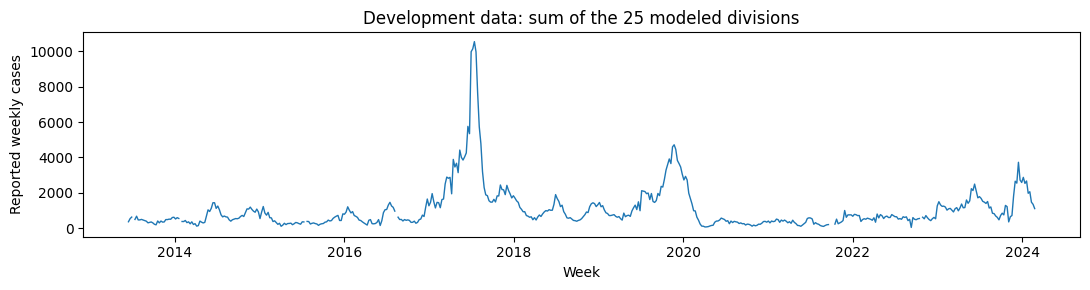

In [6]:
names = sorted(read_json(REPO / "notebooks/baseline/sri_lanka_adj_list.json"))
case_array = np.load(REPO / "data/corrected/rebuilt_cases.npy")
cases = case_array[..., 0] if case_array.ndim == 3 else case_array
index = pd.read_csv(REPO / "data/corrected/rebuilt_index.csv", parse_dates=["week_start"])
missing_week = np.isnan(cases).any(axis=1)
assert cases.shape == (len(index), len(names))
assert np.array_equal(missing_week, index.status.eq("missing")), "Missing flags disagree."
display(
    pd.DataFrame(
        [
            {
                "weeks": len(cases),
                "districts": len(names),
                "missing weeks": int(missing_week.sum()),
                "first date in current index": str(index.week_start.min().date()),
                "last date in current index": str(index.week_start.max().date()),
            }
        ]
    )
)
example = pd.DataFrame(cases[:5], columns=names, index=index.week_start.iloc[:5])
display(example[["Colombo", "Gampaha", "Ampara"]])
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(index.week_start, np.where(missing_week, np.nan, np.nansum(cases, axis=1)), lw=1)
ax.set(
    title="Development data: sum of the 25 modeled divisions",
    xlabel="Week",
    ylabel="Reported weekly cases",
)
fig.tight_layout()
plt.show()

### How the original benchmark was audited

The old array lacks a date axis. The original audit matched each 25-district vector
against the report table, then compared weather against ERA5 at several offsets.
`30_audit.py` in the embedded source snapshots contains that calculation.
Here we show the **retained audit log**, explicitly labeled; reading this log does
not independently repeat PDF extraction or the ERA5 alignment test.

In [7]:
historical_log = (KAGGLE / "notebook_output.txt").read_text(encoding="utf-8", errors="replace")
audit_lines = [
    line
    for line in historical_log.splitlines()
    if any(
        term in line
        for term in [
            "rows 0-47",
            "rows from 2023",
            "array temperature",
            "'lag 12'",
            "array row 395",
            "row A (",
            "row B (",
            "integrity:",
        ]
    )
]
print("RETAINED EXP-050 LOG — not a new audit run")
print("\n".join(audit_lines))
corrections = read_json(REPO / "data/external/report_corrections.json")
display(
    Markdown(
        "The correction evidence is also recorded in `data/external/report_corrections.json`. "
        "The printed row sums to 7,165 over the modeled divisions; the corrected modeled total is 349. "
        "Including Kalmunai gives 351. These totals refer to different geographic coverage."
    )
)

RETAINED EXP-050 LOG — not a new audit run
row A (printed 'cases this week'): districts sum 7,165, national cell 35, 15/24 cells = sum of the two before
row B (year to date = week 1):     districts + Kalmunai = 351 = national 351
integrity: districts + Kalmunai equal the Unit's own national total in 432 of 552 reports
rows 0-47 are dated 2022-12-24 .. 2023-11-18; rows 51 onward run 2013-05-15 .. 2022-03-26
  benchmark fold 0.55: 45 rows from 2023 in TRAINING; test rows dated 2018-03 .. 2019-07
  benchmark fold 0.7: 45 rows from 2023 in TRAINING; test rows dated 2019-07 .. 2020-10
  benchmark fold 0.85: 45 rows from 2023 in TRAINING; test rows dated 2020-11 .. 2022-03
array temperature vs ERA5: best at climate row 0 = 2013-05-19 (r = 0.951); on the dates the CASE rows carry, r = 0.445
'lag 12' precipitation channel vs ERA5 rain later by k weeks: best at k = +12 (r = 0.681); at the documented k = -12, r = 0.186
array row 395: districts sum 7,165 (printed row A 7,165); the corrected week 

The correction evidence is also recorded in `data/external/report_corrections.json`. The printed row sums to 7,165 over the modeled divisions; the corrected modeled total is 349. Including Kalmunai gives 351. These totals refer to different geographic coverage.

### Recalculate the source-table and benchmark-array audit locally

This section performs new calculations from the available source CSV,
benchmark array and 25 daily ERA5 files. It rebuilds the district-week
cases, dates the array by matching case vectors, checks whether future
years enter training, and searches the weather alignment and lag sign.
It trains no model and downloads nothing. The original implementation
runs in a separate namespace; its plot and source inventory go to a
fresh folder under `runs/icitr_notebook/`.

**Two retained inputs remain explicit.** The correction's row A and
row B come from `report_corrections.json`; the original PDF is not
extracted here. For comparison with EXP-050, the array audit uses the
historical dates in `full_paper/data/rebuilt_cases_weekly.csv`, including
the eight dates later fixed by EXP-062. Those dates do not change the
case-vector matches or imply that the old calendar should be used for
new training. Missing local inputs are reported as unavailable.

In [8]:
import shutil
import tempfile

array_audit_assets = {
    "cases/output_Dengue Fever.csv": REPO / "full_paper/data/dengue_cases_raw.csv",
    "benchmark/sri_lanka_2013-2022_shifted.npy": REPO / "notebooks/baseline/sri_lanka_2013-2022_shifted.npy",
    "historical_cases_weekly.csv": REPO / "full_paper/data/rebuilt_cases_weekly.csv",
    "report_corrections.json": REPO / "data/external/report_corrections.json",
}
array_audit_assets.update({
    f"climate/{name}.json": REPO / "data/raw/era5_openmeteo" / f"{name}.json"
    for name in names
})
array_audit_missing = [str(path.relative_to(REPO)) for path in array_audit_assets.values()
                       if not path.is_file()]
array_audit_ready = not array_audit_missing
array_audit_namespace = None
if not array_audit_ready:
    display(Markdown("**Local source/array audit unavailable.** Missing inputs: "
                     + ", ".join(f"`{path}`" for path in array_audit_missing)
                     + ". No successful recalculation is claimed for this section."))
else:
    array_audit_root = Path(tempfile.mkdtemp(prefix="array_audit_", dir=RUN_DIR)).resolve()
    array_audit_root.relative_to(RUN_DIR.resolve())
    array_audit_source = array_audit_root / "inputs"
    array_audit_output = array_audit_root / "outputs"
    array_audit_output.mkdir(parents=True)
    array_audit_inventory = []
    for relative, original in array_audit_assets.items():
        target = array_audit_source / relative
        target.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(original, target)
        array_audit_inventory.append({
            "copied_as": relative,
            "local_source": original.relative_to(REPO).as_posix(),
            "bytes": target.stat().st_size,
            "sha256_now": hashlib.sha256(target.read_bytes()).hexdigest(),
        })
    graph_path = array_audit_source / "graph/sri_lanka_adj_list.json"
    graph_path.parent.mkdir()
    graph_path.write_text(json.dumps(HISTORICAL_GRAPH, indent=2), encoding="utf-8")
    array_audit_inventory.append({
        "copied_as": "graph/sri_lanka_adj_list.json",
        "local_source": "embedded historical graph from git 3878e70^",
        "bytes": graph_path.stat().st_size,
        "sha256_now": hashlib.sha256(graph_path.read_bytes()).hexdigest(),
    })
    pd.DataFrame(array_audit_inventory).to_csv(array_audit_root / "input_inventory.csv", index=False)

    array_audit_namespace = {
        "__name__": "icitr_local_array_audit",
        "SRC": array_audit_source, "OUT": array_audit_output,
        "np": np, "pd": pd, "plt": plt, "json": json,
        "ORIGINS": (0.55, 0.70, 0.85),
        "rmse": lambda predicted, actual: float(np.sqrt(np.mean(
            (np.asarray(predicted) - np.asarray(actual)) ** 2))),
    }
    data_source = MODULE_SOURCES["full_paper/kaggle/src/20_data.py"]
    # Reuse only the CSV parsing/mapping, ending before PDF extraction.
    csv_prefix = data_source.split("import pymupdf", 1)[0]
    exec(compile(csv_prefix, "embedded_case_table_prefix.py", "exec"), array_audit_namespace)
    correction = json.loads((array_audit_source / "report_corrections.json").read_text(encoding="utf-8"))[0]
    table_corrected = array_audit_namespace["table"].copy()
    correction_year = int(correction["report"]["year"])
    correction_number = int(correction["report"]["number"])
    for district, value in correction["replacement"].items():
        selected = (table_corrected.year.eq(correction_year)
                    & table_corrected.week_no.eq(correction_number)
                    & table_corrected.district.eq(district))
        table_corrected.loc[selected, "cases"] = value
    array_audit_namespace["tab"] = table_corrected
    # The original grid construction, without its date/PDF/weather code.
    grid_source = data_source[data_source.index('last_no = tab.groupby'):]
    grid_source = grid_source.split('dates = report_dates', 1)[0]
    exec(compile(grid_source, "embedded_week_grid.py", "exec"), array_audit_namespace)
    rebuilt_source_cases = array_audit_namespace["wide"].to_numpy(dtype=float)
    assert array_audit_namespace["NAMES"] == names
    check_close("source CSV plus retained correction reproduces corrected cases",
                rebuilt_source_cases, cases,
                "raw CSV -> original district mapping/grid + retained correction", atol=0)
    historical_case_table = pd.read_csv(array_audit_source / "historical_cases_weekly.csv",
                                        parse_dates=["week_start"])
    check_close("historical date table carries the same weekly case counts",
                historical_case_table[names].to_numpy(dtype=float), rebuilt_source_cases,
                "historical date-table counts vs independently rebuilt source cases", atol=0)
    historical_dates = historical_case_table.week_start
    assert len(historical_dates) == len(rebuilt_source_cases) and historical_dates.notna().all()
    array_audit_namespace.update(
        T=len(rebuilt_source_cases), CASES=rebuilt_source_cases,
        MISSING=~array_audit_namespace["observed"], WEEK_START=historical_dates,
    )
    # Preserve the report's printed column order. These are retained
    # transcriptions, not newly extracted PDF contents.
    report_columns = ["Colombo", "Gampaha", "Kalutara", "Kandy", "Matale", "NuwaraEliya",
                      "Galle", "Hambantota", "Matara", "Jaffna", "Kilinochchi", "Mannar",
                      "Vavuniya", "Mullaitivu", "Batticaloa", "Ampara", "Trincomalee",
                      "Kurunegala", "Puttalam", "Anuradhapura", "Polonnaruwa", "Badulla",
                      "Moneragala", "Ratnapura", "Kegalle", "Kalmunai", "SRILANKA"]
    array_audit_namespace["row_a"] = [correction["published_row_A"][name] for name in report_columns]
    array_audit_namespace["row_b"] = [correction["published_row_B"][name] for name in report_columns]
    print("New source-table reconstruction complete; original correction PDF not re-parsed.")
    print("Isolated audit folder:", array_audit_root)

source table: 14,931 rows -> 552 reports x 25 districts
New source-table reconstruction complete; original correction PDF not re-parsed.
Isolated audit folder: C:\Users\ASUS\Desktop\dengue-forecasting\runs\icitr_notebook\array_audit_bxmmw_rh


FRESH LOCAL ARRAY/WEATHER CALCULATION; retained correction rows and historical dates identified above
benchmark array: (459, 25, 11) (rows, districts, channels)
rows matched exactly to a published report: 454 of 459; unmatched rows: [48, 49, 50, 54, 434]
identical consecutive rows (one week stored twice): [444]
rows 0-47 are dated 2022-12-24 .. 2023-11-18; rows 51 onward run 2013-05-15 .. 2022-03-26
reports inside the array's 2013-2022 span that never reached it: 48
  benchmark fold 0.55: 45 rows from 2023 in TRAINING; test rows dated 2018-03 .. 2019-07
  benchmark fold 0.7: 45 rows from 2023 in TRAINING; test rows dated 2019-07 .. 2020-10
  benchmark fold 0.85: 45 rows from 2023 in TRAINING; test rows dated 2020-11 .. 2022-03


array temperature vs ERA5: best at climate row 0 = 2013-05-19 (r = 0.951); on the dates the CASE rows carry, r = 0.445


'lag 12' precipitation channel vs ERA5 rain later by k weeks: best at k = +12 (r = 0.681); at the documented k = -12, r = 0.186


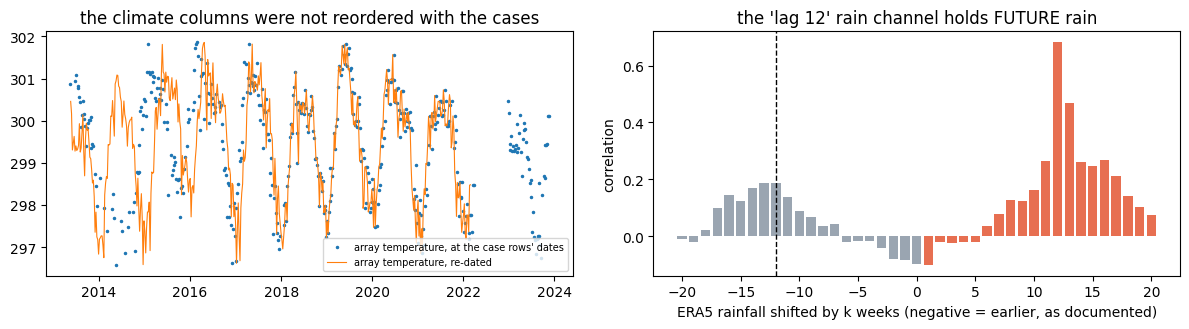

array row 395: districts sum 7,165 (printed row A 7,165); the corrected week sums to 349
persistence on the array (mean over the 3 origins): 44.80 over all test windows, 29.52 without the windows touching row 395


,origin,2023 rows in training
0,0.5500,45
1,0.7000,45
2,0.8500,45


,calculation,fresh correlation,retained rounded correlation
0,temperature on its own timeline,0.9513,0.9510
1,temperature on case-row dates,0.4447,0.4450
2,rainfall twelve weeks later,0.6811,0.6810
3,rainfall twelve weeks earlier,0.1857,0.1860


Fresh benchmark persistence RMSE (all / excluding artifact-touching windows): [44.79531573 29.52100971]
Fresh audit plot and CSVs: C:\Users\ASUS\Desktop\dengue-forecasting\runs\icitr_notebook\array_audit_bxmmw_rh\outputs


In [9]:
if array_audit_ready:
    print("FRESH LOCAL ARRAY/WEATHER CALCULATION; retained correction rows and historical dates identified above")
    exec(compile(MODULE_SOURCES["full_paper/kaggle/src/30_audit.py"],
                 "embedded_benchmark_array_audit.py", "exec"), array_audit_namespace)
    audit = array_audit_namespace
    source_label = "local raw source table + benchmark array + daily ERA5 -> embedded 30_audit.py"
    check_close("array vectors matched to source reports", int(audit["matched"].sum()), 454,
                source_label, atol=0)
    check_close("unmatched benchmark rows", np.flatnonzero(~audit["matched"]), [48, 49, 50, 54, 434],
                source_label, atol=0)
    check_close("duplicated consecutive benchmark rows", audit["dups"], [444], source_label, atol=0)
    check_close("artifact benchmark row index", audit["k395"], 395, source_label, atol=0)
    check_close("artifact modeled-division total", audit["arr_cases"][audit["k395"]].sum(), 7165,
                "benchmark array; raw CSV match identifies report", atol=0)
    check_close("artifact case vector matches retained printed row A",
                audit["arr_cases"][audit["k395"]],
                [correction["published_row_A"][name] for name in audit["NAMES"]],
                "benchmark array vs retained printed-row transcription", atol=0)
    check_close("corrected modeled-division total", sum(audit["row_b"][:25]), 349,
                "retained correction row B; not fresh PDF extraction", atol=0)
    formula_cells_now = sum(abs(audit["row_a"][k] - audit["row_a"][k-1] - audit["row_a"][k-2]) <= 1
                            for k in range(2, 26))
    check_close("dragged-formula pattern cells", formula_cells_now, 15,
                "new arithmetic on retained printed-row transcription", atol=0)
    leak_rows = []
    for origin in audit["ORIGINS"]:
        cut = int(origin * len(audit["ids"]))
        training_starts = audit["ids"][:cut-30]
        future_rows = sum(audit["row_year"].iloc[row] == 2023 for row in training_starts)
        leak_rows.append({"origin": origin, "2023 rows in training": future_rows})
        check_close(f"benchmark origin {origin}: future-year rows in training", future_rows, 45,
                    source_label, atol=0)
    display(pd.DataFrame(leak_rows))
    check_close("rainfall lag-sign peak", audit["peak"], 12, source_label, atol=0)
    retained_log = (REPO / "full_paper/outputs/kaggle_run/notebook_output.txt").read_text(encoding="utf-8")
    temp_reference = re.search(r"array temperature vs ERA5:.*?r = ([0-9.]+).*?r = ([0-9.]+)", retained_log)
    rain_reference = re.search(r"best at k = \+12 \(r = ([0-9.]+)\); at the documented k = -12, r = ([0-9.]+)", retained_log)
    if temp_reference is None or rain_reference is None:
        raise ValueError("Expected historical weather-audit comparison lines were not found.")
    # Historical correlations were printed to three decimal places.
    # The comparison therefore allows half a unit at that precision.
    weather_values = [audit["r_best"], audit["r_case"], max(audit["r_shift"]),
                      audit["r_shift"][audit["shifts"].index(-12)]]
    weather_references = [float(temp_reference.group(1)), float(temp_reference.group(2)),
                          float(rain_reference.group(1)), float(rain_reference.group(2))]
    weather_labels = ["temperature on its own timeline", "temperature on case-row dates",
                      "rainfall twelve weeks later", "rainfall twelve weeks earlier"]
    weather_results = pd.DataFrame({"calculation": weather_labels,
                                    "fresh correlation": weather_values,
                                    "retained rounded correlation": weather_references})
    display(weather_results)
    for label, value, reference in zip(weather_labels, weather_values, weather_references):
        check_close("weather audit: " + label, value, reference,
                    source_label + "; historical three-decimal log as comparison", atol=0.00050001)
    recorded_summary = json.loads((REPO / "full_paper/outputs/kaggle_run/results.json").read_text(encoding="utf-8"))
    check_close("benchmark array persistence floor", audit["ARRAY_FLOOR"],
                [recorded_summary["array_floor"]["all_windows"],
                 recorded_summary["array_floor"]["without_row_395"]],
                "new benchmark-array persistence predictions vs retained summary", atol=1e-8)
    weather_results.to_csv(array_audit_output / "weather_alignment.csv", index=False)
    pd.DataFrame(leak_rows).to_csv(array_audit_output / "future_rows_in_training.csv", index=False)
    print("Fresh benchmark persistence RMSE (all / excluding artifact-touching windows):", audit["ARRAY_FLOOR"])
    print("Fresh audit plot and CSVs:", array_audit_output)

## 4. Why there are different RMSE numbers

There are **three separate sets of evaluation weeks** in the current story:

| Experiment | Model example | Persistence on the same evaluation | Used for |
|---|---|---|---|
| EXP-050, 3 origins × 3 seeds | AAGCN + PAGE | about 36.02 | Tables I, II, IV |
| EXP-063, 9 purged development origins | adaptive PAGE + SEIR | about 28.54 | validation tuning, development comparison |
| EXP-063, later weeks, 85 starts | adaptive PAGE + SEIR | about 34.75 | Table III |

EXP-050 also has an older nine-origin confirmation group; it is **not** the purged
EXP-063 group. Scores from different groups cannot establish which model is better.

**RMSE calculation:** square each prediction error, average across all windows,
districts and horizons, and take the square root. This gives one RMSE per run.
Paper tables then average those run RMSEs. We do not average RMSEs of individual
windows, and do not pool all runs before taking a square root.

In [10]:
def rmse(prediction, truth):
    return float(np.sqrt(np.mean((np.asarray(prediction) - np.asarray(truth)) ** 2)))


toy_truth = np.array([10, 20, 40])
toy_forecast = np.array([10, 20, 20])
print("Teaching example only (not experimental data):", rmse(toy_forecast, toy_truth))


def historical_folds():
    # This reproduces EXP-050's original unpurged partition of forecast starts.
    # Splitting start indices does not purge the overlapping three-week targets.
    ids = list(range(3, len(cases) - 3))
    output = []
    for origin in (0.55, 0.70, 0.85):
        cut = int(origin * len(ids))
        end = int(min(origin + 0.15, 1.0) * len(ids))
        parts = {"train": ids[: cut - 30], "val": ids[cut - 30 : cut], "test": ids[cut:end]}
        parts = {
            key: np.array([i for i in starts if not missing_week[i - 3 : i + 3].any()], dtype=int)
            for key, starts in parts.items()
        }
        output.append((origin, parts))
    return output


split_rows = []
baseline_rows = []
for origin, parts in historical_folds():
    for split, starts in parts.items():
        split_rows.append(
            {
                "origin": origin,
                "split": split,
                "windows": len(starts),
                "first target start": str(index.week_start.iloc[starts[0]].date()),
                "last target start": str(index.week_start.iloc[starts[-1]].date()),
            }
        )
        if split in ("val", "test"):
            # Original implementation scores torch.float32 tensors.
            truth = np.stack([cases[i : i + 3].T for i in starts]).astype(np.float32)
            prediction = np.repeat(cases[starts - 1, :, None], 3, axis=2).astype(np.float32)
            baseline_rows.append(
                {"origin": origin, "split": split, "recomputed RMSE": rmse(prediction, truth)}
            )
display(pd.DataFrame(split_rows))
baseline_check = pd.DataFrame(baseline_rows)
for row in baseline_check.to_dict("records"):
    metric = "val_RMSE" if row["split"] == "val" else "RMSE"
    saved = r3.loc[r3.name.eq("persistence") & r3.origin.eq(row["origin"]), metric].item()
    check_close(
        f"EXP-050 persistence {row['origin']} {row['split']}",
        row["recomputed RMSE"],
        saved,
        "derived cases → historical fold → predictions → RMSE",
        atol=2e-5,
    )
display(baseline_check)

Teaching example only (not experimental data): 11.547005383792516


,origin,split,windows,first target start,last target start
0,0.5500,train,252,2013-08-03,2018-09-29
1,0.5500,val,30,2018-10-06,2019-04-27
2,0.5500,test,83,2019-05-04,2020-11-28
3,0.7000,train,335,2013-08-03,2020-05-02
4,0.7000,val,30,2020-05-09,2020-11-28
5,0.7000,test,75,2020-12-05,2022-07-02
6,0.8500,train,410,2013-08-03,2021-12-04
7,0.8500,val,30,2021-12-11,2022-07-02
8,0.8500,test,77,2022-07-09,2024-02-03


,origin,split,recomputed RMSE
0,0.5500,val,19.8850
1,0.5500,test,38.9510
2,0.7000,val,11.7222
3,0.7000,test,22.4024
4,0.8500,val,21.9610
5,0.8500,test,46.6938


**Historical split limitation:** EXP-050 separates forecast starts but does not
purge the overlapping three-week target dates at partition boundaries. This notebook
reproduces that protocol rather than calling it strictly leakage-free. EXP-063 uses
purged partitions. Long climate lags also remove early training windows, and the
reduced-training-data arms intentionally use less training data.

Seeds repeat model training, not independent outbreaks. A 9-pair sign-flip test
across 3 origins × 3 seeds describes training stability; it does not give nine
independent time periods. The prospective block bootstrap addresses dependence
across adjacent forecast starts, subject to its own block-length assumptions.

## 5. What PAGE changes

A **direct head** predicts the future case level. A **residual head** starts from
the latest observed week and learns a correction. **PAGE** also learns a scalar
gate that shrinks the departure toward persistence. The **PAGE + SEIR** variant
generates that departure using a differentiable epidemic simulator.

In standardized log-case space the gated head is
$\hat z = p + \sigma(a)(u-p)$, where $p$ repeats the last observed week.
At initialization $a=-2$, so $\sigma(a)\approx0.119$.
The encoder is still a trained neural network; the persistence anchor is a fixed
reference value, not a replacement for training. Table I uses squared error;
NB likelihood is a separate ablation. PAGE is **not automatically an NB model**.

In [11]:
gate = 1 / (1 + np.exp(2))
print(f"Initial gate: {gate:.6f}")
print("Illustration in standardized log space: p=2, u=3 -> PAGE prediction", 2 + gate * (3 - 2))
head_names = pd.DataFrame(
    [
        {"saved head": "direct", "paper name": "direct", "meaning": "predict level"},
        {
            "saved head": "residual",
            "paper name": "residual",
            "meaning": "anchor + learned correction",
        },
        {"saved head": "gated", "paper name": "PAGE", "meaning": "p + sigmoid(a) * (u - p)"},
        {
            "saved head": "foi",
            "paper name": "pure SEIR decoder",
            "meaning": "whole forecast through simulator",
        },
        {
            "saved head": "foi_res",
            "paper name": "PAGE + SEIR",
            "meaning": "gated simulator departure",
        },
    ]
)
display(head_names)

Initial gate: 0.119203
Illustration in standardized log space: p=2, u=3 -> PAGE prediction 2.1192029220221174


,saved head,paper name,meaning
0,direct,direct,predict level
1,residual,residual,anchor + learned correction
2,gated,PAGE,p + sigmoid(a) * (u - p)
3,foi,pure SEIR decoder,whole forecast through simulator
4,foi_res,PAGE + SEIR,gated simulator departure


### What happens in one neural training run

1. Cut the fold's eligible windows: 3 observed weeks × 25 districts predict the
   next 3 weeks. Fit the log-count mean and standard deviation on training history.
   Transform each count with $z=(\log(1+y)-\mu)/s$.
2. Send those windows through the chosen encoder and head. Graph encoders mix
   information across districts; the LSTM provides the non-graph comparison.
3. Update weights with Adam and cosine learning-rate decay. For the main head
   comparison, minimize squared error in standardized log space.
4. After each epoch, convert forecasts back to counts and calculate validation
   RMSE. Stop after 40 epochs without improvement, or at the 300-epoch budget.
   Restore the weights with the lowest validation RMSE.
5. Score those weights on the test windows and save one row. Repeat for each
   origin and seed, then average the saved RMSEs to obtain the table cells.

The next cell **reads** the actual training defaults; it does not train. The
configuration grid can override them: for example, NB/season arms use 400 epochs,
and EXP-063 tunes learning rate and hidden width using validation only.

In [12]:
training_tree = ast.parse(MODULE_SOURCES["full_paper/kaggle/src/60_training.py"])
training_definition = next(
    node
    for node in training_tree.body
    if isinstance(node, ast.FunctionDef) and node.name == "run_fold"
)
training_defaults = {
    argument.arg: ast.literal_eval(value)
    for argument, value in zip(
        training_definition.args.kwonlyargs, training_definition.args.kw_defaults
    )
    if value is not None
}
display(
    pd.DataFrame(
        [
            {"setting": name, "EXP-050 default": training_defaults[name]}
            for name in [
                "hidden",
                "layers",
                "dropout",
                "lr",
                "weight_decay",
                "batch_size",
                "epochs",
                "patience",
            ]
        ]
    )
)

,setting,EXP-050 default
0,hidden,64.0000
1,layers,2.0000
2,dropout,0.1000
3,lr,0.0030
4,weight_decay,0.0001
5,batch_size,32.0000
6,epochs,300.0000
7,patience,40.0000


## 6. Table I: encoder and baseline comparison

Each cell below is **mean validation RMSE / mean test RMSE** from the stored
per-run rows. We recompute the average rather than type the published numbers.
Here `gated` is PAGE and `foi_res` is PAGE + SEIR. The same name “adaptive” in
EXP-063 refers to another encoder, not to AAGCN.

In [13]:
def mean_score(frame, name, metric="val_RMSE"):
    values = frame.loc[frame.name.eq(name), metric]
    if values.empty:
        raise KeyError(f"No rows for {name!r}")
    return float(values.mean())


comparison = pd.DataFrame(
    {
        label: [
            f"{mean_score(r3, e + '+' + head):.2f} / {mean_score(r3, e + '+' + head, 'RMSE'):.2f}"
            for e in ENCODERS
        ]
        for head, label in [("direct", "Direct"), ("gated", "PAGE"), ("foi_res", "PAGE + SEIR")]
    },
    index=ENCODERS,
)
comparison.index.name = "Encoder"
display(comparison)
baseline_names = [
    "persistence",
    "graph=none",
    "graph=gcn",
    "R3 STID-style MLP",
    "R4b k-NN",
    "R4a NB-GLM",
    "K7 trees",
    "K6 trees + climate",
    "B",
]
baselines = pd.DataFrame(
    [
        {
            "saved name": name,
            "validation RMSE": mean_score(r3, name),
            "test RMSE": mean_score(r3, name, "RMSE"),
            "status": "DATE-JOIN RECHECK PENDING"
            if name in ["B", "K6 trees + climate", "R3 STID-style MLP", "R4a NB-GLM"]
            else "historical result",
        }
        for name in baseline_names
    ]
)
display(baselines)
comparison.to_csv(RUN_DIR / "table_I_encoders.csv")
baselines.to_csv(RUN_DIR / "table_I_baselines.csv", index=False)
print("One concrete run, before averaging:")
display(
    r3.loc[
        r3.name.eq("AAGCN+gated"),
        ["origin", "seed", "val_RMSE", "RMSE", "best_epoch", "epochs_ran"],
    ]
)

,Direct,PAGE,PAGE + SEIR
Encoder,,,
AAGCN,16.71 / 35.15,16.57 / 33.53,17.43 / 35.58
ASTGCN,16.83 / 35.61,16.76 / 34.76,17.51 / 35.71
LSTM,16.91 / 35.10,16.94 / 35.85,17.69 / 35.52
STGAT,22.93 / 62.00,16.98 / 36.46,17.63 / 35.84
A3TGCN,28.63 / 60.40,17.68 / 37.16,17.68 / 35.50
DCRNN,34.64 / 73.52,18.35 / 39.02,17.67 / 35.52


,saved name,validation RMSE,test RMSE,status
0,persistence,17.8561,36.0157,historical result
1,graph=none,16.8998,34.5728,historical result
2,graph=gcn,16.8375,34.5010,historical result
3,R3 STID-style MLP,16.3528,36.3268,DATE-JOIN RECHECK PENDING
4,R4b k-NN,16.5151,34.3428,historical result
5,R4a NB-GLM,16.9689,42.8487,DATE-JOIN RECHECK PENDING
6,K7 trees,17.9395,38.9606,historical result
7,K6 trees + climate,17.4009,36.4904,DATE-JOIN RECHECK PENDING
8,B,15.5098,37.5431,DATE-JOIN RECHECK PENDING


One concrete run, before averaging:


,origin,seed,val_RMSE,RMSE,best_epoch,epochs_ran
250,0.5500,0,19.1719,37.4819,51.0000,91.0000
253,0.7000,0,11.6157,20.2460,16.0000,56.0000
254,0.5500,1,18.7315,36.5829,92.0000,132.0000
255,0.7000,1,11.4719,20.5048,20.0000,60.0000
256,0.5500,2,18.5520,37.7899,74.0000,114.0000
257,0.7000,2,11.4967,20.4928,21.0000,61.0000
258,0.8500,0,19.5005,43.0235,61.0000,101.0000
259,0.8500,2,19.2953,43.0274,63.0000,103.0000
260,0.8500,1,19.2757,42.6317,84.0000,124.0000


## 7. Table II: ablation and paired comparisons

Changing one component while keeping the encoder and evaluation fixed tests where
a gain comes from. **Negative difference means the first model has lower error.**
A “win” is one matched (origin, seed) pair with lower RMSE. Persistence has one
deterministic score per origin, reused for each seed; it was not trained three times.
We require a complete match and stop on missing pairs.

In [14]:
def paired_differences(frame, arm, control, metric="val_RMSE"):
    arm_rows = frame.loc[frame.name.eq(arm), ["origin", "seed", metric]]
    ref_rows = frame.loc[frame.name.eq(control), ["origin", "seed", metric]]
    if arm_rows.empty or ref_rows.empty:
        raise ValueError(f"Missing arm/control: {arm}, {control}")
    join_keys = ["origin"] if ref_rows.seed.lt(0).all() else ["origin", "seed"]
    matched = arm_rows.merge(
        ref_rows[[*join_keys, metric]],
        on=join_keys,
        how="left",
        suffixes=("_arm", "_control"),
        validate="many_to_one",
    )
    if len(matched) != len(arm_rows) or matched[f"{metric}_control"].isna().any():
        raise ValueError("Incomplete pairs; refusing to drop missing matches.")
    matched = matched.sort_values(["origin", "seed"])
    return (matched[f"{metric}_arm"] - matched[f"{metric}_control"]).to_numpy()


def sign_flip(values):
    values = np.asarray(values, dtype=float)
    signs = np.array(list(itertools.product([-1, 1], repeat=len(values))), dtype=float)
    return float(np.mean(np.abs(signs @ values / len(values)) >= abs(values.mean()) - 1e-12))


def bh_adjust(pvalues):
    pvalues = np.asarray(pvalues, dtype=float)
    order = np.argsort(pvalues)
    adjusted = np.empty(len(order))
    ceiling = 1.0
    for rank_index in range(len(order) - 1, -1, -1):
        pos = order[rank_index]
        ceiling = min(ceiling, pvalues[pos] * len(order) / (rank_index + 1))
        adjusted[pos] = ceiling
    return adjusted


ablation = pd.DataFrame(
    {
        label: [mean_score(r3, e + "+" + head) for e in ENCODERS]
        for head, label in [
            ("direct", "Direct"),
            ("residual", "Residual"),
            ("gated", "PAGE"),
            ("foi_res", "PAGE + SEIR"),
        ]
    },
    index=ENCODERS,
)
display(ablation)
paired_rows = []
for encoder in ENCODERS:
    for control in [encoder + "+direct", "persistence"]:
        for metric in ["val_RMSE", "RMSE"]:
            delta = paired_differences(r3, encoder + "+gated", control, metric)
            assert len(delta) == 9
            paired_rows.append(
                {
                    "encoder": encoder,
                    "control": control,
                    "metric": metric,
                    "mean difference": delta.mean(),
                    "wins": f"{(delta < 0).sum()}/9",
                    "p_raw": sign_flip(delta),
                }
            )
paired = pd.DataFrame(paired_rows)
paired["p_BH_24_comparisons"] = bh_adjust(paired.p_raw)
display(paired)
rescue_rows = []
for encoder in ENCODERS:
    dv = paired_differences(r3, encoder + "+foi_res", encoder + "+gated")
    dt = paired_differences(r3, encoder + "+foi_res", encoder + "+gated", "RMSE")
    rescue_rows.append(
        {
            "encoder": encoder,
            "SEIR - PAGE (val)": dv.mean(),
            "val wins": int((dv < 0).sum()),
            "p_raw": sign_flip(dv),
            "SEIR - PAGE (test)": dt.mean(),
            "test wins": int((dt < 0).sum()),
        }
    )
rescue = pd.DataFrame(rescue_rows)
failing = rescue.encoder.isin(["STGAT", "A3TGCN", "DCRNN"])
rescue.loc[failing, "p_BH_failing_3"] = bh_adjust(rescue.loc[failing, "p_raw"])
rescue["passes_physics_rule"] = (
    failing
    & rescue["SEIR - PAGE (val)"].lt(0)
    & rescue["val wins"].ge(7)
    & rescue.p_BH_failing_3.lt(0.05)
)
display(rescue)
ablation.to_csv(RUN_DIR / "table_II_ablation.csv")
paired.to_csv(RUN_DIR / "paired_PAGE.csv", index=False)

,Direct,Residual,PAGE,PAGE + SEIR
AAGCN,16.7091,16.7183,16.5679,17.4308
ASTGCN,16.8256,16.8520,16.7577,17.5078
LSTM,16.9063,16.9553,16.9397,17.6855
STGAT,22.9318,17.8482,16.9769,17.6331
A3TGCN,28.6304,17.4737,17.6816,17.6787
DCRNN,34.6368,17.5205,18.3517,17.6722


,encoder,control,metric,mean difference,wins,p_raw,p_BH_24_comparisons
0,AAGCN,AAGCN+direct,val_RMSE,-0.1412,6/9,0.2578,0.3306
1,AAGCN,AAGCN+direct,RMSE,-1.6159,9/9,0.0039,0.0085
2,AAGCN,persistence,val_RMSE,-1.2882,9/9,0.0039,0.0085
3,AAGCN,persistence,RMSE,-2.4845,9/9,0.0039,0.0085
4,ASTGCN,ASTGCN+direct,val_RMSE,-0.0679,7/9,0.4102,0.4688
5,ASTGCN,ASTGCN+direct,RMSE,-0.8509,6/9,0.1016,0.1523
6,ASTGCN,persistence,val_RMSE,-1.0984,9/9,0.0039,0.0085
7,ASTGCN,persistence,RMSE,-1.2599,8/9,0.0078,0.0156
8,LSTM,LSTM+direct,val_RMSE,0.0334,3/9,0.2617,0.3306
9,LSTM,LSTM+direct,RMSE,0.7496,2/9,0.0547,0.0938


,encoder,SEIR - PAGE (val),val wins,p_raw,SEIR - PAGE (test),test wins,p_BH_failing_3,passes_physics_rule
0,AAGCN,0.8629,1,0.0078,2.0502,0,NaN,False
1,ASTGCN,0.7501,0,0.0039,0.9537,3,NaN,False
2,LSTM,0.7458,0,0.0039,-0.3257,6,NaN,False
3,STGAT,0.6562,1,0.0078,-0.6194,8,0.0234,False
4,A3TGCN,-0.0029,6,0.9844,-1.6551,9,0.9844,False
5,DCRNN,-0.6796,3,0.2500,-3.5018,9,0.3750,False


The adjustment family matters: the PAGE-versus-direct table uses 24 comparisons;
the physics-credit test adjusts over the three failing encoders. We keep both
families explicit. Failure to detect a difference does **not** establish equivalence
or prove that epidemic physics can never help.

## 8. Other levers: loss, climate, graph and augmentation

The stored lever table tells us each arm and its matched control. We recalculate
every difference, win count, exact sign-flip p-value and BH adjustment from the run
rows, then compare to that CSV. The NB result belongs to model B with seasonal
features; it is **not** the squared-error PAGE result in Table I.

In [15]:
stored_levers = pd.read_csv(KAGGLE / "levers.csv")
lever_rows = []
for row in stored_levers.to_dict("records"):
    dv = paired_differences(r3, row["arm"], row["control"])
    dt = paired_differences(r3, row["arm"], row["control"], "RMSE")
    lever_rows.append(
        {
            "lever": row["lever"],
            "arm": row["arm"],
            "control": row["control"],
            "val delta": dv.mean(),
            "test delta": dt.mean(),
            "wins": f"{(dv < 0).sum()}/{len(dv)}",
            "p": sign_flip(dv),
        }
    )
levers = pd.DataFrame(lever_rows)
levers["p_adj"] = bh_adjust(levers.p)
for metric in ["val delta", "test delta", "p", "p_adj"]:
    check_close(
        "lever recalculation: " + metric,
        levers[metric].to_numpy(),
        stored_levers[metric].to_numpy(),
        "runs.json → matched pairs → levers.csv",
        atol=1e-8,
    )
assert levers.wins.tolist() == stored_levers.wins.tolist()
display(levers[["lever", "val delta", "test delta", "wins", "p_adj"]])
levers.to_csv(RUN_DIR / "recomputed_levers.csv", index=False)
display(
    Markdown(
        "**Reading the NB row:** validation improves by about 0.76 RMSE, but test worsens "
        "by about 1.61. These date-joined configurations remain subject to EXP-062. "
        "Model B follows the historical adoption rule; it is not simply the smallest "
        "validation number or the test winner in Table I."
    )
)

,lever,val delta,test delta,wins,p_adj
0,NB likelihood (vs squared error),-0.7626,1.6078,9/9,0.0137
1,seasonal features,-0.7588,0.6995,6/9,0.1846
2,best model B vs persistence,-2.3462,1.5274,9/9,0.0137
3,graph (GCN vs no message passing),-0.0623,-0.0718,3/9,0.5013
4,learned adjacency,-0.1446,-0.3341,5/9,0.1846
5,district seasonal curves,-0.0524,0.1106,6/9,0.7569
6,nonlinear (MLP) head,0.2777,-0.3102,1/9,0.0273
7,MLP head + climate lags 2-13,0.1346,-0.6978,3/9,0.4822
8,global context node,0.0222,-1.3956,3/9,0.8438
9,residual head + NB,0.4654,-2.9563,2/9,0.2072


**Reading the NB row:** validation improves by about 0.76 RMSE, but test worsens by about 1.61. These date-joined configurations remain subject to EXP-062. Model B follows the historical adoption rule; it is not simply the smallest validation number or the test winner in Table I.

## 9. Diagnostics and retained evidence

These CSVs were computed during the original study. Without `predictions.pkl` we
can inspect and summarize them, but cannot independently regenerate the residual
regressions and correlations from predictions in the default run.
The SEIR-floor diagnostic needs states and simulator inversion; its implementation
is included in the optional complete development run.

Residual recovery uses the **NB + seasonal-feature configuration**, not the direct
squared-error rows in Table I. The 0.91–0.97 correlation range refers to selected
working models (AAGCN, ASTGCN, LSTM, SEIR-LSTM and k-NN), not every model.
High residual correlation suggests shared errors; it does not prove a data ceiling.

In [16]:
recovery = pd.read_csv(KAGGLE / "residual_recovery.csv", index_col=0)
corr = pd.read_csv(KAGGLE / "residual_correlation.csv", index_col=0)
seir_diagnosis = pd.read_csv(KAGGLE / "seir_decoder_diagnosis.csv")
display(Markdown("**Retained diagnostic: validation residual variance recovered by a linear fit**"))
display(recovery)
selected_models = ["AAGCN", "ASTGCN", "LSTM", "SEIR-LSTM", "k-NN"]
pair_corr = [corr.loc[a, b] for a, b in itertools.combinations(selected_models, 2)]
print("Selected working-model pairwise correlation range:", min(pair_corr), "to", max(pair_corr))
display(Markdown("**Retained diagnostic: simulator floor and required force of infection**"))
display(seir_diagnosis)

**Retained diagnostic: validation residual variance recovered by a linear fit**

,validation residual variance a linear model recovers
AAGCN,0.0664
ASTGCN,0.0324
LSTM,0.0626
STGAT,0.4792
A3TGCN,0.6036
SEIR-LSTM,0.0628


Selected working-model pairwise correlation range: 0.9120162938867544 to 0.97212134542868


**Retained diagnostic: simulator floor and required force of infection**

,origin,targets below the lambda=0 floor (%),cells needing lambda = 0 (%),r2 of log lambda* on log cases[t-1],r2 of log cases[t] on log cases[t-1],S at its 0.01 clamp (%)
0,0.5500,14.3439,40.2698,0.2158,0.8056,0.6984
1,0.7000,13.9940,39.4388,0.2542,0.8243,2.4955
2,0.8500,16.3057,41.1122,0.2588,0.8237,4.8585


### Persistence predictability: clarify what r² means here

The implementation in `80_analysis.py` calculates **squared pooled Pearson
correlation on raw counts**. Some older descriptions call it log-case r²; that
wording does not match the code. This is a pooled association across districts
and time, not an out-of-sample R² score and not a causal effect of weather.
The available case array allows a new calculation of the lag-one figure.
The weather figure below is labeled as retained, because the current date-aligned
weather array differs from the one used for EXP-050 (EXP-062 is pending).

In [17]:
valid = np.isfinite(cases[:-1]) & np.isfinite(cases[1:])
lag_one_r2 = float(np.corrcoef(cases[:-1][valid], cases[1:][valid])[0, 1] ** 2)
historical_summary = read_json(KAGGLE / "results.json")
check_close(
    "raw-count lag-one pooled Pearson r²",
    lag_one_r2,
    historical_summary["r2_lag1"],
    "derived cases → paired raw counts → corrcoef squared",
    atol=1e-10,
)
print("Recomputed raw-count lag-one r²:", lag_one_r2)
print(
    "Retained best climate r² (old alignment; pending recheck):",
    historical_summary["r2_best_climate"],
)

Recomputed raw-count lag-one r²: 0.8893102643909847
Retained best climate r² (old alignment; pending recheck): 0.029095072714965566


## 10. Table III: amended prospective evaluation, 2024–2026

The neural encoder here is adaptive (Graph WaveNet-style). All three heads use
fixed settings chosen on development validation. Each has three seeds; persistence,
seasonal naive and AR(3) are deterministic and have one row each.
The table below averages **per-seed metrics**, matching the paper's table builder.
MAE/SMAPE/MAPE are secondary; no significance claim is made for their differences.
The evaluation is amended run 2, not an untouched prospective trial.

In [18]:
final = read_json(PROSPECTIVE / "prospective_final.json")
final_rows = pd.DataFrame(final["rows"])
saved_stats = read_json(PROSPECTIVE / "prospective_stats.json")
assert len(final["test_starts"]) == final["n_test"]
prospective_table = final_rows.groupby("name", sort=False)[
    ["RMSE", "MAE", "SMAPE", "MAPE", "RMSE_h1", "RMSE_h2", "RMSE_h3"]
].mean()
display(prospective_table)
print(
    "Test starts:",
    final["n_test"],
    "| train windows:",
    final["n_train"],
    "| validation windows:",
    final["n_val"],
)
display(final_rows.groupby("name", sort=False)[["RMSE_2024", "RMSE_2025", "RMSE_2026"]].mean())
prospective_table.to_csv(RUN_DIR / "table_III_prospective.csv")

,RMSE,MAE,SMAPE,MAPE,RMSE_h1,RMSE_h2,RMSE_h3
name,,,,,,,
Adaptive SEIR-GNN,35.3982,11.2911,46.0806,43.4652,15.7815,35.6538,47.3158
Adaptive gated non-SEIR,35.4312,11.3508,45.7469,43.9082,16.0071,35.6634,47.3068
Adaptive residual,35.7414,11.6065,46.6107,43.0141,16.3679,36.0187,47.6133
Persistence,34.7524,11.7777,50.2549,53.2978,15.3953,35.6630,45.9818
Seasonal naive,62.4331,27.5343,74.6326,113.3504,50.7220,62.4644,72.2438
AR(3) ridge,36.3489,11.3541,46.7492,44.4631,17.3266,35.8729,48.7511


Test starts: 85 | train windows: 486 | validation windows: 30


,RMSE_2024,RMSE_2025,RMSE_2026
name,,,
Adaptive SEIR-GNN,14.0653,21.1232,163.4011
Adaptive gated non-SEIR,14.3227,21.4299,162.7477
Adaptive residual,14.9673,21.9458,162.9347
Persistence,14.7181,20.0538,160.5068
Seasonal naive,67.0076,36.2042,176.5314
AR(3) ridge,14.1235,21.2334,168.9599


### Independently recalculate the prospective persistence forecast

This uses the current corrected data loader, constructs the actual final split,
and checks the start indices against the stored result. We then build persistence
predictions from the case array and calculate its metrics. No neural-network result
is needed for this calculation. The same cell checks that train, validation and
test partitions share no target weeks.

In [19]:
sys.path.insert(0, str(REPO / "src"))
sys.path.insert(0, str(REPO / "analysis/lib"))
sys.path.insert(0, str(REPO / "seirgnn2"))
import corrected_data as cd
import core as prospective_core
import classical
from dengue_gnn.metrics import score

combined_data, last_dev = cd.load_with_new_weeks()
final_fold = prospective_core.build_final_fold(combined_data.cases, combined_data.missing, last_dev)
test_starts = final_fold.idx["test"]
check_close(
    "prospective test starts",
    test_starts,
    final["test_starts"],
    "current loader/core vs prospective_final.json",
    atol=0,
)
target_sets = {
    key: {i + h for i in starts for h in range(3)} for key, starts in final_fold.idx.items()
}
for a, b in itertools.combinations(target_sets, 2):
    assert not target_sets[a].intersection(target_sets[b]), f"Shared target weeks: {a}, {b}"
prospective_truth = np.stack([combined_data.cases[i : i + 3].T for i in test_starts])
prospective_persistence = classical.persistence(combined_data.cases, test_starts)
baseline_metrics = score(prospective_persistence, prospective_truth)
for metric in ["RMSE", "MAE", "SMAPE", "MAPE"]:
    check_close(
        "prospective persistence " + metric,
        baseline_metrics[metric],
        prospective_table.loc["Persistence", metric],
        "case values → persistence → metric",
        atol=1e-9,
    )
display(pd.DataFrame([baseline_metrics], index=["Recomputed persistence"]))

,RMSE,MAE,SMAPE,MAPE
Recomputed persistence,34.7524,11.7777,50.2549,53.2978


### Recompute the block bootstrap, rather than copy its p-values

`prospective_final.json` retains one mean squared loss for each forecast start,
averaged over districts, horizons and seeds. We call the original bootstrap on
those arrays (10,000 replicates, block length 8), then apply Holm across two primary
tests. All sensitivity and secondary comparisons are also checked.

**Small estimand difference:** the table reports mean(seed RMSE). The bootstrap
uses sqrt(mean(seed MSE)). Those operations are not identical, so the bootstrap
difference is calculated from its loss arrays, not by subtracting rounded table cells.
A two-sided non-significant test does not demonstrate that two models are equivalent.

In [20]:
losses = {name: np.asarray(values, dtype=float) for name, values in final["losses"].items()}
assert all(
    len(values) == final["n_test"] and np.isfinite(values).all() for values in losses.values()
)
persistence_losses = classical.per_start_loss(prospective_persistence, prospective_truth)
check_close(
    "prospective per-start persistence losses",
    persistence_losses,
    losses["Persistence"],
    "case values → per-start MSE → prospective_final.json",
    atol=1e-8,
)
primary_pairs = [
    ("P1", "Adaptive SEIR-GNN", "Adaptive gated non-SEIR"),
    ("P2", "Adaptive SEIR-GNN", "Persistence"),
]
primary_results = [
    dict(test=tag, a=a, b=b, **classical.block_bootstrap(losses[a], losses[b], 8, 10000))
    for tag, a, b in primary_pairs
]
for row, padj in zip(primary_results, classical.holm([row["p"] for row in primary_results])):
    row["p_holm"] = float(padj)
for category in ["primary", "sensitivity", "secondary"]:
    for stored in saved_stats[category]:
        current = classical.block_bootstrap(
            losses[stored["a"]], losses[stored["b"]], stored["block"], stored["reps"]
        )
        for metric in ["delta", "lo", "hi", "p"]:
            check_close(
                f"bootstrap {category}: {stored['a']} vs {stored['b']} block={stored['block']} {metric}",
                current[metric],
                stored[metric],
                "stored per-start losses → deterministic bootstrap",
                atol=1e-12,
            )
for row, stored in zip(primary_results, saved_stats["primary"]):
    check_close(
        row["test"] + " Holm p",
        row["p_holm"],
        stored["p_holm"],
        "Holm across P1 and P2",
        atol=1e-12,
    )
display(pd.DataFrame(primary_results)[["test", "a", "b", "delta", "lo", "hi", "p", "p_holm"]])
display(
    Markdown(
        "P1 asks whether the SEIR branch improves on PAGE. P2 asks whether the SEIR variant "
        "beats persistence. Neither primary test establishes an improvement at the 5% threshold. "
        "The simpler PAGE headline was chosen after observing these results."
    )
)

,test,a,b,delta,lo,hi,p,p_holm
0,P1,Adaptive SEIR-GNN,Adaptive gated non-SEIR,-0.0327,-0.4086,0.1212,0.6712,0.6712
1,P2,Adaptive SEIR-GNN,Persistence,0.6464,-0.9883,1.6885,0.3096,0.6192


P1 asks whether the SEIR branch improves on PAGE. P2 asks whether the SEIR variant beats persistence. Neither primary test establishes an improvement at the 5% threshold. The simpler PAGE headline was chosen after observing these results.

## 11. Tuning and Table IV: counts and computational cost

Tuning tried 2 learning rates × 2 hidden sizes × 9 purged origins × 3 seeds =
108 runs per neural arm. We recalculate validation means and the selected settings.
The old 27.34 versus 28.54 numbers belong to this development evaluation;
they are not Table I's AAGCN + PAGE versus persistence scores.

In [21]:
dev = pd.DataFrame(read_json(PROSPECTIVE / "prospective_dev.json"))
frozen = read_json(PROSPECTIVE / "prospective_frozen.json")
tuning = (
    dev.loc[~dev.name.eq("persistence")]
    .groupby("name", sort=False)
    .agg(
        runs=("val_RMSE", "size"), validation_RMSE=("val_RMSE", "mean"), test_RMSE=("RMSE", "mean")
    )
)
assert tuning.runs.eq(27).all()
for name, row in tuning.iterrows():
    check_close(
        "grid mean: " + name,
        row.validation_RMSE,
        frozen["dev_val_RMSE"][name],
        "prospective_dev.json → mean validation RMSE",
        atol=1e-10,
    )
display(tuning)
display(pd.DataFrame(frozen["arms"]).T.rename_axis("neural arm"))
for arm, setting in frozen["arms"].items():
    group = tuning.loc[tuning.index.str.startswith(arm + " | ")]
    selected_tag = f"{arm} | lr={setting['lr']:g} hidden={setting['hidden']}"
    assert selected_tag == group.validation_RMSE.idxmin(), (
        "Frozen setting disagrees with validation selection."
    )
development_comparison = pd.DataFrame(
    [
        {
            "model": "Adaptive SEIR-GNN (selected development setting)",
            "test RMSE": mean_score(dev, "Adaptive SEIR-GNN | lr=0.003 hidden=64", "RMSE"),
        },
        {
            "model": "Persistence on these nine origins",
            "test RMSE": mean_score(dev, "persistence", "RMSE"),
        },
    ]
)
display(development_comparison)

classical_dev = pd.DataFrame(read_json(PROSPECTIVE / "prospective_dev_classical.json"))
assert len(classical_dev) == 54 and not classical_dev.duplicated(["name", "origin"]).any()
classical_tuning = classical_dev.groupby("name", sort=False).agg(
    origins=("val_RMSE", "size"),
    validation_RMSE=("val_RMSE", "mean"),
    test_RMSE=("RMSE", "mean"),
)
assert classical_tuning.origins.eq(9).all()
for name, row in classical_tuning.loc[classical_tuning.index.str.startswith("AR(3)")].iterrows():
    check_close(
        "classical grid mean: " + name,
        row.validation_RMSE,
        frozen["dev_val_RMSE"][name],
        "prospective_dev_classical.json → mean validation RMSE",
        atol=1e-10,
    )
selected_ar = f"AR(3) ridge | alpha={frozen['ar_alpha']:g}"
assert (
    selected_ar
    == classical_tuning.loc[classical_tuning.index.str.startswith("AR(3)")].validation_RMSE.idxmin()
)
display(classical_tuning)
print("AR(3) ridge alpha selected using validation only:", frozen["ar_alpha"])

,runs,validation_RMSE,test_RMSE
name,,,
Adaptive SEIR-GNN | lr=0.001 hidden=32,27,25.3545,27.7603
Adaptive SEIR-GNN | lr=0.001 hidden=64,27,25.3632,27.4967
Adaptive SEIR-GNN | lr=0.003 hidden=32,27,25.1048,27.8182
Adaptive SEIR-GNN | lr=0.003 hidden=64,27,24.9168,27.3369
Adaptive gated non-SEIR | lr=0.001 hidden=32,27,25.3894,27.7644
Adaptive gated non-SEIR | lr=0.001 hidden=64,27,25.1885,27.8553
Adaptive gated non-SEIR | lr=0.003 hidden=32,27,25.1922,27.9173
Adaptive gated non-SEIR | lr=0.003 hidden=64,27,24.9045,27.9026
Adaptive residual | lr=0.001 hidden=32,27,25.3788,27.9901


,lr,hidden
neural arm,,
Adaptive SEIR-GNN,0.0030,64.0000
Adaptive gated non-SEIR,0.0030,64.0000
Adaptive residual,0.0030,64.0000


,model,test RMSE
0,Adaptive SEIR-GNN (selected development setting),27.3369
1,Persistence on these nine origins,28.5410


,origins,validation_RMSE,test_RMSE
name,,,
Seasonal naive,9,105.1490,78.8824
AR(3) ridge | alpha=0.01,9,27.6362,29.7560
AR(3) ridge | alpha=0.1,9,27.6363,29.7562
AR(3) ridge | alpha=1,9,27.6374,29.7575
AR(3) ridge | alpha=10,9,27.6485,29.7708
AR(3) ridge | alpha=100,9,27.7599,29.9035


AR(3) ridge alpha selected using validation only: 0.01


The next cell executes the **model definitions**, not training, and counts their
parameters. It uses the embedded source snapshots and the graph used by the table
builder. Timing is a historical measurement read from `runs.jsonl`, not a local
speed claim. Seconds per epoch = total elapsed seconds / total epochs across the
nine runs; seconds per run = mean elapsed seconds. Windows training can take much
longer than the reported four-worker Kaggle session.

In [22]:
import torch

model_ns = {"__name__": "icitr_parameter_counts"}
exec(
    compile(
        MODULE_SOURCES["full_paper/kaggle/src/40_architectures.py"], "40_architectures.py", "exec"
    ),
    model_ns,
)
adjacency = read_json(REPO / "notebooks/baseline/sri_lanka_adj_list.json")
graph_names = list(adjacency)
dense = np.eye(len(graph_names), dtype=np.float32)
for district, neighbors in adjacency.items():
    for neighbor in neighbors:
        if neighbor in graph_names:
            dense[graph_names.index(district), graph_names.index(neighbor)] = 1
source_node, destination_node = np.nonzero(dense)
model_ns["EDGE_INDEX"] = torch.tensor(np.stack([source_node, destination_node]), dtype=torch.long)
exec(
    compile(MODULE_SOURCES["full_paper/kaggle/src/50_models.py"], "50_models.py", "exec"), model_ns
)
cost_rows = []
for encoder in ENCODERS:
    row = {"encoder": encoder}
    for head, label in [("direct", "direct"), ("gated", "PAGE"), ("foi_res", "+SEIR")]:
        net = model_ns["Net"](3, 25, backbone=encoder, head=head)
        row[label + " parameters"] = sum(parameter.numel() for parameter in net.parameters())
        times = trained.loc[trained.origin_set.eq("three") & trained.name.eq(encoder + "+" + head)]
        assert len(times) == 9
        row[label + " s/epoch"] = times.elapsed.sum() / times.epochs_ran.sum()
        if head == "gated":
            row["PAGE s/run"] = times.elapsed.mean()
    cost_rows.append(row)
cost_table = pd.DataFrame(cost_rows).set_index("encoder")
display(cost_table)
check_close(
    "one extra gate parameter",
    cost_table["PAGE parameters"] - cost_table["direct parameters"],
    np.ones(len(ENCODERS)),
    "count parameters from code",
    atol=0,
)
cost_table.to_csv(RUN_DIR / "table_IV_cost.csv")
print("Retained complete-session wall time (hours):", historical_summary["hours"])

,direct parameters,direct s/epoch,PAGE parameters,PAGE s/epoch,PAGE s/run,+SEIR parameters,+SEIR s/epoch
encoder,,,,,,,
AAGCN,2873,0.1923,2874,0.2014,18.8444,2878,0.4141
ASTGCN,50769,0.9205,50770,0.9665,62.5000,50774,1.1581
LSTM,50627,0.4595,50628,0.4915,35.1667,50632,0.6826
STGAT,160894,0.2299,160895,0.2587,13.9111,160899,0.4229
A3TGCN,8742,0.2293,8743,0.2341,14.1222,8747,0.3570
DCRNN,827843,4.0783,827844,3.8497,220.2889,827848,3.5618


Retained complete-session wall time (hours): 3.01


## 12. Check the paper's numbers and report the limits

We compare the numeric cells of all **four current LaTeX tables** against their
newly calculated values, including the prospective seed ranges. This detects stale
generated tables. The older `verify_paper_numbers.py` is also included and executed
with its report redirected to this notebook's output folder.
Its “85 checks” use a predefined list of expected prose values; they do **not**
automatically discover every number in an edited paper. Reading a diagnostic CSV
or log is correctly treated as retained evidence, not a fresh experiment.

In [23]:
def latex_table_values(filename, label):
    text = (REPO / "full_paper/icitr/tables" / filename).read_text(encoding="utf-8")
    for line in text.splitlines():
        if line.startswith(label + " &"):
            # Ignore formatting commands; retain numbers inside the data cells.
            cells = [
                re.sub(r"\\multicolumn\{\d+\}\{[^}]*\}", "", cell) for cell in line.split("&")[1:]
            ]
            return [
                [
                    float(value.replace(",", ""))
                    for value in re.findall(r"(?<![A-Za-z])[-+]?\d[\d,]*(?:\.\d+)?", cell)
                ]
                for cell in cells
            ]
    raise KeyError(f"No row {label!r} in {filename}")


table_checks = []
for encoder in ENCODERS:
    expected = [
        [mean_score(r3, encoder + "+" + head), mean_score(r3, encoder + "+" + head, "RMSE")]
        for head in ["direct", "gated", "foi_res"]
    ]
    actual = latex_table_values("encoders.tex", encoder)
    assert len(actual) == len(expected)
    ok = all(
        [
            check_close(
                f"Table I {encoder} cell {i}", cell, ref, "encoders.tex vs runs.json", atol=0.00501
            )
            for i, (cell, ref) in enumerate(zip(actual, expected))
        ]
    )
    table_checks.append({"table": "I", "row": encoder, "match": ok})
for encoder in ENCODERS:
    actual = latex_table_values("rescue.tex", encoder)
    sr = rescue.loc[rescue.encoder.eq(encoder)].iloc[0]
    expected = [
        [mean_score(r3, encoder + "+" + h)] for h in ["direct", "residual", "gated", "foi_res"]
    ]
    expected += [
        [sr["SEIR - PAGE (val)"], sr["val wins"], 9],
        [sr["SEIR - PAGE (test)"], sr["test wins"], 9],
    ]
    assert len(actual) == len(expected)
    ok = all(
        [
            check_close(
                f"Table II {encoder} cell {i}", cell, ref, "rescue.tex vs paired runs", atol=0.00501
            )
            for i, (cell, ref) in enumerate(zip(actual, expected))
        ]
    )
    table_checks.append({"table": "II", "row": encoder, "match": ok})
table_baselines = {
    "Persistence": "persistence",
    "No message passing (res.)": "graph=none",
    "GCN (res.)": "graph=gcn",
    r"STID-style MLP~\cite{shao2022stid}": "R3 STID-style MLP",
    "$k$-NN analogues": "R4b k-NN",
    "NB-GLM": "R4a NB-GLM",
    "Boosted trees": "K7 trees",
    "Boosted trees + climate": "K6 trees + climate",
    "$B$: AAGCN, NB, season": "B",
}
for label, name in table_baselines.items():
    actual = latex_table_values("encoders.tex", label)
    expected = [[mean_score(r3, name), mean_score(r3, name, "RMSE")]]
    ok = check_close(
        f"Table I baseline {label}", actual, expected, "encoders.tex vs runs.json", atol=0.00501
    )
    table_checks.append({"table": "I", "row": label, "match": ok})
prospective_labels = {
    "Persistence": "Persistence",
    r"\model{} (adaptive graph)": "Adaptive gated non-SEIR",
    r"\model{} + SEIR branch": "Adaptive SEIR-GNN",
    "Residual head (no gate)": "Adaptive residual",
    "AR(3) ridge": "AR(3) ridge",
    "Seasonal naive": "Seasonal naive",
}
for label, name in prospective_labels.items():
    actual = latex_table_values("prospective.tex", label)
    values = final_rows[final_rows.name.eq(name)]
    row = prospective_table.loc[name]
    rmse_cell = [row.RMSE]
    if len(values) > 1:
        rmse_cell += [values.RMSE.min(), values.RMSE.max()]
    expected = [
        rmse_cell,
        [row.MAE],
        [row.SMAPE],
        [row.MAPE],
        [row.RMSE_h1, row.RMSE_h2, row.RMSE_h3],
    ]
    tolerances = [0.00501, 0.00501, 0.05001, 0.05001, 0.05001]
    assert len(actual) == len(expected)
    ok = all(
        [
            check_close(
                f"Table III {name} cell {i}",
                cell,
                ref,
                "prospective.tex vs saved seed metrics",
                atol=tol,
            )
            for i, (cell, ref, tol) in enumerate(zip(actual, expected, tolerances))
        ]
    )
    table_checks.append({"table": "III", "row": name, "match": ok})
for encoder, row in cost_table.iterrows():
    actual = latex_table_values("compute.tex", encoder)
    expected = [
        [row["direct parameters"]],
        [row["PAGE parameters"] - row["direct parameters"]],
        [row["+SEIR parameters"] - row["direct parameters"]],
        [row["direct s/epoch"]],
        [row["PAGE s/epoch"]],
        [row["+SEIR s/epoch"]],
        [row["PAGE s/run"]],
    ]
    tolerances = [0, 0, 0, 0.00501, 0.00501, 0.00501, 0.50001]
    assert len(actual) == len(expected)
    ok = all(
        [
            check_close(
                f"Table IV {encoder} cell {i}",
                cell,
                ref,
                "compute.tex vs code and training log",
                atol=tol,
            )
            for i, (cell, ref, tol) in enumerate(zip(actual, expected, tolerances))
        ]
    )
    table_checks.append({"table": "IV", "row": encoder, "match": ok})
print("Table checks:")
display(pd.DataFrame(table_checks))

Table checks:


,table,row,match
0,I,AAGCN,True
1,I,ASTGCN,True
2,I,LSTM,True
3,I,STGAT,True
4,I,A3TGCN,True
5,I,DCRNN,True
6,II,AAGCN,True
7,II,ASTGCN,True
8,II,LSTM,True
9,II,STGAT,True


In [24]:
verification_source = MODULE_SOURCES["scripts/verify_paper_numbers.py"]
# Redirect the single report assignment; keep all numerical calculations unchanged.
tree = ast.parse(verification_source)
for node in tree.body:
    if isinstance(node, ast.Assign) and any(
        isinstance(target, ast.Name) and target.id == "OUT" for target in node.targets
    ):
        node.value = ast.Call(
            func=ast.Name(id="Path", ctx=ast.Load()),
            args=[ast.Constant(str(RUN_DIR / "NUMBER_SOURCES_rechecked.txt"))],
            keywords=[],
        )
ast.fix_missing_locations(tree)
verification_ns = {
    "__file__": str(REPO / "scripts/verify_paper_numbers.py"),
    "__name__": "icitr_saved_number_checks",
}
exec(compile(tree, "embedded_verify_paper_numbers.py", "exec"), verification_ns)
print(
    "Predefined prose checks:",
    verification_ns["n_ok"],
    "match;",
    verification_ns["n_bad"],
    "mismatch",
)
check_close(
    "predefined prose-value mismatches",
    verification_ns["n_bad"],
    0,
    "embedded verifier: fixed expected-value list",
    atol=0,
)

85 OK, 0 MISMATCH -> runs\icitr_notebook\NUMBER_SOURCES_rechecked.txt
Predefined prose checks: 85 match; 0 mismatch


True

### Coverage and open issues

| Paper result | Default notebook action | What is still needed for stronger verification |
|---|---|---|
| Table I comparison | recalculate run means; independently recalculate persistence | fresh training or original predictions for neural RMSE |
| Table II ablation and PAGE paired tests | recalculate every matched difference, win and sign-flip test | fresh training to verify per-run neural scores |
| Loss/graph/climate/augmentation levers | recalculate from run rows, compare saved CSV | date-joined results need EXP-062 |
| Benchmark data audit | rebuild case table; recalculate vector matches, future rows, weather alignment and persistence | original correction PDF extraction and complete source bundle |
| Lag-one r² | calculate raw-count pooled Pearson r² from cases | external source validation of the case table |
| Best climate r² | show retained EXP-050 value | rerun with documented alignment; EXP-062 |
| SEIR-floor diagnostic | display retained simulator-inversion CSV | section 14 reruns diagnostic from inputs |
| Residual recovery/correlation | summarize retained CSVs, identify configurations | original prediction archive or fresh training |
| Table III metrics | recalculate per-seed means; persistence from cases | fresh adaptive model training for neural metrics |
| Prospective primary/secondary/sensitivity tests | recompute from the saved per-start loss arrays | prediction-level reconstruction for neural losses |
| Tuning | recalculate neural/classical validation grids and selection | fresh grid training for independent run verification |
| Table IV | parameters from code, elapsed time from logs | fresh timing is hardware-dependent |
| 2017 outbreak/death figures; seroprevalence prior | external cited figures, not training results | check the actual publications; not authenticated here |

**Known interpretation limits:** no significant difference is not equivalence;
shared residuals are not proof of a data ceiling; EXP-050 target boundaries are
unpurged; the amended prospective trial must be described as amended. The paper's
wording “are worse on 0/9 runs” for RevIN/STID/TimeGAN conflicts with the intended
“improve on 0/9 runs.” The notebook reports the actual win counts and does not edit
the paper. References and the anonymized code-link placeholder remain outside this audit.
The paper's “every arm” seasonal-naive margin also omits AR(3): across all five
competitors the actual range is 26.1–27.7 RMSE; 26.7–27.7 covers the three neural
arms and persistence only. These are annotation issues, not fabricated score rows.

In [25]:
check_table = pd.DataFrame(CHECKS)
check_table.to_csv(RUN_DIR / "calculation_checks.csv", index=False)
display(check_table.groupby("status").size().to_frame("checks"))
failures = check_table[check_table.status.ne("PASS")]
if not failures.empty:
    display(failures)
print("Open the CSV files in:", RUN_DIR)
print(
    "These are independently recalculated summaries and baseline checks; this default run did not train models."
)

,checks
status,
PASS,279


Open the CSV files in: C:\Users\ASUS\Desktop\dengue-forecasting\runs\icitr_notebook
These are independently recalculated summaries and baseline checks; this default run did not train models.


## 13. Optional: train EXP-063 again from the corrected data

Set `FULL_RETRAIN = True` in the configuration cell, restart the kernel,
and run this notebook from the top to enable this section. It runs the
**original development grid (324 neural fits), validation-only selection,
final evaluation (9 neural fits plus 3 classical baselines), and statistics**.
The historical CPU run took about 19 minutes for development tuning;
runtime on this computer may differ. There is no shortened-epoch substitute.

The code uses the implementation snapshots embedded in this notebook and
copies the necessary data into a fresh directory below `RUN_DIR`.
Python, NumPy, pandas, PyTorch, and the Git executable must already be
installed locally. No data download or package installation is performed.
The adaptive models used here do not require PyG.

A rerun of validation selection is saved for comparison. The final models
always use the **historically frozen settings**: learning rate 0.003 and
hidden width 64 for every neural arm, AR(3) alpha 0.01. Different library
versions or numeric kernels can produce slightly different neural results;
differences are reported rather than silently replacing paper results.

This reproduces the **amended run 2** on the existing corrected new-week
files. It does not re-extract the source PDFs or recreate run 1's defective
dataset. The amendments were made after run 1 was scored. Rerunning today
also cannot recreate the historical fact of preregistration or an untouched
test period. The isolated Git commits below satisfy the original program's
file-consistency guard; they are clearly recorded as reproduction commits.

In [26]:
# This cell prepares a private copy only when full retraining is enabled.
import hashlib
import json
import os
import platform
import shutil
import subprocess
import sys
import tempfile
from datetime import datetime, timezone
from pathlib import Path

PROSPECTIVE_WORKERS = max(1, int(WORKERS))
exp063_root = None

if FULL_RETRAIN:
    import numpy as np
    import pandas as pd
    import torch

    if shutil.which("git") is None:
        raise RuntimeError("Git must be installed before using FULL_RETRAIN.")
    required_sources = ('seirgnn2/prospective.py', 'seirgnn2/classical.py', 'seirgnn2/core.py', 'seirgnn2/sweep.py', 'seirgnn2/train.py', 'seirgnn2/models.py', 'seirgnn2/backbones.py', 'seirgnn2/augment.py', 'seirgnn2/knn.py', 'seirgnn2/gbm.py', 'analysis/lib/corrected_data.py', 'analysis/lib/count_loss.py', 'analysis/lib/physics_loss.py', 'analysis/lib/seir_sim.py', 'analysis/_build/population_vintages.py', 'src/dengue_gnn/__init__.py', 'src/dengue_gnn/metrics.py')
    required_assets = ('data/corrected/rebuilt_index.csv', 'data/corrected/rebuilt_cases.npy', 'data/corrected/rebuilt_climate_era5.npy', 'data/corrected/rebuilt_climate_era5.json', 'data/corrected/rebuilt_population.npy', 'data/corrected/rebuilt_population_sources.csv', 'data/external/modis_ndvi_weekly_by_district.csv', 'data/external/population_vintages.csv', 'data/new_weeks/cases.npy', 'data/new_weeks/index.csv', 'notebooks/baseline/sri_lanka_adj_list.json', 'seirgnn2/results/prospective_frozen.json')
    absent_sources = [p for p in required_sources if p not in MODULE_SOURCES]
    absent_assets = [p for p in required_assets if not (REPO / p).is_file()]
    if absent_sources or absent_assets:
        raise FileNotFoundError(
            f"Missing embedded sources: {absent_sources}; missing local assets: {absent_assets}"
        )

    RUN_DIR.mkdir(parents=True, exist_ok=True)
    exp063_root = Path(tempfile.mkdtemp(prefix="exp063_retrain_", dir=RUN_DIR)).resolve()
    for relative in required_sources:
        target = exp063_root / relative
        target.parent.mkdir(parents=True, exist_ok=True)
        target.write_bytes(MODULE_SOURCES[relative].encode("utf-8"))
    for relative in required_assets:
        target = exp063_root / relative
        target.parent.mkdir(parents=True, exist_ok=True)
        shutil.copy2(REPO / relative, target)

    exp063_env = os.environ.copy()
    exp063_env.update(
        PYTHONUTF8="1", PYTHONIOENCODING="utf-8", OMP_NUM_THREADS="1", MKL_NUM_THREADS="1"
    )
    exp063_env.pop("PYTHONPATH", None)
    for git_variable in ("GIT_DIR", "GIT_WORK_TREE", "GIT_INDEX_FILE", "GIT_COMMON_DIR"):
        exp063_env.pop(git_variable, None)

    def exp063_git(*arguments):
        completed = subprocess.run(
            ["git", "-c", "user.name=Notebook reproduction",
             "-c", "user.email=notebook-reproduction@localhost",
             "-c", "commit.gpgsign=false", *arguments],
            cwd=exp063_root, env=exp063_env, check=True,
            capture_output=True, text=True, encoding="utf-8",
        )
        return completed.stdout.strip()

    # Only this fresh private repository is initialized or committed.
    exp063_git("init", "--quiet")
    exp063_git("add", "--", *required_sources)
    exp063_git("commit", "--quiet", "-m", "Notebook reproduction: embedded source snapshot")

    exp063_results = exp063_root / "seirgnn2/results"
    exp063_logs = exp063_root / "logs"
    exp063_logs.mkdir()
    exp063_historical_frozen_bytes = (
        exp063_results / "prospective_frozen.json"
    ).read_bytes()
    exp063_historical_frozen = json.loads(exp063_historical_frozen_bytes)

    def exp063_sha256(path):
        return hashlib.sha256(path.read_bytes()).hexdigest()

    exp063_manifest = {
        "purpose": "Reproduction of amended EXP-063 run 2; not a new prospective test",
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "source_repository": str(REPO.resolve()),
        "workspace": str(exp063_root),
        "python": sys.version,
        "platform": platform.platform(),
        "numpy": np.__version__, "pandas": pd.__version__, "torch": torch.__version__,
        "workers": PROSPECTIVE_WORKERS,
        "source_sha256": {p: exp063_sha256(exp063_root / p) for p in required_sources},
        "asset_sha256": {p: exp063_sha256(exp063_root / p) for p in required_assets},
        "historical_selected_at_commit": exp063_historical_frozen["selected_at_commit"],
        "local_source_commit": exp063_git("rev-parse", "HEAD"),
        "commands": [],
    }

    def exp063_write_manifest():
        (exp063_root / "reproduction_manifest.json").write_text(
            json.dumps(exp063_manifest, indent=2), encoding="utf-8"
        )

    def exp063_run_command(stage, command):
        log_path = exp063_logs / f"{stage}.log"
        print(f"Running {stage}; full output: {log_path}", flush=True)
        exp063_manifest["commands"].append({"stage": stage, "argv": command})
        exp063_write_manifest()
        with log_path.open("w", encoding="utf-8") as log:
            process = subprocess.Popen(
                command, cwd=exp063_root, env=exp063_env,
                stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                text=True, encoding="utf-8", errors="replace", bufsize=1,
            )
            completed_jobs = 0
            try:
                for line in process.stdout:
                    log.write(line)
                    log.flush()
                    if line.startswith("["):
                        completed_jobs += 1
                        if completed_jobs % 27 == 0 or "FAILED" in line:
                            print(line.strip(), flush=True)
                return_code = process.wait()
            except BaseException:
                process.terminate()
                process.wait()
                raise
        if return_code:
            print(log_path.read_text(encoding="utf-8")[-6000:])
            raise subprocess.CalledProcessError(return_code, command)
        print(f"Completed {stage}", flush=True)

    def exp063_cli(step):
        exp063_run_command(
            step, [sys.executable, "-u", "seirgnn2/prospective.py", step,
                   "--workers", str(PROSPECTIVE_WORKERS)]
        )

    exp063_write_manifest()
    # Fail before training if a captured import dependency is missing.
    exp063_run_command(
        "imports",
        [sys.executable, "-u", "-c",
         "import sys; sys.path.insert(0, 'seirgnn2'); "
         "import prospective, train; "
         "sys.path.insert(0, 'analysis/_build'); import population_vintages"],
    )
    print(f"Private workspace ready: {exp063_root}")
else:
    print("Full retraining is disabled. The saved-result audit above is the default run.")

Full retraining is disabled. The saved-result audit above is the default run.


### Development: tuning and selection

Each neural arm receives the same four settings on nine purged origins
and seeds 0, 1, 2: `3 × 4 × 9 × 3 = 324` fits. The original pipeline
also evaluates persistence, seasonal naive and five AR(3) penalties.
Selection sees mean **validation RMSE only**. The checks below reject
an incomplete grid before selection, because a failed worker must not
silently reduce the tuning budget.

`prospective_frozen_reselected.json` records this computer's new choice.
For the final evaluation, the original paper's frozen file is restored
and committed inside the private workspace. A different new choice is
reported, but does not change the reproduced final experiment.

In [27]:
if FULL_RETRAIN:
    exp063_cli("dev")
    dev_rows = pd.DataFrame(json.loads(
        (exp063_results / "prospective_dev.json").read_text(encoding="utf-8")
    ))
    classical_rows = pd.DataFrame(json.loads(
        (exp063_results / "prospective_dev_classical.json").read_text(encoding="utf-8")
    ))
    expected_origins = {round(0.50 + 0.05 * k, 2) for k in range(9)}
    expected_arms = set(exp063_historical_frozen["arms"])
    expected_names = {
        f"{arm} | lr={lr:g} hidden={hidden}"
        for arm in expected_arms for lr in (0.001, 0.003) for hidden in (32, 64)
    }
    neural_rows = dev_rows[dev_rows["seed"] >= 0]
    actual_names = set(neural_rows["name"])
    assert actual_names == expected_names, "The development grid is incomplete."
    assert len(neural_rows) == 324
    assert not neural_rows.duplicated(["name", "origin", "seed"]).any()
    assert np.isfinite(neural_rows[["val_RMSE", "RMSE"]].to_numpy()).all()
    expected_pairs = {(origin, seed) for origin in expected_origins for seed in (0, 1, 2)}
    for name, rows in neural_rows.groupby("name"):
        assert set(zip(rows["origin"], rows["seed"])) == expected_pairs, name
    persistence_rows = dev_rows[dev_rows["name"] == "persistence"]
    assert set(persistence_rows["origin"]) == expected_origins and len(persistence_rows) == 9
    expected_classical = {"Seasonal naive"} | {
        f"AR(3) ridge | alpha={alpha:g}" for alpha in (0.01, 0.1, 1.0, 10.0, 100.0)
    }
    assert set(classical_rows["name"]) == expected_classical and len(classical_rows) == 54
    assert not classical_rows.duplicated(["name", "origin"]).any()
    assert np.isfinite(classical_rows[["val_RMSE", "RMSE"]].to_numpy()).all()
    for name, rows in classical_rows.groupby("name"):
        assert set(rows["origin"]) == expected_origins, name

    exp063_cli("select")
    reselected_path = exp063_results / "prospective_frozen_reselected.json"
    shutil.copy2(exp063_results / "prospective_frozen.json", reselected_path)
    reselected = json.loads(reselected_path.read_text(encoding="utf-8"))
    settings_match = (
        reselected["arms"] == exp063_historical_frozen["arms"]
        and reselected["ar_alpha"] == exp063_historical_frozen["ar_alpha"]
    )
    exp063_manifest["rerun_selection_matches_historical_settings"] = settings_match
    exp063_manifest["rerun_selected_settings"] = {
        "arms": reselected["arms"], "ar_alpha": reselected["ar_alpha"]
    }
    print("New validation selection matches historical settings:", settings_match)
    selection_table = pd.DataFrame({
        "historical validation RMSE": exp063_historical_frozen["dev_val_RMSE"],
        "rerun validation RMSE": reselected["dev_val_RMSE"],
    })
    print(selection_table.round(6).to_string())
    selection_table.to_csv(exp063_root / "development_selection_comparison.csv")

    (exp063_results / "prospective_frozen.json").write_bytes(exp063_historical_frozen_bytes)
    exp063_git("add", "--", "seirgnn2/results/prospective_frozen.json")
    exp063_git("commit", "--quiet", "-m", "Notebook reproduction: historical frozen settings")
    exp063_manifest["local_frozen_commit"] = exp063_git("rev-parse", "HEAD")
    exp063_manifest["final_uses_historical_settings"] = True
    exp063_write_manifest()
else:
    print("Skipped the 324-fit development grid and selection.")

Skipped the 324-fit development grid and selection.


### Final evaluation and uncertainty

The private copy of the original `final` command trains each of the three
neural arms once per seed, using the purged final split and validation
early stopping. It evaluates all six arms on identical surviving test
starts. The `stats` command then performs the paired circular block
bootstrap (10,000 replicates, primary block length 8) and Holm adjustment
over the two primary comparisons. Block lengths 4 and 12 are sensitivity
analyses. All fresh output stays in the private workspace.

In [28]:
if FULL_RETRAIN:
    exp063_cli("final")
    exp063_cli("stats")
    exp063_fresh = json.loads(
        (exp063_results / "prospective_final.json").read_text(encoding="utf-8")
    )
    exp063_fresh_stats = json.loads(
        (exp063_results / "prospective_stats.json").read_text(encoding="utf-8")
    )
    fresh_rows = pd.DataFrame(exp063_fresh["rows"])
    expected_final_keys = {
        (arm, seed) for arm in exp063_historical_frozen["arms"] for seed in (0, 1, 2)
    } | {(arm, -1) for arm in ("Persistence", "Seasonal naive", "AR(3) ridge")}
    assert len(fresh_rows) == 12
    assert set(zip(fresh_rows["name"], fresh_rows["seed"])) == expected_final_keys
    assert not fresh_rows.duplicated(["name", "seed"]).any()
    assert np.isfinite(fresh_rows[["RMSE", "MAE", "SMAPE", "MAPE"]].to_numpy()).all()
    assert exp063_fresh["frozen"] == exp063_historical_frozen
    assert set(exp063_fresh["losses"]) == set(fresh_rows["name"])
    assert all(len(losses) == exp063_fresh["n_test"] for losses in exp063_fresh["losses"].values())

    historical_final = json.loads(
        (REPO / "seirgnn2/results/prospective_final.json").read_text(encoding="utf-8")
    )
    assert exp063_fresh["test_starts"] == historical_final["test_starts"], (
        "Local data produce different test starts; compare the captured asset hashes."
    )
    historical_rows = pd.DataFrame(historical_final["rows"])
    metrics = [column for column in fresh_rows.columns if column not in ("name", "seed")]
    rerun_means = fresh_rows.groupby("name")[metrics].mean()
    historical_means = historical_rows.groupby("name")[metrics].mean()
    comparison = pd.DataFrame({
        "historical RMSE": historical_means["RMSE"],
        "rerun RMSE": rerun_means["RMSE"],
        "RMSE difference": rerun_means["RMSE"] - historical_means["RMSE"],
        "historical MAE": historical_means["MAE"],
        "rerun MAE": rerun_means["MAE"],
    }).sort_values("historical RMSE")
    print(comparison.round(6).to_string())
    print("\nFresh primary comparisons:")
    print(pd.DataFrame(exp063_fresh_stats["primary"]).round(6).to_string(index=False))
    fresh_rows.to_csv(exp063_root / "final_metrics_per_seed.csv", index=False)
    comparison.to_csv(exp063_root / "final_metrics_comparison.csv")
    exp063_manifest["completed_utc"] = datetime.now(timezone.utc).isoformat()
    exp063_manifest["n_test"] = exp063_fresh["n_test"]
    exp063_manifest["outputs"] = {
        "development": "seirgnn2/results/prospective_dev.json",
        "development_classical": "seirgnn2/results/prospective_dev_classical.json",
        "reselected_settings": "seirgnn2/results/prospective_frozen_reselected.json",
        "historical_settings_used": "seirgnn2/results/prospective_frozen.json",
        "final": "seirgnn2/results/prospective_final.json",
        "statistics": "seirgnn2/results/prospective_stats.json",
    }
    exp063_write_manifest()
    print(f"\nReproduction complete. Outputs and logs: {exp063_root}")
else:
    print("Skipped fresh final-model training and its bootstrap; saved results remain available above.")

Skipped fresh final-model training and its bootstrap; saved results remain available above.


## 14. Optional: repeat the complete development study locally

The original 810-run program is embedded in this notebook. This section writes
those implementation snapshots to a private workspace and executes them in order,
retaining new predictions and run logs. It does not call the old notebook, use old
scores as new training results, or replace any paper artifacts.

There are two input routes:

- **`derived` (default):** use the locally available corrected arrays. This allows
  real training now, but uses the current corrected calendar/weather/population.
  Scores for date-joined configurations can change; this is not a byte-identical
  reproduction of the old source dataset. The historical 141-entry graph is used.
- **`original`:** rebuild from the complete 58-file `SOURCES.csv` bundle used by the
  original notebook. The bundle is absent in this checkout. The preflight reports
  missing inputs clearly; this notebook does not download or substitute PDFs.
  Both routes execute the embedded current parser, including its calendar fix;
  neither recreates the old date-joined scores byte for byte.

The historical Kaggle run used four Linux workers and took about three hours.
On Windows the original program falls back to one worker, so a complete run may
take substantially longer. All 810 runs, early stopping and epoch budgets are
preserved. It includes the older nine-origin confirmation, not EXP-063's purged
nine-origin tuning. Every fresh result is labeled separately from the paper result.

In [29]:
EXP050_INPUTS = "derived"  # "derived" or "original"; only used with FULL_RETRAIN=True.
EXP050_SOURCE_BUNDLE = REPO / "full_paper/kaggle/dataset"
# To resume interrupted development training, paste the prior exp050 workspace path here.
EXP050_RESUME_WORKSPACE = None


def original_bundle_preflight(bundle):
    bundle = Path(bundle)
    manifest = bundle / "SOURCES.csv"
    if not manifest.exists():
        return pd.DataFrame(
            [{"file": "SOURCES.csv", "status": "MISSING; original-source rebuild unavailable"}]
        )
    with manifest.open(encoding="utf-8") as handle:
        entries = list(csv.DictReader(handle))
    manifest_fields = {"file", "sha256", "bytes", "source", "manifest_match"}
    if not entries or not manifest_fields.issubset(entries[0]):
        return pd.DataFrame([{"file": "SOURCES.csv", "status": "INVALID MANIFEST"}])
    census_spelling = {"Batticaloa": "Baticaloa", "Moneragala": "Monaragala"}
    separate_a1 = {"Anuradhapura", "Moneragala", "Polonnaruwa"}
    required = {
        "graph/sri_lanka_adj_list.json",
        "graph/gadm41_LKA_1.json",
        "graph/disease_config.json",
        "benchmark/sri_lanka_2013-2022_shifted.npy",
        "cases/output_Dengue Fever.csv",
        "cases/vol_48_no_02-english_1.pdf",
        "population/Mid-year_population_by_district_and_sex_2024.pdf",
    }
    for name in names:
        census_name = census_spelling.get(name, name)
        suffix = "_A1.pdf" if name in separate_a1 else ".pdf"
        required.add("population/census2012/" + census_name + suffix)
        required.add("climate/" + name + ".json")
    recorded = [row["file"] for row in entries]
    complete = (
        len(entries) == 58
        and len(set(recorded)) == 58
        and required.issubset(recorded)
        and sum(name.startswith("wheels/") and name.endswith(".whl") for name in recorded) == 1
    )
    rows = [
        {
            "file": "SOURCES.csv: complete 58-file inventory",
            "status": "MATCH" if complete else "INCOMPLETE INVENTORY",
        }
    ]
    for row in entries:
        path = (bundle / row["file"]).resolve()
        if not path.is_relative_to(bundle.resolve()):
            rows.append({"file": row["file"], "status": "OUTSIDE SOURCE BUNDLE"})
            continue
        digest = hashlib.sha256(path.read_bytes()).hexdigest() if path.is_file() else None
        rows.append(
            {
                "file": row["file"],
                "status": "MATCH" if digest == row["sha256"] else "MISSING OR CHANGED",
            }
        )
    return pd.DataFrame(rows)


display(original_bundle_preflight(EXP050_SOURCE_BUNDLE))
if not FULL_RETRAIN:
    print(
        "The 810-run development training is disabled. Set FULL_RETRAIN=True to enable optional training."
    )

,file,status
0,SOURCES.csv,MISSING; original-source rebuild unavailable


The 810-run development training is disabled. Set FULL_RETRAIN=True to enable optional training.


### Pipeline order and exact implementation

| Source snapshot | What executes |
|---|---|
| `20_data.py` | window cutting, training-only normalization, graph construction |
| `40_architectures.py` | five ST-GNN definitions and LSTM |
| `50_models.py` | forecast heads, SEIR simulator and likelihoods |
| `55_diagnosis.py` | zero-transmission floor and simulator inversion |
| `60_training.py` | Adam, cosine decay, early stopping, augmentation and baselines |
| `70_experiments.py` | all configurations and 810 training jobs |
| `80_analysis.py` | paired tests, lever table, residual analyses and plots |
| `90_outputs.py` | fresh CSVs, JSONs and summary |

The derived route skips only raw PDF/API preprocessing and the original array
audit. It uses the retained historical array-floor diagnostic solely as context
for the final summary, clearly labeled in its manifest. It is **not** used as a
training input or freshly computed diagnostic. The original-source route runs
the raw audit as well. Both routes write fresh `predictions.pkl` for independent
recomputation of learned-model errors and diagnostics.
Checkpoint writes are made atomic for reliable local resume; model calculations
and training budgets are preserved. A resume rejects changed inputs or environments.

In [30]:
if FULL_RETRAIN:
    import os
    import pickle
    import shutil
    import tempfile
    from datetime import datetime, timezone

    import sklearn
    from sklearn.ensemble import (
        HistGradientBoostingRegressor,  # noqa: F401 -- fail before costly fits
    )

    current_environment = {
        "python": sys.version,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "torch": torch.__version__,
        "sklearn": sklearn.__version__,
        "platform": platform.platform(),
    }

    if EXP050_INPUTS not in {"derived", "original"}:
        raise ValueError("EXP050_INPUTS must be 'derived' or 'original'.")
    if EXP050_INPUTS == "original":
        try:
            import pymupdf  # noqa: F401 -- prevent the legacy setup's pip fallback
        except ImportError as exc:
            raise ImportError(
                "Install pymupdf in this notebook's environment before the original-source route; no installation is performed here."
            ) from exc
        preflight = original_bundle_preflight(EXP050_SOURCE_BUNDLE)
        if not preflight.status.eq("MATCH").all():
            raise FileNotFoundError(
                "Original source bundle is not ready. Read the preflight above, or use the explicitly labeled derived route."
            )
    if EXP050_RESUME_WORKSPACE:
        exp050_root = Path(EXP050_RESUME_WORKSPACE).resolve()
        exp050_root.relative_to(
            RUN_DIR.resolve()
        )  # Restrict resume to this notebook's output tree.
        if not (exp050_root / "reproduction_manifest.json").exists():
            raise ValueError("Resume needs an existing notebook reproduction workspace.")
        previous_manifest = read_json(exp050_root / "reproduction_manifest.json")
        if previous_manifest["input_route"] != EXP050_INPUTS:
            raise ValueError("Refusing to mix input routes in a resumed run.")
        if any(previous_manifest.get(key) != value for key, value in current_environment.items()):
            raise ValueError(
                "The Python/library environment changed since this run. Use the prior environment or start a fresh workspace."
            )
    else:
        exp050_root = Path(tempfile.mkdtemp(prefix="exp050_retrain_", dir=RUN_DIR))
    exp050_out = exp050_root / "outputs"
    exp050_out.mkdir(exist_ok=True)
    exp050_sources = {
        name: text
        for name, text in MODULE_SOURCES.items()
        if name.startswith("full_paper/kaggle/src/")
    }
    for name, text in exp050_sources.items():
        target = exp050_root / "src" / Path(name).name
        target.parent.mkdir(exist_ok=True)
        if target.exists() and target.read_text(encoding="utf-8") != text:
            raise ValueError("The embedded implementation differs from the resumed workspace.")
        target.write_bytes(text.encode("utf-8"))

    asset_paths = [
        "data/corrected/rebuilt_cases.npy",
        "data/corrected/rebuilt_index.csv",
        "data/corrected/rebuilt_climate_era5.npy",
        "data/corrected/rebuilt_population.npy",
    ]
    if EXP050_INPUTS == "original":
        with (EXP050_SOURCE_BUNDLE / "SOURCES.csv").open(encoding="utf-8") as handle:
            original_entries = list(csv.DictReader(handle))
        current_asset_hashes = {
            "original_bundle/" + relative: hashlib.sha256(
                (EXP050_SOURCE_BUNDLE / relative).read_bytes()
            ).hexdigest()
            for relative in ["SOURCES.csv", *[row["file"] for row in original_entries]]
        }
    else:
        current_asset_hashes = {
            name: hashlib.sha256((REPO / name).read_bytes()).hexdigest() for name in asset_paths
        }
    if EXP050_RESUME_WORKSPACE and previous_manifest["asset_sha256"] != current_asset_hashes:
        raise ValueError("Input hashes changed since the resumed run; start a fresh workspace.")
    if EXP050_INPUTS == "derived":
        for relative in asset_paths:
            target = exp050_root / relative
            target.parent.mkdir(parents=True, exist_ok=True)
            original = REPO / relative
            if target.exists() and target.read_bytes() != original.read_bytes():
                raise ValueError("Input data changed since the resumed run; start a new workspace.")
            shutil.copy2(original, target)
    exp050_manifest = {
        "purpose": "Fresh local 810-run study; historical paper outputs are read-only",
        "input_route": EXP050_INPUTS,
        "created_utc": previous_manifest["created_utc"]
        if EXP050_RESUME_WORKSPACE
        else datetime.now(timezone.utc).isoformat(),
        "last_started_utc": datetime.now(timezone.utc).isoformat(),
        **current_environment,
        "workers_requested": WORKERS,
        "source_sha256": {name: SOURCE_SHA256[name] for name in exp050_sources},
        "asset_sha256": current_asset_hashes,
        "graph_source": "git 3878e70^:notebooks/baseline/sri_lanka_adj_list.json"
        if EXP050_INPUTS == "derived"
        else "original_bundle/graph/sri_lanka_adj_list.json",
        "retained_context_only": ["array_floor from historical results.json"]
        if EXP050_INPUTS == "derived"
        else [],
        "interpretation": "Derived route reruns current corrected inputs; not all historical date-joined scores are expected to match."
        if EXP050_INPUTS == "derived"
        else "Raw-source reconstruction using the current parser/calendar fix; historical date-joined scores can differ. See bundle hashes.",
        "runner_adaptations": [
            "local paths and workers",
            "atomic prediction checkpoints",
            "derived-route provenance labels",
        ],
    }
    # The original program flushes score rows every job but prediction checkpoints every 25.
    # On resume, rerun only score rows whose predictions were not checkpointed.
    score_log = exp050_out / "runs.jsonl"
    prediction_checkpoint = exp050_out / "predictions.pkl"
    if score_log.exists():
        checkpoint = (
            pickle.loads(prediction_checkpoint.read_bytes())
            if prediction_checkpoint.exists()
            else {}
        )
        logged = [json.loads(line) for line in score_log.read_text().splitlines() if line]
        retained = [row for row in logged if tuple(row[key] for key in keys) in checkpoint]
        if len(retained) != len(logged):
            backup = score_log.with_name("runs_before_checkpoint_reconciliation.jsonl")
            backup_number = 1
            while backup.exists():
                backup = score_log.with_name(
                    f"runs_before_checkpoint_reconciliation_{backup_number}.jsonl"
                )
                backup_number += 1
            shutil.copy2(score_log, backup)
            score_log.write_text(
                "".join(json.dumps(row) + "\n" for row in retained), encoding="utf-8"
            )
            exp050_manifest["rerun_jobs_without_prediction_checkpoint"] = len(logged) - len(
                retained
            )
            print(
                "Resume: rerunning",
                len(logged) - len(retained),
                "jobs without saved predictions; prior log was backed up.",
            )
    (exp050_root / "reproduction_manifest.json").write_text(
        json.dumps(exp050_manifest, indent=2), encoding="utf-8"
    )

    runner_prefix = """import os, sys, time, json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(1)
PROFILE, QUICK = "full", False
NOTEBOOK_START = time.time()
ROOT = Path(__file__).resolve().parent
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)
INPUT_ROUTE = "original"
def save_checkpoint(path, predictions):
    temporary = path.with_suffix(path.suffix + ".tmp")
    temporary.write_bytes(pickle.dumps(predictions))
    temporary.replace(path)

def execute_source(name):
    path = ROOT / "src" / name
    source = path.read_text(encoding="utf-8")
    if name == "70_experiments.py":
        # Only checkpoint I/O changes: training, seeds and epoch budgets are unchanged.
        source = source.replace("PRED_FILE.write_bytes(pickle.dumps(PREDS))",
                                "save_checkpoint(PRED_FILE, PREDS)")
    if INPUT_ROUTE == "derived" and name == "90_outputs.py":
        source = source.replace("weeks rebuilt from {len(SOURCES)} verified source files",
                                "weeks loaded from corrected arrays (raw PDFs not re-parsed)")
        source = source.replace("  benchmark array: persistence",
                                "  retained historical benchmark context: persistence")
    exec(compile(source, str(path), "exec"), globals())
"""
    if EXP050_INPUTS == "derived":
        runner_data = """
INPUT_ROUTE = "derived"
GRAPH = HISTORICAL_GRAPH
NAMES = sorted(GRAPH)
N = len(NAMES)
CASES = np.load(ROOT / "data/corrected/rebuilt_cases.npy")[..., 0].astype(np.float64)
MISSING = np.isnan(CASES).any(axis=1)
T = len(CASES)
idx = pd.read_csv(ROOT / "data/corrected/rebuilt_index.csv", parse_dates=["week_start"])
WEEK_START = idx.week_start
YEARS = idx.year.to_numpy()
CLIMATE = np.load(ROOT / "data/corrected/rebuilt_climate_era5.npy").astype(np.float64)
POPULATION = np.load(ROOT / "data/corrected/rebuilt_population.npy").astype(np.float64)
source20 = (ROOT / "src/20_data.py").read_text(encoding="utf-8")
start = source20.index('LAGS = {"cases": 1, "climate": 2}')
exec(compile(source20[start:], "derived_window_and_graph_code.py", "exec"), globals())
SOURCES = []  # No raw-source verification is claimed on this route.
ARRAY_FLOOR = RETAINED_ARRAY_FLOOR
print("DERIVED-INPUT RERUN: corrected arrays; original PDFs not re-parsed; array floor is retained context.", flush=True)
"""
        settings = f"WORKERS = {int(WORKERS)}\nHISTORICAL_GRAPH = {HISTORICAL_GRAPH!r}\nRETAINED_ARRAY_FLOOR = {list(historical_summary['array_floor'].values())!r}\n"
        runner = runner_prefix + settings + runner_data
    else:
        source00 = MODULE_SOURCES["full_paper/kaggle/src/00_setup.py"]
        source00 = source00.replace("WORKERS = 4", f"WORKERS = {int(WORKERS)}")
        source00 = source00.replace(
            "SRC = _find_sources()", f"SRC = Path({str(EXP050_SOURCE_BUNDLE.resolve())!r})"
        )
        source00 = source00.replace(
            'OUT = Path("/kaggle/working/outputs") if Path("/kaggle/working").exists() else Path.cwd() / "outputs"',
            f"OUT = Path({str(exp050_out.resolve())!r})",
        )
        runner = (
            runner_prefix + f"exec(compile({source00!r}, 'original_setup.py', 'exec'), globals())\n"
        )
        runner += "execute_source('20_data.py')\nexecute_source('30_audit.py')\n"
    runner += "\n".join(
        f"execute_source({name!r})"
        for name in [
            "40_architectures.py",
            "50_models.py",
            "55_diagnosis.py",
            "60_training.py",
            "70_experiments.py",
            "80_analysis.py",
            "90_outputs.py",
        ]
    )
    runner += "\n"
    if EXP050_INPUTS == "derived":
        runner += """
summary_path = OUT / "results.json"
derived_summary = json.loads(summary_path.read_text(encoding="utf-8"))
derived_summary["input_route"] = "derived corrected arrays, not raw-source reconstruction"
derived_summary["source_verification_performed"] = False
derived_summary["retained_array_floor_context"] = derived_summary.pop("array_floor", None)
summary_path.write_text(json.dumps(derived_summary, indent=2), encoding="utf-8")
print("DERIVED-INPUT RESULT: no original source files were verified; array-floor values above are retained context only.", flush=True)
"""
    runner_path = exp050_root / "run_development.py"
    runner_path.write_text(runner, encoding="utf-8")
    compile(runner, str(runner_path), "exec")
    env = os.environ.copy()
    env.update(PYTHONUTF8="1", PYTHONIOENCODING="utf-8", OMP_NUM_THREADS="1", MKL_NUM_THREADS="1")
    log_path = exp050_root / "training.log"
    print("Fresh development workspace:", exp050_root)
    print("Live log:", log_path)
    print("On Windows the original process uses one worker; allow several hours.")
    with log_path.open("w", encoding="utf-8") as log:
        process = subprocess.Popen(
            [sys.executable, "-u", str(runner_path)],
            cwd=exp050_root,
            env=env,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            encoding="utf-8",
            errors="replace",
            bufsize=1,
        )
        try:
            for line in process.stdout:
                log.write(line)
                log.flush()
                if any(word in line for word in ["runs", "finished", "DERIVED-INPUT", "SUMMARY"]):
                    print(line.rstrip(), flush=True)
            status = process.wait()
        except BaseException:
            process.terminate()
            process.wait()
            raise
    if status != 0:
        print(log_path.read_text(encoding="utf-8")[-6000:])
        raise subprocess.CalledProcessError(status, [sys.executable, str(runner_path)])
    fresh_trained = pd.DataFrame(
        [json.loads(line) for line in (exp050_out / "runs.jsonl").read_text().splitlines() if line]
    )
    assert len(fresh_trained) == 810 and not fresh_trained.duplicated(keys).any()
    fresh_runs = pd.DataFrame(read_json(exp050_out / "runs.json"))
    fresh_three = fresh_runs[fresh_runs.origin_set.eq("three")]
    fresh_comparison = pd.DataFrame(
        [
            {
                "configuration": encoder + "+" + head,
                "historical test RMSE": mean_score(r3, encoder + "+" + head, "RMSE"),
                "fresh test RMSE": mean_score(fresh_three, encoder + "+" + head, "RMSE"),
            }
            for encoder in ENCODERS
            for head in ["direct", "gated", "foi_res"]
        ]
    )
    fresh_comparison["difference"] = (
        fresh_comparison["fresh test RMSE"] - fresh_comparison["historical test RMSE"]
    )
    display(fresh_comparison)
    fresh_comparison.to_csv(exp050_root / "fresh_vs_historical.csv", index=False)
    print("Fresh prediction archive:", exp050_out / "predictions.pkl")
else:
    print(
        "Skipped the 810-run development study. All earlier displayed model scores remain historical."
    )

Skipped the 810-run development study. All earlier displayed model scores remain historical.


## Finish: what to keep with your review

The notebook itself contains this explanation, calculations, implementation
snapshots and the displayed outputs from the default audit. The project provides
the local data and retained experiment artifacts. Generated CSVs and the
rechecked number-source report are under `runs/icitr_notebook/`.

If you enable full training, keep each fresh workspace's manifest, run logs and
predictions. Those distinguish a new local experiment from a recalculation of
old scores. Differences should be explained before changing paper values.
The original source PDFs required for the complete raw rebuild are not all
available in this checkout; the notebook reports that limitation openly.

In [31]:
if not failures.empty:
    raise AssertionError(
        f"{len(failures)} calculation checks disagreed. Inspect calculation_checks.csv before trusting the report."
    )
print("Notebook calculations completed. Historical paper files were not edited.")
print("Audit report:", RUN_DIR / "calculation_checks.csv")
print("Optional fresh training enabled:", FULL_RETRAIN)

Notebook calculations completed. Historical paper files were not edited.
Audit report: C:\Users\ASUS\Desktop\dengue-forecasting\runs\icitr_notebook\calculation_checks.csv
Optional fresh training enabled: False
